# **Stage 06 — Análisis de señal predictiva**


```
S06_predictive_signal_analysis.ipynb
```

## **Configuración del Entorno**


### **Importación de librerías**


In [3]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

#from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

### **Rutas de archivos**

In [4]:
from pathlib import Path

# Buscar la raíz del proyecto
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "neural_profit_local":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

MNQ_FEATURES_PATH = PROJECT_ROOT / "data" / "05_mnq_features"


Project root: c:\Users\heguu\OneDrive\Escritorio\neural_profit_local


### **Carga de datasets**

In [5]:
MNQ_INTRADAY_PATH = PROJECT_ROOT / "data" / "02_mnq_intraday"
MNQ_INTRADAY_PATH.mkdir(parents=True, exist_ok=True)
MNQ_INTRADAY_PARQUET = MNQ_INTRADAY_PATH / "mnq_intraday.parquet"

MNQ_TARGETS_PATH = PROJECT_ROOT / "data" / "04_mnq_targets"
MNQ_TARGETS_PATH.mkdir(parents=True, exist_ok=True)

MNQ_TARGETS_DIR_PARQUET = MNQ_TARGETS_PATH / "mnq_targets_dir.parquet"
MNQ_TARGETS_BAR_PARQUET = MNQ_TARGETS_PATH / "mnq_targets_bar.parquet"
MNQ_TARGETS_OPC_PARQUET = MNQ_TARGETS_PATH / "mnq_targets_opc.parquet"

MNQ_TARGETS_ALL_PARQUET = MNQ_TARGETS_PATH / "mnq_targets_selected_final.parquet"

# ESTRUCTURA DEL STAGE

**1. Objetivo y alcance**

Definir qué buscamos comprobar:

* si las features contienen señal predictiva;
* para qué targets;
* en qué regímenes;
* con qué estabilidad temporal;
* si superan modelos triviales.

**2. Carga y validación de datasets**

* Cargar datasets `full` y `reduced`.
* Verificar índices, tamaños y orden temporal.
* Revisar NaN, infinitos y duplicados.
* Confirmar ausencia de leakage.
* Validar columnas de features y targets.

**3. Definición de experimentos**

Organizar las combinaciones a evaluar:

* Target: `DIR`, `BAR` y `OPC`.
* Features: `full` y `reduced`.
* Contexto: `all_regimes` y `regime_3`.
* Configuraciones de horizonte y threshold seleccionadas.

Conviene comenzar con las configuraciones principales y luego ampliar.

**4. División temporal**

Definir los conjuntos de trabajo:

* **Desarrollo:** 2020–2024.
* **Test OOS principal:** 2025.
* **Robustez final:** 2026 parcial.

Dentro del desarrollo, utilizar validación walk-forward por años, sin divisiones aleatorias.

**5. Análisis de señal univariada**

Evaluar cada feature individualmente mediante:

* Mutual Information.
* Distribución por clase.
* Estabilidad por año.
* Estabilidad por régimen.
* Correlación y redundancia entre features.
* Identificación de features constantes o poco informativas.

**6. Modelos baseline**

Entrenar modelos sencillos como referencia:

* `DummyClassifier`.
* Regresión logística.
* Árbol de decisión limitado.
* Random Forest o boosting básico.

El objetivo todavía no es optimizar, sino comprobar si existe señal aprovechable.

**7. Evaluación predictiva**

Comparar los modelos mediante:

* balanced accuracy;
* macro F1;
* recall por clase;
* matriz de confusión;
* log loss;
* calibración de probabilidades;
* estabilidad entre folds y años.

También comparar:

* `full` frente a `reduced`;
* global frente a `regime_3`;
* DIR frente a BAR y OPC.

**8. Conclusiones y selección**

El Stage_06 debe terminar definiendo:

* qué target es más predecible;
* qué dataset generaliza mejor;
* qué features conservar;
* qué features eliminar;
* qué modelos avanzan al siguiente stage;
* qué configuraciones no justifican continuar.

La lógica general sería:

```text
Auditoría → señal univariada → modelos baseline → estabilidad temporal → selección
```

Esto mantiene el proceso alineado con ML4T: primero validar generalización predictiva y luego transformar las predicciones en una estrategia y realizar el backtesting.  


# **1. Objetivo y alcance**

El objetivo del Stage_06 es determinar si las features construidas en el Stage_05 contienen señal predictiva real, estable y generalizable sobre los targets operativos seleccionados.

Esta etapa no busca todavía optimizar modelos complejos ni evaluar una estrategia de trading completa. Su finalidad es validar si existe una relación aprovechable entre las variables predictoras y los targets `DIR`, `BAR` y `OPC`, utilizando criterios estadísticos y modelos baseline.

El análisis se enfocará en:

* medir la capacidad predictiva individual y conjunta de las features;
* comparar los datasets `full` y `reduced`;
* evaluar diferencias entre `all_regimes` y `regime_3`;
* analizar la estabilidad temporal de la señal;
* comparar el desempeño de los modelos contra referencias triviales;
* identificar qué targets, features y datasets justifican continuar hacia una etapa de modelado más avanzada.

La evaluación se realizará respetando el orden temporal de los datos, evitando divisiones aleatorias y manteniendo separados los periodos de desarrollo y evaluación fuera de muestra.

Quedan fuera del alcance de este stage:

* la optimización exhaustiva de hiperparámetros;
* el diseño definitivo de reglas de entrada y salida;
* el cálculo de costos de transacción;
* el position sizing;
* el backtesting completo de la estrategia.

Como resultado, el Stage_06 deberá producir una selección fundamentada de los targets, datasets, features y modelos baseline con mayor potencial predictivo para continuar en el siguiente stage.


# **2. Carga y validación de datasets**

El objetivo de este punto es comprobar que los datasets predictivos construidos en el Stage_05 presentan una estructura consistente, contienen únicamente información disponible en el instante de predicción y están preparados para el análisis de señal y el entrenamiento de modelos baseline.

La validación se realizará antes de cualquier análisis estadístico o predictivo, con el propósito de evitar que errores de alineación, valores inválidos o variables con información futura produzcan resultados engañosos.

## 2.1. Carga de datasets predictivos


En este punto se identificarán y organizarán los datasets predictivos generados durante el Stage_05.

Los nombres de los archivos permiten reconocer:

- el target evaluado: `BAR` u `OPC`;
- la configuración operativa del target;
- el conjunto de features;
- el contexto: `all_regimes` o `regime_3`.

Los datasets disponibles corresponden a las siguientes configuraciones.

**Target BAR**

Configuraciones disponibles:

- `bar_p50_h30_tp15_sl10`
- `bar_p50_h60_tp15_sl10`
- `bar_p60_h60_tp15_sl10`

Conjuntos de features:

- `full`
- `reduced`

Contextos:

- `all_regimes`
- `regime_3`

Cantidad esperada:

```text
3 configuraciones × 2 feature sets × 2 contextos = 12 datasets
```

**Target OPC**

Configuraciones disponibles:

- `opc_p40_h60_tp15_sl10`
- `opc_p50_h60_tp15_sl10`
- `opc_p50_h90_tp15_sl10`

Conjuntos de features:

- `full`
- `reduced_level`
- `reduced_no_level`

Contextos:

- `all_regimes`
- `regime_3`

Cantidad esperada:

```text
3 configuraciones × 3 feature sets × 2 contextos = 18 datasets
```

Por lo tanto, el inventario completo deberá contener:

```text
BAR:   12 datasets
OPC:   18 datasets
Total: 30 datasets
```

Inicialmente se leerá únicamente la metadata de los archivos Parquet. Esto permitirá identificar cada dataset y conocer su cantidad de filas, columnas, grupos de filas, tamaño y ubicación, sin cargar completamente los datos en memoria.

Posteriormente, los datasets completos se cargarán de manera individual y controlada según el experimento que se esté evaluando. De esta forma, se evita mantener simultáneamente varias versiones de gran tamaño en memoria.

### 2.1.1. Configuración de la carpeta

In [6]:
# 2.1.1 Configuración de la carpeta de datasets predictivos
# =========================================================

from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq


# ---------------------------------------------------------
# Carpeta de datasets predictivos generada en el Stage_05
# ---------------------------------------------------------

PREDICTIVE_DATASETS_PATH = (
    Path(MNQ_FEATURES_PATH)
    / "predictive_datasets"
)


# ---------------------------------------------------------
# Validación de existencia
# ---------------------------------------------------------

if not PREDICTIVE_DATASETS_PATH.exists():
    raise FileNotFoundError(
        "No se encontró la carpeta de datasets predictivos:\n"
        f"{PREDICTIVE_DATASETS_PATH.resolve()}"
    )

if not PREDICTIVE_DATASETS_PATH.is_dir():
    raise NotADirectoryError(
        "La ruta indicada no corresponde a una carpeta:\n"
        f"{PREDICTIVE_DATASETS_PATH.resolve()}"
    )


print("Carpeta de datasets predictivos:")
print(PREDICTIVE_DATASETS_PATH.resolve())

Carpeta de datasets predictivos:
C:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\05_mnq_features\predictive_datasets


### 2.1.2. Construcción del inventario

Esta celda no carga los datasets completos. Solamente consulta la metadata almacenada en cada archivo Parquet.

In [7]:
# 2.1.2 Construcción del inventario de datasets
# =========================================================

import re


# ---------------------------------------------------------
# Patrón esperado de los nombres
#
# Ejemplos:
#
# bar_p50_h30_tp15_sl10__BAR_full__all_regimes
# bar_p50_h30_tp15_sl10__BAR_reduced__regime_3
#
# opc_p50_h60_tp15_sl10__OPC_full__all_regimes
# opc_p50_h60_tp15_sl10__OPC_reduced_level__regime_3
# opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes
# ---------------------------------------------------------

dataset_pattern = re.compile(
    r"^(?P<target_name>.+)"
    r"__(?P<target_type>BAR|OPC)"
    r"_(?P<feature_set>"
    r"reduced_no_level|"
    r"reduced_level|"
    r"reduced|"
    r"full"
    r")"
    r"__(?P<regime_scope>all_regimes|regime_\d+)$"
)


# ---------------------------------------------------------
# Localización de archivos Parquet
# ---------------------------------------------------------

parquet_files = sorted(
    PREDICTIVE_DATASETS_PATH.glob("*.parquet")
)

if not parquet_files:
    raise FileNotFoundError(
        "No se encontraron archivos Parquet en:\n"
        f"{PREDICTIVE_DATASETS_PATH.resolve()}"
    )


# ---------------------------------------------------------
# Lectura de metadata
# ---------------------------------------------------------

inventory_records = []
unrecognized_files = []

for file_path in parquet_files:

    dataset_name = file_path.stem
    match = dataset_pattern.fullmatch(dataset_name)

    if match is None:
        unrecognized_files.append(file_path.name)
        continue

    parquet_file = pq.ParquetFile(file_path)
    parquet_metadata = parquet_file.metadata

    inventory_records.append(
        {
            "dataset_name": dataset_name,
            "target_name": match.group("target_name"),
            "target_type": match.group("target_type"),
            "feature_set": match.group("feature_set"),
            "regime_scope": match.group("regime_scope"),
            "n_rows": parquet_metadata.num_rows,
            "n_columns": len(parquet_file.schema_arrow.names),
            "n_row_groups": parquet_metadata.num_row_groups,
            "file_size_mb": round(
                file_path.stat().st_size / (1024 ** 2),
                2,
            ),
            "file_path": file_path,
        }
    )


if not inventory_records:
    raise ValueError(
        "No se reconoció ningún dataset predictivo.\n"
        "Revisar la carpeta y el formato de los nombres."
    )


# ---------------------------------------------------------
# DataFrame consolidado
# ---------------------------------------------------------

datasets_inventory = (
    pd.DataFrame(inventory_records)
    .sort_values(
        [
            "target_type",
            "target_name",
            "feature_set",
            "regime_scope",
        ]
    )
    .reset_index(drop=True)
)


print("Resumen del inventario:")
print(f"Archivos Parquet encontrados: {len(parquet_files):,}")
print(f"Datasets reconocidos:         {len(datasets_inventory):,}")
print(f"Archivos no reconocidos:      {len(unrecognized_files):,}")

print("\nInventario de datasets predictivos:")
print(
    datasets_inventory[
        [
            "dataset_name",
            "target_type",
            "feature_set",
            "regime_scope",
            "n_rows",
            "n_columns",
            "n_row_groups",
            "file_size_mb",
        ]
    ].to_string(index=False)
)


if unrecognized_files:
    print("\nArchivos con nombres no reconocidos:")

    for filename in unrecognized_files:
        print(f"- {filename}")

Resumen del inventario:
Archivos Parquet encontrados: 30
Datasets reconocidos:         30
Archivos no reconocidos:      0

Inventario de datasets predictivos:
                                            dataset_name target_type      feature_set regime_scope  n_rows  n_columns  n_row_groups  file_size_mb
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes         BAR             full  all_regimes  486761         30             1         57.17
               bar_p50_h30_tp15_sl10__BAR_full__regime_3         BAR             full     regime_3  239801         30             1         29.89
         bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes         BAR          reduced  all_regimes  487435         16             1         21.81
            bar_p50_h30_tp15_sl10__BAR_reduced__regime_3         BAR          reduced     regime_3  239801         16             1         11.38
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes         BAR             full  all_regimes  464458     

### 2.1.3. Validación de las combinaciones esperadas

Esta celda verifica que estén presentes exactamente los 30 datasets construidos en el Stage_05.

In [8]:
# 2.1.3 Validación de las combinaciones esperadas
# =========================================================

BAR_TARGETS_EXPECTED = [
    "bar_p50_h30_tp15_sl10",
    "bar_p50_h60_tp15_sl10",
    "bar_p60_h60_tp15_sl10",
]

BAR_FEATURE_SETS_EXPECTED = [
    "full",
    "reduced",
]


OPC_TARGETS_EXPECTED = [
    "opc_p40_h60_tp15_sl10",
    "opc_p50_h60_tp15_sl10",
    "opc_p50_h90_tp15_sl10",
]

OPC_FEATURE_SETS_EXPECTED = [
    "full",
    "reduced_level",
    "reduced_no_level",
]


REGIME_SCOPES_EXPECTED = [
    "all_regimes",
    "regime_3",
]


# ---------------------------------------------------------
# Construcción de nombres esperados
# ---------------------------------------------------------

expected_dataset_names = set()


for target_name in BAR_TARGETS_EXPECTED:
    for feature_set in BAR_FEATURE_SETS_EXPECTED:
        for regime_scope in REGIME_SCOPES_EXPECTED:

            expected_dataset_names.add(
                f"{target_name}"
                f"__BAR_{feature_set}"
                f"__{regime_scope}"
            )


for target_name in OPC_TARGETS_EXPECTED:
    for feature_set in OPC_FEATURE_SETS_EXPECTED:
        for regime_scope in REGIME_SCOPES_EXPECTED:

            expected_dataset_names.add(
                f"{target_name}"
                f"__OPC_{feature_set}"
                f"__{regime_scope}"
            )


# ---------------------------------------------------------
# Comparación contra el inventario real
# ---------------------------------------------------------

available_dataset_names = set(
    datasets_inventory["dataset_name"]
)

missing_datasets = sorted(
    expected_dataset_names - available_dataset_names
)

unexpected_datasets = sorted(
    available_dataset_names - expected_dataset_names
)


bar_count = int(
    (datasets_inventory["target_type"] == "BAR").sum()
)

opc_count = int(
    (datasets_inventory["target_type"] == "OPC").sum()
)

total_count = len(datasets_inventory)


print("Cantidad de datasets reconocidos:")
print(f"BAR:   {bar_count:,} / 12")
print(f"OPC:   {opc_count:,} / 18")
print(f"Total: {total_count:,} / 30")


if missing_datasets:
    print("\nDatasets esperados que no fueron encontrados:")

    for dataset_name in missing_datasets:
        print(f"- {dataset_name}")
else:
    print("\nNo faltan datasets esperados.")


if unexpected_datasets:
    print("\nDatasets reconocidos que no estaban previstos:")

    for dataset_name in unexpected_datasets:
        print(f"- {dataset_name}")
else:
    print("No existen datasets adicionales inesperados.")


inventory_complete = (
    not missing_datasets
    and not unexpected_datasets
    and total_count == 30
)


if inventory_complete:
    print("\nResultado: inventario completo y consistente.")
else:
    print("\nResultado: el inventario requiere revisión.")

Cantidad de datasets reconocidos:
BAR:   12 / 12
OPC:   18 / 18
Total: 30 / 30

No faltan datasets esperados.
No existen datasets adicionales inesperados.

Resultado: inventario completo y consistente.


### 2.1.4. Resumen general del inventario

In [9]:
# 2.1.4 Resumen general del inventario
# =========================================================

inventory_summary = (
    datasets_inventory
    .groupby(
        [
            "target_type",
            "feature_set",
            "regime_scope",
        ],
        observed=True,
    )
    .agg(
        n_datasets=("dataset_name", "count"),
        min_rows=("n_rows", "min"),
        max_rows=("n_rows", "max"),
        min_columns=("n_columns", "min"),
        max_columns=("n_columns", "max"),
        total_size_mb=("file_size_mb", "sum"),
    )
    .reset_index()
)


inventory_summary["total_size_mb"] = (
    inventory_summary["total_size_mb"]
    .round(2)
)


print("Resumen por target, conjunto de features y contexto:")
print(inventory_summary.to_string(index=False))

Resumen por target, conjunto de features y contexto:
target_type      feature_set regime_scope  n_datasets  min_rows  max_rows  min_columns  max_columns  total_size_mb
        BAR             full  all_regimes           3    382185    486761           30           30         157.35
        BAR             full     regime_3           3    176358    239801           30           30          79.85
        BAR          reduced  all_regimes           3    382693    487435           16           16          59.99
        BAR          reduced     regime_3           3    176358    239801           16           16          30.38
        OPC             full  all_regimes           3    757302    801762           26           26         156.85
        OPC             full     regime_3           3    357162    401622           26           26          80.86
        OPC    reduced_level  all_regimes           3    757302    801762           16           16          99.25
        OPC    reduced_leve

### 2.1.5. Función de selección de datasets

Esta función permite filtrar el inventario sin cargar todavía los archivos completos.

In [10]:
# 2.1.5 Función para seleccionar datasets del inventario
# =========================================================

def select_predictive_datasets(
    target_type=None,
    target_name=None,
    feature_set=None,
    regime_scope=None,
):
    """
    Filtra el inventario de datasets predictivos.

    Parameters
    ----------
    target_type : {"BAR", "OPC"} or None
        Familia del target.

    target_name : str or None
        Configuración específica del target.

    feature_set : str or None
        Conjunto de features.

    regime_scope : {"all_regimes", "regime_3"} or None
        Contexto operativo.

    Returns
    -------
    pd.DataFrame
        Subconjunto filtrado del inventario.
    """

    selected = datasets_inventory.copy()

    filters = {
        "target_type": target_type,
        "target_name": target_name,
        "feature_set": feature_set,
        "regime_scope": regime_scope,
    }

    for column, value in filters.items():
        if value is not None:
            selected = selected.loc[
                selected[column] == value
            ]

    return selected.reset_index(drop=True)

In [11]:
# Configuración BAR inicialmente seleccionada
ejemplo_seleccion = '''
selected_experiment = select_predictive_datasets(
    target_type="BAR",
    target_name="bar_p50_h30_tp15_sl10",
)

print("Datasets disponibles para el experimento seleccionado:")
print(
    selected_experiment[
        [
            "dataset_name",
            "feature_set",
            "regime_scope",
            "n_rows",
            "n_columns",
            "file_size_mb",
        ]
    ].to_string(index=False)
)
'''

### 2.1.6. Función de carga controlada

In [12]:
# 2.1.6 Función para cargar un dataset predictivo
# =========================================================

dataset_path_lookup = dict(
    zip(
        datasets_inventory["dataset_name"],
        datasets_inventory["file_path"],
    )
)


def load_predictive_dataset(dataset_name, columns=None):
    """
    Carga un dataset predictivo incluido en el inventario.

    Parameters
    ----------
    dataset_name : str
        Nombre del dataset sin la extensión .parquet.

    columns : list[str] or None
        Columnas específicas que se desean cargar.
        Si es None, se carga el dataset completo.

    Returns
    -------
    pd.DataFrame
        Dataset predictivo cargado.
    """

    if dataset_name not in dataset_path_lookup:

        available_names = "\n".join(
            f"- {name}"
            for name in sorted(dataset_path_lookup)
        )

        raise KeyError(
            "El dataset solicitado no existe en el inventario:\n"
            f"{dataset_name}\n\n"
            "Datasets disponibles:\n"
            f"{available_names}"
        )

    file_path = dataset_path_lookup[dataset_name]

    try:
        df = pd.read_parquet(
            file_path,
            columns=columns,
        )

    except Exception as exc:
        raise RuntimeError(
            "No fue posible cargar el dataset:\n"
            f"{file_path.resolve()}"
        ) from exc


    memory_mb = (
        df.memory_usage(deep=True).sum()
        / (1024 ** 2)
    )

    print("Dataset cargado correctamente:")
    print(f"Nombre:  {dataset_name}")
    print(f"Archivo: {file_path.resolve()}")
    print(f"Shape:   {df.shape}")
    print(f"Memoria: {memory_mb:,.2f} MB")

    return df

In [13]:
# Ejemplo de carga individual de un dataset predictivo
ejemplo_carga_individual = '''

dataset_name_selected = (
    "bar_p50_h30_tp15_sl10"
    "__BAR_full"
    "__all_regimes"
)

df_predictive = load_predictive_dataset(
    dataset_name_selected
)
'''

## 2.2. Validación estructural

El objetivo de este punto es comprobar que cada dataset predictivo presenta una estructura temporal consistente antes de realizar análisis estadísticos o entrenar modelos.

La validación se aplicará individualmente a los 30 datasets correspondientes a los targets `BAR` y `OPC`. Los archivos se cargarán de forma secuencial para evitar mantener varios datasets de gran tamaño simultáneamente en memoria.

Para cada dataset se verificará:

- cantidad de filas y columnas;
- correspondencia entre las filas cargadas y la metadata del archivo;
- tipo del índice;
- presencia de un `DatetimeIndex`;
- zona horaria del índice;
- orden cronológico ascendente;
- unicidad de los timestamps;
- cantidad de filas con timestamps duplicados;
- fecha inicial y final;
- cantidad de observaciones por año;
- cantidad de observaciones por régimen;
- consistencia entre el contexto declarado en el nombre del archivo y los regímenes contenidos.

Los datasets identificados como `all_regimes` deberán contener observaciones pertenecientes a más de un régimen intradiario.

Los datasets identificados como `regime_3` deberán contener exclusivamente observaciones correspondientes a:

```text
    regime_id == 3
```

La validación no corregirá automáticamente índices desordenados, duplicados o inconsistencias de régimen. Estos problemas serán registrados para evitar ocultar errores producidos durante la construcción de los datasets.

Cada dataset será clasificado estructuralmente como:

- `VALID`: no presenta errores ni advertencias;
- `VALID_WITH_WARNINGS`: puede utilizarse, pero presenta aspectos que deben documentarse;
- `INVALID`: presenta errores estructurales que deben corregirse antes de continuar.

### Celda 1 — Funciones auxiliares

In [14]:
# 2.2.1 Funciones auxiliares para validación estructural
# =========================================================

from pathlib import Path

import gc
import pandas as pd


# ---------------------------------------------------------
# Posibles nombres de la columna de régimen
# ---------------------------------------------------------

REGIME_COLUMN_CANDIDATES = [
    "regime_id",
    "regime_id_target",
]


def find_first_existing_column(columns, candidates):
    """
    Devuelve la primera columna candidata que exista.

    Parameters
    ----------
    columns : iterable
        Columnas disponibles en el dataset.

    candidates : iterable
        Posibles nombres de columna.

    Returns
    -------
    str or None
        Nombre de la primera columna encontrada.
    """

    columns_set = set(columns)

    for column in candidates:
        if column in columns_set:
            return column

    return None

### Celda 2 — Función de validación estructural

In [15]:
# 2.2.2 Función de validación estructural
# =========================================================

def validate_dataset_structure(inventory_row):
    """
    Valida la estructura temporal de un dataset predictivo.

    Parameters
    ----------
    inventory_row : pd.Series
        Fila del DataFrame datasets_inventory.

    Returns
    -------
    tuple
        structural_record :
            Resultado consolidado de la validación.

        year_records :
            Cantidad de observaciones por año.

        regime_records :
            Cantidad de observaciones por régimen.
    """

    dataset_name = inventory_row["dataset_name"]
    file_path = Path(inventory_row["file_path"])

    expected_rows = int(inventory_row["n_rows"])
    regime_scope = inventory_row["regime_scope"]

    errors = []
    warnings = []

    year_records = []
    regime_records = []

    # -----------------------------------------------------
    # Carga individual
    # -----------------------------------------------------

    try:
        df = pd.read_parquet(file_path)

    except Exception as exc:
        structural_record = {
            "dataset_name": dataset_name,
            "target_type": inventory_row["target_type"],
            "target_name": inventory_row["target_name"],
            "feature_set": inventory_row["feature_set"],
            "regime_scope": regime_scope,
            "n_rows": None,
            "n_columns": None,
            "rows_match_inventory": False,
            "index_type": None,
            "is_datetime_index": False,
            "timezone": None,
            "is_sorted": False,
            "is_unique": False,
            "n_rows_with_duplicated_index": None,
            "start_datetime": None,
            "end_datetime": None,
            "n_years": None,
            "regime_column": None,
            "n_regimes": None,
            "regime_values": None,
            "regime_scope_valid": False,
            "validation_status": "INVALID",
            "issues": f"Error de carga: {exc}",
        }

        return structural_record, year_records, regime_records

    # -----------------------------------------------------
    # Dimensiones
    # -----------------------------------------------------

    n_rows = len(df)
    n_columns = df.shape[1]

    rows_match_inventory = n_rows == expected_rows

    if not rows_match_inventory:
        errors.append(
            "La cantidad de filas no coincide con la metadata."
        )

    # -----------------------------------------------------
    # Validación del índice
    # -----------------------------------------------------

    index = df.index
    index_type = type(index).__name__

    is_datetime_index = isinstance(
        index,
        pd.DatetimeIndex,
    )

    timezone = None
    is_sorted = False
    is_unique = False
    n_rows_with_duplicated_index = None
    start_datetime = None
    end_datetime = None
    n_years = None

    if not is_datetime_index:
        errors.append(
            "El índice no es un DatetimeIndex."
        )

    else:
        timezone = (
            str(index.tz)
            if index.tz is not None
            else None
        )

        is_sorted = index.is_monotonic_increasing
        is_unique = index.is_unique

        n_rows_with_duplicated_index = int(
            index.duplicated(keep=False).sum()
        )

        if len(index) > 0:
            start_datetime = index.min()
            end_datetime = index.max()

        if not is_sorted:
            errors.append(
                "El índice no está ordenado cronológicamente."
            )

        if not is_unique:
            errors.append(
                "El índice contiene timestamps duplicados."
            )

        if timezone is None:
            warnings.append(
                "El DatetimeIndex no contiene zona horaria."
            )

        # -------------------------------------------------
        # Distribución por año
        # -------------------------------------------------

        year_counts = (
            pd.Series(
                index.year,
                name="year",
            )
            .value_counts()
            .sort_index()
        )

        n_years = len(year_counts)

        for year, count in year_counts.items():
            year_records.append(
                {
                    "dataset_name": dataset_name,
                    "year": int(year),
                    "n_rows": int(count),
                }
            )

    # -----------------------------------------------------
    # Validación de régimen
    # -----------------------------------------------------

    regime_column = find_first_existing_column(
        df.columns,
        REGIME_COLUMN_CANDIDATES,
    )

    n_regimes = None
    regime_values = None
    regime_scope_valid = None

    if regime_column is None:
        warnings.append(
            "No se encontró una columna de régimen."
        )

    else:
        regime_series = df[regime_column].dropna()

        unique_regimes = sorted(
            pd.unique(regime_series).tolist()
        )

        n_regimes = len(unique_regimes)
        regime_values = ",".join(
            str(value)
            for value in unique_regimes
        )

        regime_counts = (
            regime_series
            .value_counts()
            .sort_index()
        )

        for regime_id, count in regime_counts.items():
            regime_records.append(
                {
                    "dataset_name": dataset_name,
                    "regime_column": regime_column,
                    "regime_id": regime_id,
                    "n_rows": int(count),
                }
            )

        # -------------------------------------------------
        # Consistencia entre nombre y contenido
        # -------------------------------------------------

        if regime_scope == "regime_3":

            regime_scope_valid = (
                len(unique_regimes) == 1
                and unique_regimes[0] == 3
            )

            if not regime_scope_valid:
                errors.append(
                    "El dataset regime_3 contiene otros regímenes."
                )

        elif regime_scope == "all_regimes":

            regime_scope_valid = (
                len(unique_regimes) > 1
            )

            if not regime_scope_valid:
                errors.append(
                    "El dataset all_regimes no contiene múltiples regímenes."
                )

        else:
            regime_scope_valid = False

            errors.append(
                f"Contexto de régimen no reconocido: {regime_scope}"
            )

    # -----------------------------------------------------
    # Estado final
    # -----------------------------------------------------

    if errors:
        validation_status = "INVALID"

    elif warnings:
        validation_status = "VALID_WITH_WARNINGS"

    else:
        validation_status = "VALID"

    issues = " | ".join(errors + warnings)

    if not issues:
        issues = "None"

    structural_record = {
        "dataset_name": dataset_name,
        "target_type": inventory_row["target_type"],
        "target_name": inventory_row["target_name"],
        "feature_set": inventory_row["feature_set"],
        "regime_scope": regime_scope,
        "n_rows": n_rows,
        "n_columns": n_columns,
        "rows_match_inventory": rows_match_inventory,
        "index_type": index_type,
        "is_datetime_index": is_datetime_index,
        "timezone": timezone,
        "is_sorted": is_sorted,
        "is_unique": is_unique,
        "n_rows_with_duplicated_index": (
            n_rows_with_duplicated_index
        ),
        "start_datetime": start_datetime,
        "end_datetime": end_datetime,
        "n_years": n_years,
        "regime_column": regime_column,
        "n_regimes": n_regimes,
        "regime_values": regime_values,
        "regime_scope_valid": regime_scope_valid,
        "validation_status": validation_status,
        "issues": issues,
    }

    # Liberar memoria antes del siguiente dataset
    del df
    gc.collect()

    return (
        structural_record,
        year_records,
        regime_records,
    )

### Celda 3 — Validación de todos los datasets

In [16]:
# 2.2.3 Ejecución de la validación estructural
# =========================================================

structural_records = []
year_distribution_records = []
regime_distribution_records = []


total_datasets = len(datasets_inventory)

print("Iniciando validación estructural:")
print(f"Datasets a validar: {total_datasets}")
print()


for position, (_, inventory_row) in enumerate(
    datasets_inventory.iterrows(),
    start=1,
):
    dataset_name = inventory_row["dataset_name"]

    print(
        f"[{position:02d}/{total_datasets:02d}] "
        f"Validando: {dataset_name}"
    )

    (
        structural_record,
        year_records,
        regime_records,
    ) = validate_dataset_structure(
        inventory_row
    )

    structural_records.append(
        structural_record
    )

    year_distribution_records.extend(
        year_records
    )

    regime_distribution_records.extend(
        regime_records
    )


structural_validation = pd.DataFrame(
    structural_records
)

year_distribution = pd.DataFrame(
    year_distribution_records
)

regime_distribution = pd.DataFrame(
    regime_distribution_records
)


print()
print("Validación estructural finalizada.")

Iniciando validación estructural:
Datasets a validar: 30

[01/30] Validando: bar_p50_h30_tp15_sl10__BAR_full__all_regimes
[02/30] Validando: bar_p50_h30_tp15_sl10__BAR_full__regime_3
[03/30] Validando: bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes
[04/30] Validando: bar_p50_h30_tp15_sl10__BAR_reduced__regime_3
[05/30] Validando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
[06/30] Validando: bar_p50_h60_tp15_sl10__BAR_full__regime_3
[07/30] Validando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
[08/30] Validando: bar_p50_h60_tp15_sl10__BAR_reduced__regime_3
[09/30] Validando: bar_p60_h60_tp15_sl10__BAR_full__all_regimes
[10/30] Validando: bar_p60_h60_tp15_sl10__BAR_full__regime_3
[11/30] Validando: bar_p60_h60_tp15_sl10__BAR_reduced__all_regimes
[12/30] Validando: bar_p60_h60_tp15_sl10__BAR_reduced__regime_3
[13/30] Validando: opc_p40_h60_tp15_sl10__OPC_full__all_regimes
[14/30] Validando: opc_p40_h60_tp15_sl10__OPC_full__regime_3
[15/30] Validando: opc_p40_h60_tp15_sl10__OPC_red

### Celda 4 — Resultado consolidado

In [17]:
# 2.2.4 Resultado consolidado
# =========================================================

structural_columns = [
    "dataset_name",
    "target_type",
    "feature_set",
    "regime_scope",
    "n_rows",
    "n_columns",
    "rows_match_inventory",
    "index_type",
    "timezone",
    "is_sorted",
    "is_unique",
    "n_rows_with_duplicated_index",
    "start_datetime",
    "end_datetime",
    "n_years",
    "n_regimes",
    "regime_values",
    "regime_scope_valid",
    "validation_status",
    "issues",
]


print("Resultado consolidado de validación estructural:")
print(
    structural_validation[
        structural_columns
    ].to_string(index=False)
)

Resultado consolidado de validación estructural:
                                            dataset_name target_type      feature_set regime_scope  n_rows  n_columns  rows_match_inventory    index_type         timezone  is_sorted  is_unique  n_rows_with_duplicated_index            start_datetime              end_datetime  n_years  n_regimes regime_values  regime_scope_valid validation_status issues
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes         BAR             full  all_regimes  486761         29                  True DatetimeIndex America/New_York       True       True                             0 2020-01-03 05:30:00-05:00 2026-04-17 15:30:00-04:00        7          5     0,1,2,3,4                True             VALID   None
               bar_p50_h30_tp15_sl10__BAR_full__regime_3         BAR             full     regime_3  239801         29                  True DatetimeIndex America/New_York       True       True                             0 2020-01-03 13:08:00-

### Celda 5 — Resumen por estado

In [18]:
# 2.2.5 Resumen de estados de validación
# =========================================================

validation_status_summary = (
    structural_validation[
        "validation_status"
    ]
    .value_counts()
    .rename_axis("validation_status")
    .reset_index(name="n_datasets")
)


print("Resumen por estado:")
print(
    validation_status_summary.to_string(
        index=False
    )
)


n_valid = int(
    (
        structural_validation["validation_status"]
        == "VALID"
    ).sum()
)

n_valid_with_warnings = int(
    (
        structural_validation["validation_status"]
        == "VALID_WITH_WARNINGS"
    ).sum()
)

n_invalid = int(
    (
        structural_validation["validation_status"]
        == "INVALID"
    ).sum()
)


print()
print(f"VALID:                {n_valid}")
print(
    f"VALID_WITH_WARNINGS:  "
    f"{n_valid_with_warnings}"
)
print(f"INVALID:              {n_invalid}")

Resumen por estado:
validation_status  n_datasets
            VALID          30

VALID:                30
VALID_WITH_WARNINGS:  0
INVALID:              0


### Celda 6 — Mostrar solamente datasets con problemas

In [19]:
# 2.2.6 Datasets con errores o advertencias
# =========================================================

datasets_with_issues = structural_validation.loc[
    structural_validation["validation_status"]
    != "VALID",
    [
        "dataset_name",
        "validation_status",
        "issues",
    ],
].copy()


if datasets_with_issues.empty:
    print(
        "No se detectaron errores ni advertencias "
        "estructurales."
    )

else:
    print(
        "Datasets con errores o advertencias:"
    )

    print(
        datasets_with_issues.to_string(
            index=False
        )
    )

No se detectaron errores ni advertencias estructurales.


### Celda 7 — Distribución por año

In [20]:
# 2.2.7 Distribución de observaciones por año
# =========================================================

if year_distribution.empty:
    print(
        "No se pudo construir la distribución por año."
    )

else:
    year_distribution_pivot = (
        year_distribution
        .pivot(
            index="dataset_name",
            columns="year",
            values="n_rows",
        )
        .fillna(0)
        .astype("int64")
    )

    print("Cantidad de observaciones por año:")
    print(
        year_distribution_pivot.to_string()
    )

Cantidad de observaciones por año:
year                                                        2020    2021    2022    2023    2024    2025   2026
dataset_name                                                                                                   
bar_p50_h30_tp15_sl10__BAR_full__all_regimes               57351   58688  103971   63956   78097   90680  34018
bar_p50_h30_tp15_sl10__BAR_full__regime_3                  28005   28006   52041   32155   39139   44039  16416
bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes            57448   58768  104125   64041   78185   90801  34067
bar_p50_h30_tp15_sl10__BAR_reduced__regime_3               28005   28006   52041   32155   39139   44039  16416
bar_p50_h60_tp15_sl10__BAR_full__all_regimes               52890   55736   99963   60609   75464   86928  32868
bar_p50_h60_tp15_sl10__BAR_full__regime_3                  24426   24929   46695   28964   35525   39582  14901
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes            52981   55

### Celda 8 — Distribución por régimen

In [21]:
# 2.2.8 Distribución de observaciones por régimen
# =========================================================

if regime_distribution.empty:
    print(
        "No se pudo construir la distribución "
        "por régimen."
    )

else:
    regime_distribution_pivot = (
        regime_distribution
        .pivot(
            index="dataset_name",
            columns="regime_id",
            values="n_rows",
        )
        .fillna(0)
        .astype("int64")
    )

    print("Cantidad de observaciones por régimen:")
    print(
        regime_distribution_pivot.to_string()
    )

Cantidad de observaciones por régimen:
regime_id                                                      0      1      2       3    4
dataset_name                                                                               
bar_p50_h30_tp15_sl10__BAR_full__all_regimes              149717  48109  48348  239801  786
bar_p50_h30_tp15_sl10__BAR_full__regime_3                      0      0      0  239801    0
bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes           150391  48109  48348  239801  786
bar_p50_h30_tp15_sl10__BAR_reduced__regime_3                   0      0      0  239801    0
bar_p50_h60_tp15_sl10__BAR_full__all_regimes              152425  48621  48390  215022    0
bar_p50_h60_tp15_sl10__BAR_full__regime_3                      0      0      0  215022    0
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes           153069  48621  48390  215022    0
bar_p50_h60_tp15_sl10__BAR_reduced__regime_3                   0      0      0  215022    0
bar_p60_h60_tp15_sl10__BAR_full__all_regi

### Celda 9 — Validación final del punto 2.2

In [22]:
# 2.2.9 Decisión de validación estructural
# =========================================================

structural_validation_passed = (
    n_invalid == 0
)


if structural_validation_passed:
    print(
        "Resultado del punto 2.2: APROBADO."
    )

    print(
        "No se detectaron datasets estructuralmente "
        "inválidos."
    )

    if n_valid_with_warnings > 0:
        print(
            "Existen advertencias que deberán revisarse "
            "antes del modelado."
        )

else:
    print(
        "Resultado del punto 2.2: NO APROBADO."
    )

    print(
        f"Se detectaron {n_invalid} datasets inválidos."
    )

    print(
        "Estos problemas deberán corregirse antes "
        "de continuar con el análisis predictivo."
    )

Resultado del punto 2.2: APROBADO.
No se detectaron datasets estructuralmente inválidos.


## 2.3. Revisión de calidad de datos


En este punto se verificará la calidad interna de los datasets predictivos mediante la identificación de:

- valores faltantes;
- valores infinitos positivos o negativos;
- filas completamente vacías;
- columnas constantes o casi constantes;
- observaciones duplicadas.

Los datasets serán procesados individualmente para limitar el consumo de memoria.

Los valores faltantes no serán eliminados automáticamente. Primero se determinará si corresponden al periodo inicial requerido por indicadores rolling, a la construcción de las features o a un error de alineación.

Se considerará casi constante una columna cuando un único valor represente al menos el `99.9 %` de sus observaciones.

### Celda 1 — Función de revisión

In [23]:
# 2.3.1 Función de revisión de calidad de datos
# =========================================================

import gc
import numpy as np
import pandas as pd


NEAR_CONSTANT_THRESHOLD = 0.999


def validate_data_quality(inventory_row):
    """
    Revisa NaN, infinitos, filas vacías, duplicados y
    columnas constantes o casi constantes.
    """

    dataset_name = inventory_row["dataset_name"]
    file_path = inventory_row["file_path"]

    df = pd.read_parquet(file_path)

    # -----------------------------------------------------
    # Valores faltantes
    # -----------------------------------------------------

    missing_by_column = df.isna().sum()
    n_missing_values = int(missing_by_column.sum())

    n_columns_with_missing = int(
        (missing_by_column > 0).sum()
    )

    n_empty_rows = int(
        df.isna().all(axis=1).sum()
    )

    # -----------------------------------------------------
    # Valores infinitos
    # -----------------------------------------------------

    numeric_df = df.select_dtypes(include=[np.number])

    if numeric_df.empty:
        n_positive_inf = 0
        n_negative_inf = 0
    else:
        numeric_array = numeric_df.to_numpy(
            dtype="float64",
            na_value=np.nan,
        )

        n_positive_inf = int(
            np.isposinf(numeric_array).sum()
        )

        n_negative_inf = int(
            np.isneginf(numeric_array).sum()
        )

    # -----------------------------------------------------
    # Columnas constantes y casi constantes
    # -----------------------------------------------------

    constant_columns = []
    near_constant_columns = []

    for column in df.columns:

        value_counts = df[column].value_counts(
            dropna=False,
            normalize=True,
        )

        if len(value_counts) <= 1:
            constant_columns.append(column)

        elif value_counts.iloc[0] >= NEAR_CONSTANT_THRESHOLD:
            near_constant_columns.append(column)

    # -----------------------------------------------------
    # Filas duplicadas
    # -----------------------------------------------------

    n_duplicate_rows = int(
        df.duplicated(keep=False).sum()
    )

    result = {
        "dataset_name": dataset_name,
        "target_type": inventory_row["target_type"],
        "feature_set": inventory_row["feature_set"],
        "regime_scope": inventory_row["regime_scope"],
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "n_missing_values": n_missing_values,
        "n_columns_with_missing": n_columns_with_missing,
        "n_empty_rows": n_empty_rows,
        "n_positive_inf": n_positive_inf,
        "n_negative_inf": n_negative_inf,
        "n_duplicate_rows": n_duplicate_rows,
        "n_constant_columns": len(constant_columns),
        "constant_columns": ", ".join(constant_columns),
        "n_near_constant_columns": len(near_constant_columns),
        "near_constant_columns": ", ".join(
            near_constant_columns
        ),
    }

    del df
    gc.collect()

    return result

### Celda 2 — Ejecución sobre los datasets

In [24]:
# 2.3.2 Revisión de todos los datasets
# =========================================================

quality_records = []

total_datasets = len(datasets_inventory)

for position, (_, inventory_row) in enumerate(
    datasets_inventory.iterrows(),
    start=1,
):
    print(
        f"[{position:02d}/{total_datasets:02d}] "
        f"{inventory_row['dataset_name']}"
    )

    quality_records.append(
        validate_data_quality(inventory_row)
    )


data_quality_validation = pd.DataFrame(
    quality_records
)

print("\nRevisión de calidad finalizada.")

[01/30] bar_p50_h30_tp15_sl10__BAR_full__all_regimes
[02/30] bar_p50_h30_tp15_sl10__BAR_full__regime_3
[03/30] bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes
[04/30] bar_p50_h30_tp15_sl10__BAR_reduced__regime_3
[05/30] bar_p50_h60_tp15_sl10__BAR_full__all_regimes
[06/30] bar_p50_h60_tp15_sl10__BAR_full__regime_3
[07/30] bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
[08/30] bar_p50_h60_tp15_sl10__BAR_reduced__regime_3
[09/30] bar_p60_h60_tp15_sl10__BAR_full__all_regimes
[10/30] bar_p60_h60_tp15_sl10__BAR_full__regime_3
[11/30] bar_p60_h60_tp15_sl10__BAR_reduced__all_regimes
[12/30] bar_p60_h60_tp15_sl10__BAR_reduced__regime_3
[13/30] opc_p40_h60_tp15_sl10__OPC_full__all_regimes
[14/30] opc_p40_h60_tp15_sl10__OPC_full__regime_3
[15/30] opc_p40_h60_tp15_sl10__OPC_reduced_level__all_regimes
[16/30] opc_p40_h60_tp15_sl10__OPC_reduced_level__regime_3
[17/30] opc_p40_h60_tp15_sl10__OPC_reduced_no_level__all_regimes
[18/30] opc_p40_h60_tp15_sl10__OPC_reduced_no_level__regime_3
[19/30] opc_p

### Celda 3 — Resumen consolidado

In [25]:
# 2.3.3 Resumen de calidad de datos
# =========================================================

summary_columns = [
    "dataset_name",
    "n_missing_values",
    "n_columns_with_missing",
    "n_empty_rows",
    "n_positive_inf",
    "n_negative_inf",
    "n_duplicate_rows",
    "n_constant_columns",
    "n_near_constant_columns",
]

print("Resumen de calidad de datos:")
print(
    data_quality_validation[
        summary_columns
    ].to_string(index=False)
)

Resumen de calidad de datos:
                                            dataset_name  n_missing_values  n_columns_with_missing  n_empty_rows  n_positive_inf  n_negative_inf  n_duplicate_rows  n_constant_columns  n_near_constant_columns
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes                 0                       0             0               0               0                 0                   0                        0
               bar_p50_h30_tp15_sl10__BAR_full__regime_3                 0                       0             0               0               0                 0                   1                        0
         bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes                 0                       0             0               0               0                 0                   0                        0
            bar_p50_h30_tp15_sl10__BAR_reduced__regime_3                 0                       0             0               0           

### Celda 4 — Datasets que requieren revisión

In [26]:
# 2.3.4 Datasets con observaciones
# =========================================================

datasets_with_quality_issues = (
    data_quality_validation.loc[
        (
            data_quality_validation[
                "n_missing_values"
            ] > 0
        )
        | (
            data_quality_validation[
                "n_empty_rows"
            ] > 0
        )
        | (
            data_quality_validation[
                "n_positive_inf"
            ] > 0
        )
        | (
            data_quality_validation[
                "n_negative_inf"
            ] > 0
        )
        | (
            data_quality_validation[
                "n_duplicate_rows"
            ] > 0
        )
        | (
            data_quality_validation[
                "n_constant_columns"
            ] > 0
        )
        | (
            data_quality_validation[
                "n_near_constant_columns"
            ] > 0
        )
    ]
)


if datasets_with_quality_issues.empty:
    print("No se detectaron problemas de calidad.")
else:
    print("Datasets que requieren revisión:")
    print(
        datasets_with_quality_issues[
            summary_columns
        ].to_string(index=False)
    )

Datasets que requieren revisión:
                                         dataset_name  n_missing_values  n_columns_with_missing  n_empty_rows  n_positive_inf  n_negative_inf  n_duplicate_rows  n_constant_columns  n_near_constant_columns
            bar_p50_h30_tp15_sl10__BAR_full__regime_3                 0                       0             0               0               0                 0                   1                        0
         bar_p50_h30_tp15_sl10__BAR_reduced__regime_3                 0                       0             0               0               0                 0                   1                        0
            bar_p50_h60_tp15_sl10__BAR_full__regime_3                 0                       0             0               0               0                 0                   1                        0
         bar_p50_h60_tp15_sl10__BAR_reduced__regime_3                 0                       0             0               0               0      

In [27]:
# Verificar cuáles son las columnas constantes detectadas
constant_columns_check = data_quality_validation.loc[
    data_quality_validation["n_constant_columns"] > 0,
    [
        "dataset_name",
        "regime_scope",
        "constant_columns",
    ],
]

print("Columnas constantes detectadas:")
print(constant_columns_check.to_string(index=False))

Columnas constantes detectadas:
                                         dataset_name regime_scope constant_columns
            bar_p50_h30_tp15_sl10__BAR_full__regime_3     regime_3        regime_id
         bar_p50_h30_tp15_sl10__BAR_reduced__regime_3     regime_3        regime_id
            bar_p50_h60_tp15_sl10__BAR_full__regime_3     regime_3        regime_id
         bar_p50_h60_tp15_sl10__BAR_reduced__regime_3     regime_3        regime_id
            bar_p60_h60_tp15_sl10__BAR_full__regime_3     regime_3        regime_id
         bar_p60_h60_tp15_sl10__BAR_reduced__regime_3     regime_3        regime_id
            opc_p40_h60_tp15_sl10__OPC_full__regime_3     regime_3        regime_id
   opc_p40_h60_tp15_sl10__OPC_reduced_level__regime_3     regime_3        regime_id
opc_p40_h60_tp15_sl10__OPC_reduced_no_level__regime_3     regime_3        regime_id
            opc_p50_h60_tp15_sl10__OPC_full__regime_3     regime_3        regime_id
   opc_p50_h60_tp15_sl10__OPC_reduced_level_

In [28]:
# Columnas constantes esperables en datasets de régimen único
EXPECTED_REGIME_CONSTANTS = {
    "regime_id",
    "regime_id_target",
}

unexpected_constant_records = []

for _, row in data_quality_validation.iterrows():

    constant_columns = {
        column.strip()
        for column in str(row["constant_columns"]).split(",")
        if column.strip()
    }

    if row["regime_scope"] == "regime_3":
        unexpected_constants = (
            constant_columns - EXPECTED_REGIME_CONSTANTS
        )
    else:
        unexpected_constants = constant_columns

    if unexpected_constants:
        unexpected_constant_records.append(
            {
                "dataset_name": row["dataset_name"],
                "unexpected_constant_columns": ", ".join(
                    sorted(unexpected_constants)
                ),
            }
        )


unexpected_constant_columns = pd.DataFrame(
    unexpected_constant_records
)

if unexpected_constant_columns.empty:
    print("Resultado del punto 2.3: APROBADO.")
    print(
        "Las únicas columnas constantes son variables de "
        "régimen esperables en los datasets regime_3."
    )
else:
    print("Se detectaron columnas constantes inesperadas:")
    print(unexpected_constant_columns.to_string(index=False))

Resultado del punto 2.3: APROBADO.
Las únicas columnas constantes son variables de régimen esperables en los datasets regime_3.


## 2.4. Validación de features y targets


En este punto se verificará que las columnas de cada dataset estén correctamente organizadas en:

- features predictivas;
- target principal;
- variables de contexto;
- columnas auxiliares o de identificación.

Cada dataset deberá contener únicamente el target indicado en su nombre y en el inventario. También se comprobará que las versiones reducidas sean subconjuntos consistentes de su correspondiente versión `full`.

Las variables de contexto se identificarán por separado para decidir posteriormente si serán utilizadas como entradas del modelo o solamente para segmentar y evaluar los resultados.

### Celda 1 — Clasificación de columnas

In [29]:
# 2.4.1 Clasificación corregida de columnas
# =========================================================

import pyarrow.parquet as pq
import pandas as pd


# ---------------------------------------------------------
# Targets válidos registrados en el inventario
# ---------------------------------------------------------

KNOWN_TARGET_NAMES = set(
    datasets_inventory["target_name"]
)


# ---------------------------------------------------------
# Variables de contexto
# ---------------------------------------------------------

CONTEXT_COLUMN_CANDIDATES = {
    "year",
    "quarter",
    "month",
    "day_of_week",
    "minute_of_day",
    "regime_id",
    "regime_id_target",
    "regime_name",
    "contract",
    "contract_code",
    "contract_target",
}


# ---------------------------------------------------------
# Columnas auxiliares
# ---------------------------------------------------------

AUXILIARY_COLUMN_CANDIDATES = {
    "datetime",
    "date",
    "dataset_name",
    "dataset_split",
    "target_type",
    "target_name",
    "feature_set",
    "regime_scope",
}


def classify_dataset_columns(inventory_row):
    """
    Clasifica las columnas de un dataset predictivo
    utilizando coincidencia exacta para los targets.
    """

    dataset_name = inventory_row["dataset_name"]
    expected_target = inventory_row["target_name"]
    file_path = inventory_row["file_path"]

    parquet_file = pq.ParquetFile(file_path)

    all_columns = {
        column
        for column in parquet_file.schema_arrow.names
        if not column.startswith("__index_level_")
    }

    # -----------------------------------------------------
    # Targets: únicamente coincidencias exactas
    # -----------------------------------------------------

    target_columns = (
        all_columns
        & KNOWN_TARGET_NAMES
    )

    context_columns = (
        all_columns
        & CONTEXT_COLUMN_CANDIDATES
    )

    auxiliary_columns = (
        all_columns
        & AUXILIARY_COLUMN_CANDIDATES
    )

    feature_columns = (
        all_columns
        - target_columns
        - context_columns
        - auxiliary_columns
    )

    target_valid = (
        target_columns == {expected_target}
    )

    result = {
        "dataset_name": dataset_name,
        "target_type": inventory_row["target_type"],
        "target_name": expected_target,
        "feature_set": inventory_row["feature_set"],
        "regime_scope": inventory_row["regime_scope"],
        "n_total_columns": len(all_columns),
        "n_features": len(feature_columns),
        "n_target_columns": len(target_columns),
        "target_columns": ", ".join(
            sorted(target_columns)
        ),
        "n_context_columns": len(context_columns),
        "context_columns": ", ".join(
            sorted(context_columns)
        ),
        "n_auxiliary_columns": len(auxiliary_columns),
        "auxiliary_columns": ", ".join(
            sorted(auxiliary_columns)
        ),
        "target_valid": target_valid,
    }

    column_sets = {
        "all": all_columns,
        "features": feature_columns,
        "targets": target_columns,
        "context": context_columns,
        "auxiliary": auxiliary_columns,
    }

    return result, column_sets

### Celda 2 — Aplicación sobre todos los datasets

In [30]:
# 2.4.2 Validación de columnas de todos los datasets
# =========================================================

column_validation_records = []
dataset_column_sets = {}


for _, inventory_row in datasets_inventory.iterrows():

    result, column_sets = classify_dataset_columns(
        inventory_row
    )

    column_validation_records.append(result)

    dataset_column_sets[
        inventory_row["dataset_name"]
    ] = column_sets


column_validation = pd.DataFrame(
    column_validation_records
)


print("Resumen de features y targets:")
print(
    column_validation[
        [
            "dataset_name",
            "n_features",
            "n_target_columns",
            "target_columns",
            "n_context_columns",
            "context_columns",
            "target_valid",
        ]
    ].to_string(index=False)
)

Resumen de features y targets:
                                            dataset_name  n_features  n_target_columns        target_columns  n_context_columns                          context_columns  target_valid
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes          22                 1 bar_p50_h30_tp15_sl10                  4 contract, minute_of_day, regime_id, year          True
               bar_p50_h30_tp15_sl10__BAR_full__regime_3          22                 1 bar_p50_h30_tp15_sl10                  4 contract, minute_of_day, regime_id, year          True
         bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes           8                 1 bar_p50_h30_tp15_sl10                  4 contract, minute_of_day, regime_id, year          True
            bar_p50_h30_tp15_sl10__BAR_reduced__regime_3           8                 1 bar_p50_h30_tp15_sl10                  4 contract, minute_of_day, regime_id, year          True
            bar_p50_h60_tp15_sl10__BAR_full__all_regim

### Celda 3 — Verificación de targets

In [31]:
# 2.4.3 Verificación de targets
# =========================================================

invalid_target_datasets = column_validation.loc[
    ~column_validation["target_valid"],
    [
        "dataset_name",
        "target_name",
        "target_columns",
    ],
]


if invalid_target_datasets.empty:
    print("Validación de targets: APROBADA.")
    print(
        "Cada dataset contiene únicamente "
        "el target esperado."
    )

else:
    print("Datasets con targets inconsistentes:")
    print(
        invalid_target_datasets.to_string(
            index=False
        )
    )

Validación de targets: APROBADA.
Cada dataset contiene únicamente el target esperado.


### Celda 4 — Consistencia entre versiones full y reducidas

In [32]:
# 2.4.4 Consistencia de los conjuntos de features
# =========================================================

subset_records = []


group_columns = [
    "target_type",
    "target_name",
    "regime_scope",
]


for group_values, group_df in datasets_inventory.groupby(
    group_columns,
    observed=True,
):

    target_type, target_name, regime_scope = group_values

    full_rows = group_df.loc[
        group_df["feature_set"] == "full"
    ]

    if len(full_rows) != 1:
        subset_records.append(
            {
                "target_type": target_type,
                "target_name": target_name,
                "regime_scope": regime_scope,
                "reduced_feature_set": None,
                "n_full_features": None,
                "n_reduced_features": None,
                "n_removed_features": None,
                "is_subset_of_full": False,
                "unexpected_features": (
                    "No se encontró una única versión full."
                ),
            }
        )
        continue

    full_dataset_name = (
        full_rows.iloc[0]["dataset_name"]
    )

    full_features = dataset_column_sets[
        full_dataset_name
    ]["features"]

    reduced_rows = group_df.loc[
        group_df["feature_set"] != "full"
    ]

    for _, reduced_row in reduced_rows.iterrows():

        reduced_dataset_name = (
            reduced_row["dataset_name"]
        )

        reduced_features = dataset_column_sets[
            reduced_dataset_name
        ]["features"]

        unexpected_features = (
            reduced_features - full_features
        )

        is_subset = not unexpected_features

        subset_records.append(
            {
                "target_type": target_type,
                "target_name": target_name,
                "regime_scope": regime_scope,
                "reduced_feature_set": (
                    reduced_row["feature_set"]
                ),
                "n_full_features": len(full_features),
                "n_reduced_features": len(
                    reduced_features
                ),
                "n_removed_features": len(
                    full_features - reduced_features
                ),
                "is_subset_of_full": is_subset,
                "unexpected_features": ", ".join(
                    sorted(unexpected_features)
                ),
            }
        )


feature_subset_validation = pd.DataFrame(
    subset_records
)


print("Consistencia entre versiones full y reducidas:")
print(
    feature_subset_validation.to_string(
        index=False
    )
)

Consistencia entre versiones full y reducidas:
target_type           target_name regime_scope reduced_feature_set  n_full_features  n_reduced_features  n_removed_features  is_subset_of_full unexpected_features
        BAR bar_p50_h30_tp15_sl10  all_regimes             reduced               22                   8                  14               True                    
        BAR bar_p50_h30_tp15_sl10     regime_3             reduced               22                   8                  14               True                    
        BAR bar_p50_h60_tp15_sl10  all_regimes             reduced               22                   8                  14               True                    
        BAR bar_p50_h60_tp15_sl10     regime_3             reduced               22                   8                  14               True                    
        BAR bar_p60_h60_tp15_sl10  all_regimes             reduced               22                   8                  14               

### Celda 5 — Resultado de la validación

In [33]:
# 2.4.5 Resultado final del punto 2.4
# =========================================================

n_invalid_targets = int(
    (~column_validation["target_valid"]).sum()
)

n_invalid_subsets = int(
    (
        ~feature_subset_validation[
            "is_subset_of_full"
        ]
    ).sum()
)


if (
    n_invalid_targets == 0
    and n_invalid_subsets == 0
):
    print("Resultado del punto 2.4: APROBADO.")
    print(
        "Los targets son correctos y todas las "
        "versiones reducidas son subconjuntos de full."
    )

else:
    print("Resultado del punto 2.4: REQUIERE REVISIÓN.")
    print(
        f"Targets inconsistentes: {n_invalid_targets}"
    )
    print(
        f"Conjuntos reducidos inconsistentes: "
        f"{n_invalid_subsets}"
    )

Resultado del punto 2.4: APROBADO.
Los targets son correctos y todas las versiones reducidas son subconjuntos de full.


## 2.5. Auditoría de leakage


En este punto se comprobará que ninguna feature predictiva utilice directa o indirectamente información posterior al instante $t$.

La auditoría se realizará en dos niveles:

1. revisión de la metadata y de la lógica de construcción documentada en el Stage_05;
2. búsqueda complementaria de nombres de columnas asociados con información futura, targets, barreras o divisiones temporales.

No podrán utilizarse como features:

- precios o movimientos futuros;
- excursiones futuras;
- máximos o mínimos futuros;
- `MFE` o `MAE`;
- resultados de TP o SL;
- eventos de barrera;
- targets `DIR`, `BAR` u `OPC`;
- identificadores del split temporal;
- variables derivadas del resultado futuro de la operación.

La búsqueda por nombre utilizará coincidencias específicas para evitar falsos positivos sobre features legítimas, como `bar_range_mean_30m`.

### Celda 1 — Reglas de auditoría

In [34]:
# 2.5.1 Reglas para la auditoría de leakage
# =========================================================

import re
import pandas as pd


# Targets exactos conocidos
KNOWN_TARGET_NAMES = set(
    datasets_inventory["target_name"]
)


# Columnas auxiliares que nunca deben entrar al modelo
FORBIDDEN_EXACT_COLUMNS = {
    "dataset_split",
    "split",
    "fold",
    "is_train",
    "is_validation",
    "is_test",
    "train_flag",
    "validation_flag",
    "test_flag",
}


# Patrones asociados con información futura
LEAKAGE_PATTERNS = {
    "future_information": re.compile(
        r"(^|_)(future|forward|lead|next)(_|$)",
        flags=re.IGNORECASE,
    ),
    "future_excursion": re.compile(
        r"(^|_)(mfe|mae|excursion)(_|$)",
        flags=re.IGNORECASE,
    ),
    "barrier_result": re.compile(
        r"(^|_)(tp_hit|sl_hit|first_hit|barrier_event|"
        r"barrier_result|trade_outcome)(_|$)",
        flags=re.IGNORECASE,
    ),
    "future_extreme": re.compile(
        r"(^|_)(future_high|future_low|future_close|"
        r"max_future|min_future)(_|$)",
        flags=re.IGNORECASE,
    ),
}

### Celda 2 — Función de auditoría

In [35]:
# 2.5.2 Auditoría de leakage por dataset
# =========================================================

def audit_dataset_leakage(inventory_row):
    """
    Busca targets, identificadores de split y nombres
    potencialmente asociados con información futura.
    """

    dataset_name = inventory_row["dataset_name"]
    expected_target = inventory_row["target_name"]

    column_sets = dataset_column_sets[dataset_name]

    feature_columns = set(
        column_sets["features"]
    )

    all_columns = set(
        column_sets["all"]
    )

    # -----------------------------------------------------
    # Otros targets presentes como features
    # -----------------------------------------------------

    target_columns_in_features = (
        feature_columns
        & KNOWN_TARGET_NAMES
    )

    # El target principal tampoco debe estar entre features
    expected_target_in_features = (
        expected_target in feature_columns
    )

    # -----------------------------------------------------
    # Identificadores de split
    # -----------------------------------------------------

    split_columns_in_features = (
        feature_columns
        & FORBIDDEN_EXACT_COLUMNS
    )

    # -----------------------------------------------------
    # Nombres sospechosos
    # -----------------------------------------------------

    suspicious_columns = {}

    for column in sorted(feature_columns):

        matched_rules = [
            rule_name
            for rule_name, pattern in LEAKAGE_PATTERNS.items()
            if pattern.search(column)
        ]

        if matched_rules:
            suspicious_columns[column] = matched_rules

    suspicious_column_names = sorted(
        suspicious_columns
    )

    # -----------------------------------------------------
    # Resultado
    # -----------------------------------------------------

    obvious_leakage = bool(
        target_columns_in_features
        or expected_target_in_features
        or split_columns_in_features
    )

    requires_manual_review = bool(
        suspicious_column_names
    )

    if obvious_leakage:
        leakage_status = "INVALID"

    elif requires_manual_review:
        leakage_status = "REVIEW"

    else:
        leakage_status = "PASS"

    return {
        "dataset_name": dataset_name,
        "target_type": inventory_row["target_type"],
        "feature_set": inventory_row["feature_set"],
        "regime_scope": inventory_row["regime_scope"],
        "n_features": len(feature_columns),
        "expected_target_in_features": (
            expected_target_in_features
        ),
        "other_targets_in_features": ", ".join(
            sorted(target_columns_in_features)
        ),
        "split_columns_in_features": ", ".join(
            sorted(split_columns_in_features)
        ),
        "n_suspicious_columns": len(
            suspicious_column_names
        ),
        "suspicious_columns": ", ".join(
            suspicious_column_names
        ),
        "leakage_status": leakage_status,
    }

### Celda 3 — Ejecución sobre los 30 datasets

In [36]:
# 2.5.3 Ejecución de la auditoría
# =========================================================

leakage_records = []

for _, inventory_row in datasets_inventory.iterrows():

    leakage_records.append(
        audit_dataset_leakage(inventory_row)
    )


leakage_validation = pd.DataFrame(
    leakage_records
)


print("Resumen de auditoría de leakage:")
print(
    leakage_validation[
        [
            "dataset_name",
            "n_features",
            "expected_target_in_features",
            "other_targets_in_features",
            "split_columns_in_features",
            "n_suspicious_columns",
            "leakage_status",
        ]
    ].to_string(index=False)
)

Resumen de auditoría de leakage:
                                            dataset_name  n_features  expected_target_in_features other_targets_in_features split_columns_in_features  n_suspicious_columns leakage_status
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes          22                        False                                                                         0           PASS
               bar_p50_h30_tp15_sl10__BAR_full__regime_3          22                        False                                                                         0           PASS
         bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes           8                        False                                                                         0           PASS
            bar_p50_h30_tp15_sl10__BAR_reduced__regime_3           8                        False                                                                         0           PASS
            bar_p50_h60_tp15_sl1

### Celda 4 — Columnas que requieren revisión

In [37]:
# 2.5.4 Datasets con posibles problemas
# =========================================================

leakage_issues = leakage_validation.loc[
    leakage_validation["leakage_status"] != "PASS",
    [
        "dataset_name",
        "other_targets_in_features",
        "split_columns_in_features",
        "suspicious_columns",
        "leakage_status",
    ],
]


if leakage_issues.empty:
    print("No se detectaron columnas sospechosas.")
else:
    print("Datasets que requieren revisión:")
    print(leakage_issues.to_string(index=False))

No se detectaron columnas sospechosas.


### Celda 5 — Resultado preliminar

In [38]:
# 2.5.5 Resultado preliminar de la auditoría
# =========================================================

n_invalid = int(
    (
        leakage_validation["leakage_status"]
        == "INVALID"
    ).sum()
)

n_review = int(
    (
        leakage_validation["leakage_status"]
        == "REVIEW"
    ).sum()
)


if n_invalid > 0:
    print("Resultado del punto 2.5: NO APROBADO.")
    print(
        f"Datasets con leakage evidente: {n_invalid}"
    )

elif n_review > 0:
    print("Resultado del punto 2.5: REQUIERE REVISIÓN.")
    print(
        f"Datasets con columnas sospechosas: {n_review}"
    )

else:
    print("Resultado preliminar del punto 2.5: APROBADO.")
    print(
        "No se detectaron targets, identificadores de "
        "split ni nombres asociados con información futura."
    )

Resultado preliminar del punto 2.5: APROBADO.
No se detectaron targets, identificadores de split ni nombres asociados con información futura.


## 2.6. Resumen consolidado de validación

En este punto se integrarán los resultados de las validaciones estructurales, de calidad, de columnas y de leakage en una única tabla con una fila por dataset.

El resumen incluirá:

- nombre y configuración del dataset;
- target principal;
- cantidad de observaciones y features;
- rango temporal;
- estado del índice;
- cantidad de valores faltantes e infinitos;
- duplicados de índice y de observaciones;
- consistencia de las versiones reducidas;
- resultado de la auditoría de leakage;
- estado final de validación.

Cada dataset será clasificado como:

- `VALID`: puede utilizarse directamente;
- `VALID_WITH_WARNINGS`: puede continuar, pero presenta observaciones que deben documentarse;
- `INVALID`: presenta errores estructurales, inconsistencias en el target o riesgo evidente de leakage.

Las columnas constantes `regime_id` o `regime_id_target` serán consideradas esperables en los datasets `regime_3` y no producirán una advertencia.

Solamente los datasets que no sean clasificados como `INVALID` continuarán hacia el análisis de señal predictiva.

### Celda 1 — Consolidación de resultados

In [39]:
# 2.6.1 Consolidación de las validaciones
# =========================================================

import numpy as np
import pandas as pd


EXPECTED_REGIME_CONSTANTS = {
    "regime_id",
    "regime_id_target",
}


def parse_column_list(value):
    """
    Convierte una cadena de columnas separadas por comas
    en un conjunto de nombres.
    """

    if pd.isna(value) or not str(value).strip():
        return set()

    return {
        column.strip()
        for column in str(value).split(",")
        if column.strip()
    }


# ---------------------------------------------------------
# Tabla base
# ---------------------------------------------------------

validation_summary = datasets_inventory[
    [
        "dataset_name",
        "target_type",
        "target_name",
        "feature_set",
        "regime_scope",
    ]
].copy()


# ---------------------------------------------------------
# Validación estructural
# ---------------------------------------------------------

structural_summary = structural_validation[
    [
        "dataset_name",
        "n_rows",
        "start_datetime",
        "end_datetime",
        "rows_match_inventory",
        "is_datetime_index",
        "timezone",
        "is_sorted",
        "is_unique",
        "n_rows_with_duplicated_index",
        "regime_scope_valid",
        "validation_status",
        "issues",
    ]
].rename(
    columns={
        "validation_status": "structural_status",
        "issues": "structural_issues",
        "n_rows_with_duplicated_index": "n_duplicate_index_rows",
    }
)


# ---------------------------------------------------------
# Calidad de datos
# ---------------------------------------------------------

quality_summary = data_quality_validation[
    [
        "dataset_name",
        "n_missing_values",
        "n_empty_rows",
        "n_positive_inf",
        "n_negative_inf",
        "n_duplicate_rows",
        "n_constant_columns",
        "constant_columns",
        "n_near_constant_columns",
        "near_constant_columns",
    ]
].copy()


# ---------------------------------------------------------
# Validación de features y targets
# ---------------------------------------------------------

columns_summary = column_validation[
    [
        "dataset_name",
        "n_features",
        "n_target_columns",
        "target_columns",
        "target_valid",
        "context_columns",
        "auxiliary_columns",
    ]
].copy()


# ---------------------------------------------------------
# Auditoría de leakage
# ---------------------------------------------------------

leakage_summary = leakage_validation[
    [
        "dataset_name",
        "expected_target_in_features",
        "other_targets_in_features",
        "split_columns_in_features",
        "n_suspicious_columns",
        "suspicious_columns",
        "leakage_status",
    ]
].copy()


# ---------------------------------------------------------
# Consistencia entre full y reducidos
# ---------------------------------------------------------

subset_summary = (
    feature_subset_validation[
        [
            "target_type",
            "target_name",
            "regime_scope",
            "reduced_feature_set",
            "is_subset_of_full",
            "unexpected_features",
        ]
    ]
    .rename(
        columns={
            "reduced_feature_set": "feature_set",
        }
    )
)


# ---------------------------------------------------------
# Unificación
# ---------------------------------------------------------

validation_summary = (
    validation_summary
    .merge(
        structural_summary,
        on="dataset_name",
        how="left",
    )
    .merge(
        quality_summary,
        on="dataset_name",
        how="left",
    )
    .merge(
        columns_summary,
        on="dataset_name",
        how="left",
    )
    .merge(
        leakage_summary,
        on="dataset_name",
        how="left",
    )
    .merge(
        subset_summary,
        on=[
            "target_type",
            "target_name",
            "regime_scope",
            "feature_set",
        ],
        how="left",
    )
)


# Las versiones full no necesitan validación como subconjunto
validation_summary["is_subset_of_full"] = (
    validation_summary["is_subset_of_full"]
    .fillna(True)
    .astype(bool)
)

validation_summary["unexpected_features"] = (
    validation_summary["unexpected_features"]
    .fillna("")
)


# Total de infinitos
validation_summary["n_infinite_values"] = (
    validation_summary["n_positive_inf"]
    + validation_summary["n_negative_inf"]
)

### Celda 2 — Tratamiento de columnas constantes y estado del índice

In [40]:
# 2.6.2 Observaciones esperables y estado del índice
# =========================================================

unexpected_constant_columns = []
unexpected_constant_counts = []


for _, row in validation_summary.iterrows():

    constant_columns = parse_column_list(
        row["constant_columns"]
    )

    if row["regime_scope"] == "regime_3":
        unexpected_columns = (
            constant_columns
            - EXPECTED_REGIME_CONSTANTS
        )
    else:
        unexpected_columns = constant_columns

    unexpected_constant_columns.append(
        ", ".join(sorted(unexpected_columns))
    )

    unexpected_constant_counts.append(
        len(unexpected_columns)
    )


validation_summary["unexpected_constant_columns"] = (
    unexpected_constant_columns
)

validation_summary["n_unexpected_constant_columns"] = (
    unexpected_constant_counts
)


def determine_index_status(row):
    """
    Determina el estado del índice temporal.
    """

    if (
        not row["is_datetime_index"]
        or not row["is_sorted"]
        or not row["is_unique"]
        or not row["rows_match_inventory"]
    ):
        return "INVALID"

    if pd.isna(row["timezone"]) or row["timezone"] is None:
        return "WARNING"

    return "VALID"


validation_summary["index_status"] = (
    validation_summary.apply(
        determine_index_status,
        axis=1,
    )
)

### Celda 3 — Estado final por dataset

In [41]:
# 2.6.3 Clasificación final de los datasets
# =========================================================

def determine_final_status(row):
    """
    Clasifica cada dataset según todas las validaciones.
    """

    invalid_condition = (
        row["structural_status"] == "INVALID"
        or row["index_status"] == "INVALID"
        or row["target_valid"] is not True
        or row["leakage_status"] == "INVALID"
        or not row["is_subset_of_full"]
    )

    if invalid_condition:
        return "INVALID"

    warning_condition = (
        row["structural_status"] == "VALID_WITH_WARNINGS"
        or row["index_status"] == "WARNING"
        or row["leakage_status"] == "REVIEW"
        or row["n_missing_values"] > 0
        or row["n_infinite_values"] > 0
        or row["n_empty_rows"] > 0
        or row["n_duplicate_rows"] > 0
        or row["n_unexpected_constant_columns"] > 0
        or row["n_near_constant_columns"] > 0
    )

    if warning_condition:
        return "VALID_WITH_WARNINGS"

    return "VALID"


validation_summary["final_validation_status"] = (
    validation_summary.apply(
        determine_final_status,
        axis=1,
    )
)


validation_summary["approved_for_signal_analysis"] = (
    validation_summary["final_validation_status"]
    != "INVALID"
)

### Celda 4 — Observaciones consolidadas

In [42]:
# 2.6.4 Construcción de observaciones consolidadas
# =========================================================

def build_validation_notes(row):
    """
    Resume los problemas u observaciones del dataset.
    """

    notes = []

    if row["structural_status"] == "INVALID":
        notes.append("Error estructural")

    elif row["structural_status"] == "VALID_WITH_WARNINGS":
        notes.append("Advertencia estructural")

    if row["index_status"] == "INVALID":
        notes.append("Índice inválido")

    elif row["index_status"] == "WARNING":
        notes.append("Índice sin zona horaria")

    if row["target_valid"] is not True:
        notes.append("Target inconsistente")

    if not row["is_subset_of_full"]:
        notes.append(
            "El conjunto reducido no es subconjunto de full"
        )

    if row["leakage_status"] == "INVALID":
        notes.append("Leakage evidente")

    elif row["leakage_status"] == "REVIEW":
        notes.append("Leakage pendiente de revisión")

    if row["n_missing_values"] > 0:
        notes.append(
            f"NaN: {int(row['n_missing_values'])}"
        )

    if row["n_infinite_values"] > 0:
        notes.append(
            f"Infinitos: {int(row['n_infinite_values'])}"
        )

    if row["n_empty_rows"] > 0:
        notes.append(
            f"Filas vacías: {int(row['n_empty_rows'])}"
        )

    if row["n_duplicate_rows"] > 0:
        notes.append(
            f"Filas duplicadas: "
            f"{int(row['n_duplicate_rows'])}"
        )

    if row["n_unexpected_constant_columns"] > 0:
        notes.append(
            "Columnas constantes inesperadas: "
            f"{row['unexpected_constant_columns']}"
        )

    if row["n_near_constant_columns"] > 0:
        notes.append(
            "Columnas casi constantes: "
            f"{row['near_constant_columns']}"
        )

    if not notes:
        return "Sin observaciones"

    return " | ".join(notes)


validation_summary["validation_notes"] = (
    validation_summary.apply(
        build_validation_notes,
        axis=1,
    )
)

### Celda 5 — Tabla final

In [43]:
# 2.6.5 Tabla consolidada de validación
# =========================================================

final_validation_columns = [
    "dataset_name",
    "target_type",
    "target_name",
    "feature_set",
    "regime_scope",
    "n_rows",
    "n_features",
    "start_datetime",
    "end_datetime",
    "n_duplicate_index_rows",
    "n_duplicate_rows",
    "n_missing_values",
    "n_infinite_values",
    "index_status",
    "target_valid",
    "is_subset_of_full",
    "leakage_status",
    "final_validation_status",
    "approved_for_signal_analysis",
    "validation_notes",
]


datasets_validation_final = (
    validation_summary[
        final_validation_columns
    ]
    .sort_values(
        [
            "target_type",
            "target_name",
            "feature_set",
            "regime_scope",
        ]
    )
    .reset_index(drop=True)
)


print("Resumen consolidado de validación:")
print(
    datasets_validation_final.to_string(
        index=False
    )
)

Resumen consolidado de validación:
                                            dataset_name target_type           target_name      feature_set regime_scope  n_rows  n_features            start_datetime              end_datetime  n_duplicate_index_rows  n_duplicate_rows  n_missing_values  n_infinite_values index_status  target_valid  is_subset_of_full leakage_status final_validation_status  approved_for_signal_analysis  validation_notes
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes         BAR bar_p50_h30_tp15_sl10             full  all_regimes  486761          22 2020-01-03 05:30:00-05:00 2026-04-17 15:30:00-04:00                       0                 0                 0                  0        VALID          True               True           PASS                   VALID                          True Sin observaciones
               bar_p50_h30_tp15_sl10__BAR_full__regime_3         BAR bar_p50_h30_tp15_sl10             full     regime_3  239801          22 2020-01-03 13:

### Celda 6 — Resumen y decisión final

In [44]:
# 2.6.6 Resultado final del punto 2
# =========================================================

final_status_summary = (
    datasets_validation_final[
        "final_validation_status"
    ]
    .value_counts()
    .rename_axis("validation_status")
    .reset_index(name="n_datasets")
)


print("Cantidad de datasets por estado:")
print(final_status_summary.to_string(index=False))


n_valid = int(
    (
        datasets_validation_final[
            "final_validation_status"
        ] == "VALID"
    ).sum()
)

n_warning = int(
    (
        datasets_validation_final[
            "final_validation_status"
        ] == "VALID_WITH_WARNINGS"
    ).sum()
)

n_invalid = int(
    (
        datasets_validation_final[
            "final_validation_status"
        ] == "INVALID"
    ).sum()
)


print()
print(f"VALID:                {n_valid}")
print(f"VALID_WITH_WARNINGS:  {n_warning}")
print(f"INVALID:              {n_invalid}")


if n_invalid == 0:
    print()
    print("Resultado del punto 2: APROBADO.")
    print(
        "Todos los datasets pueden continuar hacia "
        "el análisis de señal predictiva."
    )

else:
    print()
    print("Resultado del punto 2: NO APROBADO.")
    print(
        f"{n_invalid} datasets deberán corregirse "
        "antes de continuar."
    )

Cantidad de datasets por estado:
validation_status  n_datasets
            VALID          30

VALID:                30
VALID_WITH_WARNINGS:  0
INVALID:              0

Resultado del punto 2: APROBADO.
Todos los datasets pueden continuar hacia el análisis de señal predictiva.


# **3. Definición de experimentos**


El objetivo de este punto es organizar las combinaciones de datasets que serán evaluadas durante el análisis de señal predictiva.

Los experimentos se definirán según cuatro dimensiones:

- tipo de target: `BAR` u `OPC`;
- configuración operativa del target;
- conjunto de features;
- contexto de mercado: `all_regimes` o `regime_3`.

No se evaluará el target `DIR`, dado que no forma parte de los datasets predictivos finales construidos en el Stage_05.

**Configuraciones BAR**

Targets disponibles:

- `bar_p50_h30_tp15_sl10`
- `bar_p50_h60_tp15_sl10`
- `bar_p60_h60_tp15_sl10`

Conjuntos de features:

- `full`
- `reduced`

**Configuraciones OPC**

Targets disponibles:

- `opc_p40_h60_tp15_sl10`
- `opc_p50_h60_tp15_sl10`
- `opc_p50_h90_tp15_sl10`

Conjuntos de features:

- `full`
- `reduced_level`
- `reduced_no_level`

**Contextos**

Cada configuración será evaluada en:

- `all_regimes`;
- `regime_3`.

Para evitar analizar simultáneamente las 30 combinaciones, los experimentos se organizarán por prioridad.

---

**Prioridad 1 — Experimentos principales**

Se comenzará con las configuraciones centrales comunes:

- `bar_p50_h60_tp15_sl10`;
- `opc_p50_h60_tp15_sl10`;
- contexto `all_regimes`.

Esta primera comparación permitirá evaluar la diferencia entre los conjuntos de features completos y reducidos utilizando un horizonte y percentil comunes.

---

**Prioridad 2 — Robustez en régimen regular**

Se repetirán las configuraciones principales utilizando exclusivamente `regime_3`.

Esto permitirá determinar si la señal predictiva mejora cuando el análisis se restringe al periodo regular del mercado.

---

**Prioridad 3 — Sensibilidad de configuración**

Se evaluarán las configuraciones alternativas en `all_regimes`:

- BAR: variación del horizonte y percentil;
- OPC: variación del percentil y horizonte.

---

**Prioridad 4 — Robustez final por régimen**

Finalmente, las configuraciones alternativas serán evaluadas en `regime_3`.

Las comparaciones entre conjuntos de features se realizarán manteniendo constante el target y el contexto. BAR y OPC se analizarán inicialmente por separado, ya que poseen diferente número y significado de clases.

### Celda 1 — Definición de prioridades

In [45]:
# 3.1 Definición de configuraciones principales
# =========================================================

PRIMARY_TARGETS = {
    "BAR": "bar_p50_h60_tp15_sl10",
    "OPC": "opc_p50_h60_tp15_sl10",
}


def assign_experiment_priority(row):
    """
    Asigna prioridad según configuración y contexto.
    """

    is_primary_target = (
        row["target_name"]
        == PRIMARY_TARGETS[row["target_type"]]
    )

    is_all_regimes = (
        row["regime_scope"] == "all_regimes"
    )

    if is_primary_target and is_all_regimes:
        return 1

    if is_primary_target and not is_all_regimes:
        return 2

    if not is_primary_target and is_all_regimes:
        return 3

    return 4

### Celda 2 — Construcción del plan experimental

In [46]:
# 3.2 Construcción del plan de experimentos
# =========================================================

experiments_plan = (
    datasets_validation_final.loc[
        datasets_validation_final[
            "approved_for_signal_analysis"
        ]
    ]
    .copy()
)


experiments_plan["priority"] = (
    experiments_plan.apply(
        assign_experiment_priority,
        axis=1,
    )
)


priority_description = {
    1: "Configuración principal - all_regimes",
    2: "Configuración principal - regime_3",
    3: "Sensibilidad de configuración - all_regimes",
    4: "Sensibilidad de configuración - regime_3",
}


experiments_plan["experiment_stage"] = (
    experiments_plan["priority"]
    .map(priority_description)
)


experiments_plan["comparison_group"] = (
    experiments_plan["target_type"]
    + "__"
    + experiments_plan["target_name"]
    + "__"
    + experiments_plan["regime_scope"]
)


experiments_plan = (
    experiments_plan
    .sort_values(
        [
            "priority",
            "target_type",
            "target_name",
            "regime_scope",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)


experiments_plan.insert(
    0,
    "experiment_id",
    [
        f"EXP_{number:02d}"
        for number in range(
            1,
            len(experiments_plan) + 1,
        )
    ],
)


print("Plan general de experimentos:")
print(
    experiments_plan[
        [
            "experiment_id",
            "priority",
            "experiment_stage",
            "target_type",
            "target_name",
            "feature_set",
            "regime_scope",
            "n_rows",
            "n_features",
        ]
    ].to_string(index=False)
)

Plan general de experimentos:
experiment_id  priority                            experiment_stage target_type           target_name      feature_set regime_scope  n_rows  n_features
       EXP_01         1       Configuración principal - all_regimes         BAR bar_p50_h60_tp15_sl10             full  all_regimes  464458          22
       EXP_02         1       Configuración principal - all_regimes         BAR bar_p50_h60_tp15_sl10          reduced  all_regimes  465102           8
       EXP_03         1       Configuración principal - all_regimes         OPC opc_p50_h60_tp15_sl10             full  all_regimes  801762          18
       EXP_04         1       Configuración principal - all_regimes         OPC opc_p50_h60_tp15_sl10    reduced_level  all_regimes  801762           8
       EXP_05         1       Configuración principal - all_regimes         OPC opc_p50_h60_tp15_sl10 reduced_no_level  all_regimes  801762           7
       EXP_06         2          Configuración principal -

### Celda 3 — Resumen por prioridad

In [47]:
# 3.3 Resumen del plan experimental
# =========================================================

experiments_summary = (
    experiments_plan
    .groupby(
        [
            "priority",
            "experiment_stage",
            "target_type",
        ],
        observed=True,
    )
    .agg(
        n_experiments=("experiment_id", "count"),
        n_targets=("target_name", "nunique"),
        n_feature_sets=("feature_set", "nunique"),
    )
    .reset_index()
)


print("Resumen de experimentos por prioridad:")
print(
    experiments_summary.to_string(index=False)
)

print()
print(
    f"Total de experimentos aprobados: "
    f"{len(experiments_plan)}"
)

Resumen de experimentos por prioridad:
 priority                            experiment_stage target_type  n_experiments  n_targets  n_feature_sets
        1       Configuración principal - all_regimes         BAR              2          1               2
        1       Configuración principal - all_regimes         OPC              3          1               3
        2          Configuración principal - regime_3         BAR              2          1               2
        2          Configuración principal - regime_3         OPC              3          1               3
        3 Sensibilidad de configuración - all_regimes         BAR              4          2               2
        3 Sensibilidad de configuración - all_regimes         OPC              6          2               3
        4    Sensibilidad de configuración - regime_3         BAR              4          2               2
        4    Sensibilidad de configuración - regime_3         OPC              6          2      

### Celda 4 — Experimentos iniciales

In [48]:
# 3.4 Selección de los experimentos iniciales
# =========================================================

initial_experiments = (
    experiments_plan.loc[
        experiments_plan["priority"] == 1
    ]
    .copy()
)


print("Experimentos iniciales:")
print(
    initial_experiments[
        [
            "experiment_id",
            "target_type",
            "target_name",
            "feature_set",
            "regime_scope",
            "n_rows",
            "n_features",
        ]
    ].to_string(index=False)
)

Experimentos iniciales:
experiment_id target_type           target_name      feature_set regime_scope  n_rows  n_features
       EXP_01         BAR bar_p50_h60_tp15_sl10             full  all_regimes  464458          22
       EXP_02         BAR bar_p50_h60_tp15_sl10          reduced  all_regimes  465102           8
       EXP_03         OPC opc_p50_h60_tp15_sl10             full  all_regimes  801762          18
       EXP_04         OPC opc_p50_h60_tp15_sl10    reduced_level  all_regimes  801762           8
       EXP_05         OPC opc_p50_h60_tp15_sl10 reduced_no_level  all_regimes  801762           7


# **4. División temporal**

La división de los datos se realizará respetando estrictamente el orden cronológico. No se utilizarán particiones aleatorias, ya que podrían mezclar observaciones pasadas y futuras y producir resultados predictivos poco representativos.

Todos los experimentos utilizarán la misma política temporal para facilitar una comparación consistente entre targets, conjuntos de features y contextos operativos.

## 4.1. Política de separación temporal


Los datos se dividirán en tres periodos:

- **Desarrollo:** 2020–2024.
- **Evaluación fuera de muestra:** 2025.
- **Robustez final:** 2026, disponible parcialmente hasta el 17 de abril.

El periodo de desarrollo se utilizará para:

- analizar la señal predictiva;
- seleccionar features;
- entrenar modelos;
- realizar validación walk-forward;
- tomar decisiones metodológicas.

Los datos de 2025 permanecerán excluidos de estas decisiones y se utilizarán únicamente para evaluar el desempeño fuera de muestra.

El periodo de 2026 se mantendrá completamente aislado hasta la evaluación final de robustez.

La separación se realizará por jornadas completas de trading, evitando que una misma jornada quede distribuida entre dos conjuntos.

In [49]:
# 4.1.1 Definición de periodos temporales
# =========================================================

TEMPORAL_PERIODS = {
    "development": {
        "start": "2020-01-01",
        "end": "2024-12-31",
    },
    "oos_test": {
        "start": "2025-01-01",
        "end": "2025-12-31",
    },
    "final_robustness": {
        "start": "2026-01-01",
        "end": "2026-04-17",
    },
}


print("Política de separación temporal:")

for period_name, period in TEMPORAL_PERIODS.items():
    print(
        f"{period_name}: "
        f"{period['start']} → {period['end']}"
    )

Política de separación temporal:
development: 2020-01-01 → 2024-12-31
oos_test: 2025-01-01 → 2025-12-31
final_robustness: 2026-01-01 → 2026-04-17


## 4.2. Validación walk-forward

Dentro del periodo de desarrollo se utilizará una validación walk-forward con ventana de entrenamiento expansiva.

La estructura será:

| Fold | Entrenamiento | Validación |
|---|---|---|
| `WF_01` | 2020–2021 | 2022 |
| `WF_02` | 2020–2022 | 2023 |
| `WF_03` | 2020–2023 | 2024 |

En cada fold, el modelo se entrenará únicamente con información anterior al periodo de validación.

Este esquema permitirá evaluar:

- estabilidad temporal de la señal;
- capacidad de generalización;
- cambios de desempeño entre años;
- posible degradación de features o modelos.

Las divisiones se realizarán por jornadas completas y sin mezcla aleatoria de observaciones.

In [50]:
# 4.2.1 Definición de folds walk-forward
# =========================================================

import pandas as pd


WALK_FORWARD_FOLDS = [
    {
        "fold_id": "WF_01",
        "train_start": "2020-01-01",
        "train_end": "2021-12-31",
        "validation_start": "2022-01-01",
        "validation_end": "2022-12-31",
    },
    {
        "fold_id": "WF_02",
        "train_start": "2020-01-01",
        "train_end": "2022-12-31",
        "validation_start": "2023-01-01",
        "validation_end": "2023-12-31",
    },
    {
        "fold_id": "WF_03",
        "train_start": "2020-01-01",
        "train_end": "2023-12-31",
        "validation_start": "2024-01-01",
        "validation_end": "2024-12-31",
    },
]


walk_forward_folds = pd.DataFrame(
    WALK_FORWARD_FOLDS
)


date_columns = [
    "train_start",
    "train_end",
    "validation_start",
    "validation_end",
]

for column in date_columns:
    walk_forward_folds[column] = pd.to_datetime(
        walk_forward_folds[column]
    )


print("Folds walk-forward definidos:")
print(walk_forward_folds.to_string(index=False))

Folds walk-forward definidos:
fold_id train_start  train_end validation_start validation_end
  WF_01  2020-01-01 2021-12-31       2022-01-01     2022-12-31
  WF_02  2020-01-01 2022-12-31       2023-01-01     2023-12-31
  WF_03  2020-01-01 2023-12-31       2024-01-01     2024-12-31


## 4.3. Protección de los periodos OOS


Los periodos de 2025 y 2026 permanecerán separados del proceso de desarrollo:

- **2025:** evaluación fuera de muestra del modelo seleccionado;
- **2026:** evaluación final de robustez.

Estos datos no podrán utilizarse para:

- seleccionar features;
- calcular criterios de selección;
- ajustar hiperparámetros;
- comparar alternativas metodológicas;
- modificar el diseño del modelo.

Las decisiones del Stage_06 se basarán exclusivamente en el periodo 2020–2024 y en sus folds walk-forward.

In [51]:
# 4.3.1 Asignación del periodo temporal
# =========================================================

import numpy as np
import pandas as pd


def assign_temporal_period(index):
    """
    Asigna cada observación a su periodo temporal.

    Parameters
    ----------
    index : pd.DatetimeIndex
        Índice temporal del dataset.

    Returns
    -------
    pd.Series
        Periodo asignado a cada observación.
    """

    if not isinstance(index, pd.DatetimeIndex):
        raise TypeError(
            "El índice debe ser un DatetimeIndex."
        )

    year = index.year

    period = np.select(
        condlist=[
            (year >= 2020) & (year <= 2024),
            year == 2025,
            year == 2026,
        ],
        choicelist=[
            "development",
            "oos_test",
            "final_robustness",
        ],
        default="outside_scope",
    )

    return pd.Series(
        period,
        index=index,
        name="temporal_period",
    )

In [52]:
# Ejemplo sobre un dataset cargado
ejemplo_sobre_dataset = '''
temporal_period = assign_temporal_period(
    df_predictive.index
)

print("Observaciones por periodo temporal:")
print(
    temporal_period
    .value_counts()
    .to_string()
)
'''

## 4.4. Validaciones de los splits

Para cada dataset se verificará:

- cantidad de observaciones por periodo;
- rango temporal de cada split;
- presencia de los años esperados;
- orden cronológico;
- ausencia de observaciones o jornadas compartidas entre splits;
- cobertura de clases en cada fold walk-forward;
- permanencia de la ventana futura del target dentro de la misma jornada.

La ausencia de clases en un fold será registrada como advertencia. Los solapamientos temporales, años faltantes o ventanas futuras que excedan el cierre de la jornada serán considerados errores.

### Celda 1 — Funciones auxiliares

In [53]:
# 4.4.1 Funciones auxiliares
# =========================================================

import gc
import re

import pandas as pd


EXPECTED_YEARS = set(range(2020, 2027))
SESSION_END_MINUTE = 16 * 60  # 16:00 = 960


def extract_target_horizon(target_name):
    """
    Extrae el horizonte H desde el nombre del target.
    """

    match = re.search(r"_h(\d+)", target_name)

    if match is None:
        raise ValueError(
            f"No se pudo extraer el horizonte de: {target_name}"
        )

    return int(match.group(1))


def format_classes(values):
    """
    Convierte una colección de clases en texto.
    """

    return ", ".join(
        str(value)
        for value in sorted(values)
    )

### Celda 2 — Validación de un dataset

In [54]:
# 4.4.2 Validación temporal de un dataset
# =========================================================

def validate_dataset_splits(inventory_row):
    """
    Valida los periodos principales y los folds walk-forward.
    """

    dataset_name = inventory_row["dataset_name"]
    target_name = inventory_row["target_name"]
    file_path = inventory_row["file_path"]

    horizon = extract_target_horizon(target_name)

    # Solo se cargan las columnas necesarias
    df = pd.read_parquet(
        file_path,
        columns=[
            target_name,
            "minute_of_day",
        ],
    )

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(
            f"{dataset_name}: el índice no es DatetimeIndex."
        )

    index = df.index
    years_available = set(index.year)

    expected_classes = set(
        df[target_name].dropna().unique()
    )

    # -----------------------------------------------------
    # Periodos principales
    # -----------------------------------------------------

    main_masks = {
        "development": (
            (index.year >= 2020)
            & (index.year <= 2024)
        ),
        "oos_test": index.year == 2025,
        "final_robustness": index.year == 2026,
    }

    period_records = []

    for period_name, mask in main_masks.items():

        period_index = index[mask]

        period_records.append(
            {
                "dataset_name": dataset_name,
                "period": period_name,
                "n_rows": int(mask.sum()),
                "start_datetime": (
                    period_index.min()
                    if len(period_index) > 0
                    else pd.NaT
                ),
                "end_datetime": (
                    period_index.max()
                    if len(period_index) > 0
                    else pd.NaT
                ),
            }
        )

    # Los periodos no deben compartir observaciones
    development_index = index[
        main_masks["development"]
    ]

    oos_index = index[
        main_masks["oos_test"]
    ]

    robustness_index = index[
        main_masks["final_robustness"]
    ]

    main_overlap_count = (
        len(development_index.intersection(oos_index))
        + len(development_index.intersection(robustness_index))
        + len(oos_index.intersection(robustness_index))
    )

    # -----------------------------------------------------
    # Validación de la ventana futura
    # -----------------------------------------------------

    cross_day_window_rows = int(
        (
            df["minute_of_day"] + horizon
            > SESSION_END_MINUTE
        ).sum()
    )

    # -----------------------------------------------------
    # Folds walk-forward
    # -----------------------------------------------------

    fold_records = []

    for fold in WALK_FORWARD_FOLDS:

        train_start_year = int(
            fold["train_start"][:4]
        )

        train_end_year = int(
            fold["train_end"][:4]
        )

        validation_year = int(
            fold["validation_start"][:4]
        )

        train_mask = (
            (index.year >= train_start_year)
            & (index.year <= train_end_year)
        )

        validation_mask = (
            index.year == validation_year
        )

        train_index = index[train_mask]
        validation_index = index[validation_mask]

        train_classes = set(
            df.loc[
                train_mask,
                target_name,
            ]
            .dropna()
            .unique()
        )

        validation_classes = set(
            df.loc[
                validation_mask,
                target_name,
            ]
            .dropna()
            .unique()
        )

        missing_train_classes = (
            expected_classes - train_classes
        )

        missing_validation_classes = (
            expected_classes - validation_classes
        )

        index_overlap_count = len(
            train_index.intersection(
                validation_index
            )
        )

        train_dates = set(
            train_index.normalize()
        )

        validation_dates = set(
            validation_index.normalize()
        )

        date_overlap_count = len(
            train_dates & validation_dates
        )

        fold_records.append(
            {
                "dataset_name": dataset_name,
                "fold_id": fold["fold_id"],
                "n_train": int(train_mask.sum()),
                "n_validation": int(
                    validation_mask.sum()
                ),
                "train_start": (
                    train_index.min()
                    if len(train_index) > 0
                    else pd.NaT
                ),
                "train_end": (
                    train_index.max()
                    if len(train_index) > 0
                    else pd.NaT
                ),
                "validation_start": (
                    validation_index.min()
                    if len(validation_index) > 0
                    else pd.NaT
                ),
                "validation_end": (
                    validation_index.max()
                    if len(validation_index) > 0
                    else pd.NaT
                ),
                "index_overlap_count": (
                    index_overlap_count
                ),
                "date_overlap_count": (
                    date_overlap_count
                ),
                "train_classes": format_classes(
                    train_classes
                ),
                "validation_classes": format_classes(
                    validation_classes
                ),
                "missing_train_classes": (
                    format_classes(
                        missing_train_classes
                    )
                ),
                "missing_validation_classes": (
                    format_classes(
                        missing_validation_classes
                    )
                ),
                "class_coverage_valid": (
                    not missing_train_classes
                    and not missing_validation_classes
                ),
                "fold_temporal_valid": (
                    len(train_index) > 0
                    and len(validation_index) > 0
                    and index_overlap_count == 0
                    and date_overlap_count == 0
                    and train_index.max()
                    < validation_index.min()
                ),
            }
        )

    dataset_record = {
        "dataset_name": dataset_name,
        "target_name": target_name,
        "horizon": horizon,
        "n_rows": len(df),
        "is_sorted": index.is_monotonic_increasing,
        "years_available": ", ".join(
            str(year)
            for year in sorted(years_available)
        ),
        "missing_years": ", ".join(
            str(year)
            for year in sorted(
                EXPECTED_YEARS - years_available
            )
        ),
        "all_expected_years_present": (
            EXPECTED_YEARS.issubset(
                years_available
            )
        ),
        "main_overlap_count": main_overlap_count,
        "cross_day_window_rows": (
            cross_day_window_rows
        ),
    }

    del df
    gc.collect()

    return (
        dataset_record,
        period_records,
        fold_records,
    )

### Celda 3 — Ejecución sobre los datasets aprobados

In [55]:
# 4.4.3 Ejecución de la validación
# =========================================================

split_dataset_records = []
split_period_records = []
split_fold_records = []


datasets_to_validate = (
    datasets_inventory.loc[
        datasets_inventory["dataset_name"].isin(
            experiments_plan["dataset_name"]
        )
    ]
    .drop_duplicates("dataset_name")
)


total_datasets = len(datasets_to_validate)


for position, (_, inventory_row) in enumerate(
    datasets_to_validate.iterrows(),
    start=1,
):
    print(
        f"[{position:02d}/{total_datasets:02d}] "
        f"{inventory_row['dataset_name']}"
    )

    (
        dataset_record,
        period_records,
        fold_records,
    ) = validate_dataset_splits(
        inventory_row
    )

    split_dataset_records.append(
        dataset_record
    )

    split_period_records.extend(
        period_records
    )

    split_fold_records.extend(
        fold_records
    )


split_dataset_validation = pd.DataFrame(
    split_dataset_records
)

split_period_validation = pd.DataFrame(
    split_period_records
)

split_fold_validation = pd.DataFrame(
    split_fold_records
)


print("\nValidación de splits finalizada.")

[01/30] bar_p50_h30_tp15_sl10__BAR_full__all_regimes
[02/30] bar_p50_h30_tp15_sl10__BAR_full__regime_3
[03/30] bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes
[04/30] bar_p50_h30_tp15_sl10__BAR_reduced__regime_3
[05/30] bar_p50_h60_tp15_sl10__BAR_full__all_regimes
[06/30] bar_p50_h60_tp15_sl10__BAR_full__regime_3
[07/30] bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
[08/30] bar_p50_h60_tp15_sl10__BAR_reduced__regime_3
[09/30] bar_p60_h60_tp15_sl10__BAR_full__all_regimes
[10/30] bar_p60_h60_tp15_sl10__BAR_full__regime_3
[11/30] bar_p60_h60_tp15_sl10__BAR_reduced__all_regimes
[12/30] bar_p60_h60_tp15_sl10__BAR_reduced__regime_3
[13/30] opc_p40_h60_tp15_sl10__OPC_full__all_regimes
[14/30] opc_p40_h60_tp15_sl10__OPC_full__regime_3
[15/30] opc_p40_h60_tp15_sl10__OPC_reduced_level__all_regimes
[16/30] opc_p40_h60_tp15_sl10__OPC_reduced_level__regime_3
[17/30] opc_p40_h60_tp15_sl10__OPC_reduced_no_level__all_regimes
[18/30] opc_p40_h60_tp15_sl10__OPC_reduced_no_level__regime_3
[19/30] opc_p

### Celda 4 — Cantidad de filas por periodo

In [56]:
# 4.4.4 Resumen de periodos principales
# =========================================================

period_summary = (
    split_period_validation
    .pivot(
        index="dataset_name",
        columns="period",
        values="n_rows",
    )
    .fillna(0)
    .astype("int64")
)


print("Cantidad de observaciones por periodo:")
print(period_summary.to_string())

Cantidad de observaciones por periodo:
period                                                    development  final_robustness  oos_test
dataset_name                                                                                     
bar_p50_h30_tp15_sl10__BAR_full__all_regimes                   362063             34018     90680
bar_p50_h30_tp15_sl10__BAR_full__regime_3                      179346             16416     44039
bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes                362567             34067     90801
bar_p50_h30_tp15_sl10__BAR_reduced__regime_3                   179346             16416     44039
bar_p50_h60_tp15_sl10__BAR_full__all_regimes                   344662             32868     86928
bar_p50_h60_tp15_sl10__BAR_full__regime_3                      160539             14901     39582
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes                345134             32917     87051
bar_p50_h60_tp15_sl10__BAR_reduced__regime_3                   160539          

### Celda 5 — Cobertura de clases por fold

In [57]:
# 4.4.5 Cobertura temporal y de clases por fold
# =========================================================

print("Validación de folds walk-forward:")

print(
    split_fold_validation[
        [
            "dataset_name",
            "fold_id",
            "n_train",
            "n_validation",
            "index_overlap_count",
            "date_overlap_count",
            "missing_train_classes",
            "missing_validation_classes",
            "fold_temporal_valid",
            "class_coverage_valid",
        ]
    ].to_string(index=False)
)

Validación de folds walk-forward:
                                            dataset_name fold_id  n_train  n_validation  index_overlap_count  date_overlap_count missing_train_classes missing_validation_classes  fold_temporal_valid  class_coverage_valid
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes   WF_01   116039        103971                    0                   0                                                                  True                  True
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes   WF_02   220010         63956                    0                   0                                                                  True                  True
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes   WF_03   283966         78097                    0                   0                                                                  True                  True
               bar_p50_h30_tp15_sl10__BAR_full__regime_3   WF_01    56011         

### Celda 6 — Resultado consolidado

In [58]:
# 4.4.6 Estado final de los splits
# =========================================================

fold_summary = (
    split_fold_validation
    .groupby(
        "dataset_name",
        observed=True,
    )
    .agg(
        all_folds_temporally_valid=(
            "fold_temporal_valid",
            "all",
        ),
        all_folds_have_class_coverage=(
            "class_coverage_valid",
            "all",
        ),
    )
    .reset_index()
)


split_validation_final = (
    split_dataset_validation
    .merge(
        fold_summary,
        on="dataset_name",
        how="left",
    )
)


def determine_split_status(row):

    invalid_condition = (
        not row["is_sorted"]
        or not row["all_expected_years_present"]
        or row["main_overlap_count"] > 0
        or row["cross_day_window_rows"] > 0
        or not row["all_folds_temporally_valid"]
    )

    if invalid_condition:
        return "INVALID"

    if not row["all_folds_have_class_coverage"]:
        return "VALID_WITH_WARNINGS"

    return "VALID"


split_validation_final["split_status"] = (
    split_validation_final.apply(
        determine_split_status,
        axis=1,
    )
)


print("Resultado consolidado de los splits:")

print(
    split_validation_final[
        [
            "dataset_name",
            "horizon",
            "years_available",
            "missing_years",
            "main_overlap_count",
            "cross_day_window_rows",
            "all_folds_temporally_valid",
            "all_folds_have_class_coverage",
            "split_status",
        ]
    ].to_string(index=False)
)

Resultado consolidado de los splits:
                                            dataset_name  horizon                          years_available missing_years  main_overlap_count  cross_day_window_rows  all_folds_temporally_valid  all_folds_have_class_coverage split_status
            bar_p50_h30_tp15_sl10__BAR_full__all_regimes       30 2020, 2021, 2022, 2023, 2024, 2025, 2026                                 0                      0                        True                           True        VALID
               bar_p50_h30_tp15_sl10__BAR_full__regime_3       30 2020, 2021, 2022, 2023, 2024, 2025, 2026                                 0                      0                        True                           True        VALID
         bar_p50_h30_tp15_sl10__BAR_reduced__all_regimes       30 2020, 2021, 2022, 2023, 2024, 2025, 2026                                 0                      0                        True                           True        VALID
            bar_p50

### Celda 7 — Decisión final

In [59]:
# 4.4.7 Decisión del punto 4.4
# =========================================================

split_status_summary = (
    split_validation_final[
        "split_status"
    ]
    .value_counts()
)


print("Resumen por estado:")
print(split_status_summary.to_string())


n_invalid_splits = int(
    (
        split_validation_final[
            "split_status"
        ] == "INVALID"
    ).sum()
)


if n_invalid_splits == 0:
    print("\nResultado del punto 4.4: APROBADO.")
    print(
        "No se detectaron solapamientos ni "
        "inconsistencias temporales."
    )
else:
    print("\nResultado del punto 4.4: NO APROBADO.")
    print(
        f"Datasets con splits inválidos: "
        f"{n_invalid_splits}"
    )

Resumen por estado:
split_status
VALID    30

Resultado del punto 4.4: APROBADO.
No se detectaron solapamientos ni inconsistencias temporales.


## 4.5. Tabla maestra de folds

Se construirá una tabla única con la definición de los folds walk-forward.

Esta tabla será la referencia común para el análisis de señal, el entrenamiento de modelos baseline y la evaluación temporal, evitando que diferentes experimentos utilicen particiones inconsistentes.

In [60]:
# 4.5.1 Construcción de la tabla maestra de folds
# =========================================================

folds_master = walk_forward_folds.copy()


# Años incluidos en el periodo de entrenamiento
folds_master["train_years"] = folds_master.apply(
    lambda row: tuple(
        range(
            row["train_start"].year,
            row["train_end"].year + 1,
        )
    ),
    axis=1,
)


# Año utilizado para validación
folds_master["validation_year"] = (
    folds_master["validation_start"].dt.year
)


# Orden final de columnas
folds_master = folds_master[
    [
        "fold_id",
        "train_start",
        "train_end",
        "validation_start",
        "validation_end",
        "train_years",
        "validation_year",
    ]
].copy()


print("Tabla maestra de folds:")
print(folds_master.to_string(index=False))

Tabla maestra de folds:
fold_id train_start  train_end validation_start validation_end              train_years  validation_year
  WF_01  2020-01-01 2021-12-31       2022-01-01     2022-12-31             (2020, 2021)             2022
  WF_02  2020-01-01 2022-12-31       2023-01-01     2023-12-31       (2020, 2021, 2022)             2023
  WF_03  2020-01-01 2023-12-31       2024-01-01     2024-12-31 (2020, 2021, 2022, 2023)             2024


# **5. Análisis de señal univariada**

## 5.1. Alcance del análisis

El análisis comenzará únicamente con los experimentos de **Prioridad 1**, correspondientes a las configuraciones principales:

- `bar_p50_h60_tp15_sl10`;
- `opc_p50_h60_tp15_sl10`;
- contexto `all_regimes`;
- todas las versiones de features disponibles.

Para BAR se evaluarán:

- `full`;
- `reduced`.

Para OPC se evaluarán:

- `full`;
- `reduced_level`;
- `reduced_no_level`.

Esta primera ronda permitirá identificar rápidamente qué target y qué conjunto de features presentan mayor señal predictiva antes de ampliar el análisis al resto de configuraciones.

In [61]:
# 5.1.1 Selección de experimentos de Prioridad 1
# =========================================================

priority_1_experiments = (
    experiments_plan.loc[
        experiments_plan["priority"] == 1
    ]
    .copy()
    .sort_values(
        [
            "target_type",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)


print("Experimentos seleccionados para el análisis inicial:")
print(
    priority_1_experiments[
        [
            "experiment_id",
            "dataset_name",
            "target_type",
            "target_name",
            "feature_set",
            "regime_scope",
            "n_rows",
            "n_features",
        ]
    ].to_string(index=False)
)

print()
print(
    f"Total de experimentos iniciales: "
    f"{len(priority_1_experiments)}"
)

Experimentos seleccionados para el análisis inicial:
experiment_id                                             dataset_name target_type           target_name      feature_set regime_scope  n_rows  n_features
       EXP_01             bar_p50_h60_tp15_sl10__BAR_full__all_regimes         BAR bar_p50_h60_tp15_sl10             full  all_regimes  464458          22
       EXP_02          bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes         BAR bar_p50_h60_tp15_sl10          reduced  all_regimes  465102           8
       EXP_03             opc_p50_h60_tp15_sl10__OPC_full__all_regimes         OPC opc_p50_h60_tp15_sl10             full  all_regimes  801762          18
       EXP_04    opc_p50_h60_tp15_sl10__OPC_reduced_level__all_regimes         OPC opc_p50_h60_tp15_sl10    reduced_level  all_regimes  801762           8
       EXP_05 opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes         OPC opc_p50_h60_tp15_sl10 reduced_no_level  all_regimes  801762           7

Total de experim

## 5.2. Preparación de features y target

Para cada experimento se trabajará únicamente con el periodo de desarrollo `2020–2024`.

La preparación incluirá:

- separación de la matriz predictiva `X` y el target `y`;
- exclusión de columnas auxiliares;
- exclusión de `year` y `contract` como predictores;
- incorporación de `minute_of_day` y `regime_id` como contexto conocido en $t$;
- identificación de variables numéricas y categóricas;
- revisión de NaN, infinitos y features constantes.

La columna `contract` se excluirá inicialmente porque el código completo del contrato puede actuar como identificador temporal y contener categorías no observadas durante el entrenamiento.

En este punto no se aplicará escalado, imputación ni codificación. Estas transformaciones deberán ajustarse exclusivamente con los datos de entrenamiento de cada fold.

### Celda 1 — Política de columnas

In [62]:
# 5.2.1 Política de preparación
# =========================================================

import gc
import numpy as np
import pandas as pd


DEVELOPMENT_START_YEAR = 2020
DEVELOPMENT_END_YEAR = 2024


# Variables de contexto que sí pueden utilizarse
PREDICTIVE_CONTEXT_COLUMNS = {
    "minute_of_day",
    "regime_id",
}


# Variables reservadas para segmentación o identificación
EXCLUDED_CONTEXT_COLUMNS = {
    "year",
    "contract",
    "contract_code",
    "contract_target",
    "regime_name",
}


print("Periodo de desarrollo:")
print(
    f"{DEVELOPMENT_START_YEAR} → "
    f"{DEVELOPMENT_END_YEAR}"
)

print("\nContexto predictivo:")
print(sorted(PREDICTIVE_CONTEXT_COLUMNS))

print("\nContexto excluido:")
print(sorted(EXCLUDED_CONTEXT_COLUMNS))

Periodo de desarrollo:
2020 → 2024

Contexto predictivo:
['minute_of_day', 'regime_id']

Contexto excluido:
['contract', 'contract_code', 'contract_target', 'regime_name', 'year']


### Celda 2 — Función de preparación

In [63]:
# 5.2.2 Preparación de X e y
# =========================================================

def prepare_experiment_data(dataset_name):
    """
    Carga y prepara X e y para el periodo 2020-2024.
    """

    experiment_row = priority_1_experiments.loc[
        priority_1_experiments["dataset_name"]
        == dataset_name
    ]

    if experiment_row.empty:
        raise KeyError(
            f"El dataset no pertenece a Prioridad 1:\n"
            f"{dataset_name}"
        )

    experiment_row = experiment_row.iloc[0]

    target_name = experiment_row["target_name"]
    file_path = dataset_path_lookup[dataset_name]

    column_sets = dataset_column_sets[dataset_name]

    engineered_features = set(
        column_sets["features"]
    )

    available_context = set(
        column_sets["context"]
    )

    predictive_context = (
        available_context
        & PREDICTIVE_CONTEXT_COLUMNS
    )

    feature_columns = sorted(
        engineered_features
        | predictive_context
    )

    columns_to_load = (
        feature_columns
        + [target_name]
    )

    df = pd.read_parquet(
        file_path,
        columns=columns_to_load,
    )

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(
            "El índice debe ser DatetimeIndex."
        )

    # Periodo de desarrollo
    development_mask = (
        (df.index.year >= DEVELOPMENT_START_YEAR)
        & (df.index.year <= DEVELOPMENT_END_YEAR)
    )

    df = df.loc[development_mask].copy()

    X = df[feature_columns].copy()
    y = df[target_name].copy()

    # -----------------------------------------------------
    # Clasificación de variables
    # -----------------------------------------------------

    numeric_columns = X.select_dtypes(
        include=[np.number, "bool"]
    ).columns.tolist()

    categorical_columns = [
        column
        for column in X.columns
        if column not in numeric_columns
    ]

    # -----------------------------------------------------
    # Controles de calidad
    # -----------------------------------------------------

    n_missing_X = int(X.isna().sum().sum())
    n_missing_y = int(y.isna().sum())

    numeric_array = X[numeric_columns].to_numpy(
        dtype="float64",
        na_value=np.nan,
    )

    n_infinite_X = int(
        np.isinf(numeric_array).sum()
    )

    constant_columns = [
        column
        for column in X.columns
        if X[column].nunique(dropna=False) <= 1
    ]

    preparation_summary = {
        "dataset_name": dataset_name,
        "target_name": target_name,
        "n_rows_development": len(X),
        "n_features": X.shape[1],
        "n_numeric_features": len(numeric_columns),
        "n_categorical_features": len(
            categorical_columns
        ),
        "n_missing_X": n_missing_X,
        "n_missing_y": n_missing_y,
        "n_infinite_X": n_infinite_X,
        "n_constant_features": len(
            constant_columns
        ),
        "constant_features": ", ".join(
            constant_columns
        ),
        "start_datetime": X.index.min(),
        "end_datetime": X.index.max(),
    }

    metadata = {
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns,
        "constant_columns": constant_columns,
        "predictive_context": sorted(
            predictive_context
        ),
    }

    return X, y, preparation_summary, metadata

### Celda 3 — Validación de los cinco experimentos

In [64]:
# 5.2.3 Validación de preparación
# =========================================================

preparation_records = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print(f"Preparando: {dataset_name}")

    X_temp, y_temp, summary, metadata = (
        prepare_experiment_data(dataset_name)
    )

    preparation_records.append(summary)

    del X_temp, y_temp
    gc.collect()


preparation_validation = pd.DataFrame(
    preparation_records
)


print("\nResumen de preparación:")
print(
    preparation_validation[
        [
            "dataset_name",
            "n_rows_development",
            "n_features",
            "n_numeric_features",
            "n_categorical_features",
            "n_missing_X",
            "n_missing_y",
            "n_infinite_X",
            "n_constant_features",
        ]
    ].to_string(index=False)
)

Preparando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
Preparando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
Preparando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
Preparando: opc_p50_h60_tp15_sl10__OPC_reduced_level__all_regimes
Preparando: opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes

Resumen de preparación:
                                            dataset_name  n_rows_development  n_features  n_numeric_features  n_categorical_features  n_missing_X  n_missing_y  n_infinite_X  n_constant_features
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes              344662          24                  24                       0            0            0             0                    0
         bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes              345134          10                  10                       0            0            0             0                    0
            opc_p50_h60_tp15_sl10__OPC_full__all_regimes              641085        

### Celda 4 — Decisión del punto 5.2

In [65]:
# 5.2.4 Resultado de preparación
# =========================================================

preparation_valid = (
    (preparation_validation["n_missing_X"] == 0)
    & (preparation_validation["n_missing_y"] == 0)
    & (preparation_validation["n_infinite_X"] == 0)
    & (
        preparation_validation[
            "n_constant_features"
        ] == 0
    )
)


n_valid = int(preparation_valid.sum())
n_total = len(preparation_validation)


print(f"Datasets preparados correctamente: {n_valid}/{n_total}")


if preparation_valid.all():
    print("Resultado del punto 5.2: APROBADO.")
else:
    print("Resultado del punto 5.2: REQUIERE REVISIÓN.")

    print(
        preparation_validation.loc[
            ~preparation_valid
        ].to_string(index=False)
    )

Datasets preparados correctamente: 5/5
Resultado del punto 5.2: APROBADO.


## 5.3. Mutual Information

Se calculará la Mutual Information entre cada feature y el target utilizando únicamente el conjunto de entrenamiento de cada fold walk-forward.

Las variables discretas y continuas serán identificadas antes del cálculo. Para reducir el costo computacional, se utilizará una muestra estratificada reproducible cuando el conjunto de entrenamiento supere las `250 000` observaciones.

El análisis registrará:

- Mutual Information por feature y fold;
- ranking dentro de cada fold;
- MI media y dispersión;
- cantidad de folds en los que la feature presenta señal.

La MI se utilizará como medida de señal individual y estabilidad, no como criterio automático de eliminación.

### Celda 1 — Configuración

In [66]:
# 5.3.1 Configuración de Mutual Information
# =========================================================

import gc
import numpy as np
import pandas as pd

from pandas.api.types import (
    is_bool_dtype,
    is_numeric_dtype,
)

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split


MI_SAMPLE_SIZE = 250_000
MI_RANDOM_STATE = 42
MAX_DISCRETE_UNIQUE = 20


# Variables discretas por definición
DISCRETE_FEATURE_NAMES = {
    "minute_of_day",
    "regime_id",
    "month",
    "quarter",
    "day_of_week",
}


print(f"Tamaño máximo de muestra: {MI_SAMPLE_SIZE:,}")
print(f"Semilla aleatoria: {MI_RANDOM_STATE}")

Tamaño máximo de muestra: 250,000
Semilla aleatoria: 42


### Celda 2 — Identificación y preparación de features

In [67]:
# 5.3.2 Preparación de features para Mutual Information
# =========================================================

def identify_discrete_features(X):
    """
    Identifica features discretas según nombre, tipo
    y cantidad de valores únicos.
    """

    discrete_columns = []

    for column in X.columns:

        series = X[column]
        n_unique = series.nunique(dropna=True)

        is_discrete = (
            column in DISCRETE_FEATURE_NAMES
            or is_bool_dtype(series)
            or not is_numeric_dtype(series)
            or n_unique <= MAX_DISCRETE_UNIQUE
        )

        if is_discrete:
            discrete_columns.append(column)

    return discrete_columns


def prepare_mi_matrix(X):
    """
    Convierte las features a una matriz numérica
    y genera la máscara de variables discretas.
    """

    X_mi = X.copy()

    discrete_columns = identify_discrete_features(
        X_mi
    )

    for column in X_mi.columns:

        if column in discrete_columns:

            # Codificación local sobre el train del fold
            X_mi[column] = pd.factorize(
                X_mi[column],
                sort=True,
            )[0]

        else:
            X_mi[column] = pd.to_numeric(
                X_mi[column],
                errors="coerce",
            )

            median_value = X_mi[column].median()

            X_mi[column] = X_mi[column].fillna(
                median_value
            )

    if np.isinf(
        X_mi.to_numpy(dtype="float64")
    ).any():
        raise ValueError(
            "La matriz contiene valores infinitos."
        )

    if X_mi.isna().any().any():
        raise ValueError(
            "La matriz contiene valores faltantes."
        )

    discrete_mask = np.array(
        [
            column in discrete_columns
            for column in X_mi.columns
        ],
        dtype=bool,
    )

    return X_mi, discrete_mask, discrete_columns

### Celda 3 — Mutual Information por dataset y fold

In [68]:
# 5.3.3 Cálculo de MI por fold
# =========================================================

def calculate_mi_by_fold(dataset_name):
    """
    Calcula Mutual Information para todos los folds
    walk-forward de un dataset.
    """

    X, y, _, _ = prepare_experiment_data(
        dataset_name
    )

    experiment_row = priority_1_experiments.loc[
        priority_1_experiments["dataset_name"]
        == dataset_name
    ].iloc[0]

    fold_results = []

    for fold_number, (_, fold) in enumerate(
        folds_master.iterrows(),
        start=1,
    ):

        train_years = tuple(
            fold["train_years"]
        )

        train_mask = np.isin(
            X.index.year,
            train_years,
        )

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        n_train = len(X_train)

        # -------------------------------------------------
        # Muestreo estratificado
        # -------------------------------------------------

        if n_train > MI_SAMPLE_SIZE:

            sample_positions, _ = train_test_split(
                np.arange(n_train),
                train_size=MI_SAMPLE_SIZE,
                stratify=y_train.to_numpy(),
                random_state=(
                    MI_RANDOM_STATE + fold_number
                ),
            )

            X_sample = X_train.iloc[
                sample_positions
            ].copy()

            y_sample = y_train.iloc[
                sample_positions
            ].copy()

        else:
            X_sample = X_train.copy()
            y_sample = y_train.copy()

        # -------------------------------------------------
        # Preparación y cálculo
        # -------------------------------------------------

        (
            X_mi,
            discrete_mask,
            discrete_columns,
        ) = prepare_mi_matrix(X_sample)

        mi_values = mutual_info_classif(
            X_mi,
            y_sample,
            discrete_features=discrete_mask,
            random_state=MI_RANDOM_STATE,
        )

        fold_df = pd.DataFrame(
            {
                "dataset_name": dataset_name,
                "target_type": (
                    experiment_row["target_type"]
                ),
                "target_name": (
                    experiment_row["target_name"]
                ),
                "feature_set": (
                    experiment_row["feature_set"]
                ),
                "fold_id": fold["fold_id"],
                "feature": X_mi.columns,
                "feature_type": [
                    (
                        "discrete"
                        if column in discrete_columns
                        else "continuous"
                    )
                    for column in X_mi.columns
                ],
                "mi": mi_values,
                "n_train": n_train,
                "n_sample": len(X_sample),
            }
        )

        fold_df["rank_in_fold"] = (
            fold_df["mi"]
            .rank(
                ascending=False,
                method="min",
            )
            .astype(int)
        )

        fold_results.append(fold_df)

        print(
            f"{dataset_name} | "
            f"{fold['fold_id']} | "
            f"train={n_train:,} | "
            f"sample={len(X_sample):,}"
        )

        del (
            X_train,
            y_train,
            X_sample,
            y_sample,
            X_mi,
            fold_df,
        )

        gc.collect()

    del X, y
    gc.collect()

    return pd.concat(
        fold_results,
        ignore_index=True,
    )

### Celda 4 — Ejecución de los cinco experimentos

In [69]:
# 5.3.4 Ejecución de Mutual Information
# =========================================================

mi_results_list = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print()
    print(f"Procesando: {dataset_name}")

    dataset_mi = calculate_mi_by_fold(
        dataset_name
    )

    mi_results_list.append(dataset_mi)


mi_fold_results = pd.concat(
    mi_results_list,
    ignore_index=True,
)


print()
print("Cálculo de Mutual Information finalizado.")
print(f"Registros generados: {len(mi_fold_results):,}")


Procesando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | WF_01 | train=108,626 | sample=108,626
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | WF_02 | train=208,589 | sample=208,589
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | WF_03 | train=269,198 | sample=250,000

Procesando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | WF_01 | train=108,791 | sample=108,791
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | WF_02 | train=208,910 | sample=208,910
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | WF_03 | train=269,583 | sample=250,000

Procesando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | WF_01 | train=253,729 | sample=250,000
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | WF_02 | train=383,569 | sample=250,000
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | WF_03 | train=511,786 | sample=250,000

Procesando: opc_p50_h60_tp15_sl10__OPC_

### Celda 5 — Resumen consolidado

In [70]:
# 5.3.5 Resumen de MI por feature
# =========================================================

mi_summary = (
    mi_fold_results
    .groupby(
        [
            "dataset_name",
            "target_type",
            "target_name",
            "feature_set",
            "feature",
            "feature_type",
        ],
        observed=True,
    )
    .agg(
        mi_mean=("mi", "mean"),
        mi_std=("mi", "std"),
        mi_min=("mi", "min"),
        mi_max=("mi", "max"),
        mean_rank=("rank_in_fold", "mean"),
        best_rank=("rank_in_fold", "min"),
        n_folds=("fold_id", "nunique"),
        folds_with_signal=(
            "mi",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


mi_summary["mi_std"] = (
    mi_summary["mi_std"].fillna(0)
)

mi_summary["signal_stability"] = (
    mi_summary["folds_with_signal"]
    / mi_summary["n_folds"]
)


mi_summary = (
    mi_summary
    .sort_values(
        [
            "dataset_name",
            "mi_mean",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


print("Resumen consolidado de Mutual Information:")
print(
    mi_summary[
        [
            "dataset_name",
            "feature",
            "feature_type",
            "mi_mean",
            "mi_std",
            "mi_min",
            "mi_max",
            "mean_rank",
            "folds_with_signal",
            "signal_stability",
        ]
    ].to_string(index=False)
)

Resumen consolidado de Mutual Information:
                                            dataset_name               feature feature_type  mi_mean   mi_std   mi_min   mi_max  mean_rank  folds_with_signal  signal_stability
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m   continuous 0.105494 0.034080 0.079332 0.144032   1.000000                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m   continuous 0.085046 0.026178 0.065407 0.114766   2.000000                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_15m   continuous 0.067839 0.018017 0.054388 0.088309   3.000000                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m   continuous 0.056868 0.014144 0.045886 0.072828   4.333333                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60

### Celda 6 — Top features por dataset

In [71]:
# 5.3.6 Top features por dataset
# =========================================================

TOP_N_FEATURES = 10


top_mi_features = (
    mi_summary
    .groupby(
        "dataset_name",
        group_keys=False,
        observed=True,
    )
    .head(TOP_N_FEATURES)
)


print(
    f"Top {TOP_N_FEATURES} features por dataset:"
)

print(
    top_mi_features[
        [
            "dataset_name",
            "feature",
            "mi_mean",
            "mi_std",
            "mean_rank",
            "folds_with_signal",
            "signal_stability",
        ]
    ].to_string(index=False)
)

Top 10 features por dataset:
                                            dataset_name               feature  mi_mean   mi_std  mean_rank  folds_with_signal  signal_stability
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m 0.105494 0.034080   1.000000                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m 0.085046 0.026178   2.000000                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_15m 0.067839 0.018017   3.000000                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m 0.056868 0.014144   4.333333                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60m 0.055411 0.011609   4.666667                  3               1.0
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_60m 0.046660 0.007334   6.

### Observaciones

* **BAR:** la señal está claramente concentrada en volatilidad y amplitud reciente, especialmente `rolling_range_pct_60m` y `30m`. Se mantiene en los 3 folds.
* **BAR reduced** conserva prácticamente la misma MI que `full`; por ahora, es la opción más eficiente.
* **OPC:** las MI muy altas de `rolling_high_*` y `rolling_low_*` deben tratarse con cautela: probablemente capturan nivel absoluto del precio y tendencia temporal, además de ser muy redundantes.
* **OPC reduced_no_level** pierde esa MI extrema, pero conserva señal estable en rangos y volatilidad. Es un benchmark más limpio y confiable.
* `minute_of_day` aporta señal pequeña pero estable; `regime_id` aporta muy poco.
* No conviene comparar directamente la magnitud de MI entre BAR y OPC porque tienen targets y distribuciones de clases diferentes.

**Prioridad práctica:** continuar con `BAR_reduced` y `OPC_reduced_no_level`; mantener `OPC_reduced_level` solo como comparación. 


## 5.4. Distribución por clase


Se analizará la distribución de las principales features identificadas mediante Mutual Information.

Para cada dataset se evaluarán las ocho features con mayor MI, registrando:

- cantidad de observaciones por clase;
- media y mediana;
- desviación estándar;
- percentiles 10, 25, 75 y 90;
- separación entre las medianas de las clases.

La separación se normalizará mediante el rango intercuartílico global de la feature. Este resultado será utilizado como diagnóstico y no como criterio automático de selección.

### Celda 1 — Configuración

In [72]:
# 5.4.1 Configuración del análisis por clase
# =========================================================

TOP_CLASS_FEATURES = 8


CLASS_LABELS = {
    "BAR": {
        -1: "SL_FIRST",
        0: "NO_EVENT",
        1: "TP_FIRST",
    },
    "OPC": {
        0: "NO_TRADE",
        1: "LONG_TP",
        2: "LONG_SL",
        3: "SHORT_TP",
        4: "SHORT_SL",
    },
}


print(
    f"Features analizadas por dataset: "
    f"{TOP_CLASS_FEATURES}"
)

Features analizadas por dataset: 8


### Celda 2 — Función de análisis

In [73]:
# 5.4.2 Distribución de features por clase
# =========================================================

def calculate_class_distributions(dataset_name):
    """
    Calcula estadísticas por clase para las features
    con mayor Mutual Information.
    """

    experiment_row = priority_1_experiments.loc[
        priority_1_experiments["dataset_name"]
        == dataset_name
    ].iloc[0]

    target_type = experiment_row["target_type"]

    top_features_df = (
        mi_summary.loc[
            mi_summary["dataset_name"]
            == dataset_name
        ]
        .sort_values("mi_mean", ascending=False)
        .head(TOP_CLASS_FEATURES)
    )

    selected_features = (
        top_features_df["feature"].tolist()
    )

    mi_lookup = dict(
        zip(
            top_features_df["feature"],
            top_features_df["mi_mean"],
        )
    )

    X, y, _, _ = prepare_experiment_data(
        dataset_name
    )

    detail_records = []
    separation_records = []

    for feature in selected_features:

        feature_values = X[feature]

        q25_global = feature_values.quantile(0.25)
        q75_global = feature_values.quantile(0.75)

        global_iqr = q75_global - q25_global

        class_medians = {}

        for class_value in sorted(
            y.dropna().unique()
        ):

            values = feature_values.loc[
                y == class_value
            ].dropna()

            class_label = CLASS_LABELS.get(
                target_type,
                {},
            ).get(
                class_value,
                str(class_value),
            )

            class_median = values.median()

            class_medians[class_label] = (
                class_median
            )

            detail_records.append(
                {
                    "dataset_name": dataset_name,
                    "target_type": target_type,
                    "feature": feature,
                    "class_value": class_value,
                    "class_label": class_label,
                    "n_rows": len(values),
                    "mean": values.mean(),
                    "std": values.std(),
                    "p10": values.quantile(0.10),
                    "p25": values.quantile(0.25),
                    "median": class_median,
                    "p75": values.quantile(0.75),
                    "p90": values.quantile(0.90),
                }
            )

        minimum_class = min(
            class_medians,
            key=class_medians.get,
        )

        maximum_class = max(
            class_medians,
            key=class_medians.get,
        )

        median_range = (
            class_medians[maximum_class]
            - class_medians[minimum_class]
        )

        robust_separation = (
            median_range / global_iqr
            if global_iqr > 0
            else np.nan
        )

        separation_records.append(
            {
                "dataset_name": dataset_name,
                "target_type": target_type,
                "feature": feature,
                "mi_mean": mi_lookup[feature],
                "global_iqr": global_iqr,
                "median_range": median_range,
                "robust_separation": (
                    robust_separation
                ),
                "lowest_median_class": (
                    minimum_class
                ),
                "highest_median_class": (
                    maximum_class
                ),
            }
        )

    del X, y
    gc.collect()

    return (
        pd.DataFrame(detail_records),
        pd.DataFrame(separation_records),
    )

### Celda 3 — Ejecución

In [74]:
# 5.4.3 Ejecución sobre experimentos iniciales
# =========================================================

class_distribution_list = []
class_separation_list = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print(f"Procesando: {dataset_name}")

    (
        distribution_df,
        separation_df,
    ) = calculate_class_distributions(
        dataset_name
    )

    class_distribution_list.append(
        distribution_df
    )

    class_separation_list.append(
        separation_df
    )


class_distribution_detail = pd.concat(
    class_distribution_list,
    ignore_index=True,
)

class_separation_summary = pd.concat(
    class_separation_list,
    ignore_index=True,
)


print("\nAnálisis por clase finalizado.")

Procesando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
Procesando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_reduced_level__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes

Análisis por clase finalizado.


### Celda 4 — Resumen compacto

In [75]:
# 5.4.4 Resumen de separación entre clases
# =========================================================

class_separation_summary = (
    class_separation_summary
    .sort_values(
        [
            "dataset_name",
            "robust_separation",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


print("Separación de features por clase:")

print(
    class_separation_summary[
        [
            "dataset_name",
            "feature",
            "mi_mean",
            "robust_separation",
            "lowest_median_class",
            "highest_median_class",
        ]
    ].to_string(index=False)
)

Separación de features por clase:
                                            dataset_name               feature  mi_mean  robust_separation lowest_median_class highest_median_class
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_60m 0.046660           0.705477            NO_EVENT             SL_FIRST
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_30m 0.042354           0.692740            NO_EVENT             SL_FIRST
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m 0.105494           0.689033            NO_EVENT             SL_FIRST
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m 0.085046           0.668755            NO_EVENT             SL_FIRST
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m 0.056868           0.643714            NO_EVENT             SL_FIRST
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60m

### Observaciones:


* **BAR:** las features separan principalmente `NO_EVENT` de `SL_FIRST`. La volatilidad alta aumenta la probabilidad de que ocurra un evento, pero no necesariamente de que sea favorable.
* **OPC:** rangos y volatilidad muestran separación fuerte, sobre todo entre `NO_TRADE` y `LONG_SL`. Todavía no vemos una separación clara entre clases ganadoras y perdedoras.
* `OPC_reduced_no_level` logra prácticamente la misma separación que `reduced_level`; esto refuerza la idea de excluir niveles absolutos de precio.
* Los `rolling_high/low` tienen MI muy alta, pero baja separación de medianas. Probablemente contienen relaciones no lineales, redundancia o efecto del nivel temporal del mercado.
* **Conclusión operativa:** existe señal para detectar actividad/volatilidad y distinguir `NO_TRADE`, pero aún no está demostrado que las features permitan anticipar correctamente TP frente a SL.

El siguiente control importante es verificar si esta separación se mantiene por año.


## 5.5. Estabilidad temporal

Se evaluará si la señal univariada permanece estable entre 2020 y 2024.

Para cada dataset se analizarán las ocho features con mayor Mutual Information, calculando:

- MI por año;
- media y dispersión temporal;
- cantidad de años con señal;
- comparación entre MI de entrenamiento y validación walk-forward.

Los periodos 2025 y 2026 permanecerán excluidos.

### Celda 1 — Configuración

In [76]:
# 5.5.1 Configuración de estabilidad temporal
# =========================================================

TEMPORAL_ANALYSIS_YEARS = list(
    range(2020, 2025)
)

TOP_TEMPORAL_FEATURES = 8


print("Años analizados:", TEMPORAL_ANALYSIS_YEARS)
print(
    "Features por dataset:",
    TOP_TEMPORAL_FEATURES,
)

Años analizados: [2020, 2021, 2022, 2023, 2024]
Features por dataset: 8


### Celda 2 — MI por año

In [77]:
# 5.5.2 Cálculo de Mutual Information por año
# =========================================================

def calculate_annual_mi(dataset_name):
    """
    Calcula MI anual para las principales features
    de un dataset.
    """

    experiment_row = priority_1_experiments.loc[
        priority_1_experiments["dataset_name"]
        == dataset_name
    ].iloc[0]

    selected_features = (
        mi_summary.loc[
            mi_summary["dataset_name"]
            == dataset_name
        ]
        .sort_values("mi_mean", ascending=False)
        .head(TOP_TEMPORAL_FEATURES)["feature"]
        .tolist()
    )

    X, y, _, _ = prepare_experiment_data(
        dataset_name
    )

    X = X[selected_features]

    annual_records = []

    for year in TEMPORAL_ANALYSIS_YEARS:

        year_mask = X.index.year == year

        X_year = X.loc[year_mask].copy()
        y_year = y.loc[year_mask].copy()

        if len(X_year) == 0:
            continue

        # Muestreo estratificado cuando sea necesario
        if len(X_year) > MI_SAMPLE_SIZE:

            sample_positions, _ = train_test_split(
                np.arange(len(X_year)),
                train_size=MI_SAMPLE_SIZE,
                stratify=y_year.to_numpy(),
                random_state=MI_RANDOM_STATE + year,
            )

            X_year = X_year.iloc[
                sample_positions
            ].copy()

            y_year = y_year.iloc[
                sample_positions
            ].copy()

        (
            X_mi,
            discrete_mask,
            discrete_columns,
        ) = prepare_mi_matrix(X_year)

        mi_values = mutual_info_classif(
            X_mi,
            y_year,
            discrete_features=discrete_mask,
            random_state=MI_RANDOM_STATE,
        )

        year_df = pd.DataFrame(
            {
                "dataset_name": dataset_name,
                "target_type": (
                    experiment_row["target_type"]
                ),
                "feature_set": (
                    experiment_row["feature_set"]
                ),
                "year": year,
                "feature": X_mi.columns,
                "mi_year": mi_values,
                "n_rows": len(X_year),
            }
        )

        year_df["rank_in_year"] = (
            year_df["mi_year"]
            .rank(
                ascending=False,
                method="min",
            )
            .astype(int)
        )

        annual_records.append(year_df)

        print(
            f"{dataset_name} | "
            f"{year} | "
            f"n={len(X_year):,}"
        )

        del X_year, y_year, X_mi, year_df
        gc.collect()

    del X, y
    gc.collect()

    return pd.concat(
        annual_records,
        ignore_index=True,
    )

### Celda 3 — Ejecución

In [78]:
# 5.5.3 Ejecución del análisis anual
# =========================================================

annual_mi_list = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print()
    print(f"Procesando: {dataset_name}")

    annual_result = calculate_annual_mi(
        dataset_name
    )

    annual_mi_list.append(
        annual_result
    )


annual_mi_results = pd.concat(
    annual_mi_list,
    ignore_index=True,
)


print()
print("Análisis temporal finalizado.")
print(
    f"Registros generados: "
    f"{len(annual_mi_results):,}"
)


Procesando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | 2020 | n=52,890
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | 2021 | n=55,736
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | 2022 | n=99,963
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | 2023 | n=60,609
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | 2024 | n=75,464

Procesando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | 2020 | n=52,981
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | 2021 | n=55,810
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | 2022 | n=100,119
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | 2023 | n=60,673
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | 2024 | n=75,551

Procesando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | 2020 | n=121,725
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | 2021 | n=132,004
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | 20

### Celda 4 — Resumen de estabilidad

In [79]:
# 5.5.4 Resumen de estabilidad anual
# =========================================================

annual_mi_summary = (
    annual_mi_results
    .groupby(
        [
            "dataset_name",
            "target_type",
            "feature_set",
            "feature",
        ],
        observed=True,
    )
    .agg(
        mi_year_mean=("mi_year", "mean"),
        mi_year_std=("mi_year", "std"),
        mi_year_min=("mi_year", "min"),
        mi_year_max=("mi_year", "max"),
        mean_annual_rank=(
            "rank_in_year",
            "mean",
        ),
        n_years=("year", "nunique"),
        years_with_signal=(
            "mi_year",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


annual_mi_summary["mi_cv"] = np.where(
    annual_mi_summary["mi_year_mean"] > 0,
    (
        annual_mi_summary["mi_year_std"]
        / annual_mi_summary["mi_year_mean"]
    ),
    np.nan,
)


def classify_temporal_stability(row):
    """
    Clasificación diagnóstica de estabilidad.
    """

    if (
        row["years_with_signal"] == 5
        and row["mi_cv"] <= 0.35
    ):
        return "STABLE"

    if (
        row["years_with_signal"] >= 4
        and row["mi_cv"] <= 0.75
    ):
        return "MODERATE"

    return "UNSTABLE"


annual_mi_summary["temporal_status"] = (
    annual_mi_summary.apply(
        classify_temporal_stability,
        axis=1,
    )
)


annual_mi_summary = (
    annual_mi_summary
    .sort_values(
        [
            "dataset_name",
            "mi_year_mean",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


print("Estabilidad temporal por feature:")

print(
    annual_mi_summary[
        [
            "dataset_name",
            "feature",
            "mi_year_mean",
            "mi_year_std",
            "mi_year_min",
            "mi_year_max",
            "mi_cv",
            "years_with_signal",
            "mean_annual_rank",
            "temporal_status",
        ]
    ].to_string(index=False)
)

Estabilidad temporal por feature:
                                            dataset_name               feature  mi_year_mean  mi_year_std  mi_year_min  mi_year_max    mi_cv  years_with_signal  mean_annual_rank temporal_status
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m      0.165472     0.035030     0.111284     0.205496 0.211695                  5               1.0          STABLE
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m      0.127419     0.029612     0.081462     0.159077 0.232399                  5               2.0          STABLE
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_15m      0.093607     0.023382     0.062848     0.117497 0.249783                  5               3.0          STABLE
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m      0.076358     0.022252     0.050657     0.100653 0.291413                  5               4.4          STA

### Celda 5 — Entrenamiento frente a validación

In [80]:
# 5.5.5 Comparación train vs validation
# =========================================================

fold_validation_lookup = folds_master[
    [
        "fold_id",
        "validation_year",
    ]
].copy()


mi_train_validation = (
    mi_fold_results
    .merge(
        fold_validation_lookup,
        on="fold_id",
        how="left",
    )
    .merge(
        annual_mi_results[
            [
                "dataset_name",
                "feature",
                "year",
                "mi_year",
            ]
        ],
        left_on=[
            "dataset_name",
            "feature",
            "validation_year",
        ],
        right_on=[
            "dataset_name",
            "feature",
            "year",
        ],
        how="inner",
    )
    .rename(
        columns={
            "mi": "mi_train",
            "mi_year": "mi_validation",
        }
    )
)


mi_train_validation["mi_retention"] = np.where(
    mi_train_validation["mi_train"] > 0,
    (
        mi_train_validation["mi_validation"]
        / mi_train_validation["mi_train"]
    ),
    np.nan,
)


train_validation_summary = (
    mi_train_validation
    .groupby(
        [
            "dataset_name",
            "feature",
        ],
        observed=True,
    )
    .agg(
        mi_train_mean=("mi_train", "mean"),
        mi_validation_mean=(
            "mi_validation",
            "mean",
        ),
        retention_mean=(
            "mi_retention",
            "mean",
        ),
        validation_folds_with_signal=(
            "mi_validation",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
    .sort_values(
        [
            "dataset_name",
            "mi_validation_mean",
        ],
        ascending=[True, False],
    )
)


print("Comparación train vs validation:")

print(
    train_validation_summary.to_string(
        index=False
    )
)

Comparación train vs validation:
                                            dataset_name               feature  mi_train_mean  mi_validation_mean  retention_mean  validation_folds_with_signal
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m       0.105494            0.146008        1.530955                             3
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m       0.085046            0.110613        1.433814                             3
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_15m       0.067839            0.078152        1.236357                             3
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m       0.056868            0.060774        1.134151                             3
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60m       0.055411            0.060288        1.119056                             3
       

### Observaciones rápidas:



* **BAR:** `rolling_range_pct_60m` y `30m` son las señales más estables en los cinco años. El conjunto `reduced` conserva prácticamente el mismo comportamiento que `full`.
* **OPC:** `rolling_range_pct_90m` y `60m` muestran señal fuerte y muy estable. `reduced_no_level` sigue siendo la alternativa más limpia.
* Las variables de volatilidad (`vol_ret_*`) mantienen señal, pero son más variables y pierden fuerza en validación.
* `minute_of_day` tiene poca MI absoluta, aunque es temporalmente estable.
* Los niveles `rolling_high/low` presentan MI alta y estable, pero siguen siendo sospechosos por depender del nivel absoluto del índice.

Importante: una `retention_mean > 1` **no significa necesariamente que la señal mejore en validación**, porque la MI fue calculada con tamaños de muestra y distribuciones diferentes.

**Conclusión práctica:** mantenemos como candidatos principales `BAR_reduced` y `OPC_reduced_no_level`, con foco en rangos porcentuales y volatilidad. El siguiente control es comprobar su estabilidad por régimen.


## 5.6. Estabilidad por régimen

Se evaluará la Mutual Information de las principales features dentro de cada régimen intradiario durante el periodo 2020–2024.

Para hacer comparables los resultados:

- se utilizarán las ocho principales features de cada dataset;
- todos los regímenes utilizarán el mismo tamaño de muestra;
- el muestreo será estratificado por clase;
- `regime_id` no será evaluado dentro de un régimen porque es constante.

Finalmente, se comparará el régimen regular (`regime_id = 3`) con:

- el promedio de los demás regímenes;
- su dataset específico `regime_3`.

### Celda 1 — Configuración

In [81]:
# 5.6.1 Configuración del análisis por régimen
# =========================================================

TOP_REGIME_FEATURES = 8
REGIME_SAMPLE_CAP = 60_000

REGIME_NAMES = {
    0: "Overnight",
    1: "Pre-market",
    2: "Opening",
    3: "Regular",
    4: "Closing",
}

REGIME_IDS = list(REGIME_NAMES.keys())


regime_3_experiments = (
    experiments_plan.loc[
        (
            experiments_plan["target_name"]
            .isin(PRIMARY_TARGETS.values())
        )
        & (
            experiments_plan["regime_scope"]
            == "regime_3"
        )
    ]
    .copy()
)


print(
    "Datasets específicos de regime_3:",
    len(regime_3_experiments),
)

Datasets específicos de regime_3: 5


### Celda 2 — Carga genérica

In [82]:
# 5.6.2 Preparación de datos por alcance
# =========================================================

def prepare_scope_data(
    dataset_name,
    selected_features,
):
    """
    Carga las features seleccionadas, el target
    y regime_id para 2020-2024.
    """

    experiment_row = experiments_plan.loc[
        experiments_plan["dataset_name"]
        == dataset_name
    ]

    if experiment_row.empty:
        raise KeyError(
            f"Dataset no encontrado: {dataset_name}"
        )

    experiment_row = experiment_row.iloc[0]
    target_name = experiment_row["target_name"]

    column_sets = dataset_column_sets[
        dataset_name
    ]

    available_columns = (
        set(column_sets["features"])
        | set(column_sets["context"])
    )

    missing_features = (
        set(selected_features)
        - available_columns
    )

    if missing_features:
        raise ValueError(
            f"Features faltantes en {dataset_name}: "
            f"{sorted(missing_features)}"
        )

    columns_to_load = list(
        dict.fromkeys(
            selected_features
            + ["regime_id", target_name]
        )
    )

    df = pd.read_parquet(
        dataset_path_lookup[dataset_name],
        columns=columns_to_load,
    )

    development_mask = (
        (df.index.year >= 2020)
        & (df.index.year <= 2024)
    )

    df = df.loc[development_mask].copy()

    X = df[selected_features].copy()
    y = df[target_name].copy()
    regime = df["regime_id"].copy()

    return X, y, regime, experiment_row

### Celda 3 — MI por régimen

In [83]:
# 5.6.3 Mutual Information por régimen
# =========================================================

def stratified_sample(
    X,
    y,
    sample_size,
    random_state,
):
    """
    Obtiene una muestra estratificada.
    """

    if len(X) <= sample_size:
        return X.copy(), y.copy()

    positions, _ = train_test_split(
        np.arange(len(X)),
        train_size=sample_size,
        stratify=y.to_numpy(),
        random_state=random_state,
    )

    return (
        X.iloc[positions].copy(),
        y.iloc[positions].copy(),
    )


def calculate_regime_mi(dataset_name):
    """
    Calcula MI para cada régimen utilizando
    muestras del mismo tamaño.
    """

    selected_features = (
        mi_summary.loc[
            mi_summary["dataset_name"]
            == dataset_name
        ]
        .sort_values(
            "mi_mean",
            ascending=False,
        )
        .head(TOP_REGIME_FEATURES)[
            "feature"
        ]
        .tolist()
    )

    X, y, regime, experiment_row = (
        prepare_scope_data(
            dataset_name,
            selected_features,
        )
    )

    regime_counts = (
        regime.value_counts()
        .reindex(REGIME_IDS)
        .dropna()
        .astype(int)
    )

    common_sample_size = min(
        REGIME_SAMPLE_CAP,
        int(regime_counts.min()),
    )

    records = []

    for regime_id in REGIME_IDS:

        regime_mask = regime == regime_id

        X_regime = X.loc[regime_mask].copy()
        y_regime = y.loc[regime_mask].copy()

        X_sample, y_sample = stratified_sample(
            X_regime,
            y_regime,
            common_sample_size,
            MI_RANDOM_STATE + regime_id,
        )

        constant_features = [
            column
            for column in X_sample.columns
            if X_sample[column]
            .nunique(dropna=False) <= 1
        ]

        variable_features = [
            column
            for column in selected_features
            if column not in constant_features
        ]

        mi_lookup = {
            feature: 0.0
            for feature in selected_features
        }

        if variable_features:

            X_mi, discrete_mask, _ = (
                prepare_mi_matrix(
                    X_sample[variable_features]
                )
            )

            mi_values = mutual_info_classif(
                X_mi,
                y_sample,
                discrete_features=discrete_mask,
                random_state=MI_RANDOM_STATE,
            )

            mi_lookup.update(
                dict(
                    zip(
                        variable_features,
                        mi_values,
                    )
                )
            )

        for feature in selected_features:

            records.append(
                {
                    "dataset_name": dataset_name,
                    "target_type": (
                        experiment_row[
                            "target_type"
                        ]
                    ),
                    "feature_set": (
                        experiment_row[
                            "feature_set"
                        ]
                    ),
                    "regime_id": regime_id,
                    "regime_name": (
                        REGIME_NAMES[regime_id]
                    ),
                    "feature": feature,
                    "mi_regime": (
                        mi_lookup[feature]
                    ),
                    "n_rows_regime": len(
                        X_regime
                    ),
                    "n_sample": len(
                        X_sample
                    ),
                    "is_constant": (
                        feature
                        in constant_features
                    ),
                }
            )

        print(
            f"{dataset_name} | "
            f"regime={regime_id} | "
            f"sample={len(X_sample):,}"
        )

        del X_regime, y_regime
        del X_sample, y_sample
        gc.collect()

    del X, y, regime
    gc.collect()

    return pd.DataFrame(records)

### Celda 4 — Ejecución

In [84]:
# 5.6.4 Ejecución del análisis por régimen
# =========================================================

regime_mi_list = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print()
    print(f"Procesando: {dataset_name}")

    result = calculate_regime_mi(
        dataset_name
    )

    regime_mi_list.append(result)


regime_mi_results = pd.concat(
    regime_mi_list,
    ignore_index=True,
)


print()
print("Análisis por régimen finalizado.")
print(
    f"Registros generados: "
    f"{len(regime_mi_results):,}"
)


Procesando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=0 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=1 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=2 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=3 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=4 | sample=0

Procesando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=0 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=1 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=2 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=3 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=4 | sample=0

Procesando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | regime=0 | sample=60,000
opc_p50_h60_tp15_sl10__OPC

### Celda 5 — Comparación de regime_3

In [85]:
# 5.6.5 Regime 3 frente a los demás regímenes
# =========================================================

regime_stability_records = []


for (
    dataset_name,
    feature,
), group in regime_mi_results.groupby(
    [
        "dataset_name",
        "feature",
    ],
    observed=True,
):

    regime_3_mi = group.loc[
        group["regime_id"] == 3,
        "mi_regime",
    ].iloc[0]

    other_regimes_mean = group.loc[
        group["regime_id"] != 3,
        "mi_regime",
    ].mean()

    best_row = group.loc[
        group["mi_regime"].idxmax()
    ]

    worst_row = group.loc[
        group["mi_regime"].idxmin()
    ]

    regime_stability_records.append(
        {
            "dataset_name": dataset_name,
            "feature": feature,
            "mi_regime_3": regime_3_mi,
            "mi_other_regimes_mean": (
                other_regimes_mean
            ),
            "regime_3_difference": (
                regime_3_mi
                - other_regimes_mean
            ),
            "mi_regime_std": (
                group["mi_regime"].std()
            ),
            "best_regime": (
                best_row["regime_name"]
            ),
            "worst_regime": (
                worst_row["regime_name"]
            ),
        }
    )


regime_stability_summary = pd.DataFrame(
    regime_stability_records
).sort_values(
    [
        "dataset_name",
        "regime_3_difference",
    ],
    ascending=[True, False],
)


print("Estabilidad y señal en regime_3:")

print(
    regime_stability_summary[
        [
            "dataset_name",
            "feature",
            "mi_regime_3",
            "mi_other_regimes_mean",
            "regime_3_difference",
            "mi_regime_std",
            "best_regime",
            "worst_regime",
        ]
    ].to_string(index=False)
)

Estabilidad y señal en regime_3:
                                            dataset_name               feature  mi_regime_3  mi_other_regimes_mean  regime_3_difference  mi_regime_std best_regime worst_regime
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_30m     0.064321               0.032755             0.031565       0.024508     Regular      Closing
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_60m     0.061421               0.043112             0.018310       0.030022  Pre-market      Closing
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_30m     0.062204               0.049915             0.012289       0.031656  Pre-market      Closing
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m     0.067985               0.059195             0.008790       0.038321  Pre-market      Closing
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60m     0.07

### Celda 6 — Tabla por régimen

In [86]:
# 5.6.6 Tabla comparativa por régimen
# =========================================================

regime_mi_pivot = (
    regime_mi_results
    .pivot_table(
        index=[
            "dataset_name",
            "feature",
        ],
        columns="regime_name",
        values="mi_regime",
        aggfunc="mean",
    )
    .reset_index()
)


print("Mutual Information por régimen:")

print(
    regime_mi_pivot.to_string(
        index=False
    )
)

Mutual Information por régimen:
                                            dataset_name               feature  Closing  Opening  Overnight  Pre-market  Regular
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m      0.0 0.059953   0.071092    0.105736 0.067985
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_15m      0.0 0.068987   0.080870    0.138381 0.068373
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m      0.0 0.094421   0.121264    0.201815 0.078338
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m      0.0 0.110496   0.155173    0.269534 0.092894
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_30m      0.0 0.066872   0.049581    0.083207 0.062204
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60m      0.0 0.090671   0.057372    0.135971 0.077780
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        v

### Observaciones 


* **Hay un problema importante:** `regime_id = 4` tiene `sample=0`, pero aparece con MI igual a cero. Eso distorsiona `mi_other_regimes_mean`, `mi_regime_std` y hace que `Closing` siempre figure como peor régimen. Debemos excluirlo del cálculo.
* **Pre-market domina** en `rolling_range_pct_*` y en los niveles `rolling_high/low`; la señal no es homogénea entre regímenes.
* **Regular (`regime_3`) mejora** sobre todo en features locales de volatilidad: `bar_range_mean_*`, `bar_range_std_*` y `vol_ret_*`.
* Para `OPC_reduced_no_level`, `bar_range_mean_30m` y `vol_ret_1m_60m` parecen especialmente útiles en horario regular.
* Los rangos porcentuales siguen siendo más fuertes fuera de `regime_3`, especialmente en Pre-market.
* Aún **no se comparó contra los datasets específicos `regime_3`**; solo se segmentaron los datasets `all_regimes`.

Conclusión provisional: probablemente convenga usar **selección de features específica por régimen**, pero primero debemos corregir la inclusión de `Closing` sin datos.


### Corrección del análisis por régimen


El régimen `Closing` (`regime_id = 4`) no contiene observaciones válidas para los targets con horizonte de 60 minutos, debido a la proximidad con el cierre de la jornada.

Por este motivo, será excluido del cálculo de Mutual Information y de todas las comparaciones entre regímenes.

El análisis se limitará a:

- `0`: Overnight;
- `1`: Pre-market;
- `2`: Opening;
- `3`: Regular.

#### Celda 1 — Regímenes válidos

In [87]:
# 5.6.7 Regímenes incluidos en el análisis
# =========================================================

ANALYZED_REGIME_IDS = [0, 1, 2, 3]

ANALYZED_REGIME_NAMES = {
    regime_id: REGIME_NAMES[regime_id]
    for regime_id in ANALYZED_REGIME_IDS
}


print("Regímenes incluidos:")

for regime_id, regime_name in ANALYZED_REGIME_NAMES.items():
    print(f"{regime_id}: {regime_name}")

print("\nRegime 4 - Closing: excluido.")

Regímenes incluidos:
0: Overnight
1: Pre-market
2: Opening
3: Regular

Regime 4 - Closing: excluido.


#### Celda 2 — Función corregida

In [88]:
# 5.6.8 Mutual Information por régimen corregida
# =========================================================

def calculate_regime_mi_corrected(dataset_name):
    """
    Calcula Mutual Information únicamente para
    los regímenes 0, 1, 2 y 3.
    """

    selected_features = (
        mi_summary.loc[
            mi_summary["dataset_name"]
            == dataset_name
        ]
        .sort_values(
            "mi_mean",
            ascending=False,
        )
        .head(TOP_REGIME_FEATURES)["feature"]
        .tolist()
    )

    X, y, regime, experiment_row = (
        prepare_scope_data(
            dataset_name,
            selected_features,
        )
    )

    regime_counts = (
        regime.loc[
            regime.isin(ANALYZED_REGIME_IDS)
        ]
        .value_counts()
        .reindex(ANALYZED_REGIME_IDS)
    )

    if regime_counts.isna().any():
        missing_regimes = (
            regime_counts[
                regime_counts.isna()
            ]
            .index
            .tolist()
        )

        raise ValueError(
            f"Regímenes sin observaciones: "
            f"{missing_regimes}"
        )

    common_sample_size = min(
        REGIME_SAMPLE_CAP,
        int(regime_counts.min()),
    )

    records = []

    for regime_id in ANALYZED_REGIME_IDS:

        regime_mask = regime == regime_id

        X_regime = X.loc[regime_mask].copy()
        y_regime = y.loc[regime_mask].copy()

        X_sample, y_sample = stratified_sample(
            X_regime,
            y_regime,
            common_sample_size,
            MI_RANDOM_STATE + regime_id,
        )

        constant_features = [
            column
            for column in X_sample.columns
            if X_sample[column]
            .nunique(dropna=False) <= 1
        ]

        variable_features = [
            column
            for column in selected_features
            if column not in constant_features
        ]

        mi_lookup = {
            feature: np.nan
            for feature in selected_features
        }

        if variable_features:

            X_mi, discrete_mask, _ = (
                prepare_mi_matrix(
                    X_sample[variable_features]
                )
            )

            mi_values = mutual_info_classif(
                X_mi,
                y_sample,
                discrete_features=discrete_mask,
                random_state=MI_RANDOM_STATE,
            )

            mi_lookup.update(
                dict(
                    zip(
                        variable_features,
                        mi_values,
                    )
                )
            )

        for feature in selected_features:

            records.append(
                {
                    "dataset_name": dataset_name,
                    "target_type": (
                        experiment_row["target_type"]
                    ),
                    "feature_set": (
                        experiment_row["feature_set"]
                    ),
                    "regime_id": regime_id,
                    "regime_name": (
                        REGIME_NAMES[regime_id]
                    ),
                    "feature": feature,
                    "mi_regime": mi_lookup[feature],
                    "n_rows_regime": len(X_regime),
                    "n_sample": len(X_sample),
                    "is_constant": (
                        feature in constant_features
                    ),
                }
            )

        print(
            f"{dataset_name} | "
            f"regime={regime_id} | "
            f"sample={len(X_sample):,}"
        )

        del X_regime, y_regime
        del X_sample, y_sample
        gc.collect()

    del X, y, regime
    gc.collect()

    return pd.DataFrame(records)

#### Celda 3 — Nueva ejecución

In [89]:
# 5.6.9 Ejecución corregida
# =========================================================

regime_mi_corrected_list = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print()
    print(f"Procesando: {dataset_name}")

    result = calculate_regime_mi_corrected(
        dataset_name
    )

    regime_mi_corrected_list.append(result)


regime_mi_results_corrected = pd.concat(
    regime_mi_corrected_list,
    ignore_index=True,
)


print()
print("Análisis corregido finalizado.")

print(
    "Regímenes presentes:",
    sorted(
        regime_mi_results_corrected[
            "regime_id"
        ].unique()
    ),
)


Procesando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=0 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=1 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=2 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_full__all_regimes | regime=3 | sample=35,550

Procesando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=0 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=1 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=2 | sample=35,550
bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes | regime=3 | sample=35,550

Procesando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | regime=0 | sample=60,000
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | regime=1 | sample=60,000
opc_p50_h60_tp15_sl10__OPC_full__all_regimes | regime=2 | sample=60,000
opc_p50_h60_tp15_sl

#### Celda 4 — Resumen corregido de regime_3

In [90]:
# 5.6.10 Regime 3 frente a regímenes 0, 1 y 2
# =========================================================

corrected_stability_records = []


for (
    dataset_name,
    feature,
), group in regime_mi_results_corrected.groupby(
    [
        "dataset_name",
        "feature",
    ],
    observed=True,
):

    regime_3_mi = group.loc[
        group["regime_id"] == 3,
        "mi_regime",
    ].iloc[0]

    other_regimes = group.loc[
        group["regime_id"].isin([0, 1, 2]),
        "mi_regime",
    ]

    best_row = group.loc[
        group["mi_regime"].idxmax()
    ]

    worst_row = group.loc[
        group["mi_regime"].idxmin()
    ]

    corrected_stability_records.append(
        {
            "dataset_name": dataset_name,
            "feature": feature,
            "mi_regime_3": regime_3_mi,
            "mi_other_regimes_mean": (
                other_regimes.mean()
            ),
            "regime_3_difference": (
                regime_3_mi
                - other_regimes.mean()
            ),
            "mi_regime_std": (
                group["mi_regime"].std()
            ),
            "best_regime": (
                best_row["regime_name"]
            ),
            "worst_regime": (
                worst_row["regime_name"]
            ),
        }
    )


regime_stability_summary_corrected = (
    pd.DataFrame(
        corrected_stability_records
    )
    .sort_values(
        [
            "dataset_name",
            "regime_3_difference",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


print("Comparación corregida de regime_3:")

print(
    regime_stability_summary_corrected[
        [
            "dataset_name",
            "feature",
            "mi_regime_3",
            "mi_other_regimes_mean",
            "regime_3_difference",
            "mi_regime_std",
            "best_regime",
            "worst_regime",
        ]
    ].to_string(index=False)
)

Comparación corregida de regime_3:
                                            dataset_name               feature  mi_regime_3  mi_other_regimes_mean  regime_3_difference  mi_regime_std best_regime worst_regime
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_30m     0.064321               0.043674             0.020647       0.012841     Regular      Opening
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_60m     0.061421               0.057482             0.003939       0.017034  Pre-market      Opening
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_30m     0.062204               0.066553            -0.004350       0.013901  Pre-market    Overnight
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m     0.067985               0.078927            -0.010942       0.020248  Pre-market      Opening
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60m     0.

#### Celda 5 — Tabla corregida por régimen

In [91]:
# 5.6.11 Tabla por régimen sin Closing
# =========================================================

regime_mi_pivot_corrected = (
    regime_mi_results_corrected
    .pivot_table(
        index=[
            "dataset_name",
            "feature",
        ],
        columns="regime_name",
        values="mi_regime",
        aggfunc="mean",
    )
    .reset_index()
)


print("Mutual Information por régimen:")

print(
    regime_mi_pivot_corrected.to_string(
        index=False
    )
)

Mutual Information por régimen:
                                            dataset_name               feature  Opening  Overnight  Pre-market  Regular
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m 0.059953   0.071092    0.105736 0.067985
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_15m 0.068987   0.080870    0.138381 0.068373
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m 0.094421   0.121264    0.201815 0.078338
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m 0.110496   0.155173    0.269534 0.092894
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_30m 0.066872   0.049581    0.083207 0.062204
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pts_60m 0.090671   0.057372    0.135971 0.077780
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_30m 0.032886   0.049495    0.048641 0.064321
        

#### Celda 6 — Verificación contra datasets regime_3

In [92]:
# 5.6.12 Validación de datasets regime_3
# =========================================================

def compare_all_regimes_with_regime_3(
    all_regimes_dataset,
):
    """
    Verifica que el dataset regime_3 corresponda
    a la extracción regime_id == 3 del all_regimes.
    """

    source_row = experiments_plan.loc[
        experiments_plan["dataset_name"]
        == all_regimes_dataset
    ].iloc[0]

    matching_regime_3 = experiments_plan.loc[
        (
            experiments_plan["target_type"]
            == source_row["target_type"]
        )
        & (
            experiments_plan["target_name"]
            == source_row["target_name"]
        )
        & (
            experiments_plan["feature_set"]
            == source_row["feature_set"]
        )
        & (
            experiments_plan["regime_scope"]
            == "regime_3"
        )
    ]

    if matching_regime_3.empty:
        return {
            "all_regimes_dataset": all_regimes_dataset,
            "regime_3_dataset": None,
            "status": "NOT_FOUND",
        }

    regime_3_dataset = matching_regime_3.iloc[
        0
    ]["dataset_name"]

    target_name = source_row["target_name"]

    selected_features = (
        mi_summary.loc[
            mi_summary["dataset_name"]
            == all_regimes_dataset
        ]
        .sort_values("mi_mean", ascending=False)
        .head(TOP_REGIME_FEATURES)["feature"]
        .tolist()
    )

    columns_to_load = list(
        dict.fromkeys(
            selected_features
            + ["regime_id", target_name]
        )
    )

    df_all = pd.read_parquet(
        dataset_path_lookup[
            all_regimes_dataset
        ],
        columns=columns_to_load,
    )

    df_regime_3 = pd.read_parquet(
        dataset_path_lookup[
            regime_3_dataset
        ],
        columns=columns_to_load,
    )

    development_all = (
        (df_all.index.year >= 2020)
        & (df_all.index.year <= 2024)
        & (df_all["regime_id"] == 3)
    )

    development_regime_3 = (
        (df_regime_3.index.year >= 2020)
        & (df_regime_3.index.year <= 2024)
    )

    df_all = df_all.loc[
        development_all
    ].sort_index()

    df_regime_3 = df_regime_3.loc[
        development_regime_3
    ].sort_index()

    result = {
        "all_regimes_dataset": all_regimes_dataset,
        "regime_3_dataset": regime_3_dataset,
        "n_rows_all_filtered": len(df_all),
        "n_rows_regime_3": len(df_regime_3),
        "index_equal": (
            df_all.index.equals(
                df_regime_3.index
            )
        ),
        "target_equal": (
            df_all[target_name].equals(
                df_regime_3[target_name]
            )
        ),
        "features_equal": (
            df_all[selected_features].equals(
                df_regime_3[selected_features]
            )
        ),
        "only_regime_3": bool(
            df_regime_3["regime_id"]
            .eq(3)
            .all()
        ),
    }

    del df_all, df_regime_3
    gc.collect()

    return result

#### Celda 7 — Ejecutar validación

In [93]:
# 5.6.13 Resultado de consistencia regime_3
# =========================================================

regime_3_consistency_records = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    result = compare_all_regimes_with_regime_3(
        dataset_name
    )

    regime_3_consistency_records.append(
        result
    )


regime_3_consistency = pd.DataFrame(
    regime_3_consistency_records
)


print("Consistencia entre all_regimes y regime_3:")

print(
    regime_3_consistency.to_string(
        index=False
    )
)

Consistencia entre all_regimes y regime_3:
                                     all_regimes_dataset                                      regime_3_dataset  n_rows_all_filtered  n_rows_regime_3  index_equal  target_equal  features_equal  only_regime_3
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes             bar_p50_h60_tp15_sl10__BAR_full__regime_3               160539           160539         True          True            True           True
         bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes          bar_p50_h60_tp15_sl10__BAR_reduced__regime_3               160539           160539         True          True            True           True
            opc_p50_h60_tp15_sl10__OPC_full__all_regimes             opc_p50_h60_tp15_sl10__OPC_full__regime_3               321135           321135         True          True            True           True
   opc_p50_h60_tp15_sl10__OPC_reduced_level__all_regimes    opc_p50_h60_tp15_sl10__OPC_reduced_level__regime_3               3211

### Observaciones de corrección


* La exclusión de `Closing` corrigió la comparación; ya no distorsiona medias ni rankings.
* Los datasets `regime_3` son exactamente iguales al filtro `regime_id == 3` de `all_regimes`: índices, targets y features coinciden en los cinco casos.
* Por lo tanto, para este diagnóstico univariado es correcto trabajar desde `all_regimes`. Los datasets `regime_3` quedarán para entrenamientos específicos posteriores.

**Lectura operativa**

* **Pre-market** concentra la mayor señal en `rolling_range_pct_*` y niveles `rolling_high/low`.
* **Regular** destaca en features locales:

  * `bar_range_mean_30m`;
  * `bar_range_std_30m`;
  * `vol_ret_1m_30m/60m`.
  
* En `OPC_reduced_no_level`, las features más favorables para `regime_3` son:

  * `bar_range_mean_30m`;
  * `vol_ret_1m_60m`;
  * `vol_ret_1m_90m`.
* Los rangos porcentuales tienen señal, pero funcionan claramente mejor en Pre-market que en Regular.

**Conclusión:** la señal cambia bastante por régimen. Esto justifica evaluar posteriormente modelos globales frente a modelos específicos de `regime_3`.

**Decisión metodológica provisional:**

1. **Mantener dos líneas de modelado:**

   * modelo global con `all_regimes`;
   * modelo específico para `regime_3`.

2. **No usar un único ranking de features para todos los regímenes**, porque la señal cambia según el horario.

3. **Datasets principales:**

   * `BAR_reduced`;
   * `OPC_reduced_no_level`.

4. **Para `regime_3`, priorizar:**

   * `bar_range_mean_*`;
   * `bar_range_std_*`;
   * `vol_ret_*`.

5. **No priorizar niveles absolutos** `rolling_high/low`, aunque tengan MI alta, por su dependencia del nivel temporal del índice.

6. Los `rolling_range_pct_*` se mantienen para el modelo global, pero no parecen ser las mejores features específicas para `regime_3`.

Todavía no decidimos cuál modelo es mejor. La decisión final debe surgir al comparar los baselines globales y específicos mediante validación walk-forward.



## **5.7. Correlación y redundancia**

Se analizará la redundancia entre las features numéricas de los experimentos de Prioridad 1.

El análisis incluirá:

- correlación de Spearman entre features;
- pares con correlación absoluta igual o superior a `0.90`;
- grupos de features relacionadas;
- comparación entre datasets `full` y reducidos.

La correlación será calculada sobre una muestra reproducible del periodo 2020–2024. `regime_id` será excluido porque representa una categoría y no una variable numérica continua.

### Celda 1 — Configuración

In [94]:
# 5.7.1 Configuración de correlación
# =========================================================

CORRELATION_METHOD = "spearman"
HIGH_CORRELATION_THRESHOLD = 0.90
CORRELATION_SAMPLE_SIZE = 100_000
CORRELATION_RANDOM_STATE = 42

CORRELATION_EXCLUDED_FEATURES = {
    "regime_id",
}


print("Método:", CORRELATION_METHOD)
print(
    "Umbral de alta correlación:",
    HIGH_CORRELATION_THRESHOLD,
)
print(
    "Tamaño máximo de muestra:",
    f"{CORRELATION_SAMPLE_SIZE:,}",
)

Método: spearman
Umbral de alta correlación: 0.9
Tamaño máximo de muestra: 100,000


### Celda 2 — Función para construir grupos redundantes

In [95]:
# 5.7.2 Agrupación de features correlacionadas
# =========================================================

def build_correlation_groups(
    features,
    high_correlation_pairs,
):
    """
    Construye grupos conectados de features con
    correlación absoluta superior al umbral.
    """

    parent = {
        feature: feature
        for feature in features
    }

    def find(feature):

        while parent[feature] != feature:
            parent[feature] = parent[
                parent[feature]
            ]

            feature = parent[feature]

        return feature

    def union(feature_1, feature_2):

        root_1 = find(feature_1)
        root_2 = find(feature_2)

        if root_1 != root_2:
            parent[root_2] = root_1

    for _, row in high_correlation_pairs.iterrows():

        union(
            row["feature_1"],
            row["feature_2"],
        )

    groups = {}

    for feature in features:

        root = find(feature)

        groups.setdefault(
            root,
            [],
        ).append(feature)

    return [
        sorted(group)
        for group in groups.values()
        if len(group) > 1
    ]

### Celda 3 — Correlación por dataset

In [96]:
# 5.7.3 Cálculo de correlación y redundancia
# =========================================================

def calculate_feature_redundancy(dataset_name):
    """
    Calcula correlaciones, pares redundantes y
    grupos de features para un dataset.
    """

    experiment_row = priority_1_experiments.loc[
        priority_1_experiments["dataset_name"]
        == dataset_name
    ].iloc[0]

    X, _, _, metadata = prepare_experiment_data(
        dataset_name
    )

    numeric_features = [
        feature
        for feature in metadata[
            "numeric_columns"
        ]
        if feature
        not in CORRELATION_EXCLUDED_FEATURES
        and feature
        not in metadata["constant_columns"]
    ]

    X_numeric = X[numeric_features].copy()

    # Muestra reproducible
    if len(X_numeric) > CORRELATION_SAMPLE_SIZE:

        X_sample = X_numeric.sample(
            n=CORRELATION_SAMPLE_SIZE,
            random_state=(
                CORRELATION_RANDOM_STATE
            ),
        )

    else:
        X_sample = X_numeric.copy()

    correlation_matrix = X_sample.corr(
        method=CORRELATION_METHOD
    )

    # -----------------------------------------------------
    # Pares únicos de features
    # -----------------------------------------------------

    upper_mask = np.triu(
        np.ones(
            correlation_matrix.shape,
            dtype=bool,
        ),
        k=1,
    )

    correlation_pairs = (
        correlation_matrix
        .where(upper_mask)
        .stack()
        .reset_index()
    )

    correlation_pairs.columns = [
        "feature_1",
        "feature_2",
        "correlation",
    ]

    correlation_pairs["abs_correlation"] = (
        correlation_pairs[
            "correlation"
        ].abs()
    )

    correlation_pairs.insert(
        0,
        "dataset_name",
        dataset_name,
    )

    correlation_pairs = (
        correlation_pairs
        .sort_values(
            "abs_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    high_correlation_pairs = (
        correlation_pairs.loc[
            correlation_pairs[
                "abs_correlation"
            ]
            >= HIGH_CORRELATION_THRESHOLD
        ]
        .copy()
    )

    # -----------------------------------------------------
    # Grupos redundantes
    # -----------------------------------------------------

    redundancy_groups = (
        build_correlation_groups(
            numeric_features,
            high_correlation_pairs,
        )
    )

    group_records = []

    for group_id, group in enumerate(
        redundancy_groups,
        start=1,
    ):

        group_records.append(
            {
                "dataset_name": dataset_name,
                "group_id": group_id,
                "group_size": len(group),
                "features": ", ".join(group),
            }
        )

    n_possible_pairs = (
        len(numeric_features)
        * (len(numeric_features) - 1)
        // 2
    )

    summary = {
        "dataset_name": dataset_name,
        "target_type": (
            experiment_row["target_type"]
        ),
        "feature_set": (
            experiment_row["feature_set"]
        ),
        "n_numeric_features": len(
            numeric_features
        ),
        "n_sample": len(X_sample),
        "n_possible_pairs": n_possible_pairs,
        "n_high_corr_pairs": len(
            high_correlation_pairs
        ),
        "high_corr_pair_ratio": (
            len(high_correlation_pairs)
            / n_possible_pairs
            if n_possible_pairs > 0
            else 0
        ),
        "max_abs_correlation": (
            correlation_pairs[
                "abs_correlation"
            ].max()
        ),
        "median_abs_correlation": (
            correlation_pairs[
                "abs_correlation"
            ].median()
        ),
        "n_redundancy_groups": len(
            redundancy_groups
        ),
        "largest_group_size": (
            max(
                (
                    len(group)
                    for group
                    in redundancy_groups
                ),
                default=1,
            )
        ),
    }

    del X, X_numeric, X_sample
    gc.collect()

    return (
        summary,
        correlation_pairs,
        pd.DataFrame(group_records),
        correlation_matrix,
    )

### Celda 4 — Ejecución

In [97]:
# 5.7.4 Ejecución del análisis
# =========================================================

correlation_summary_records = []
correlation_pairs_list = []
correlation_groups_list = []

correlation_matrices = {}


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print(f"Procesando: {dataset_name}")

    (
        summary,
        pairs,
        groups,
        matrix,
    ) = calculate_feature_redundancy(
        dataset_name
    )

    correlation_summary_records.append(
        summary
    )

    correlation_pairs_list.append(
        pairs
    )

    if not groups.empty:
        correlation_groups_list.append(
            groups
        )

    correlation_matrices[
        dataset_name
    ] = matrix


correlation_dataset_summary = pd.DataFrame(
    correlation_summary_records
)

correlation_pairs_results = pd.concat(
    correlation_pairs_list,
    ignore_index=True,
)

correlation_groups_results = (
    pd.concat(
        correlation_groups_list,
        ignore_index=True,
    )
    if correlation_groups_list
    else pd.DataFrame()
)


print("\nAnálisis de correlación finalizado.")

Procesando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
Procesando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_reduced_level__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes

Análisis de correlación finalizado.


### Celda 5 — Resumen por dataset

In [98]:
# 5.7.5 Resumen de redundancia
# =========================================================

print("Resumen de correlación y redundancia:")

print(
    correlation_dataset_summary[
        [
            "dataset_name",
            "feature_set",
            "n_numeric_features",
            "n_high_corr_pairs",
            "high_corr_pair_ratio",
            "max_abs_correlation",
            "median_abs_correlation",
            "n_redundancy_groups",
            "largest_group_size",
        ]
    ].to_string(index=False)
)

Resumen de correlación y redundancia:
                                            dataset_name      feature_set  n_numeric_features  n_high_corr_pairs  high_corr_pair_ratio  max_abs_correlation  median_abs_correlation  n_redundancy_groups  largest_group_size
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes             full                  23                 49              0.193676             0.988771                0.845557                    1                  22
         bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes          reduced                   9                 10              0.277778             0.959498                0.851838                    1                   8
            opc_p50_h60_tp15_sl10__OPC_full__all_regimes             full                  19                 37              0.216374             0.999977                0.369829                    2                  12
   opc_p50_h60_tp15_sl10__OPC_reduced_level__all_regimes    reduced_level     

### Celda 6 — Comparación full frente a reducidos

In [99]:
# 5.7.6 Comparación full vs reduced
# =========================================================

full_reference = (
    correlation_dataset_summary.loc[
        correlation_dataset_summary[
            "feature_set"
        ] == "full",
        [
            "target_type",
            "n_numeric_features",
            "n_high_corr_pairs",
            "high_corr_pair_ratio",
        ],
    ]
    .rename(
        columns={
            "n_numeric_features": (
                "full_n_features"
            ),
            "n_high_corr_pairs": (
                "full_n_high_corr_pairs"
            ),
            "high_corr_pair_ratio": (
                "full_high_corr_ratio"
            ),
        }
    )
)


correlation_set_comparison = (
    correlation_dataset_summary
    .merge(
        full_reference,
        on="target_type",
        how="left",
    )
)


correlation_set_comparison[
    "feature_reduction_pct"
] = (
    1
    - (
        correlation_set_comparison[
            "n_numeric_features"
        ]
        / correlation_set_comparison[
            "full_n_features"
        ]
    )
)


correlation_set_comparison[
    "high_corr_pair_reduction_pct"
] = (
    1
    - (
        correlation_set_comparison[
            "n_high_corr_pairs"
        ]
        / correlation_set_comparison[
            "full_n_high_corr_pairs"
        ].replace(0, np.nan)
    )
)


print("Comparación de conjuntos de features:")

print(
    correlation_set_comparison[
        [
            "target_type",
            "feature_set",
            "n_numeric_features",
            "feature_reduction_pct",
            "n_high_corr_pairs",
            "high_corr_pair_reduction_pct",
            "high_corr_pair_ratio",
        ]
    ].to_string(index=False)
)

Comparación de conjuntos de features:
target_type      feature_set  n_numeric_features  feature_reduction_pct  n_high_corr_pairs  high_corr_pair_reduction_pct  high_corr_pair_ratio
        BAR             full                  23               0.000000                 49                      0.000000              0.193676
        BAR          reduced                   9               0.608696                 10                      0.795918              0.277778
        OPC             full                  19               0.000000                 37                      0.000000              0.216374
        OPC    reduced_level                   9               0.526316                 10                      0.729730              0.277778
        OPC reduced_no_level                   8               0.578947                 10                      0.729730              0.357143


### Celda 7 — Pares más correlacionados

In [100]:
# 5.7.7 Principales pares redundantes
# =========================================================

TOP_CORRELATED_PAIRS = 10


top_correlated_pairs = (
    correlation_pairs_results.loc[
        correlation_pairs_results[
            "abs_correlation"
        ]
        >= HIGH_CORRELATION_THRESHOLD
    ]
    .groupby(
        "dataset_name",
        group_keys=False,
        observed=True,
    )
    .head(TOP_CORRELATED_PAIRS)
)


print(
    f"Top {TOP_CORRELATED_PAIRS} "
    "pares correlacionados por dataset:"
)

print(
    top_correlated_pairs[
        [
            "dataset_name",
            "feature_1",
            "feature_2",
            "correlation",
        ]
    ].to_string(index=False)
)

Top 10 pares correlacionados por dataset:
                                            dataset_name             feature_1             feature_2  correlation
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes    bar_range_mean_10m    bar_range_mean_15m     0.988771
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes    bar_range_mean_15m    bar_range_mean_30m     0.977903
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes    bar_range_mean_10m     bar_range_mean_5m     0.973425
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes    bar_range_mean_30m    bar_range_mean_60m     0.972810
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_30m        vol_ret_1m_60m     0.966122
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes        vol_ret_1m_10m        vol_ret_1m_15m     0.965283
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes    bar_range_mean_10m    bar_range_mean_30m     0.959763
            bar_p50_h60_tp15_sl10__BAR_full__a

### Celda 8 — Grupos de features redundantes

In [101]:
# 5.7.8 Grupos de redundancia
# =========================================================

if correlation_groups_results.empty:

    print(
        "No se detectaron grupos de features "
        "altamente correlacionadas."
    )

else:

    print("Grupos de features redundantes:")

    print(
        correlation_groups_results[
            [
                "dataset_name",
                "group_id",
                "group_size",
                "features",
            ]
        ].to_string(index=False)
    )

Grupos de features redundantes:
                                            dataset_name  group_id  group_size                                                                                                                                                                                                                                                                                                                                                                                                                                                    features
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes         1          22 bar_range_mean_10m, bar_range_mean_15m, bar_range_mean_30m, bar_range_mean_5m, bar_range_mean_60m, bar_range_std_10m, bar_range_std_15m, bar_range_std_30m, bar_range_std_60m, rolling_range_pct_10m, rolling_range_pct_15m, rolling_range_pct_30m, rolling_range_pct_60m, rolling_range_pts_10m, rolling_range_pts_15m, rolling_range_pts_30m, rolling_range_pts_5m, rolling_

### Observaciones de correlación y redundancia

* **BAR full está fuertemente sobredimensionado:** 22 de 23 features quedan conectadas en un mismo grupo redundante.
* **BAR reduced mejora mucho en cantidad absoluta:** pasa de 49 a 10 pares altamente correlacionados, aunque todavía 8 de 9 features están relacionadas.
* **OPC full confirma el problema de niveles absolutos:** `rolling_high_*` y `rolling_low_*` tienen correlaciones cercanas a `1.0`. Esto refuerza excluirlos.
* **OPC reduced_no_level** es preferible a `reduced_level`: elimina el nivel de precio sin perder la señal relevante observada anteriormente.
* `rolling_range_pct`, `rolling_range_pts` y `vol_ret` representan en buena medida el mismo estado de volatilidad, por lo que no conviene conservar todas sus ventanas.
* El aumento del `high_corr_pair_ratio` en los datasets reducidos no significa que empeoraron: al haber muchas menos features, el denominador también disminuye. La cantidad de pares redundantes sí cayó considerablemente.
* Los grupos usan conectividad transitiva: que 22 features estén en un mismo grupo no significa que todas estén correlacionadas directamente entre sí por encima de `0.90`.

**Decisión metodológica**

* Mantener como datasets principales:

  * `BAR_reduced`;
  * `OPC_reduced_no_level`.
* No eliminar features automáticamente todavía.
* Para modelos lineales, crear posteriormente una versión más compacta conservando una representante por familia.
* Para modelos de árboles, probar primero el conjunto reducido completo y medir si la redundancia afecta desempeño o estabilidad.

La selección final dentro de cada grupo deberá combinar **MI, estabilidad temporal, estabilidad por régimen e interpretación operativa**.


Los filtraremos al final del punto 5, en el **5.9. Ranking consolidado**.

Ahí combinaremos:

* Mutual Information;
* estabilidad temporal;
* estabilidad por régimen;
* redundancia.

Luego construiremos una versión **compacta** de cada dataset, conservando una feature representativa por grupo correlacionado. En los modelos baseline compararemos:

1. conjunto reducido original;
2. conjunto compacto sin redundancia.

La eliminación no se hará antes, porque todavía necesitamos evaluar qué feature de cada grupo es la más estable y útil.


## 5.8.  Features constantes o poco informativas


Se identificarán features con alguna de las siguientes características:

- valor constante o casi constante;
- Mutual Information nula o muy baja;
- señal inestable entre folds;
- alta correlación con otras features.

Estas condiciones se utilizarán como alertas diagnósticas. Ninguna feature será eliminada automáticamente en este punto.

### Celda 1 — Criterios

In [102]:
# 5.8.1 Criterios de diagnóstico
# =========================================================

NEAR_CONSTANT_THRESHOLD = 0.995
VERY_LOW_MI_THRESHOLD = 0.005
MI_FOLD_CV_THRESHOLD = 0.75

print("Criterios utilizados:")
print(
    f"Near constant: frecuencia dominante >= "
    f"{NEAR_CONSTANT_THRESHOLD:.1%}"
)
print(
    f"MI muy baja: <= {VERY_LOW_MI_THRESHOLD}"
)
print(
    f"Inestabilidad: CV de MI > "
    f"{MI_FOLD_CV_THRESHOLD}"
)
print(
    f"Redundancia: |correlación| >= "
    f"{HIGH_CORRELATION_THRESHOLD}"
)

Criterios utilizados:
Near constant: frecuencia dominante >= 99.5%
MI muy baja: <= 0.005
Inestabilidad: CV de MI > 0.75
Redundancia: |correlación| >= 0.9


### Celda 2 — Constantes y casi constantes

In [103]:
# 5.8.2 Variabilidad de las features
# =========================================================

def calculate_feature_variability(dataset_name):
    """
    Calcula cantidad de valores únicos y frecuencia
    del valor dominante para cada feature.
    """

    X, _, _, _ = prepare_experiment_data(
        dataset_name
    )

    records = []

    for feature in X.columns:

        counts = X[feature].value_counts(
            dropna=False
        )

        dominant_ratio = (
            counts.iloc[0] / len(X)
            if len(counts) > 0
            else np.nan
        )

        n_unique = X[feature].nunique(
            dropna=False
        )

        records.append(
            {
                "dataset_name": dataset_name,
                "feature": feature,
                "n_unique": n_unique,
                "dominant_ratio": dominant_ratio,
                "is_constant": n_unique <= 1,
                "is_near_constant": (
                    n_unique > 1
                    and dominant_ratio
                    >= NEAR_CONSTANT_THRESHOLD
                ),
            }
        )

    del X
    gc.collect()

    return pd.DataFrame(records)

### Celda 3 — Redundancia por feature

In [104]:
# 5.8.3 Número de relaciones redundantes
# =========================================================

high_correlation_pairs = (
    correlation_pairs_results.loc[
        correlation_pairs_results[
            "abs_correlation"
        ] >= HIGH_CORRELATION_THRESHOLD
    ]
    .copy()
)


redundancy_feature_1 = (
    high_correlation_pairs[
        [
            "dataset_name",
            "feature_1",
            "abs_correlation",
        ]
    ]
    .rename(
        columns={
            "feature_1": "feature",
        }
    )
)

redundancy_feature_2 = (
    high_correlation_pairs[
        [
            "dataset_name",
            "feature_2",
            "abs_correlation",
        ]
    ]
    .rename(
        columns={
            "feature_2": "feature",
        }
    )
)


feature_redundancy_summary = (
    pd.concat(
        [
            redundancy_feature_1,
            redundancy_feature_2,
        ],
        ignore_index=True,
    )
    .groupby(
        [
            "dataset_name",
            "feature",
        ],
        observed=True,
    )
    .agg(
        redundancy_count=(
            "abs_correlation",
            "size",
        ),
        max_abs_correlation=(
            "abs_correlation",
            "max",
        ),
    )
    .reset_index()
)

### Celda 4 — Tabla diagnóstica

In [105]:
# 5.8.4 Diagnóstico consolidado
# =========================================================

variability_list = []


for dataset_name in priority_1_experiments[
    "dataset_name"
]:

    print(f"Procesando: {dataset_name}")

    variability_list.append(
        calculate_feature_variability(
            dataset_name
        )
    )


feature_variability = pd.concat(
    variability_list,
    ignore_index=True,
)


feature_diagnostics = (
    mi_summary
    .merge(
        feature_variability,
        on=[
            "dataset_name",
            "feature",
        ],
        how="left",
    )
    .merge(
        feature_redundancy_summary,
        on=[
            "dataset_name",
            "feature",
        ],
        how="left",
    )
)


feature_diagnostics[
    "redundancy_count"
] = (
    feature_diagnostics[
        "redundancy_count"
    ]
    .fillna(0)
    .astype(int)
)

feature_diagnostics[
    "max_abs_correlation"
] = (
    feature_diagnostics[
        "max_abs_correlation"
    ]
    .fillna(0)
)


feature_diagnostics["mi_fold_cv"] = np.where(
    feature_diagnostics["mi_mean"] > 0,
    (
        feature_diagnostics["mi_std"]
        / feature_diagnostics["mi_mean"]
    ),
    np.inf,
)


feature_diagnostics["is_very_low_mi"] = (
    feature_diagnostics["mi_mean"]
    <= VERY_LOW_MI_THRESHOLD
)

feature_diagnostics["is_unstable"] = (
    (
        feature_diagnostics[
            "folds_with_signal"
        ]
        < feature_diagnostics["n_folds"]
    )
    | (
        feature_diagnostics["mi_fold_cv"]
        > MI_FOLD_CV_THRESHOLD
    )
)

feature_diagnostics["is_redundant"] = (
    feature_diagnostics[
        "redundancy_count"
    ] > 0
)

Procesando: bar_p50_h60_tp15_sl10__BAR_full__all_regimes
Procesando: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_full__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_reduced_level__all_regimes
Procesando: opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes


### Celda 5 — Clasificación provisional

In [106]:
# 5.8.5 Clasificación de features
# =========================================================

def classify_feature_status(row):
    """
    Clasificación provisional. No elimina features.
    """

    if (
        row["is_constant"]
        or row["is_near_constant"]
    ):
        return "DROP_CANDIDATE"

    if (
        row["is_very_low_mi"]
        or row["is_unstable"]
        or row["is_redundant"]
    ):
        return "REVIEW"

    return "KEEP_CANDIDATE"


feature_diagnostics["feature_status"] = (
    feature_diagnostics.apply(
        classify_feature_status,
        axis=1,
    )
)


def build_feature_flags(row):

    flags = []

    if row["is_constant"]:
        flags.append("constant")

    if row["is_near_constant"]:
        flags.append("near_constant")

    if row["is_very_low_mi"]:
        flags.append("very_low_mi")

    if row["is_unstable"]:
        flags.append("unstable")

    if row["is_redundant"]:
        flags.append("redundant")

    return ", ".join(flags)


feature_diagnostics["diagnostic_flags"] = (
    feature_diagnostics.apply(
        build_feature_flags,
        axis=1,
    )
)


print("Resumen por estado:")

print(
    feature_diagnostics[
        "feature_status"
    ]
    .value_counts()
    .to_string()
)

Resumen por estado:
feature_status
REVIEW            67
KEEP_CANDIDATE     6


### Celda 6 — Features que requieren revisión

In [107]:
# 5.8.6 Features marcadas para revisión
# =========================================================

features_to_review = (
    feature_diagnostics.loc[
        feature_diagnostics[
            "feature_status"
        ] != "KEEP_CANDIDATE"
    ]
    .sort_values(
        [
            "dataset_name",
            "feature_status",
            "mi_mean",
        ],
        ascending=[True, True, False],
    )
)


print("Features que requieren revisión:")

print(
    features_to_review[
        [
            "dataset_name",
            "feature",
            "mi_mean",
            "mi_fold_cv",
            "dominant_ratio",
            "redundancy_count",
            "max_abs_correlation",
            "diagnostic_flags",
            "feature_status",
        ]
    ].to_string(index=False)
)

Features que requieren revisión:
                                            dataset_name               feature  mi_mean  mi_fold_cv  dominant_ratio  redundancy_count  max_abs_correlation diagnostic_flags feature_status
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_60m 0.105494    0.323049        0.000017                 3             0.939632        redundant         REVIEW
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_30m 0.085046    0.307805        0.000017                 4             0.941127        redundant         REVIEW
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_15m 0.067839    0.265582        0.000015                 4             0.949240        redundant         REVIEW
            bar_p50_h60_tp15_sl10__BAR_full__all_regimes rolling_range_pct_10m 0.056868    0.248716        0.000012                 4             0.949240        redundant         REVIEW
            bar_p50_h60_tp15_sl1

### Observaciones 

* No aparecen features constantes, casi constantes ni claramente inestables.
* Las **67 `REVIEW`** se deben casi totalmente a **redundancia**, no a falta de señal.
* `regime_id` es la única variable repetidamente marcada por MI muy baja; conviene usarla para segmentación, no como feature principal.
* Las **6 `KEEP_CANDIDATE`** son variables sin alta correlación y con señal suficiente, principalmente `minute_of_day` y alguna feature de nivel aislada.
* El resultado confirma que debemos construir conjuntos compactos, pero no eliminar familias completas.

La decisión del **5.9** será conservar, dentro de cada grupo redundante, la feature con mejor combinación de MI, estabilidad temporal y utilidad por régimen. 

## 5.9. Resumen y ranking consolidado


Se integrarán los resultados de:

- Mutual Information por fold;
- estabilidad anual;
- estabilidad por régimen;
- variabilidad de la señal;
- correlación y redundancia.

El ranking será utilizado para construir conjuntos compactos de features para:

- modelos globales sobre `all_regimes`;
- modelos específicos sobre `regime_3`.

Dentro de cada conjunto, las features serán ordenadas por señal y se aplicará un filtro secuencial de correlación. Una feature será descartada cuando presente una correlación absoluta igual o superior a `0.90` con otra feature previamente seleccionada.

Para los modelos baseline se compararán:

1. conjunto reducido original;
2. conjunto compacto seleccionado.

Los estados recomendados serán:

- `KEEP`;
- `REVIEW`;
- `DROP_CANDIDATE`.

### Celda 1 — Datasets principales

In [108]:
# 5.9.1 Datasets principales para modelos baseline
# =========================================================

BASELINE_SOURCE_DATASETS = {
    "BAR": (
        "bar_p50_h60_tp15_sl10"
        "__BAR_reduced__all_regimes"
    ),
    "OPC": (
        "opc_p50_h60_tp15_sl10"
        "__OPC_reduced_no_level__all_regimes"
    ),
}


MANDATORY_CONTEXT_FEATURES = {
    "all_regimes": [
        "minute_of_day",
        "regime_id",
    ],
    "regime_3": [
        "minute_of_day",
    ],
}


EXCLUDED_SCOPE_FEATURES = {
    "all_regimes": [],
    "regime_3": [
        "regime_id",
    ],
}


print("Datasets seleccionados:")

for target_type, dataset_name in (
    BASELINE_SOURCE_DATASETS.items()
):
    print(f"{target_type}: {dataset_name}")

Datasets seleccionados:
BAR: bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
OPC: opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes


### Celda 2 — MI por fold

In [109]:
# 5.9.2 Mutual Information por fold
# =========================================================

mi_fold_wide = (
    mi_fold_results
    .pivot_table(
        index=[
            "dataset_name",
            "feature",
        ],
        columns="fold_id",
        values="mi",
        aggfunc="mean",
    )
    .reset_index()
    .rename(
        columns={
            "WF_01": "mi_WF_01",
            "WF_02": "mi_WF_02",
            "WF_03": "mi_WF_03",
        }
    )
)


print(
    "Tabla MI por fold construida:",
    len(mi_fold_wide),
)

Tabla MI por fold construida: 73


### Celda 3 — Tabla maestra de ranking

In [110]:
# 5.9.3 Ranking consolidado
# =========================================================

regime_signal_summary = (
    regime_mi_results_corrected
    .groupby(
        [
            "dataset_name",
            "feature",
        ],
        observed=True,
    )
    .agg(
        mi_regime_mean=(
            "mi_regime",
            "mean",
        ),
        mi_regime_min=(
            "mi_regime",
            "min",
        ),
        mi_regime_max=(
            "mi_regime",
            "max",
        ),
    )
    .reset_index()
)


annual_columns = [
    "dataset_name",
    "feature",
    "mi_year_mean",
    "mi_year_std",
    "mi_year_min",
    "mi_year_max",
    "mi_cv",
    "years_with_signal",
    "temporal_status",
]


regime_3_columns = [
    "dataset_name",
    "feature",
    "mi_regime_3",
    "mi_other_regimes_mean",
    "regime_3_difference",
    "mi_regime_std",
    "best_regime",
    "worst_regime",
]


feature_ranking_master = (
    feature_diagnostics
    .merge(
        mi_fold_wide,
        on=[
            "dataset_name",
            "feature",
        ],
        how="left",
    )
    .merge(
        annual_mi_summary[
            annual_columns
        ],
        on=[
            "dataset_name",
            "feature",
        ],
        how="left",
    )
    .merge(
        regime_signal_summary,
        on=[
            "dataset_name",
            "feature",
        ],
        how="left",
    )
    .merge(
        regime_stability_summary_corrected[
            regime_3_columns
        ],
        on=[
            "dataset_name",
            "feature",
        ],
        how="left",
    )
)


feature_ranking_master[
    "ranking_coverage"
] = np.where(
    feature_ranking_master[
        [
            "mi_year_mean",
            "mi_regime_mean",
            "mi_regime_3",
        ]
    ].notna().all(axis=1),
    "COMPLETE",
    "PARTIAL",
)


print(
    "Ranking consolidado construido:",
    len(feature_ranking_master),
)

Ranking consolidado construido: 73


### Celda 4 — Puntajes global y regime_3

In [111]:
# 5.9.4 Puntajes de selección
# =========================================================

STABILITY_SCORE = {
    "STABLE": 1.00,
    "MODERATE": 0.60,
    "UNSTABLE": 0.00,
}


feature_ranking_master[
    "temporal_score"
] = (
    feature_ranking_master[
        "temporal_status"
    ]
    .map(STABILITY_SCORE)
    .fillna(0.50)
)


ranking_columns = [
    "mi_mean",
    "mi_year_mean",
    "mi_regime_mean",
    "mi_regime_3",
]


for column in ranking_columns:

    feature_ranking_master[
        f"{column}_pct"
    ] = (
        feature_ranking_master
        .groupby(
            "dataset_name",
            observed=True,
        )[column]
        .rank(
            pct=True,
            method="average",
        )
        .fillna(0)
    )


# Ranking para modelo global
feature_ranking_master[
    "global_score"
] = (
    0.45
    * feature_ranking_master[
        "mi_mean_pct"
    ]
    + 0.25
    * feature_ranking_master[
        "mi_year_mean_pct"
    ]
    + 0.20
    * feature_ranking_master[
        "mi_regime_mean_pct"
    ]
    + 0.10
    * feature_ranking_master[
        "temporal_score"
    ]
)


# Ranking específico para regime_3
feature_ranking_master[
    "regime_3_score"
] = (
    0.30
    * feature_ranking_master[
        "mi_mean_pct"
    ]
    + 0.20
    * feature_ranking_master[
        "mi_year_mean_pct"
    ]
    + 0.40
    * feature_ranking_master[
        "mi_regime_3_pct"
    ]
    + 0.10
    * feature_ranking_master[
        "temporal_score"
    ]
)

### Celda 5 — Correlación específica de regime_3

In [112]:
# 5.9.5 Correlación dentro de regime_3
# =========================================================

def calculate_regime_3_correlation_matrix(
    dataset_name,
):
    """
    Calcula correlación Spearman dentro de regime_3.
    """

    X, _, _, _ = prepare_experiment_data(
        dataset_name
    )

    if "regime_id" not in X.columns:
        raise KeyError(
            "regime_id no está disponible."
        )

    X_regime_3 = (
        X.loc[
            X["regime_id"] == 3
        ]
        .drop(
            columns=["regime_id"],
            errors="ignore",
        )
    )

    numeric_columns = (
        X_regime_3
        .select_dtypes(
            include=[np.number, "bool"]
        )
        .columns
        .tolist()
    )

    numeric_columns = [
        column
        for column in numeric_columns
        if X_regime_3[column]
        .nunique(dropna=False) > 1
    ]

    X_numeric = X_regime_3[
        numeric_columns
    ]

    if len(X_numeric) > CORRELATION_SAMPLE_SIZE:

        X_numeric = X_numeric.sample(
            n=CORRELATION_SAMPLE_SIZE,
            random_state=(
                CORRELATION_RANDOM_STATE
            ),
        )

    correlation_matrix = X_numeric.corr(
        method=CORRELATION_METHOD
    )

    del X, X_regime_3, X_numeric
    gc.collect()

    return correlation_matrix

### Celda 6 — Filtro de redundancia

In [113]:
# 5.9.6 Selección secuencial de features
# =========================================================

def select_compact_features(
    dataset_name,
    scope,
    correlation_matrix,
):
    """
    Selecciona features según ranking y correlación.
    """

    score_column = (
        "global_score"
        if scope == "all_regimes"
        else "regime_3_score"
    )

    ranking = (
        feature_ranking_master.loc[
            feature_ranking_master[
                "dataset_name"
            ] == dataset_name
        ]
        .copy()
    )

    mandatory_features = [
        feature
        for feature in (
            MANDATORY_CONTEXT_FEATURES[
                scope
            ]
        )
        if feature
        in ranking["feature"].values
    ]

    excluded_features = set(
        EXCLUDED_SCOPE_FEATURES[scope]
    )

    ranking = ranking.sort_values(
        score_column,
        ascending=False,
    )

    selected = []
    decisions = []

    # Contexto obligatorio
    for feature in mandatory_features:

        selected.append(feature)

        decisions.append(
            {
                "dataset_name": dataset_name,
                "scope": scope,
                "feature": feature,
                "score": ranking.loc[
                    ranking["feature"]
                    == feature,
                    score_column,
                ].iloc[0],
                "recommended_status": "KEEP",
                "decision_reason": (
                    "mandatory_context"
                ),
            }
        )

    for _, row in ranking.iterrows():

        feature = row["feature"]

        if feature in mandatory_features:
            continue

        if feature in excluded_features:

            decisions.append(
                {
                    "dataset_name": dataset_name,
                    "scope": scope,
                    "feature": feature,
                    "score": row[score_column],
                    "recommended_status": (
                        "DROP_CANDIDATE"
                    ),
                    "decision_reason": (
                        "excluded_in_scope"
                    ),
                }
            )

            continue

        if (
            row["is_constant"]
            or row["is_near_constant"]
            or row["is_very_low_mi"]
        ):

            decisions.append(
                {
                    "dataset_name": dataset_name,
                    "scope": scope,
                    "feature": feature,
                    "score": row[score_column],
                    "recommended_status": (
                        "DROP_CANDIDATE"
                    ),
                    "decision_reason": (
                        "low_information"
                    ),
                }
            )

            continue

        conflicting_features = []

        if feature in correlation_matrix.columns:

            for selected_feature in selected:

                if (
                    selected_feature
                    in correlation_matrix.columns
                ):

                    correlation = abs(
                        correlation_matrix.loc[
                            feature,
                            selected_feature,
                        ]
                    )

                    if (
                        correlation
                        >= HIGH_CORRELATION_THRESHOLD
                    ):
                        conflicting_features.append(
                            (
                                selected_feature,
                                correlation,
                            )
                        )

        if conflicting_features:

            strongest_conflict = max(
                conflicting_features,
                key=lambda item: item[1],
            )

            decisions.append(
                {
                    "dataset_name": dataset_name,
                    "scope": scope,
                    "feature": feature,
                    "score": row[score_column],
                    "recommended_status": (
                        "DROP_CANDIDATE"
                    ),
                    "decision_reason": (
                        "redundant_with_"
                        f"{strongest_conflict[0]}"
                    ),
                }
            )

        else:

            selected.append(feature)

            status = (
                "KEEP"
                if not row["is_unstable"]
                else "REVIEW"
            )

            decisions.append(
                {
                    "dataset_name": dataset_name,
                    "scope": scope,
                    "feature": feature,
                    "score": row[score_column],
                    "recommended_status": status,
                    "decision_reason": (
                        "selected_by_ranking"
                    ),
                }
            )

    return (
        selected,
        pd.DataFrame(decisions),
    )

### Celda 7 — Construcción de conjuntos baseline

In [114]:
# 5.9.7 Conjuntos de features para baseline
# =========================================================

baseline_feature_sets = {}
selection_decision_list = []
baseline_plan_records = []


for (
    target_type,
    dataset_name,
) in BASELINE_SOURCE_DATASETS.items():

    X_original, _, _, _ = (
        prepare_experiment_data(
            dataset_name
        )
    )

    original_global_features = (
        X_original.columns.tolist()
    )

    original_regime_3_features = [
        feature
        for feature
        in original_global_features
        if feature != "regime_id"
    ]

    global_correlation_matrix = (
        correlation_matrices[
            dataset_name
        ]
    )

    regime_3_correlation_matrix = (
        calculate_regime_3_correlation_matrix(
            dataset_name
        )
    )

    global_compact, global_decisions = (
        select_compact_features(
            dataset_name=dataset_name,
            scope="all_regimes",
            correlation_matrix=(
                global_correlation_matrix
            ),
        )
    )

    regime_3_compact, regime_3_decisions = (
        select_compact_features(
            dataset_name=dataset_name,
            scope="regime_3",
            correlation_matrix=(
                regime_3_correlation_matrix
            ),
        )
    )

    baseline_feature_sets[
        f"{target_type}_all_regimes_original"
    ] = original_global_features

    baseline_feature_sets[
        f"{target_type}_all_regimes_compact"
    ] = global_compact

    baseline_feature_sets[
        f"{target_type}_regime_3_original"
    ] = original_regime_3_features

    baseline_feature_sets[
        f"{target_type}_regime_3_compact"
    ] = regime_3_compact

    selection_decision_list.extend(
        [
            global_decisions,
            regime_3_decisions,
        ]
    )

    for scope, original, compact in [
        (
            "all_regimes",
            original_global_features,
            global_compact,
        ),
        (
            "regime_3",
            original_regime_3_features,
            regime_3_compact,
        ),
    ]:

        baseline_plan_records.append(
            {
                "target_type": target_type,
                "scope": scope,
                "source_dataset": dataset_name,
                "n_original_features": (
                    len(original)
                ),
                "n_compact_features": (
                    len(compact)
                ),
                "reduction_pct": (
                    1
                    - len(compact)
                    / len(original)
                ),
                "compact_features": (
                    ", ".join(compact)
                ),
            }
        )

    del X_original
    gc.collect()


feature_selection_decisions = pd.concat(
    selection_decision_list,
    ignore_index=True,
)

baseline_feature_plan = pd.DataFrame(
    baseline_plan_records
)

### Celda 8 — Resultado final

In [115]:
# 5.9.8 Resumen de conjuntos baseline
# =========================================================

print("Plan de features para modelos baseline:")

print(
    baseline_feature_plan[
        [
            "target_type",
            "scope",
            "n_original_features",
            "n_compact_features",
            "reduction_pct",
            "compact_features",
        ]
    ].to_string(index=False)
)


print("\nResumen de decisiones:")

print(
    feature_selection_decisions
    .groupby(
        [
            "scope",
            "recommended_status",
        ],
        observed=True,
    )
    .size()
    .to_string()
)

Plan de features para modelos baseline:
target_type       scope  n_original_features  n_compact_features  reduction_pct                                                                                                                          compact_features
        BAR all_regimes                   10                   6       0.400000                                 minute_of_day, regime_id, rolling_range_pct_60m, rolling_range_pts_30m, vol_ret_1m_30m, bar_range_std_30m
        BAR    regime_3                    9                   7       0.222222 minute_of_day, rolling_range_pct_60m, rolling_range_pct_30m, bar_range_mean_30m, bar_range_std_30m, vol_ret_1m_30m, rolling_range_pts_15m
        OPC all_regimes                    9                   4       0.555556                                                                    minute_of_day, regime_id, rolling_range_pct_90m, rolling_range_pts_60m
        OPC    regime_3                    8                   5       0.375000         

### Observaciones

* **BAR global:** reducción moderada de 10 a 6 features. Mantiene contexto, rango y volatilidad.
* **BAR regime_3:** conserva 7 features porque dentro del horario regular algunas correlaciones disminuyen; es razonable que sea menos compacto.
* **OPC global:** reducción fuerte de 9 a 4 features. Será importante compararlo contra el conjunto original para comprobar que no se perdió señal.
* **OPC regime_3:** conserva 5 features, incluyendo `bar_range_mean_30m` y `vol_ret_1m_90m`, que mostraron mejor señal en Regular.
* `regime_id` permanece en `all_regimes` como variable de contexto, aunque su MI individual sea baja.
* No quedaron features en `REVIEW`: cada variable fue finalmente clasificada como conservada o redundante.

**Decisión metodológica**

El punto **5 queda cerrado**. Para los modelos baseline se compararán:

1. conjunto reducido original;
2. conjunto compacto;
3. modelo global;
4. modelo específico de `regime_3`.

No realizaría más eliminación manual antes de observar el desempeño walk-forward.


# **6. Modelos baseline**

El objetivo de esta etapa es comprobar si las features identificadas contienen señal predictiva generalizable mediante modelos simples y controlados.

Se evaluarán:

- `DummyClassifier`, como referencia mínima;
- regresión logística, como modelo lineal;
- árbol de decisión, como modelo no lineal simple;
- `HistGradientBoostingClassifier`, como baseline no lineal más flexible.

Los modelos serán evaluados mediante los folds walk-forward definidos anteriormente.

Para cada target se compararán:

- dataset global y dataset específico de `regime_3`;
- conjunto de features original y conjunto compacto.

En esta etapa no se realizará optimización exhaustiva de hiperparámetros.

## 6.1. Definición de experimentos

In [116]:
# 6.1.1 Datasets utilizados en los modelos baseline
# =========================================================

BASELINE_DATASETS = {
    ("BAR", "all_regimes"): (
        "bar_p50_h60_tp15_sl10"
        "__BAR_reduced__all_regimes"
    ),
    ("BAR", "regime_3"): (
        "bar_p50_h60_tp15_sl10"
        "__BAR_reduced__regime_3"
    ),
    ("OPC", "all_regimes"): (
        "opc_p50_h60_tp15_sl10"
        "__OPC_reduced_no_level__all_regimes"
    ),
    ("OPC", "regime_3"): (
        "opc_p50_h60_tp15_sl10"
        "__OPC_reduced_no_level__regime_3"
    ),
}


BASELINE_TARGETS = {
    "BAR": "bar_p50_h60_tp15_sl10",
    "OPC": "opc_p50_h60_tp15_sl10",
}


print("Datasets baseline:")

for key, dataset_name in BASELINE_DATASETS.items():

    target_type, scope = key

    print(
        f"{target_type:3s} | "
        f"{scope:12s} | "
        f"{dataset_name}"
    )

Datasets baseline:
BAR | all_regimes  | bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
BAR | regime_3     | bar_p50_h60_tp15_sl10__BAR_reduced__regime_3
OPC | all_regimes  | opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes
OPC | regime_3     | opc_p50_h60_tp15_sl10__OPC_reduced_no_level__regime_3


In [117]:
# 6.1.2 Tabla de experimentos baseline
# =========================================================

baseline_experiment_records = []


for target_type in ["BAR", "OPC"]:

    for scope in [
        "all_regimes",
        "regime_3",
    ]:

        dataset_name = BASELINE_DATASETS[
            (target_type, scope)
        ]

        for feature_version in [
            "original",
            "compact",
        ]:

            feature_key = (
                f"{target_type}_"
                f"{scope}_"
                f"{feature_version}"
            )

            selected_features = (
                baseline_feature_sets[
                    feature_key
                ]
            )

            experiment_id = (
                f"{target_type}_"
                f"{scope}_"
                f"{feature_version}"
            )

            baseline_experiment_records.append(
                {
                    "experiment_id": (
                        experiment_id
                    ),
                    "target_type": (
                        target_type
                    ),
                    "target_name": (
                        BASELINE_TARGETS[
                            target_type
                        ]
                    ),
                    "scope": scope,
                    "feature_version": (
                        feature_version
                    ),
                    "dataset_name": (
                        dataset_name
                    ),
                    "n_features": len(
                        selected_features
                    ),
                    "features": (
                        selected_features
                    ),
                }
            )


baseline_experiments = pd.DataFrame(
    baseline_experiment_records
)


print("Experimentos baseline definidos:")

print(
    baseline_experiments[
        [
            "experiment_id",
            "target_type",
            "scope",
            "feature_version",
            "n_features",
            "dataset_name",
        ]
    ].to_string(index=False)
)

print()
print(
    "Total de configuraciones:",
    len(baseline_experiments),
)

Experimentos baseline definidos:
           experiment_id target_type       scope feature_version  n_features                                             dataset_name
BAR_all_regimes_original         BAR all_regimes        original          10          bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
 BAR_all_regimes_compact         BAR all_regimes         compact           6          bar_p50_h60_tp15_sl10__BAR_reduced__all_regimes
   BAR_regime_3_original         BAR    regime_3        original           9             bar_p50_h60_tp15_sl10__BAR_reduced__regime_3
    BAR_regime_3_compact         BAR    regime_3         compact           7             bar_p50_h60_tp15_sl10__BAR_reduced__regime_3
OPC_all_regimes_original         OPC all_regimes        original           9 opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes
 OPC_all_regimes_compact         OPC all_regimes         compact           4 opc_p50_h60_tp15_sl10__OPC_reduced_no_level__all_regimes
   OPC_regime_3_original     

El resultado esperado es:

```text
    BAR: 4 configuraciones
    OPC: 4 configuraciones
    Total: 8 configuraciones
```

Con cuatro modelos y tres folds walk-forward tendremos inicialmente:

```text
    8 configuraciones × 4 modelos × 3 folds = 96 entrenamientos
```

## 6.2. Preparación del pipeline

Cada experimento será preparado respetando las siguientes reglas:

- utilizar únicamente las features definidas en el punto 5.9;
- trabajar con los folds walk-forward;
- ajustar imputación, codificación y escalado únicamente con el conjunto de entrenamiento;
- aplicar las transformaciones aprendidas al conjunto de validación;
- mantener 2025 y 2026 completamente fuera del entrenamiento baseline.

`regime_id` será tratado como variable categórica. El resto de las features será tratado como numérico.


### Celda 1 — Importaciones y política de columnas

In [118]:
# 6.2.1 Configuración del pipeline
# =========================================================

import gc
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


CATEGORICAL_MODEL_FEATURES = {
    "regime_id",
}


print("Features categóricas:")
print(sorted(CATEGORICAL_MODEL_FEATURES))

Features categóricas:
['regime_id']


### Celda 2 — Carga de un experimento

In [119]:
# 6.2.2 Carga de datos para un experimento baseline
# =========================================================

def load_baseline_experiment(experiment_id):
    """
    Carga X e y para un experimento baseline.
    """

    experiment = baseline_experiments.loc[
        baseline_experiments["experiment_id"]
        == experiment_id
    ]

    if experiment.empty:
        raise KeyError(
            f"Experimento no encontrado: {experiment_id}"
        )

    experiment = experiment.iloc[0]

    dataset_name = experiment["dataset_name"]
    target_name = experiment["target_name"]
    feature_columns = list(experiment["features"])

    columns_to_load = list(
        dict.fromkeys(
            feature_columns + [target_name]
        )
    )

    df = pd.read_parquet(
        dataset_path_lookup[dataset_name],
        columns=columns_to_load,
    )

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(
            f"{dataset_name}: índice no DatetimeIndex."
        )

    # Solo periodo de desarrollo
    development_mask = (
        (df.index.year >= 2020)
        & (df.index.year <= 2024)
    )

    df = df.loc[development_mask].copy()

    X = df[feature_columns].copy()
    y = df[target_name].copy()

    if X.isna().any().any():
        print(
            f"Advertencia: {experiment_id} contiene NaN "
            "en las features."
        )

    if y.isna().any():
        raise ValueError(
            f"{experiment_id}: el target contiene NaN."
        )

    return X, y, experiment

### Celda 3 — Construcción de los folds

In [120]:
# 6.2.3 Generación de train y validation
# =========================================================

def get_walk_forward_split(X, y, fold):
    """
    Extrae train y validation para un fold.
    """

    train_years = tuple(fold["train_years"])
    validation_year = int(
        fold["validation_year"]
    )

    train_mask = np.isin(
        X.index.year,
        train_years,
    )

    validation_mask = (
        X.index.year == validation_year
    )

    X_train = X.loc[train_mask].copy()
    y_train = y.loc[train_mask].copy()

    X_validation = X.loc[
        validation_mask
    ].copy()

    y_validation = y.loc[
        validation_mask
    ].copy()

    if len(X_train) == 0:
        raise ValueError(
            f"{fold['fold_id']}: train vacío."
        )

    if len(X_validation) == 0:
        raise ValueError(
            f"{fold['fold_id']}: validation vacío."
        )

    if X_train.index.max() >= X_validation.index.min():
        raise ValueError(
            f"{fold['fold_id']}: orden temporal inválido."
        )

    return (
        X_train,
        y_train,
        X_validation,
        y_validation,
    )

### Celda 4 — Preprocesador

In [121]:
# 6.2.4 Construcción del preprocesador
# =========================================================

def build_preprocessor(
    feature_columns,
    scale_numeric=False,
):
    """
    Construye el preprocesador ajustable dentro
    de cada fold.
    """

    categorical_columns = [
        feature
        for feature in feature_columns
        if feature in CATEGORICAL_MODEL_FEATURES
    ]

    numeric_columns = [
        feature
        for feature in feature_columns
        if feature not in categorical_columns
    ]

    numeric_steps = [
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
    ]

    if scale_numeric:
        numeric_steps.append(
            (
                "scaler",
                StandardScaler(),
            )
        )

    numeric_pipeline = Pipeline(
        steps=numeric_steps
    )

    transformers = [
        (
            "numeric",
            numeric_pipeline,
            numeric_columns,
        )
    ]

    if categorical_columns:

        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_columns,
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return (
        preprocessor,
        numeric_columns,
        categorical_columns,
    )

### Celda 5 — Pipeline completo

In [122]:
# 6.2.5 Construcción de pipeline con modelo
# =========================================================

def build_model_pipeline(
    feature_columns,
    estimator,
    scale_numeric=False,
):
    """
    Combina preprocesamiento y modelo.
    """

    (
        preprocessor,
        numeric_columns,
        categorical_columns,
    ) = build_preprocessor(
        feature_columns=feature_columns,
        scale_numeric=scale_numeric,
    )

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

    return (
        model_pipeline,
        numeric_columns,
        categorical_columns,
    )

### Celda 6 — Validación de todos los experimentos

In [123]:
# 6.2.6 Validación de preparación por fold
# =========================================================

pipeline_validation_records = []


for _, experiment in (
    baseline_experiments.iterrows()
):

    experiment_id = experiment[
        "experiment_id"
    ]

    print(f"Validando: {experiment_id}")

    X, y, _ = load_baseline_experiment(
        experiment_id
    )

    for _, fold in folds_master.iterrows():

        (
            X_train,
            y_train,
            X_validation,
            y_validation,
        ) = get_walk_forward_split(
            X,
            y,
            fold,
        )

        train_classes = set(
            y_train.unique()
        )

        validation_classes = set(
            y_validation.unique()
        )

        pipeline_validation_records.append(
            {
                "experiment_id": experiment_id,
                "fold_id": fold["fold_id"],
                "n_features": X.shape[1],
                "n_train": len(X_train),
                "n_validation": len(
                    X_validation
                ),
                "n_train_classes": len(
                    train_classes
                ),
                "n_validation_classes": len(
                    validation_classes
                ),
                "classes_match": (
                    train_classes
                    == validation_classes
                ),
                "temporal_order_valid": (
                    X_train.index.max()
                    < X_validation.index.min()
                ),
            }
        )

        del (
            X_train,
            y_train,
            X_validation,
            y_validation,
        )

    del X, y
    gc.collect()


pipeline_validation = pd.DataFrame(
    pipeline_validation_records
)


print("\nValidación del pipeline:")

print(
    pipeline_validation[
        [
            "experiment_id",
            "fold_id",
            "n_features",
            "n_train",
            "n_validation",
            "n_train_classes",
            "n_validation_classes",
            "classes_match",
            "temporal_order_valid",
        ]
    ].to_string(index=False)
)

Validando: BAR_all_regimes_original
Validando: BAR_all_regimes_compact
Validando: BAR_regime_3_original
Validando: BAR_regime_3_compact
Validando: OPC_all_regimes_original
Validando: OPC_all_regimes_compact
Validando: OPC_regime_3_original
Validando: OPC_regime_3_compact

Validación del pipeline:
           experiment_id fold_id  n_features  n_train  n_validation  n_train_classes  n_validation_classes  classes_match  temporal_order_valid
BAR_all_regimes_original   WF_01          10   108791        100119                3                     3           True                  True
BAR_all_regimes_original   WF_02          10   208910         60673                3                     3           True                  True
BAR_all_regimes_original   WF_03          10   269583         75551                3                     3           True                  True
 BAR_all_regimes_compact   WF_01           6   108791        100119                3                     3           True     

### Celda 7 — Resultado

In [124]:
# 6.2.7 Resultado de preparación
# =========================================================

pipeline_preparation_valid = (
    pipeline_validation[
        "classes_match"
    ].all()
    and pipeline_validation[
        "temporal_order_valid"
    ].all()
)


if pipeline_preparation_valid:

    print("Resultado del punto 6.2: APROBADO.")
    print(
        "Los experimentos están listos "
        "para entrenar modelos baseline."
    )

else:

    print(
        "Resultado del punto 6.2: "
        "REQUIERE REVISIÓN."
    )

Resultado del punto 6.2: APROBADO.
Los experimentos están listos para entrenar modelos baseline.


## 6.3. Dummy Classifier

Se utilizará `DummyClassifier` como referencia mínima para determinar si los modelos posteriores superan una predicción sin información de las features.

Se evaluarán dos estrategias:

- `most_frequent`;
- `stratified`.

Como el modelo ignora las variables predictivas, los resultados deben ser idénticos entre los conjuntos `original` y `compact` de un mismo target y alcance.

La métrica principal para superar posteriormente será `balanced_accuracy`, acompañada por `f1_macro`, porque BAR y OPC tienen varias clases con distribuciones diferentes.


### Celda 1 — Configuración y métricas

In [125]:
# 6.3.1 Configuración del Dummy Classifier
# =========================================================

import time

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
)


DUMMY_STRATEGIES = [
    "most_frequent",
    "stratified",
]

DUMMY_RANDOM_STATE = 42


def calculate_baseline_metrics(
    y_true,
    y_pred,
    y_proba,
    model_classes,
):
    """
    Calcula métricas generales de clasificación.
    """

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "log_loss": log_loss(
            y_true,
            y_proba,
            labels=model_classes,
        ),
    }


print("Estrategias Dummy:")
print(DUMMY_STRATEGIES)

Estrategias Dummy:
['most_frequent', 'stratified']


### Celda 2 — Carga eficiente del target

In [126]:
# 6.3.2 Carga del target para Dummy Classifier
# =========================================================

def load_dummy_target(experiment):
    """
    Carga únicamente el target del experimento.
    """

    dataset_name = experiment["dataset_name"]
    target_name = experiment["target_name"]

    df = pd.read_parquet(
        dataset_path_lookup[dataset_name],
        columns=[target_name],
    )

    development_mask = (
        (df.index.year >= 2020)
        & (df.index.year <= 2024)
    )

    y = (
        df.loc[
            development_mask,
            target_name,
        ]
        .copy()
    )

    if y.isna().any():
        raise ValueError(
            f"{dataset_name}: target con NaN."
        )

    return y

### Celda 3 — Entrenamiento walk-forward


In [127]:
# 6.3.3 Ejecución del Dummy Classifier
# =========================================================

dummy_result_records = []
dummy_target_cache = {}


for _, experiment in baseline_experiments.iterrows():

    experiment_id = experiment["experiment_id"]
    dataset_name = experiment["dataset_name"]

    print(f"Procesando: {experiment_id}")

    if dataset_name not in dummy_target_cache:

        dummy_target_cache[dataset_name] = (
            load_dummy_target(experiment)
        )

    y = dummy_target_cache[dataset_name]

    for _, fold in folds_master.iterrows():

        train_mask = np.isin(
            y.index.year,
            tuple(fold["train_years"]),
        )

        validation_mask = (
            y.index.year
            == int(fold["validation_year"])
        )

        y_train = y.loc[train_mask]
        y_validation = y.loc[
            validation_mask
        ]

        # DummyClassifier requiere una matriz X,
        # aunque no utiliza sus valores
        X_train_dummy = np.zeros(
            (len(y_train), 1),
            dtype=np.float32,
        )

        X_validation_dummy = np.zeros(
            (len(y_validation), 1),
            dtype=np.float32,
        )

        train_distribution = (
            y_train.value_counts(
                normalize=True
            )
        )

        majority_class = (
            train_distribution.index[0]
        )

        majority_share = float(
            train_distribution.iloc[0]
        )

        for strategy in DUMMY_STRATEGIES:

            model = DummyClassifier(
                strategy=strategy,
                random_state=(
                    DUMMY_RANDOM_STATE
                ),
            )

            start_fit = time.perf_counter()

            model.fit(
                X_train_dummy,
                y_train,
            )

            fit_seconds = (
                time.perf_counter()
                - start_fit
            )

            start_prediction = (
                time.perf_counter()
            )

            y_pred = model.predict(
                X_validation_dummy
            )

            y_proba = model.predict_proba(
                X_validation_dummy
            )

            prediction_seconds = (
                time.perf_counter()
                - start_prediction
            )

            metrics = calculate_baseline_metrics(
                y_true=y_validation,
                y_pred=y_pred,
                y_proba=y_proba,
                model_classes=model.classes_,
            )

            dummy_result_records.append(
                {
                    "experiment_id": experiment_id,
                    "target_type": (
                        experiment["target_type"]
                    ),
                    "scope": experiment["scope"],
                    "feature_version": (
                        experiment[
                            "feature_version"
                        ]
                    ),
                    "fold_id": fold["fold_id"],
                    "validation_year": int(
                        fold["validation_year"]
                    ),
                    "model_name": (
                        "DummyClassifier"
                    ),
                    "strategy": strategy,
                    "n_train": len(y_train),
                    "n_validation": len(
                        y_validation
                    ),
                    "n_classes": (
                        y_train.nunique()
                    ),
                    "majority_class": (
                        majority_class
                    ),
                    "majority_share": (
                        majority_share
                    ),
                    "fit_seconds": fit_seconds,
                    "prediction_seconds": (
                        prediction_seconds
                    ),
                    **metrics,
                }
            )


dummy_results = pd.DataFrame(
    dummy_result_records
)


dummy_target_cache.clear()
gc.collect()


print()
print("Dummy Classifier finalizado.")
print(
    f"Resultados generados: "
    f"{len(dummy_results)}"
)

Procesando: BAR_all_regimes_original
Procesando: BAR_all_regimes_compact
Procesando: BAR_regime_3_original
Procesando: BAR_regime_3_compact
Procesando: OPC_all_regimes_original
Procesando: OPC_all_regimes_compact
Procesando: OPC_regime_3_original
Procesando: OPC_regime_3_compact

Dummy Classifier finalizado.
Resultados generados: 48


### Celda 4 — Resumen de desempeño

In [128]:
# 6.3.4 Resumen del Dummy Classifier
# =========================================================

dummy_summary = (
    dummy_results.loc[
        dummy_results[
            "feature_version"
        ] == "original"
    ]
    .groupby(
        [
            "target_type",
            "scope",
            "strategy",
        ],
        observed=True,
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_weighted_mean=(
            "f1_weighted",
            "mean",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        majority_share_mean=(
            "majority_share",
            "mean",
        ),
    )
    .reset_index()
)


print("Resumen del Dummy Classifier:")

print(
    dummy_summary.to_string(
        index=False
    )
)

Resumen del Dummy Classifier:
target_type       scope      strategy  accuracy_mean  balanced_accuracy_mean  f1_macro_mean  f1_weighted_mean  log_loss_mean  majority_share_mean
        BAR all_regimes most_frequent       0.430625                0.333333       0.199778          0.261916      20.522346             0.504537
        BAR all_regimes    stratified       0.457747                0.334107       0.329386          0.461261      19.544789             0.504537
        BAR    regime_3 most_frequent       0.428617                0.333333       0.199245          0.259501      20.594714             0.501807
        BAR    regime_3    stratified       0.457026                0.333703       0.328398          0.460460      19.570768             0.501807
        OPC all_regimes most_frequent       0.669698                0.200000       0.159338          0.542704      11.905300             0.742157
        OPC all_regimes    stratified       0.526503                0.199198       0.192669   

### Celda 5 — Validación `original` vs `compact`

In [129]:
# 6.3.5 Consistencia entre original y compact
# =========================================================

comparison_keys = [
    "target_type",
    "scope",
    "fold_id",
    "strategy",
]

comparison_metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "log_loss",
]


dummy_original = (
    dummy_results.loc[
        dummy_results[
            "feature_version"
        ] == "original",
        comparison_keys + comparison_metrics,
    ]
)

dummy_compact = (
    dummy_results.loc[
        dummy_results[
            "feature_version"
        ] == "compact",
        comparison_keys + comparison_metrics,
    ]
)


dummy_feature_check = (
    dummy_original.merge(
        dummy_compact,
        on=comparison_keys,
        suffixes=(
            "_original",
            "_compact",
        ),
    )
)


for metric in comparison_metrics:

    dummy_feature_check[
        f"{metric}_difference"
    ] = (
        dummy_feature_check[
            f"{metric}_original"
        ]
        - dummy_feature_check[
            f"{metric}_compact"
        ]
    ).abs()


maximum_difference = (
    dummy_feature_check[
        [
            f"{metric}_difference"
            for metric in comparison_metrics
        ]
    ]
    .to_numpy()
    .max()
)


print(
    "Diferencia máxima original vs compact:",
    maximum_difference,
)


if maximum_difference == 0:

    print(
        "Resultado del punto 6.3: APROBADO."
    )

else:

    print(
        "Resultado del punto 6.3: "
        "REQUIERE REVISIÓN."
    )

Diferencia máxima original vs compact: 0.0
Resultado del punto 6.3: APROBADO.


### Observaciones 


* Los valores de referencia son los esperados: `balanced_accuracy ≈ 0.333` para BAR y `≈ 0.20` para OPC.
* En OPC, la `accuracy` de `0.67–0.69` es engañosa: se explica por la clase mayoritaria, que representa aproximadamente `74–76 %`.
* En BAR, la diferencia entre `majority_share` del entrenamiento y la accuracy de validación muestra cierto cambio temporal en la distribución de clases.
* El `log_loss` del Dummy no es muy informativo porque estas estrategias asignan probabilidades nulas a varias clases.

La igualdad exacta entre `original` y `compact` confirma que la implementación es consistente.

El punto **6.3 queda cerrado** y podemos pasar al **6.4. Regresión logística**.

## 6.4. Regresión logística

La regresión logística será utilizada como baseline lineal.

Se evaluarán dos configuraciones:

- `default`: conserva la distribución original de clases;
- `balanced`: pondera las clases de manera inversamente proporcional a su frecuencia.

Las features numéricas serán estandarizadas dentro de cada fold. El modelo será entrenado únicamente con los años de entrenamiento y evaluado sobre el año siguiente.

Los resultados walk-forward serán considerados diagnósticos del periodo de desarrollo. La evaluación realmente independiente permanecerá reservada para 2025.

In [130]:
# 6.4.1 Configuración de regresión logística
# =========================================================

import time
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression


LOGISTIC_CONFIGURATIONS = {
    "default": {
        "class_weight": None,
    },
    "balanced": {
        "class_weight": "balanced",
    },
}


LOGISTIC_MAX_ITER = 1_000
LOGISTIC_RANDOM_STATE = 42


print("Configuraciones de regresión logística:")

for configuration_name, parameters in (
    LOGISTIC_CONFIGURATIONS.items()
):
    print(
        f"{configuration_name}: "
        f"class_weight={parameters['class_weight']}"
    )

Configuraciones de regresión logística:
default: class_weight=None
balanced: class_weight=balanced


In [131]:
# 6.4.2 Construcción de regresión logística
# =========================================================

def build_logistic_regression(class_weight):
    """
    Construye una regresión logística multiclase.
    """

    return LogisticRegression(
        C=1.0,
        solver="lbfgs",
        class_weight=class_weight,
        max_iter=LOGISTIC_MAX_ITER,
        random_state=LOGISTIC_RANDOM_STATE,
    )

In [132]:
# 6.4.3 Entrenamiento walk-forward
# =========================================================

logistic_result_records = []


for _, experiment in baseline_experiments.iterrows():

    experiment_id = experiment["experiment_id"]
    feature_columns = list(experiment["features"])

    print()
    print(f"Procesando: {experiment_id}")

    X, y, _ = load_baseline_experiment(
        experiment_id
    )

    for _, fold in folds_master.iterrows():

        (
            X_train,
            y_train,
            X_validation,
            y_validation,
        ) = get_walk_forward_split(
            X,
            y,
            fold,
        )

        for (
            configuration_name,
            configuration,
        ) in LOGISTIC_CONFIGURATIONS.items():

            estimator = build_logistic_regression(
                class_weight=configuration[
                    "class_weight"
                ]
            )

            model_pipeline, _, _ = (
                build_model_pipeline(
                    feature_columns=feature_columns,
                    estimator=estimator,
                    scale_numeric=True,
                )
            )

            start_fit = time.perf_counter()

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always",
                    ConvergenceWarning,
                )

                model_pipeline.fit(
                    X_train,
                    y_train,
                )

            fit_seconds = (
                time.perf_counter()
                - start_fit
            )

            convergence_warning = any(
                issubclass(
                    warning.category,
                    ConvergenceWarning,
                )
                for warning in captured_warnings
            )

            start_prediction = (
                time.perf_counter()
            )

            y_pred = model_pipeline.predict(
                X_validation
            )

            y_proba = (
                model_pipeline.predict_proba(
                    X_validation
                )
            )

            prediction_seconds = (
                time.perf_counter()
                - start_prediction
            )

            fitted_model = (
                model_pipeline.named_steps[
                    "model"
                ]
            )

            metrics = calculate_baseline_metrics(
                y_true=y_validation,
                y_pred=y_pred,
                y_proba=y_proba,
                model_classes=(
                    fitted_model.classes_
                ),
            )

            logistic_result_records.append(
                {
                    "experiment_id": experiment_id,
                    "target_type": (
                        experiment["target_type"]
                    ),
                    "scope": experiment["scope"],
                    "feature_version": (
                        experiment[
                            "feature_version"
                        ]
                    ),
                    "fold_id": fold["fold_id"],
                    "validation_year": int(
                        fold["validation_year"]
                    ),
                    "model_name": (
                        "LogisticRegression"
                    ),
                    "configuration": (
                        configuration_name
                    ),
                    "class_weight": str(
                        configuration[
                            "class_weight"
                        ]
                    ),
                    "n_features": len(
                        feature_columns
                    ),
                    "n_train": len(X_train),
                    "n_validation": len(
                        X_validation
                    ),
                    "fit_seconds": fit_seconds,
                    "prediction_seconds": (
                        prediction_seconds
                    ),
                    "n_iter_max": int(
                        np.max(
                            fitted_model.n_iter_
                        )
                    ),
                    "converged": (
                        not convergence_warning
                    ),
                    **metrics,
                }
            )

            print(
                f"{fold['fold_id']} | "
                f"{configuration_name:8s} | "
                f"balanced_accuracy="
                f"{metrics['balanced_accuracy']:.4f} | "
                f"f1_macro="
                f"{metrics['f1_macro']:.4f}"
            )

            del (
                model_pipeline,
                estimator,
                y_pred,
                y_proba,
            )

        del (
            X_train,
            y_train,
            X_validation,
            y_validation,
        )

        gc.collect()

    del X, y
    gc.collect()


logistic_results = pd.DataFrame(
    logistic_result_records
)


print()
print("Regresión logística finalizada.")
print(
    f"Resultados generados: "
    f"{len(logistic_results)}"
)


Procesando: BAR_all_regimes_original
WF_01 | default  | balanced_accuracy=0.4060 | f1_macro=0.4047
WF_01 | balanced | balanced_accuracy=0.4795 | f1_macro=0.3550
WF_02 | default  | balanced_accuracy=0.3981 | f1_macro=0.3947
WF_02 | balanced | balanced_accuracy=0.4882 | f1_macro=0.3802
WF_03 | default  | balanced_accuracy=0.3919 | f1_macro=0.3881
WF_03 | balanced | balanced_accuracy=0.4727 | f1_macro=0.3547

Procesando: BAR_all_regimes_compact
WF_01 | default  | balanced_accuracy=0.4057 | f1_macro=0.3969
WF_01 | balanced | balanced_accuracy=0.4785 | f1_macro=0.3800
WF_02 | default  | balanced_accuracy=0.3921 | f1_macro=0.3872
WF_02 | balanced | balanced_accuracy=0.4751 | f1_macro=0.3457
WF_03 | default  | balanced_accuracy=0.3835 | f1_macro=0.3603
WF_03 | balanced | balanced_accuracy=0.4199 | f1_macro=0.3296

Procesando: BAR_regime_3_original
WF_01 | default  | balanced_accuracy=0.4243 | f1_macro=0.4312
WF_01 | balanced | balanced_accuracy=0.5046 | f1_macro=0.3784
WF_02 | default  | bal

In [133]:
# 6.4.4 Resumen de regresión logística
# =========================================================

logistic_summary = (
    logistic_results
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_macro_std=(
            "f1_macro",
            "std",
        ),
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        f1_weighted_mean=(
            "f1_weighted",
            "mean",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        fit_seconds_mean=(
            "fit_seconds",
            "mean",
        ),
        all_folds_converged=(
            "converged",
            "all",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "target_type",
            "scope",
            "balanced_accuracy_mean",
        ],
        ascending=[True, True, False],
    )
)


print("Resumen de regresión logística:")

print(
    logistic_summary.to_string(
        index=False
    )
)

Resumen de regresión logística:
target_type       scope feature_version configuration  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  f1_macro_std  accuracy_mean  f1_weighted_mean  log_loss_mean  fit_seconds_mean  all_folds_converged
        BAR all_regimes        original      balanced                0.480114               0.007783       0.363292      0.014648       0.459450          0.453748       1.011133          0.720554                 True
        BAR all_regimes         compact      balanced                0.457833               0.032932       0.351744      0.025733       0.475076          0.439614       1.001696          0.401706                 True
        BAR all_regimes        original       default                0.398679               0.007041       0.395853      0.008327       0.579942          0.567195       0.784045          0.799381                 True
        BAR all_regimes         compact       default                0.393786               0.011173

In [134]:
# 6.4.5 Comparación contra Dummy Classifier
# =========================================================

dummy_logistic_reference = (
    dummy_results.loc[
        dummy_results["strategy"]
        == "stratified",
        [
            "target_type",
            "scope",
            "feature_version",
            "fold_id",
            "balanced_accuracy",
            "f1_macro",
        ],
    ]
    .rename(
        columns={
            "balanced_accuracy": (
                "dummy_balanced_accuracy"
            ),
            "f1_macro": "dummy_f1_macro",
        }
    )
)


logistic_vs_dummy = (
    logistic_results
    .merge(
        dummy_logistic_reference,
        on=[
            "target_type",
            "scope",
            "feature_version",
            "fold_id",
        ],
        how="left",
    )
)


logistic_vs_dummy[
    "balanced_accuracy_uplift"
] = (
    logistic_vs_dummy[
        "balanced_accuracy"
    ]
    - logistic_vs_dummy[
        "dummy_balanced_accuracy"
    ]
)


logistic_vs_dummy[
    "f1_macro_uplift"
] = (
    logistic_vs_dummy["f1_macro"]
    - logistic_vs_dummy["dummy_f1_macro"]
)


logistic_dummy_summary = (
    logistic_vs_dummy
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_uplift=(
            "balanced_accuracy_uplift",
            "mean",
        ),
        f1_macro_uplift=(
            "f1_macro_uplift",
            "mean",
        ),
        folds_beating_dummy_balanced_accuracy=(
            "balanced_accuracy_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        folds_beating_dummy_f1=(
            "f1_macro_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


print("Regresión logística frente al Dummy:")

print(
    logistic_dummy_summary.to_string(
        index=False
    )
)

Regresión logística frente al Dummy:
target_type       scope feature_version configuration  balanced_accuracy_uplift  f1_macro_uplift  folds_beating_dummy_balanced_accuracy  folds_beating_dummy_f1
        BAR all_regimes         compact      balanced                  0.123727         0.022358                                      3                       2
        BAR all_regimes         compact       default                  0.059680         0.052081                                      3                       3
        BAR all_regimes        original      balanced                  0.146007         0.033905                                      3                       3
        BAR all_regimes        original       default                  0.064572         0.066467                                      3                       3
        BAR    regime_3         compact      balanced                  0.170161         0.061687                                      3                       3
   

In [135]:
# 6.4.6 Comparación original vs compact
# =========================================================

logistic_feature_comparison = (
    logistic_results
    .pivot_table(
        index=[
            "target_type",
            "scope",
            "configuration",
            "fold_id",
        ],
        columns="feature_version",
        values=[
            "balanced_accuracy",
            "f1_macro",
            "log_loss",
        ],
        aggfunc="mean",
    )
)


logistic_feature_comparison.columns = [
    f"{metric}_{feature_version}"
    for metric, feature_version
    in logistic_feature_comparison.columns
]


logistic_feature_comparison = (
    logistic_feature_comparison
    .reset_index()
)


logistic_feature_comparison[
    "balanced_accuracy_compact_minus_original"
] = (
    logistic_feature_comparison[
        "balanced_accuracy_compact"
    ]
    - logistic_feature_comparison[
        "balanced_accuracy_original"
    ]
)


logistic_feature_comparison[
    "f1_macro_compact_minus_original"
] = (
    logistic_feature_comparison[
        "f1_macro_compact"
    ]
    - logistic_feature_comparison[
        "f1_macro_original"
    ]
)


logistic_feature_comparison[
    "log_loss_compact_minus_original"
] = (
    logistic_feature_comparison[
        "log_loss_compact"
    ]
    - logistic_feature_comparison[
        "log_loss_original"
    ]
)


logistic_compact_summary = (
    logistic_feature_comparison
    .groupby(
        [
            "target_type",
            "scope",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_difference=(
            "balanced_accuracy_compact_minus_original",
            "mean",
        ),
        f1_macro_difference=(
            "f1_macro_compact_minus_original",
            "mean",
        ),
        log_loss_difference=(
            "log_loss_compact_minus_original",
            "mean",
        ),
        compact_wins=(
            "balanced_accuracy_compact_minus_original",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


print("Compact frente a original:")

print(
    logistic_compact_summary.to_string(
        index=False
    )
)

Compact frente a original:
target_type       scope configuration  balanced_accuracy_difference  f1_macro_difference  log_loss_difference  compact_wins
        BAR all_regimes      balanced                     -0.022281            -0.011548            -0.009437             0
        BAR all_regimes       default                     -0.004892            -0.014386             0.020356             0
        BAR    regime_3      balanced                     -0.001484            -0.003039             0.002990             1
        BAR    regime_3       default                      0.000516             0.000989             0.000098             2
        OPC all_regimes      balanced                     -0.009693            -0.005823            -0.019996             0
        OPC all_regimes       default                     -0.011750            -0.020403             0.037012             0
        OPC    regime_3      balanced                     -0.004499            -0.000739            -0.01

In [136]:
# 6.4.7 Validación de convergencia
# =========================================================

convergence_summary = (
    logistic_results
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        folds_converged=(
            "converged",
            "sum",
        ),
        total_folds=(
            "fold_id",
            "count",
        ),
        maximum_iterations=(
            "n_iter_max",
            "max",
        ),
    )
    .reset_index()
)


print("Convergencia de los modelos:")

print(
    convergence_summary.to_string(
        index=False
    )
)


if logistic_results["converged"].all():

    print(
        "\nResultado técnico del punto 6.4: "
        "APROBADO."
    )

else:

    print(
        "\nResultado técnico del punto 6.4: "
        "REQUIERE REVISIÓN."
    )

Convergencia de los modelos:
target_type       scope feature_version configuration  folds_converged  total_folds  maximum_iterations
        BAR all_regimes         compact      balanced                3            3                  27
        BAR all_regimes         compact       default                3            3                  47
        BAR all_regimes        original      balanced                3            3                  49
        BAR all_regimes        original       default                3            3                  60
        BAR    regime_3         compact      balanced                3            3                  24
        BAR    regime_3         compact       default                3            3                  26
        BAR    regime_3        original      balanced                3            3                  42
        BAR    regime_3        original       default                3            3                  48
        OPC all_regimes         com

### Observaciones de RL

Los resultados son buenos y bastante claros:

* La regresión logística supera al Dummy en los tres folds, confirmando que existe señal predictiva lineal.
* El mejor resultado es **BAR `regime_3` balanced**: `balanced_accuracy ≈ 0.505`, muy estable entre folds.
* Para OPC, también mejora claramente el modelo **`regime_3` balanced**: `balanced_accuracy ≈ 0.321` frente al baseline de `0.20`.
* `class_weight="balanced"` mejora mucho la cobertura de clases minoritarias, aunque reduce `accuracy` y, en algunos casos, `f1_macro`.
* Los conjuntos `original` superan generalmente a los compactos, especialmente en `all_regimes`.
* En `regime_3`, la diferencia entre original y compacto es pequeña; el compacto entrena bastante más rápido.
* Todos los modelos convergieron correctamente.

**Decisión provisional**

Mantener para los siguientes modelos:

* versiones `original` y `compact`;
* configuración balanceada como referencia principal;
* especial atención a los modelos específicos de `regime_3`.

El punto **6.4 queda aprobado**. El siguiente paso es el **6.5. Árbol de decisión**.


## 6.5. Árbol de decisión

El árbol de decisión será utilizado como baseline no lineal e interpretable.

Para limitar el sobreajuste se empleará una estructura regularizada mediante:

- profundidad máxima;
- cantidad mínima de observaciones por hoja;
- cantidad mínima de observaciones para realizar una división.

Se evaluarán dos configuraciones:

- `unweighted`;
- `balanced`.

No se aplicará escalado a las features.

### Celda 1 — Configuración

In [137]:
# 6.5.1 Configuración del árbol de decisión
# =========================================================

import time

from sklearn.tree import DecisionTreeClassifier


TREE_CONFIGURATIONS = {
    "unweighted": {
        "class_weight": None,
    },
    "balanced": {
        "class_weight": "balanced",
    },
}


TREE_MAX_DEPTH = 6
TREE_MIN_SAMPLES_SPLIT = 0.01
TREE_MIN_SAMPLES_LEAF = 0.005
TREE_RANDOM_STATE = 42


print("Configuraciones del árbol:")

for configuration_name, parameters in (
    TREE_CONFIGURATIONS.items()
):
    print(
        f"{configuration_name}: "
        f"class_weight={parameters['class_weight']}"
    )

print(f"\nmax_depth: {TREE_MAX_DEPTH}")
print(
    f"min_samples_split: "
    f"{TREE_MIN_SAMPLES_SPLIT}"
)
print(
    f"min_samples_leaf: "
    f"{TREE_MIN_SAMPLES_LEAF}"
)

Configuraciones del árbol:
unweighted: class_weight=None
balanced: class_weight=balanced

max_depth: 6
min_samples_split: 0.01
min_samples_leaf: 0.005


### Celda 2 — Construcción del modelo

In [138]:
# 6.5.2 Construcción del árbol
# =========================================================

def build_decision_tree(class_weight):
    """
    Construye un árbol de decisión regularizado.
    """

    return DecisionTreeClassifier(
        criterion="gini",
        max_depth=TREE_MAX_DEPTH,
        min_samples_split=TREE_MIN_SAMPLES_SPLIT,
        min_samples_leaf=TREE_MIN_SAMPLES_LEAF,
        class_weight=class_weight,
        random_state=TREE_RANDOM_STATE,
    )

### Celda 3 — Entrenamiento walk-forward

In [139]:
# 6.5.3 Entrenamiento walk-forward
# =========================================================

tree_result_records = []


for _, experiment in baseline_experiments.iterrows():

    experiment_id = experiment["experiment_id"]
    feature_columns = list(
        experiment["features"]
    )

    print()
    print(f"Procesando: {experiment_id}")

    X, y, _ = load_baseline_experiment(
        experiment_id
    )

    for _, fold in folds_master.iterrows():

        (
            X_train,
            y_train,
            X_validation,
            y_validation,
        ) = get_walk_forward_split(
            X,
            y,
            fold,
        )

        for (
            configuration_name,
            configuration,
        ) in TREE_CONFIGURATIONS.items():

            estimator = build_decision_tree(
                class_weight=configuration[
                    "class_weight"
                ]
            )

            model_pipeline, _, _ = (
                build_model_pipeline(
                    feature_columns=feature_columns,
                    estimator=estimator,
                    scale_numeric=False,
                )
            )

            start_fit = time.perf_counter()

            model_pipeline.fit(
                X_train,
                y_train,
            )

            fit_seconds = (
                time.perf_counter()
                - start_fit
            )

            start_prediction = (
                time.perf_counter()
            )

            y_pred = model_pipeline.predict(
                X_validation
            )

            y_proba = (
                model_pipeline.predict_proba(
                    X_validation
                )
            )

            prediction_seconds = (
                time.perf_counter()
                - start_prediction
            )

            fitted_model = (
                model_pipeline.named_steps[
                    "model"
                ]
            )

            validation_metrics = (
                calculate_baseline_metrics(
                    y_true=y_validation,
                    y_pred=y_pred,
                    y_proba=y_proba,
                    model_classes=(
                        fitted_model.classes_
                    ),
                )
            )

            # Métrica de entrenamiento para controlar
            # posible sobreajuste
            y_train_pred = (
                model_pipeline.predict(
                    X_train
                )
            )

            train_balanced_accuracy = (
                balanced_accuracy_score(
                    y_train,
                    y_train_pred,
                )
            )

            generalization_gap = (
                train_balanced_accuracy
                - validation_metrics[
                    "balanced_accuracy"
                ]
            )

            tree_result_records.append(
                {
                    "experiment_id": experiment_id,
                    "target_type": (
                        experiment["target_type"]
                    ),
                    "scope": experiment["scope"],
                    "feature_version": (
                        experiment[
                            "feature_version"
                        ]
                    ),
                    "fold_id": fold["fold_id"],
                    "validation_year": int(
                        fold["validation_year"]
                    ),
                    "model_name": (
                        "DecisionTreeClassifier"
                    ),
                    "configuration": (
                        configuration_name
                    ),
                    "class_weight": str(
                        configuration[
                            "class_weight"
                        ]
                    ),
                    "n_features": len(
                        feature_columns
                    ),
                    "n_train": len(X_train),
                    "n_validation": len(
                        X_validation
                    ),
                    "tree_depth": (
                        fitted_model.get_depth()
                    ),
                    "n_leaves": (
                        fitted_model.get_n_leaves()
                    ),
                    "fit_seconds": fit_seconds,
                    "prediction_seconds": (
                        prediction_seconds
                    ),
                    "train_balanced_accuracy": (
                        train_balanced_accuracy
                    ),
                    "generalization_gap": (
                        generalization_gap
                    ),
                    **validation_metrics,
                }
            )

            print(
                f"{fold['fold_id']} | "
                f"{configuration_name:10s} | "
                f"balanced_accuracy="
                f"{validation_metrics['balanced_accuracy']:.4f} | "
                f"f1_macro="
                f"{validation_metrics['f1_macro']:.4f} | "
                f"gap={generalization_gap:.4f}"
            )

            del (
                estimator,
                model_pipeline,
                y_pred,
                y_proba,
                y_train_pred,
            )

        del (
            X_train,
            y_train,
            X_validation,
            y_validation,
        )

        gc.collect()

    del X, y
    gc.collect()


tree_results = pd.DataFrame(
    tree_result_records
)


print()
print("Árbol de decisión finalizado.")
print(
    f"Resultados generados: "
    f"{len(tree_results)}"
)


Procesando: BAR_all_regimes_original
WF_01 | unweighted | balanced_accuracy=0.3972 | f1_macro=0.3830 | gap=0.0287
WF_01 | balanced   | balanced_accuracy=0.4603 | f1_macro=0.3533 | gap=0.1030
WF_02 | unweighted | balanced_accuracy=0.4055 | f1_macro=0.4012 | gap=0.0192
WF_02 | balanced   | balanced_accuracy=0.4985 | f1_macro=0.3498 | gap=0.0423
WF_03 | unweighted | balanced_accuracy=0.3934 | f1_macro=0.3870 | gap=0.0304
WF_03 | balanced   | balanced_accuracy=0.4844 | f1_macro=0.3472 | gap=0.0563

Procesando: BAR_all_regimes_compact
WF_01 | unweighted | balanced_accuracy=0.3802 | f1_macro=0.3678 | gap=0.0474
WF_01 | balanced   | balanced_accuracy=0.4399 | f1_macro=0.3543 | gap=0.1123
WF_02 | unweighted | balanced_accuracy=0.3827 | f1_macro=0.3773 | gap=0.0319
WF_02 | balanced   | balanced_accuracy=0.4584 | f1_macro=0.3162 | gap=0.0593
WF_03 | unweighted | balanced_accuracy=0.3800 | f1_macro=0.3569 | gap=0.0335
WF_03 | balanced   | balanced_accuracy=0.4393 | f1_macro=0.2913 | gap=0.0854



### Celda 4 — Resumen de desempeño

In [140]:
# 6.5.4 Resumen del árbol de decisión
# =========================================================

tree_summary = (
    tree_results
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_macro_std=(
            "f1_macro",
            "std",
        ),
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        train_balanced_accuracy_mean=(
            "train_balanced_accuracy",
            "mean",
        ),
        generalization_gap_mean=(
            "generalization_gap",
            "mean",
        ),
        tree_depth_mean=(
            "tree_depth",
            "mean",
        ),
        n_leaves_mean=(
            "n_leaves",
            "mean",
        ),
        fit_seconds_mean=(
            "fit_seconds",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "target_type",
            "scope",
            "balanced_accuracy_mean",
        ],
        ascending=[True, True, False],
    )
)


print("Resumen del árbol de decisión:")

print(
    tree_summary.to_string(
        index=False
    )
)

Resumen del árbol de decisión:
target_type       scope feature_version configuration  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  f1_macro_std  accuracy_mean  log_loss_mean  train_balanced_accuracy_mean  generalization_gap_mean  tree_depth_mean  n_leaves_mean  fit_seconds_mean
        BAR all_regimes        original      balanced                0.481076               0.019314       0.350089      0.003045       0.438099       0.989084                      0.548257                 0.067181              6.0      52.333333          0.668770
        BAR all_regimes         compact      balanced                0.445855               0.010859       0.320608      0.031726       0.439844       0.969257                      0.531510                 0.085655              6.0      51.666667          0.413585
        BAR all_regimes        original    unweighted                0.398660               0.006188       0.390396      0.009576       0.584541       0.785885               

### Celda 5 — Comparación contra Dummy

In [141]:
# 6.5.5 Árbol frente al Dummy Classifier
# =========================================================

tree_vs_dummy = (
    tree_results
    .merge(
        dummy_logistic_reference,
        on=[
            "target_type",
            "scope",
            "feature_version",
            "fold_id",
        ],
        how="left",
    )
)


tree_vs_dummy[
    "balanced_accuracy_uplift"
] = (
    tree_vs_dummy[
        "balanced_accuracy"
    ]
    - tree_vs_dummy[
        "dummy_balanced_accuracy"
    ]
)


tree_vs_dummy[
    "f1_macro_uplift"
] = (
    tree_vs_dummy["f1_macro"]
    - tree_vs_dummy["dummy_f1_macro"]
)


tree_dummy_summary = (
    tree_vs_dummy
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_uplift=(
            "balanced_accuracy_uplift",
            "mean",
        ),
        f1_macro_uplift=(
            "f1_macro_uplift",
            "mean",
        ),
        folds_beating_dummy_balanced_accuracy=(
            "balanced_accuracy_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        folds_beating_dummy_f1=(
            "f1_macro_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


print("Árbol frente al Dummy:")

print(
    tree_dummy_summary.to_string(
        index=False
    )
)

Árbol frente al Dummy:
target_type       scope feature_version configuration  balanced_accuracy_uplift  f1_macro_uplift  folds_beating_dummy_balanced_accuracy  folds_beating_dummy_f1
        BAR all_regimes         compact      balanced                  0.111749        -0.008778                                      3                       1
        BAR all_regimes         compact    unweighted                  0.046890         0.037969                                      3                       3
        BAR all_regimes        original      balanced                  0.146969         0.020703                                      3                       3
        BAR all_regimes        original    unweighted                  0.064553         0.061010                                      3                       3
        BAR    regime_3         compact      balanced                  0.153229         0.024523                                      3                       3
        BAR    re

### Celda 6 — Original frente a compacto

In [142]:
# 6.5.6 Comparación original vs compact
# =========================================================

tree_feature_comparison = (
    tree_results
    .pivot_table(
        index=[
            "target_type",
            "scope",
            "configuration",
            "fold_id",
        ],
        columns="feature_version",
        values=[
            "balanced_accuracy",
            "f1_macro",
            "generalization_gap",
        ],
        aggfunc="mean",
    )
)


tree_feature_comparison.columns = [
    f"{metric}_{feature_version}"
    for metric, feature_version
    in tree_feature_comparison.columns
]


tree_feature_comparison = (
    tree_feature_comparison
    .reset_index()
)


tree_feature_comparison[
    "balanced_accuracy_compact_minus_original"
] = (
    tree_feature_comparison[
        "balanced_accuracy_compact"
    ]
    - tree_feature_comparison[
        "balanced_accuracy_original"
    ]
)


tree_feature_comparison[
    "f1_macro_compact_minus_original"
] = (
    tree_feature_comparison[
        "f1_macro_compact"
    ]
    - tree_feature_comparison[
        "f1_macro_original"
    ]
)


tree_compact_summary = (
    tree_feature_comparison
    .groupby(
        [
            "target_type",
            "scope",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_difference=(
            "balanced_accuracy_compact_minus_original",
            "mean",
        ),
        f1_macro_difference=(
            "f1_macro_compact_minus_original",
            "mean",
        ),
        compact_wins=(
            "balanced_accuracy_compact_minus_original",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


print("Compact frente a original:")

print(
    tree_compact_summary.to_string(
        index=False
    )
)

Compact frente a original:
target_type       scope configuration  balanced_accuracy_difference  f1_macro_difference  compact_wins
        BAR all_regimes      balanced                     -0.035220            -0.029481             0
        BAR all_regimes    unweighted                     -0.017664            -0.023041             0
        BAR    regime_3      balanced                     -0.001718            -0.007698             2
        BAR    regime_3    unweighted                      0.004250             0.004476             3
        OPC all_regimes      balanced                     -0.007177            -0.004080             2
        OPC all_regimes    unweighted                     -0.011540            -0.020254             0
        OPC    regime_3      balanced                      0.002781             0.004582             2
        OPC    regime_3    unweighted                     -0.002856            -0.004302             0


### Observaciones de árbol de decisión

Los resultados son claros:

* El árbol supera al Dummy en `balanced_accuracy`, por lo que confirma señal no lineal.
* Sin embargo, **no supera a la regresión logística**:

  * BAR `regime_3 balanced`: árbol `0.489` vs logística `0.505`.
  * OPC `regime_3 balanced`: árbol `0.302–0.305` vs logística `0.317–0.321`.
* La configuración `balanced` mejora la cobertura de clases, pero reduce `f1_macro` y aumenta el `generalization_gap`.
* El sobreajuste es moderado en BAR y más preocupante en OPC, especialmente en `regime_3 balanced`, con gaps cercanos a `0.13`.
* En `all_regimes`, las versiones `original` son claramente mejores que las compactas.
* En `regime_3`, original y compacto son muy similares; el compacto incluso mejora levemente en algunos casos.
* Los árboles `unweighted` son más estables, pero tienen menor `balanced_accuracy`.

**Decisión provisional**

* La **regresión logística sigue siendo el mejor baseline actual**.
* Mantener el árbol como referencia no lineal e interpretable.
* Para árboles futuros, priorizar:

  * `original` en `all_regimes`;
  * `compact` u `original` en `regime_3`;
  * configuración balanceada, vigilando el gap.

El punto **6.5 queda cerrado**. El siguiente paso es **6.6. HistGradientBoostingClassifier**.


## 6.6. HistGradientBoosting

Se evaluará un modelo de gradient boosting basado en histogramas como baseline no lineal.

Se utilizarán dos configuraciones:

- `unweighted`;
- `balanced`, mediante pesos calculados exclusivamente con el target de entrenamiento de cada fold.

El modelo será regularizado mediante:

- cantidad limitada de hojas;
- mínimo de observaciones por hoja;
- regularización L2;
- tasa de aprendizaje conservadora.

No se aplicará escalado. El `early_stopping` interno permanecerá desactivado para respetar exclusivamente la validación walk-forward.

### Celda 1 — Configuración

In [143]:
from sklearn.ensemble import HistGradientBoostingClassifier

print("Importación exitosa")

Importación exitosa


In [144]:
# 6.6.1 Configuración de HistGradientBoosting
# =========================================================

import time

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
)
from sklearn.utils.class_weight import (
    compute_sample_weight,
)


HGB_CONFIGURATIONS = {
    "unweighted": {
        "use_balanced_weights": False,
    },
    "balanced": {
        "use_balanced_weights": True,
    },
}


HGB_LEARNING_RATE = 0.08
HGB_MAX_ITER = 150
HGB_MAX_LEAF_NODES = 15
HGB_MIN_SAMPLES_LEAF = 100
HGB_L2_REGULARIZATION = 1.0
HGB_RANDOM_STATE = 42


print("Configuraciones de HistGradientBoosting:")

for configuration_name, parameters in (
    HGB_CONFIGURATIONS.items()
):
    print(
        f"{configuration_name}: "
        f"balanced_weights="
        f"{parameters['use_balanced_weights']}"
    )

print(f"\nlearning_rate: {HGB_LEARNING_RATE}")
print(f"max_iter: {HGB_MAX_ITER}")
print(f"max_leaf_nodes: {HGB_MAX_LEAF_NODES}")
print(
    f"min_samples_leaf: "
    f"{HGB_MIN_SAMPLES_LEAF}"
)
print(
    f"l2_regularization: "
    f"{HGB_L2_REGULARIZATION}"
)

Configuraciones de HistGradientBoosting:
unweighted: balanced_weights=False
balanced: balanced_weights=True

learning_rate: 0.08
max_iter: 150
max_leaf_nodes: 15
min_samples_leaf: 100
l2_regularization: 1.0


### Celda 2 — Construcción del modelo

In [145]:
# 6.6.2 Construcción de HistGradientBoosting
# =========================================================

def build_hist_gradient_boosting():
    """
    Construye un HistGradientBoostingClassifier
    regularizado.
    """

    return HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=HGB_LEARNING_RATE,
        max_iter=HGB_MAX_ITER,
        max_leaf_nodes=HGB_MAX_LEAF_NODES,
        min_samples_leaf=HGB_MIN_SAMPLES_LEAF,
        l2_regularization=(
            HGB_L2_REGULARIZATION
        ),
        early_stopping=False,
        random_state=HGB_RANDOM_STATE,
    )

### Celda 3 — Entrenamiento walk-forward

In [146]:
# 6.6.3 Entrenamiento walk-forward
# =========================================================

hgb_result_records = []


for _, experiment in baseline_experiments.iterrows():

    experiment_id = experiment["experiment_id"]

    feature_columns = list(
        experiment["features"]
    )

    print()
    print(f"Procesando: {experiment_id}")

    X, y, _ = load_baseline_experiment(
        experiment_id
    )

    for _, fold in folds_master.iterrows():

        (
            X_train,
            y_train,
            X_validation,
            y_validation,
        ) = get_walk_forward_split(
            X,
            y,
            fold,
        )

        for (
            configuration_name,
            configuration,
        ) in HGB_CONFIGURATIONS.items():

            estimator = (
                build_hist_gradient_boosting()
            )

            model_pipeline, _, _ = (
                build_model_pipeline(
                    feature_columns=feature_columns,
                    estimator=estimator,
                    scale_numeric=False,
                )
            )

            fit_parameters = {}

            if configuration[
                "use_balanced_weights"
            ]:

                train_sample_weight = (
                    compute_sample_weight(
                        class_weight="balanced",
                        y=y_train,
                    )
                )

                fit_parameters[
                    "model__sample_weight"
                ] = train_sample_weight

            else:

                train_sample_weight = None

            start_fit = time.perf_counter()

            model_pipeline.fit(
                X_train,
                y_train,
                **fit_parameters,
            )

            fit_seconds = (
                time.perf_counter()
                - start_fit
            )

            start_prediction = (
                time.perf_counter()
            )

            y_pred = model_pipeline.predict(
                X_validation
            )

            y_proba = (
                model_pipeline.predict_proba(
                    X_validation
                )
            )

            prediction_seconds = (
                time.perf_counter()
                - start_prediction
            )

            fitted_model = (
                model_pipeline.named_steps[
                    "model"
                ]
            )

            validation_metrics = (
                calculate_baseline_metrics(
                    y_true=y_validation,
                    y_pred=y_pred,
                    y_proba=y_proba,
                    model_classes=(
                        fitted_model.classes_
                    ),
                )
            )

            # ---------------------------------------------
            # Control de generalización
            # ---------------------------------------------

            y_train_pred = (
                model_pipeline.predict(
                    X_train
                )
            )

            train_balanced_accuracy = (
                balanced_accuracy_score(
                    y_train,
                    y_train_pred,
                )
            )

            generalization_gap = (
                train_balanced_accuracy
                - validation_metrics[
                    "balanced_accuracy"
                ]
            )

            hgb_result_records.append(
                {
                    "experiment_id": experiment_id,
                    "target_type": (
                        experiment["target_type"]
                    ),
                    "scope": experiment["scope"],
                    "feature_version": (
                        experiment[
                            "feature_version"
                        ]
                    ),
                    "fold_id": fold["fold_id"],
                    "validation_year": int(
                        fold["validation_year"]
                    ),
                    "model_name": (
                        "HistGradientBoosting"
                    ),
                    "configuration": (
                        configuration_name
                    ),
                    "balanced_weights": (
                        configuration[
                            "use_balanced_weights"
                        ]
                    ),
                    "n_features": len(
                        feature_columns
                    ),
                    "n_train": len(X_train),
                    "n_validation": len(
                        X_validation
                    ),
                    "n_iterations": int(
                        fitted_model.n_iter_
                    ),
                    "fit_seconds": fit_seconds,
                    "prediction_seconds": (
                        prediction_seconds
                    ),
                    "train_balanced_accuracy": (
                        train_balanced_accuracy
                    ),
                    "generalization_gap": (
                        generalization_gap
                    ),
                    **validation_metrics,
                }
            )

            print(
                f"{fold['fold_id']} | "
                f"{configuration_name:10s} | "
                f"balanced_accuracy="
                f"{validation_metrics['balanced_accuracy']:.4f} | "
                f"f1_macro="
                f"{validation_metrics['f1_macro']:.4f} | "
                f"gap={generalization_gap:.4f}"
            )

            del (
                estimator,
                model_pipeline,
                y_pred,
                y_proba,
                y_train_pred,
                train_sample_weight,
            )

        del (
            X_train,
            y_train,
            X_validation,
            y_validation,
        )

        gc.collect()

    del X, y
    gc.collect()


hgb_results = pd.DataFrame(
    hgb_result_records
)


print()
print(
    "HistGradientBoostingClassifier finalizado."
)

print(
    f"Resultados generados: "
    f"{len(hgb_results)}"
)


Procesando: BAR_all_regimes_original


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\heguu\miniconda3\envs\stage_02\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\heguu\miniconda3\envs\stage_02\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\heguu\miniconda3\envs\stage_02\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 116: invalid start byte


WF_01 | unweighted | balanced_accuracy=0.4005 | f1_macro=0.3923 | gap=0.0914
WF_01 | balanced   | balanced_accuracy=0.4752 | f1_macro=0.3780 | gap=0.2061
WF_02 | unweighted | balanced_accuracy=0.3954 | f1_macro=0.3900 | gap=0.0588
WF_02 | balanced   | balanced_accuracy=0.4827 | f1_macro=0.3801 | gap=0.1317
WF_03 | unweighted | balanced_accuracy=0.4003 | f1_macro=0.3942 | gap=0.0453
WF_03 | balanced   | balanced_accuracy=0.4885 | f1_macro=0.3796 | gap=0.1166

Procesando: BAR_all_regimes_compact
WF_01 | unweighted | balanced_accuracy=0.3939 | f1_macro=0.3796 | gap=0.0830
WF_01 | balanced   | balanced_accuracy=0.4611 | f1_macro=0.3755 | gap=0.1943
WF_02 | unweighted | balanced_accuracy=0.3830 | f1_macro=0.3779 | gap=0.0609
WF_02 | balanced   | balanced_accuracy=0.4751 | f1_macro=0.3664 | gap=0.1143
WF_03 | unweighted | balanced_accuracy=0.3894 | f1_macro=0.3701 | gap=0.0473
WF_03 | balanced   | balanced_accuracy=0.4351 | f1_macro=0.3600 | gap=0.1516

Procesando: BAR_regime_3_original
WF_0

### Celda 4 — Resumen de desempeño

In [147]:
# 6.6.4 Resumen de HistGradientBoosting
# =========================================================

hgb_summary = (
    hgb_results
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_macro_std=(
            "f1_macro",
            "std",
        ),
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        f1_weighted_mean=(
            "f1_weighted",
            "mean",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        train_balanced_accuracy_mean=(
            "train_balanced_accuracy",
            "mean",
        ),
        generalization_gap_mean=(
            "generalization_gap",
            "mean",
        ),
        n_iterations_mean=(
            "n_iterations",
            "mean",
        ),
        fit_seconds_mean=(
            "fit_seconds",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "target_type",
            "scope",
            "balanced_accuracy_mean",
        ],
        ascending=[True, True, False],
    )
)


print("Resumen de HistGradientBoosting:")

print(
    hgb_summary.to_string(
        index=False
    )
)

Resumen de HistGradientBoosting:
target_type       scope feature_version configuration  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  f1_macro_std  accuracy_mean  f1_weighted_mean  log_loss_mean  train_balanced_accuracy_mean  generalization_gap_mean  n_iterations_mean  fit_seconds_mean
        BAR all_regimes        original      balanced                0.482126               0.006646       0.379251      0.001113       0.476541          0.480199       0.940079                      0.633607                 0.151481              150.0          1.990406
        BAR all_regimes         compact      balanced                0.457085               0.020302       0.367300      0.007798       0.479355          0.463481       0.925437                      0.610488                 0.153403              150.0          1.711919
        BAR all_regimes        original    unweighted                0.398750               0.002920       0.392154      0.002141       0.584404          0.5

### Celda 5 — Comparación contra Dummy

In [148]:
# 6.6.5 HistGradientBoosting frente al Dummy
# =========================================================

hgb_vs_dummy = (
    hgb_results
    .merge(
        dummy_logistic_reference,
        on=[
            "target_type",
            "scope",
            "feature_version",
            "fold_id",
        ],
        how="left",
    )
)


hgb_vs_dummy[
    "balanced_accuracy_uplift"
] = (
    hgb_vs_dummy["balanced_accuracy"]
    - hgb_vs_dummy[
        "dummy_balanced_accuracy"
    ]
)


hgb_vs_dummy[
    "f1_macro_uplift"
] = (
    hgb_vs_dummy["f1_macro"]
    - hgb_vs_dummy["dummy_f1_macro"]
)


hgb_dummy_summary = (
    hgb_vs_dummy
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_uplift=(
            "balanced_accuracy_uplift",
            "mean",
        ),
        f1_macro_uplift=(
            "f1_macro_uplift",
            "mean",
        ),
        folds_beating_dummy_balanced_accuracy=(
            "balanced_accuracy_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        folds_beating_dummy_f1=(
            "f1_macro_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


print("HistGradientBoosting frente al Dummy:")

print(
    hgb_dummy_summary.to_string(
        index=False
    )
)

HistGradientBoosting frente al Dummy:
target_type       scope feature_version configuration  balanced_accuracy_uplift  f1_macro_uplift  folds_beating_dummy_balanced_accuracy  folds_beating_dummy_f1
        BAR all_regimes         compact      balanced                  0.122978         0.037914                                      3                       3
        BAR all_regimes         compact    unweighted                  0.054666         0.046451                                      3                       3
        BAR all_regimes        original      balanced                  0.148020         0.049864                                      3                       3
        BAR all_regimes        original    unweighted                  0.064644         0.062768                                      3                       3
        BAR    regime_3         compact      balanced                  0.143052         0.051850                                      3                       3
  

### Celda 6 — Comparación con modelos anteriores

In [149]:
# 6.6.6 Comparación de modelos baseline
# =========================================================

logistic_model_results = (
    logistic_results.loc[
        logistic_results["configuration"]
        == "balanced",
        [
            "target_type",
            "scope",
            "feature_version",
            "fold_id",
            "balanced_accuracy",
            "f1_macro",
            "log_loss",
        ],
    ]
    .assign(
        model="LogisticRegression"
    )
)


tree_model_results = (
    tree_results.loc[
        tree_results["configuration"]
        == "balanced",
        [
            "target_type",
            "scope",
            "feature_version",
            "fold_id",
            "balanced_accuracy",
            "f1_macro",
            "log_loss",
        ],
    ]
    .assign(
        model="DecisionTree"
    )
)


hgb_model_results = (
    hgb_results.loc[
        hgb_results["configuration"]
        == "balanced",
        [
            "target_type",
            "scope",
            "feature_version",
            "fold_id",
            "balanced_accuracy",
            "f1_macro",
            "log_loss",
        ],
    ]
    .assign(
        model="HistGradientBoosting"
    )
)


baseline_model_results = pd.concat(
    [
        logistic_model_results,
        tree_model_results,
        hgb_model_results,
    ],
    ignore_index=True,
)


baseline_model_comparison = (
    baseline_model_results
    .groupby(
        [
            "target_type",
            "scope",
            "feature_version",
            "model",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "target_type",
            "scope",
            "feature_version",
            "balanced_accuracy_mean",
        ],
        ascending=[
            True,
            True,
            True,
            False,
        ],
    )
)


print("Comparación de modelos balanceados:")

print(
    baseline_model_comparison.to_string(
        index=False
    )
)

Comparación de modelos balanceados:
target_type       scope feature_version                model  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  log_loss_mean
        BAR all_regimes         compact   LogisticRegression                0.457833               0.032932       0.351744       1.001696
        BAR all_regimes         compact HistGradientBoosting                0.457085               0.020302       0.367300       0.925437
        BAR all_regimes         compact         DecisionTree                0.445855               0.010859       0.320608       0.969257
        BAR all_regimes        original HistGradientBoosting                0.482126               0.006646       0.379251       0.940079
        BAR all_regimes        original         DecisionTree                0.481076               0.019314       0.350089       0.989084
        BAR all_regimes        original   LogisticRegression                0.480114               0.007783       0.363292       1.01113

### Celda 7 — Original frente a compacto

In [150]:
# 6.6.7 Comparación original vs compact
# =========================================================

hgb_feature_comparison = (
    hgb_results
    .pivot_table(
        index=[
            "target_type",
            "scope",
            "configuration",
            "fold_id",
        ],
        columns="feature_version",
        values=[
            "balanced_accuracy",
            "f1_macro",
            "generalization_gap",
            "log_loss",
        ],
        aggfunc="mean",
    )
)


hgb_feature_comparison.columns = [
    f"{metric}_{feature_version}"
    for metric, feature_version
    in hgb_feature_comparison.columns
]


hgb_feature_comparison = (
    hgb_feature_comparison
    .reset_index()
)


hgb_feature_comparison[
    "balanced_accuracy_compact_minus_original"
] = (
    hgb_feature_comparison[
        "balanced_accuracy_compact"
    ]
    - hgb_feature_comparison[
        "balanced_accuracy_original"
    ]
)


hgb_feature_comparison[
    "f1_macro_compact_minus_original"
] = (
    hgb_feature_comparison[
        "f1_macro_compact"
    ]
    - hgb_feature_comparison[
        "f1_macro_original"
    ]
)


hgb_feature_comparison[
    "log_loss_compact_minus_original"
] = (
    hgb_feature_comparison[
        "log_loss_compact"
    ]
    - hgb_feature_comparison[
        "log_loss_original"
    ]
)


hgb_compact_summary = (
    hgb_feature_comparison
    .groupby(
        [
            "target_type",
            "scope",
            "configuration",
        ],
        observed=True,
    )
    .agg(
        balanced_accuracy_difference=(
            "balanced_accuracy_compact_minus_original",
            "mean",
        ),
        f1_macro_difference=(
            "f1_macro_compact_minus_original",
            "mean",
        ),
        log_loss_difference=(
            "log_loss_compact_minus_original",
            "mean",
        ),
        compact_wins=(
            "balanced_accuracy_compact_minus_original",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
    )
    .reset_index()
)


print("Compact frente a original:")

print(
    hgb_compact_summary.to_string(
        index=False
    )
)

Compact frente a original:
target_type       scope configuration  balanced_accuracy_difference  f1_macro_difference  log_loss_difference  compact_wins
        BAR all_regimes      balanced                     -0.025041            -0.011951            -0.014642             0
        BAR all_regimes    unweighted                     -0.009977            -0.016317             0.017666             0
        BAR    regime_3      balanced                      0.003433            -0.005782             0.013075             2
        BAR    regime_3    unweighted                      0.000015             0.000849             0.002388             2
        OPC all_regimes      balanced                     -0.016906            -0.009628             0.010759             0
        OPC all_regimes    unweighted                     -0.011030            -0.019319             0.036656             0
        OPC    regime_3      balanced                      0.012383             0.001345             0.01

### Observaciones de HistGradientBoosting

* El `UnicodeDecodeError` fue del hilo de salida de la consola; **no interrumpió el entrenamiento** ni invalida los resultados.
* **BAR all_regimes original:** HGB obtiene una mejora mínima sobre logística (`0.4821` vs `0.4801`) y mejor `f1_macro`, pero con mucho más sobreajuste.
* **BAR regime_3:** la regresión logística sigue siendo claramente superior (`0.5053` vs `0.4768`).
* **OPC all_regimes:** HGB queda prácticamente empatado en `balanced_accuracy`, con mejor `f1_macro` y `log_loss`, pero presenta un gap elevado.
* **OPC regime_3:** la regresión logística vuelve a ser mejor (`0.3214` vs `0.2945`).
* Los pesos balanceados generan gaps muy altos, especialmente en OPC: el modelo aprende demasiado el entrenamiento.
* Los conjuntos compactos ayudan algo en `regime_3`, pero perjudican los modelos globales.

**Decisión provisional**

* **Modelo principal:** regresión logística balanceada.
* **HGB secundario:** conservar únicamente como candidato para `all_regimes original`.
* No optimizar HGB todavía; su mejora es pequeña frente al sobreajuste observado.

El punto **6.6 queda cerrado**. El siguiente paso es consolidar la evaluación walk-forward en el **6.7**.


## 6.7. Evaluación walk-forward

Se consolidarán los resultados de los modelos baseline utilizando sus configuraciones principales:

- `DummyClassifier`: `stratified`;
- regresión logística: `balanced`;
- árbol de decisión: `balanced`;
- HistGradientBoosting: `balanced`.

La evaluación considerará:

- desempeño en cada fold;
- mejora frente al Dummy;
- media y dispersión temporal;
- peor fold;
- cantidad de folds en los que se supera el baseline.

Esta evaluación corresponde al periodo de desarrollo `2020–2024`. El año 2025 permanece reservado como evaluación fuera de muestra.

### Celda 1 — Consolidación de resultados

In [151]:
# 6.7.1 Consolidación de resultados walk-forward
# =========================================================

COMMON_RESULT_COLUMNS = [
    "experiment_id",
    "target_type",
    "scope",
    "feature_version",
    "fold_id",
    "validation_year",
    "model_name",
    "configuration",
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "log_loss",
    "fit_seconds",
    "prediction_seconds",
    "generalization_gap",
]


dummy_wf = (
    dummy_results
    .rename(
        columns={
            "strategy": "configuration",
        }
    )
    .copy()
)

dummy_wf["generalization_gap"] = np.nan


logistic_wf = logistic_results.copy()
logistic_wf["generalization_gap"] = np.nan


tree_wf = tree_results.copy()
hgb_wf = hgb_results.copy()


walk_forward_results = pd.concat(
    [
        dummy_wf[COMMON_RESULT_COLUMNS],
        logistic_wf[COMMON_RESULT_COLUMNS],
        tree_wf[COMMON_RESULT_COLUMNS],
        hgb_wf[COMMON_RESULT_COLUMNS],
    ],
    ignore_index=True,
)


print(
    "Resultados walk-forward consolidados:",
    len(walk_forward_results),
)

Resultados walk-forward consolidados: 192


### Celda 2 — Configuraciones principales

In [152]:
# 6.7.2 Selección de configuraciones principales
# =========================================================

PRIMARY_MODEL_CONFIGURATIONS = {
    "DummyClassifier": "stratified",
    "LogisticRegression": "balanced",
    "DecisionTreeClassifier": "balanced",
    "HistGradientBoosting": "balanced",
}


primary_configuration_mask = (
    walk_forward_results.apply(
        lambda row: (
            row["configuration"]
            == PRIMARY_MODEL_CONFIGURATIONS.get(
                row["model_name"]
            )
        ),
        axis=1,
    )
)


walk_forward_primary = (
    walk_forward_results.loc[
        primary_configuration_mask
    ]
    .copy()
)


print("Resultados de configuraciones principales:")
print(
    walk_forward_primary[
        [
            "model_name",
            "configuration",
        ]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

Resultados de configuraciones principales:
            model_name configuration
       DummyClassifier    stratified
    LogisticRegression      balanced
DecisionTreeClassifier      balanced
  HistGradientBoosting      balanced


### Celda 3 — Comparación contra Dummy por fold

In [153]:
# 6.7.3 Comparación contra Dummy por fold
# =========================================================

comparison_keys = [
    "target_type",
    "scope",
    "feature_version",
    "fold_id",
]


walk_forward_dummy_reference = (
    walk_forward_primary.loc[
        walk_forward_primary["model_name"]
        == "DummyClassifier",
        comparison_keys
        + [
            "balanced_accuracy",
            "f1_macro",
        ],
    ]
    .rename(
        columns={
            "balanced_accuracy": (
                "dummy_balanced_accuracy"
            ),
            "f1_macro": "dummy_f1_macro",
        }
    )
)


walk_forward_candidates = (
    walk_forward_primary.loc[
        walk_forward_primary["model_name"]
        != "DummyClassifier"
    ]
    .merge(
        walk_forward_dummy_reference,
        on=comparison_keys,
        how="left",
    )
)


walk_forward_candidates[
    "balanced_accuracy_uplift"
] = (
    walk_forward_candidates[
        "balanced_accuracy"
    ]
    - walk_forward_candidates[
        "dummy_balanced_accuracy"
    ]
)


walk_forward_candidates[
    "f1_macro_uplift"
] = (
    walk_forward_candidates["f1_macro"]
    - walk_forward_candidates[
        "dummy_f1_macro"
    ]
)


print("Resultados por fold:")

print(
    walk_forward_candidates[
        [
            "target_type",
            "scope",
            "feature_version",
            "model_name",
            "fold_id",
            "balanced_accuracy",
            "balanced_accuracy_uplift",
            "f1_macro",
            "f1_macro_uplift",
            "generalization_gap",
        ]
    ]
    .sort_values(
        [
            "target_type",
            "scope",
            "feature_version",
            "model_name",
            "fold_id",
        ]
    )
    .to_string(index=False)
)

Resultados por fold:
target_type       scope feature_version             model_name fold_id  balanced_accuracy  balanced_accuracy_uplift  f1_macro  f1_macro_uplift  generalization_gap
        BAR all_regimes         compact DecisionTreeClassifier   WF_01           0.439852                  0.106198  0.354312         0.027709            0.112321
        BAR all_regimes         compact DecisionTreeClassifier   WF_02           0.458390                  0.124351  0.316191        -0.011178            0.059268
        BAR all_regimes         compact DecisionTreeClassifier   WF_03           0.439323                  0.104698  0.291322        -0.042864            0.085376
        BAR all_regimes         compact   HistGradientBoosting   WF_01           0.461138                  0.127483  0.375499         0.048896            0.194295
        BAR all_regimes         compact   HistGradientBoosting   WF_02           0.475055                  0.141016  0.366424         0.039055            0.114305
 

### Celda 4 — Resumen temporal

In [154]:
# 6.7.4 Resumen de estabilidad walk-forward
# =========================================================

walk_forward_group_columns = [
    "target_type",
    "scope",
    "feature_version",
    "model_name",
    "configuration",
]


walk_forward_summary = (
    walk_forward_candidates
    .groupby(
        walk_forward_group_columns,
        observed=True,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        balanced_accuracy_min=(
            "balanced_accuracy",
            "min",
        ),
        balanced_accuracy_max=(
            "balanced_accuracy",
            "max",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_macro_std=(
            "f1_macro",
            "std",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        uplift_mean=(
            "balanced_accuracy_uplift",
            "mean",
        ),
        uplift_min=(
            "balanced_accuracy_uplift",
            "min",
        ),
        folds_beating_dummy_ba=(
            "balanced_accuracy_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        folds_beating_dummy_f1=(
            "f1_macro_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        generalization_gap_mean=(
            "generalization_gap",
            "mean",
        ),
    )
    .reset_index()
)

### Celda 5 — Identificación del peor fold

In [155]:
# 6.7.5 Peor fold de cada configuración
# =========================================================

worst_fold_index = (
    walk_forward_candidates
    .groupby(
        walk_forward_group_columns,
        observed=True,
    )["balanced_accuracy"]
    .idxmin()
)


worst_fold_summary = (
    walk_forward_candidates.loc[
        worst_fold_index,
        walk_forward_group_columns
        + [
            "fold_id",
            "validation_year",
            "balanced_accuracy",
            "balanced_accuracy_uplift",
        ],
    ]
    .rename(
        columns={
            "fold_id": "worst_fold",
            "validation_year": (
                "worst_validation_year"
            ),
            "balanced_accuracy": (
                "worst_fold_balanced_accuracy"
            ),
            "balanced_accuracy_uplift": (
                "worst_fold_uplift"
            ),
        }
    )
)


walk_forward_summary = (
    walk_forward_summary
    .merge(
        worst_fold_summary,
        on=walk_forward_group_columns,
        how="left",
    )
)

### Celda 6 — Estado de estabilidad

In [156]:
# 6.7.6 Clasificación de estabilidad temporal
# =========================================================

def classify_walk_forward_stability(row):
    """
    Clasificación diagnóstica.
    No representa rentabilidad operativa.
    """

    if (
        row["folds_beating_dummy_ba"] == 3
        and row["uplift_min"] >= 0.02
        and row["balanced_accuracy_std"] <= 0.02
    ):
        return "STABLE"

    if row["folds_beating_dummy_ba"] == 3:
        return "MODERATE"

    return "WEAK"


walk_forward_summary[
    "walk_forward_status"
] = (
    walk_forward_summary.apply(
        classify_walk_forward_stability,
        axis=1,
    )
)


walk_forward_summary = (
    walk_forward_summary
    .sort_values(
        [
            "target_type",
            "scope",
            "balanced_accuracy_mean",
        ],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)


print("Resumen de evaluación walk-forward:")

print(
    walk_forward_summary[
        [
            "target_type",
            "scope",
            "feature_version",
            "model_name",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "f1_macro_mean",
            "uplift_mean",
            "uplift_min",
            "folds_beating_dummy_ba",
            "folds_beating_dummy_f1",
            "worst_fold",
            "worst_validation_year",
            "generalization_gap_mean",
            "walk_forward_status",
        ]
    ].to_string(index=False)
)

Resumen de evaluación walk-forward:
target_type       scope feature_version             model_name  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  uplift_mean  uplift_min  folds_beating_dummy_ba  folds_beating_dummy_f1 worst_fold  worst_validation_year  generalization_gap_mean walk_forward_status
        BAR all_regimes        original   HistGradientBoosting                0.482126               0.006646       0.379251     0.148020    0.141551                       3                       3      WF_01                   2022                 0.151481              STABLE
        BAR all_regimes        original DecisionTreeClassifier                0.481076               0.019314       0.350089     0.146969    0.126674                       3                       3      WF_01                   2022                 0.067181              STABLE
        BAR all_regimes        original     LogisticRegression                0.480114               0.007783       0.363292     0.14

#### Celda 6.7.6A — Riesgo de sobreajuste

In [157]:
# 6.7.6A Evaluación del riesgo de sobreajuste
# =========================================================

def classify_overfit_risk(generalization_gap):
    """
    Clasifica el riesgo de sobreajuste usando la diferencia
    entre balanced accuracy de entrenamiento y validación.

    LOW:
        gap <= 0.05

    MODERATE:
        0.05 < gap <= 0.10

    HIGH:
        gap > 0.10

    NOT_AVAILABLE:
        la métrica no fue calculada.
    """

    if pd.isna(generalization_gap):
        return "NOT_AVAILABLE"

    if generalization_gap <= 0.05:
        return "LOW"

    if generalization_gap <= 0.10:
        return "MODERATE"

    return "HIGH"


# La clasificación anterior pasa a representar únicamente
# la estabilidad temporal entre folds.
walk_forward_summary[
    "temporal_status"
] = walk_forward_summary[
    "walk_forward_status"
]


walk_forward_summary[
    "overfit_risk"
] = (
    walk_forward_summary[
        "generalization_gap_mean"
    ]
    .apply(classify_overfit_risk)
)


print("Clasificación del riesgo de sobreajuste:")

print(
    walk_forward_summary[
        [
            "target_type",
            "scope",
            "feature_version",
            "model_name",
            "generalization_gap_mean",
            "overfit_risk",
        ]
    ]
    .to_string(index=False)
)

Clasificación del riesgo de sobreajuste:
target_type       scope feature_version             model_name  generalization_gap_mean  overfit_risk
        BAR all_regimes        original   HistGradientBoosting                 0.151481          HIGH
        BAR all_regimes        original DecisionTreeClassifier                 0.067181      MODERATE
        BAR all_regimes        original     LogisticRegression                      NaN NOT_AVAILABLE
        BAR all_regimes         compact     LogisticRegression                      NaN NOT_AVAILABLE
        BAR all_regimes         compact   HistGradientBoosting                 0.153403          HIGH
        BAR all_regimes         compact DecisionTreeClassifier                 0.085655      MODERATE
        BAR    regime_3        original     LogisticRegression                      NaN NOT_AVAILABLE
        BAR    regime_3         compact     LogisticRegression                      NaN NOT_AVAILABLE
        BAR    regime_3        original D

#### Celda 6.7.6B — Estado walk-forward corregido

In [158]:
# 6.7.6B Estado walk-forward corregido
# =========================================================

def classify_final_walk_forward_status(row):
    """
    Combina estabilidad temporal y riesgo de sobreajuste.

    STABLE:
        señal temporal estable y sin riesgo alto.

    STABLE_TEMPORAL_ONLY:
        señal estable entre folds, pero sin gap disponible.

    MODERATE:
        supera al Dummy en los tres folds, pero presenta
        mayor dispersión temporal.

    OVERFIT_RISK:
        presenta un gap medio superior a 0.10.

    WEAK:
        no supera consistentemente al Dummy.
    """

    temporal_status = row["temporal_status"]
    overfit_risk = row["overfit_risk"]

    if temporal_status == "WEAK":
        return "WEAK"

    if overfit_risk == "HIGH":
        return "OVERFIT_RISK"

    if temporal_status == "STABLE":

        if overfit_risk == "NOT_AVAILABLE":
            return "STABLE_TEMPORAL_ONLY"

        return "STABLE"

    return "MODERATE"


walk_forward_summary[
    "walk_forward_status"
] = (
    walk_forward_summary.apply(
        classify_final_walk_forward_status,
        axis=1,
    )
)


print("Resumen walk-forward corregido:")

print(
    walk_forward_summary[
        [
            "target_type",
            "scope",
            "feature_version",
            "model_name",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "f1_macro_mean",
            "uplift_min",
            "folds_beating_dummy_ba",
            "generalization_gap_mean",
            "temporal_status",
            "overfit_risk",
            "walk_forward_status",
        ]
    ]
    .sort_values(
        [
            "target_type",
            "scope",
            "balanced_accuracy_mean",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
    .to_string(index=False)
)

Resumen walk-forward corregido:
target_type       scope feature_version             model_name  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  uplift_min  folds_beating_dummy_ba  generalization_gap_mean temporal_status  overfit_risk  walk_forward_status
        BAR all_regimes        original   HistGradientBoosting                0.482126               0.006646       0.379251    0.141551                       3                 0.151481          STABLE          HIGH         OVERFIT_RISK
        BAR all_regimes        original DecisionTreeClassifier                0.481076               0.019314       0.350089    0.126674                       3                 0.067181          STABLE      MODERATE               STABLE
        BAR all_regimes        original     LogisticRegression                0.480114               0.007783       0.363292    0.138056                       3                      NaN          STABLE NOT_AVAILABLE STABLE_TEMPORAL_ONLY
        BAR all_regi

### Celda 7 — Matriz de desempeño por fold

In [159]:
# 6.7.7 Balanced accuracy por fold
# =========================================================

walk_forward_fold_matrix = (
    walk_forward_candidates
    .pivot_table(
        index=[
            "target_type",
            "scope",
            "feature_version",
            "model_name",
        ],
        columns="fold_id",
        values="balanced_accuracy",
        aggfunc="mean",
    )
    .reset_index()
)


print("Balanced accuracy por fold:")

print(
    walk_forward_fold_matrix.to_string(
        index=False
    )
)

Balanced accuracy por fold:
target_type       scope feature_version             model_name    WF_01    WF_02    WF_03
        BAR all_regimes         compact DecisionTreeClassifier 0.439852 0.458390 0.439323
        BAR all_regimes         compact   HistGradientBoosting 0.461138 0.475055 0.435062
        BAR all_regimes         compact     LogisticRegression 0.478507 0.475137 0.419857
        BAR all_regimes        original DecisionTreeClassifier 0.460329 0.498537 0.484361
        BAR all_regimes        original   HistGradientBoosting 0.475206 0.482714 0.488459
        BAR all_regimes        original     LogisticRegression 0.479456 0.488205 0.472681
        BAR    regime_3         compact DecisionTreeClassifier 0.472585 0.481923 0.506290
        BAR    regime_3         compact   HistGradientBoosting 0.476387 0.467562 0.486316
        BAR    regime_3         compact     LogisticRegression 0.503419 0.500842 0.507331
        BAR    regime_3        original DecisionTreeClassifier 0.467570 

### Observaciones de evaluación original

* **Hay señal estable:** todos los modelos principales superan al Dummy en `balanced_accuracy` en los tres folds.
* **Mejor BAR:** `LogisticRegression + regime_3 + original`, con `0.5053` y dispersión mínima.
* **Mejor OPC:** `LogisticRegression + regime_3 + original`, con `0.3214`.
* En `regime_3`, los conjuntos compactos quedan muy cerca de los originales y son alternativas eficientes.
* En `all_regimes`, los conjuntos originales superan generalmente a los compactos.
* **HGB presenta sobreajuste importante**, especialmente en OPC, con gaps de `0.26–0.42`. Aunque aparece como `STABLE`, no debería considerarse estable operativamente.
* El árbol también queda por debajo de la regresión logística y muestra mayor variación.

**Decisión metodológica**

Candidatos principales:

1. `BAR_regime_3_original + LogisticRegression balanced`
2. `BAR_regime_3_compact + LogisticRegression balanced`
3. `OPC_regime_3_original + LogisticRegression balanced`
4. `OPC_regime_3_compact + LogisticRegression balanced`

Antes del punto 6.8 conviene ajustar la clasificación `walk_forward_status` para penalizar modelos con `generalization_gap` elevado. 

### Observaciones de post-corrección con penalización

**1. La regresión logística sigue siendo el candidato dominante.**

Para BAR, el mejor resultado es:

* `BAR_regime_3_original`
* `LogisticRegression balanced`
* `balanced_accuracy = 0.5053`
* desviación estándar `0.0012`
* peor uplift frente al Dummy `0.1700`

Es el modelo más estable de toda la evaluación. El compacto queda prácticamente igual, con `0.5039`, por lo que ambos deben continuar.

Para OPC, el mejor promedio también corresponde a:

* `OPC_regime_3_original`
* `LogisticRegression balanced`
* `balanced_accuracy = 0.3214`

Sin embargo, el compacto es un candidato de robustez interesante: baja ligeramente a `0.3169`, pero tiene menor dispersión entre folds (`0.0086` frente a `0.0184`) y un mejor `uplift_min` (`0.1092` frente a `0.1003`).

**2. No podemos afirmar todavía que la regresión logística no sobreajusta.**

El estado:

```text
STABLE_TEMPORAL_ONLY
```

es correcto. Significa que el desempeño es estable entre años, pero no calculamos su diferencia entre entrenamiento y validación.

Por ahora la conclusión válida es:

> La regresión logística presenta estabilidad temporal, pero su riesgo de sobreajuste todavía no fue medido directamente.

**3. HistGradientBoosting queda penalizado correctamente.**

Todos los HGB pasan a `OVERFIT_RISK`.

Los resultados más preocupantes están en OPC:

* `all_regimes original`: gap `0.3170`
* `all_regimes compact`: gap `0.2576`
* `regime_3 compact`: gap `0.3737`
* `regime_3 original`: gap `0.4171`

Esto confirma que el modelo aprende relaciones fuertes dentro del entrenamiento que no se trasladan con la misma intensidad al año siguiente. No debe seleccionarse como modelo principal con esta configuración.

**4. Los árboles son aceptables para BAR, pero no líderes.**

En BAR, los árboles tienen riesgo de sobreajuste `MODERATE`, con gaps alrededor de `0.07–0.09`. Son razonablemente estables, pero tienen menor desempeño que la regresión logística.

En OPC, casi todos los árboles presentan riesgo `HIGH`. La única excepción es:

```text
OPC_all_regimes_compact + DecisionTree
```

con gap `0.0853`, aunque su desempeño sigue siendo inferior al de la regresión logística.

**5. El alcance `regime_3` es especialmente útil.**

Para BAR:

* global original: `0.4801`
* regime_3 original: `0.5053`

Para OPC:

* global original: `0.3008`
* regime_3 original: `0.3214`

Esto respalda mantener una línea de modelos específica para el régimen Regular. No significa todavía que deba descartarse el modelo global, pero sí que el régimen 3 contiene una estructura predictiva más clara.

**6. Hay diferencias relevantes entre original y compacto.**

En BAR global, el compacto pierde bastante estabilidad, especialmente en 2024:

```text
BAR_all_regimes_compact LogisticRegression
WF_01 = 0.4785
WF_02 = 0.4751
WF_03 = 0.4199
```

Por tanto, `BAR_all_regimes_compact` no debería ser candidato principal.

En `regime_3`, los compactos preservan muy bien el desempeño, tanto para BAR como para OPC. Ahí sí representan una simplificación válida.

### Selección provisional después del 6.7

Los candidatos principales son:

| Prioridad | Target | Scope       | Features | Modelo                      |
| --------- | ------ | ----------- | -------- | --------------------------- |
| 1         | BAR    | regime_3    | original | LogisticRegression balanced |
| 2         | BAR    | regime_3    | compact  | LogisticRegression balanced |
| 3         | OPC    | regime_3    | original | LogisticRegression balanced |
| 4         | OPC    | regime_3    | compact  | LogisticRegression balanced |
| 5         | BAR    | all_regimes | original | LogisticRegression balanced |
| 6         | OPC    | all_regimes | original | LogisticRegression balanced |

Los HGB quedan como modelos experimentales con riesgo de sobreajuste, no como candidatos finales actuales. 

Antes de cerrar definitivamente el 6.7, conviene calcular también el `generalization_gap` de la regresión logística. Sin eso, todavía no estamos comparando el riesgo de sobreajuste de todos los modelos bajo el mismo criterio.


**Resumen**

* **Hay señal estable:** todos los modelos superan al Dummy en los tres folds.
* **Mejor BAR:** `LogisticRegression + regime_3 + original`, con `0.5053`.
* **Mejor OPC:** `LogisticRegression + regime_3 + original`, con `0.3214`.
* En `regime_3`, las versiones compactas conservan casi todo el rendimiento.
* En `all_regimes`, las versiones originales son generalmente mejores.
* **HGB queda correctamente clasificado como `OVERFIT_RISK`**, especialmente en OPC.
* Los árboles quedan por debajo de la regresión logística y presentan mayor riesgo en OPC.
* La regresión logística permanece como `STABLE_TEMPORAL_ONLY` hasta calcular su `generalization_gap`. 

**Candidatos principales:**

1. `BAR_regime_3_original + LogisticRegression balanced`
2. `BAR_regime_3_compact + LogisticRegression balanced`
3. `OPC_regime_3_original + LogisticRegression balanced`
4. `OPC_regime_3_compact + LogisticRegression balanced`



### Celda 6.7.8 — Generalization gap de LogisticRegression


In [160]:
# 6.7.8 Generalization gap de LogisticRegression
# =========================================================

logistic_gap_records = []


for _, experiment in baseline_experiments.iterrows():

    experiment_id = experiment["experiment_id"]
    feature_columns = list(experiment["features"])

    print()
    print(f"Procesando gap: {experiment_id}")

    X, y, _ = load_baseline_experiment(
        experiment_id
    )

    for _, fold in folds_master.iterrows():

        (
            X_train,
            y_train,
            X_validation,
            y_validation,
        ) = get_walk_forward_split(
            X,
            y,
            fold,
        )

        estimator = build_logistic_regression(
            class_weight="balanced"
        )

        model_pipeline, _, _ = build_model_pipeline(
            feature_columns=feature_columns,
            estimator=estimator,
            scale_numeric=True,
        )

        model_pipeline.fit(
            X_train,
            y_train,
        )

        y_train_pred = model_pipeline.predict(
            X_train
        )

        train_balanced_accuracy = (
            balanced_accuracy_score(
                y_train,
                y_train_pred,
            )
        )

        validation_mask = (
            (
                logistic_results["experiment_id"]
                == experiment_id
            )
            & (
                logistic_results["fold_id"]
                == fold["fold_id"]
            )
            & (
                logistic_results["configuration"]
                == "balanced"
            )
        )

        validation_balanced_accuracy = (
            logistic_results.loc[
                validation_mask,
                "balanced_accuracy",
            ].iloc[0]
        )

        generalization_gap = (
            train_balanced_accuracy
            - validation_balanced_accuracy
        )

        logistic_gap_records.append(
            {
                "experiment_id": experiment_id,
                "fold_id": fold["fold_id"],
                "configuration": "balanced",
                "train_balanced_accuracy": (
                    train_balanced_accuracy
                ),
                "generalization_gap": (
                    generalization_gap
                ),
            }
        )

        print(
            f"{fold['fold_id']} | "
            f"train={train_balanced_accuracy:.4f} | "
            f"validation="
            f"{validation_balanced_accuracy:.4f} | "
            f"gap={generalization_gap:.4f}"
        )

        del (
            estimator,
            model_pipeline,
            y_train_pred,
            X_train,
            y_train,
            X_validation,
            y_validation,
        )

        gc.collect()

    del X, y
    gc.collect()


logistic_gap_results = pd.DataFrame(
    logistic_gap_records
)


# ---------------------------------------------------------
# Incorporar los gaps a logistic_results
# ---------------------------------------------------------

logistic_results = logistic_results.drop(
    columns=[
        "train_balanced_accuracy",
        "generalization_gap",
    ],
    errors="ignore",
)


logistic_results = logistic_results.merge(
    logistic_gap_results,
    on=[
        "experiment_id",
        "fold_id",
        "configuration",
    ],
    how="left",
)


# ---------------------------------------------------------
# Reconstruir resultados walk-forward
# ---------------------------------------------------------

dummy_wf = dummy_results.rename(
    columns={"strategy": "configuration"}
).copy()

dummy_wf["generalization_gap"] = np.nan


walk_forward_results = pd.concat(
    [
        dummy_wf[COMMON_RESULT_COLUMNS],
        logistic_results[COMMON_RESULT_COLUMNS],
        tree_results[COMMON_RESULT_COLUMNS],
        hgb_results[COMMON_RESULT_COLUMNS],
    ],
    ignore_index=True,
)


primary_configuration_mask = (
    walk_forward_results.apply(
        lambda row: (
            row["configuration"]
            == PRIMARY_MODEL_CONFIGURATIONS.get(
                row["model_name"]
            )
        ),
        axis=1,
    )
)


walk_forward_primary = (
    walk_forward_results.loc[
        primary_configuration_mask
    ]
    .copy()
)


walk_forward_dummy_reference = (
    walk_forward_primary.loc[
        walk_forward_primary["model_name"]
        == "DummyClassifier",
        comparison_keys
        + [
            "balanced_accuracy",
            "f1_macro",
        ],
    ]
    .rename(
        columns={
            "balanced_accuracy":
                "dummy_balanced_accuracy",
            "f1_macro": "dummy_f1_macro",
        }
    )
)


walk_forward_candidates = (
    walk_forward_primary.loc[
        walk_forward_primary["model_name"]
        != "DummyClassifier"
    ]
    .merge(
        walk_forward_dummy_reference,
        on=comparison_keys,
        how="left",
    )
)


walk_forward_candidates[
    "balanced_accuracy_uplift"
] = (
    walk_forward_candidates["balanced_accuracy"]
    - walk_forward_candidates[
        "dummy_balanced_accuracy"
    ]
)


walk_forward_candidates[
    "f1_macro_uplift"
] = (
    walk_forward_candidates["f1_macro"]
    - walk_forward_candidates[
        "dummy_f1_macro"
    ]
)


# ---------------------------------------------------------
# Reconstruir resumen final
# ---------------------------------------------------------

walk_forward_summary = (
    walk_forward_candidates
    .groupby(
        walk_forward_group_columns,
        observed=True,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        balanced_accuracy_min=(
            "balanced_accuracy",
            "min",
        ),
        balanced_accuracy_max=(
            "balanced_accuracy",
            "max",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_macro_std=(
            "f1_macro",
            "std",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        uplift_mean=(
            "balanced_accuracy_uplift",
            "mean",
        ),
        uplift_min=(
            "balanced_accuracy_uplift",
            "min",
        ),
        folds_beating_dummy_ba=(
            "balanced_accuracy_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        folds_beating_dummy_f1=(
            "f1_macro_uplift",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        generalization_gap_mean=(
            "generalization_gap",
            "mean",
        ),
    )
    .reset_index()
)


walk_forward_summary[
    "temporal_status"
] = walk_forward_summary.apply(
    classify_walk_forward_stability,
    axis=1,
)


walk_forward_summary[
    "overfit_risk"
] = (
    walk_forward_summary[
        "generalization_gap_mean"
    ]
    .apply(classify_overfit_risk)
)


walk_forward_summary[
    "walk_forward_status"
] = walk_forward_summary.apply(
    classify_final_walk_forward_status,
    axis=1,
)


logistic_walk_forward_summary = (
    walk_forward_summary.loc[
        walk_forward_summary["model_name"]
        == "LogisticRegression"
    ]
    .sort_values(
        [
            "target_type",
            "scope",
            "balanced_accuracy_mean",
        ],
        ascending=[True, True, False],
    )
)


print()
print(
    "Generalization gap de LogisticRegression:"
)

print(
    logistic_walk_forward_summary[
        [
            "target_type",
            "scope",
            "feature_version",
            "balanced_accuracy_mean",
            "generalization_gap_mean",
            "temporal_status",
            "overfit_risk",
            "walk_forward_status",
        ]
    ].to_string(index=False)
)


print()
print(
    "Resultados de gap generados:",
    len(logistic_gap_results),
)

assert len(logistic_gap_results) == 24


Procesando gap: BAR_all_regimes_original
WF_01 | train=0.5438 | validation=0.4795 | gap=0.0643
WF_02 | train=0.5268 | validation=0.4882 | gap=0.0386
WF_03 | train=0.5320 | validation=0.4727 | gap=0.0593

Procesando gap: BAR_all_regimes_compact
WF_01 | train=0.5329 | validation=0.4785 | gap=0.0544
WF_02 | train=0.5117 | validation=0.4751 | gap=0.0365
WF_03 | train=0.5136 | validation=0.4199 | gap=0.0938

Procesando gap: BAR_regime_3_original
WF_01 | train=0.5527 | validation=0.5046 | gap=0.0480
WF_02 | train=0.5415 | validation=0.5068 | gap=0.0347
WF_03 | train=0.5493 | validation=0.5046 | gap=0.0447

Procesando gap: BAR_regime_3_compact
WF_01 | train=0.5528 | validation=0.5034 | gap=0.0493
WF_02 | train=0.5390 | validation=0.5008 | gap=0.0381
WF_03 | train=0.5473 | validation=0.5073 | gap=0.0400

Procesando gap: OPC_all_regimes_original
WF_01 | train=0.3895 | validation=0.3017 | gap=0.0878
WF_02 | train=0.3675 | validation=0.3026 | gap=0.0649
WF_03 | train=0.3652 | validation=0.2980 |

* **La regresión logística no presenta sobreajuste alto** en ningún caso.
* **Mejor BAR:** `regime_3` original y compact, ambos con gap bajo (`≈0.042`) y desempeño muy estable.
* **BAR all_regimes compact** es el caso más débil: menor rendimiento y gap de `0.0616`, con deterioro claro en 2024.
* **OPC presenta riesgo moderado**, con gaps medios entre `0.059` y `0.073`, pero mantiene estabilidad temporal.
* Se confirman como candidatos principales los modelos `regime_3` de BAR y OPC, especialmente las versiones de regresión logística balanceada.

## 6.8. Comparación de resultados

Se compararán los modelos considerando conjuntamente:

- `balanced_accuracy`;
- `f1_macro`;
- estabilidad entre folds;
- mejora mínima frente al Dummy;
- riesgo de sobreajuste;
- alcance global o específico del régimen 3;
- conjunto original o compacto.

Los modelos con riesgo alto de sobreajuste no serán considerados candidatos principales, aunque presenten métricas de validación competitivas.

### Celda 1 — Tabla general de comparación

In [161]:
# 6.8.1 Tabla general de comparación
# =========================================================

comparison_columns = [
    "target_type",
    "scope",
    "feature_version",
    "model_name",
    "configuration",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "f1_macro_mean",
    "uplift_mean",
    "uplift_min",
    "folds_beating_dummy_ba",
    "generalization_gap_mean",
    "temporal_status",
    "overfit_risk",
    "walk_forward_status",
]


model_comparison_summary = (
    walk_forward_summary[
        comparison_columns
    ]
    .copy()
    .sort_values(
        [
            "target_type",
            "balanced_accuracy_mean",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


print("Comparación general de modelos:")

print(
    model_comparison_summary.to_string(
        index=False
    )
)

Comparación general de modelos:
target_type       scope feature_version             model_name configuration  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  uplift_mean  uplift_min  folds_beating_dummy_ba  generalization_gap_mean temporal_status overfit_risk walk_forward_status
        BAR    regime_3        original     LogisticRegression      balanced                0.505348               0.001239       0.393124     0.171645    0.170010                       3                 0.042474          STABLE          LOW              STABLE
        BAR    regime_3         compact     LogisticRegression      balanced                0.503864               0.003268       0.390085     0.170161    0.166513                       3                 0.042493          STABLE          LOW              STABLE
        BAR    regime_3        original DecisionTreeClassifier      balanced                0.488650               0.018506       0.360619     0.154947    0.135406                   

### Celda 2 — Clasificación de candidatos

In [162]:
# 6.8.2 Clasificación de candidatos
# =========================================================

def classify_candidate(row):
    """
    Clasifica cada configuración según estabilidad,
    desempeño y riesgo de sobreajuste.
    """

    if row["walk_forward_status"] == "OVERFIT_RISK":
        return "EXCLUDE_OVERFIT"

    if row["folds_beating_dummy_ba"] < 3:
        return "EXCLUDE_WEAK"

    if (
        row["walk_forward_status"] == "STABLE"
        and row["overfit_risk"] in ["LOW", "MODERATE"]
    ):
        return "PRIMARY_CANDIDATE"

    if row["walk_forward_status"] == "MODERATE":
        return "SECONDARY_CANDIDATE"

    return "REVIEW"


model_comparison_summary[
    "candidate_status"
] = model_comparison_summary.apply(
    classify_candidate,
    axis=1,
)


print("Estado de los candidatos:")

print(
    model_comparison_summary[
        [
            "target_type",
            "scope",
            "feature_version",
            "model_name",
            "balanced_accuracy_mean",
            "generalization_gap_mean",
            "candidate_status",
        ]
    ].to_string(index=False)
)

Estado de los candidatos:
target_type       scope feature_version             model_name  balanced_accuracy_mean  generalization_gap_mean    candidate_status
        BAR    regime_3        original     LogisticRegression                0.505348                 0.042474   PRIMARY_CANDIDATE
        BAR    regime_3         compact     LogisticRegression                0.503864                 0.042493   PRIMARY_CANDIDATE
        BAR    regime_3        original DecisionTreeClassifier                0.488650                 0.083475   PRIMARY_CANDIDATE
        BAR    regime_3         compact DecisionTreeClassifier                0.486932                 0.084300   PRIMARY_CANDIDATE
        BAR all_regimes        original   HistGradientBoosting                0.482126                 0.151481     EXCLUDE_OVERFIT
        BAR all_regimes        original DecisionTreeClassifier                0.481076                 0.067181   PRIMARY_CANDIDATE
        BAR all_regimes        original     Logist

### Celda 3 — Ranking de candidatos válidos

In [163]:
# 6.8.3 Ranking de candidatos válidos
# =========================================================

candidate_priority = {
    "PRIMARY_CANDIDATE": 1,
    "SECONDARY_CANDIDATE": 2,
    "REVIEW": 3,
}


candidate_ranking = (
    model_comparison_summary.loc[
        model_comparison_summary[
            "candidate_status"
        ].isin(candidate_priority)
    ]
    .copy()
)


candidate_ranking[
    "candidate_priority"
] = candidate_ranking[
    "candidate_status"
].map(candidate_priority)


candidate_ranking = (
    candidate_ranking
    .sort_values(
        [
            "target_type",
            "candidate_priority",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "f1_macro_mean",
        ],
        ascending=[
            True,
            True,
            False,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


candidate_ranking[
    "target_rank"
] = (
    candidate_ranking
    .groupby("target_type")
    .cumcount()
    + 1
)


print("Ranking de candidatos:")

print(
    candidate_ranking[
        [
            "target_type",
            "target_rank",
            "scope",
            "feature_version",
            "model_name",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "f1_macro_mean",
            "uplift_min",
            "generalization_gap_mean",
            "candidate_status",
        ]
    ].to_string(index=False)
)

Ranking de candidatos:
target_type  target_rank       scope feature_version             model_name  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  uplift_min  generalization_gap_mean    candidate_status
        BAR            1    regime_3        original     LogisticRegression                0.505348               0.001239       0.393124    0.170010                 0.042474   PRIMARY_CANDIDATE
        BAR            2    regime_3         compact     LogisticRegression                0.503864               0.003268       0.390085    0.166513                 0.042493   PRIMARY_CANDIDATE
        BAR            3    regime_3        original DecisionTreeClassifier                0.488650               0.018506       0.360619    0.135406                 0.083475   PRIMARY_CANDIDATE
        BAR            4    regime_3         compact DecisionTreeClassifier                0.486932               0.017402       0.352921    0.140422                 0.084300   PRIMARY_CANDIDATE
  

### Celda 4 — Comparación all_regimes vs regime_3

In [164]:
# 6.8.4 Comparación all_regimes vs regime_3
# =========================================================

scope_comparison = (
    walk_forward_summary
    .pivot_table(
        index=[
            "target_type",
            "feature_version",
            "model_name",
        ],
        columns="scope",
        values=[
            "balanced_accuracy_mean",
            "f1_macro_mean",
        ],
        aggfunc="mean",
    )
)


scope_comparison.columns = [
    f"{metric}_{scope}"
    for metric, scope
    in scope_comparison.columns
]


scope_comparison = (
    scope_comparison.reset_index()
)


scope_comparison[
    "balanced_accuracy_regime3_minus_global"
] = (
    scope_comparison[
        "balanced_accuracy_mean_regime_3"
    ]
    - scope_comparison[
        "balanced_accuracy_mean_all_regimes"
    ]
)


scope_comparison[
    "f1_macro_regime3_minus_global"
] = (
    scope_comparison[
        "f1_macro_mean_regime_3"
    ]
    - scope_comparison[
        "f1_macro_mean_all_regimes"
    ]
)


print("Comparación de alcance:")

print(
    scope_comparison.to_string(
        index=False
    )
)

Comparación de alcance:
target_type feature_version             model_name  balanced_accuracy_mean_all_regimes  balanced_accuracy_mean_regime_3  f1_macro_mean_all_regimes  f1_macro_mean_regime_3  balanced_accuracy_regime3_minus_global  f1_macro_regime3_minus_global
        BAR         compact DecisionTreeClassifier                            0.445855                         0.486932                   0.320608                0.352921                                0.041077                       0.032313
        BAR         compact   HistGradientBoosting                            0.457085                         0.476755                   0.367300                0.380248                                0.019670                       0.012948
        BAR         compact     LogisticRegression                            0.457833                         0.503864                   0.351744                0.390085                                0.046030                       0.038341
        

### Celda 5 — Comparación original vs compacto

In [165]:
# 6.8.5 Comparación original vs compact
# =========================================================

feature_version_comparison = (
    walk_forward_summary
    .pivot_table(
        index=[
            "target_type",
            "scope",
            "model_name",
        ],
        columns="feature_version",
        values=[
            "balanced_accuracy_mean",
            "f1_macro_mean",
        ],
        aggfunc="mean",
    )
)


feature_version_comparison.columns = [
    f"{metric}_{feature_version}"
    for metric, feature_version
    in feature_version_comparison.columns
]


feature_version_comparison = (
    feature_version_comparison.reset_index()
)


feature_version_comparison[
    "balanced_accuracy_compact_minus_original"
] = (
    feature_version_comparison[
        "balanced_accuracy_mean_compact"
    ]
    - feature_version_comparison[
        "balanced_accuracy_mean_original"
    ]
)


feature_version_comparison[
    "f1_macro_compact_minus_original"
] = (
    feature_version_comparison[
        "f1_macro_mean_compact"
    ]
    - feature_version_comparison[
        "f1_macro_mean_original"
    ]
)


print("Comparación original vs compact:")

print(
    feature_version_comparison.to_string(
        index=False
    )
)

Comparación original vs compact:
target_type       scope             model_name  balanced_accuracy_mean_compact  balanced_accuracy_mean_original  f1_macro_mean_compact  f1_macro_mean_original  balanced_accuracy_compact_minus_original  f1_macro_compact_minus_original
        BAR all_regimes DecisionTreeClassifier                        0.445855                         0.481076               0.320608                0.350089                                 -0.035220                        -0.029481
        BAR all_regimes   HistGradientBoosting                        0.457085                         0.482126               0.367300                0.379251                                 -0.025041                        -0.011951
        BAR all_regimes     LogisticRegression                        0.457833                         0.480114               0.351744                0.363292                                 -0.022281                        -0.011548
        BAR    regime_3 Decisio

### Celda 6 — Mejores candidatos por target

In [166]:
# 6.8.6 Mejores candidatos por target
# =========================================================

top_candidates = (
    candidate_ranking
    .groupby(
        "target_type",
        observed=True,
    )
    .head(4)
    .reset_index(drop=True)
)


print("Mejores candidatos por target:")

print(
    top_candidates[
        [
            "target_type",
            "target_rank",
            "scope",
            "feature_version",
            "model_name",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "f1_macro_mean",
            "generalization_gap_mean",
            "candidate_status",
        ]
    ].to_string(index=False)
)

Mejores candidatos por target:
target_type  target_rank       scope feature_version             model_name  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  generalization_gap_mean  candidate_status
        BAR            1    regime_3        original     LogisticRegression                0.505348               0.001239       0.393124                 0.042474 PRIMARY_CANDIDATE
        BAR            2    regime_3         compact     LogisticRegression                0.503864               0.003268       0.390085                 0.042493 PRIMARY_CANDIDATE
        BAR            3    regime_3        original DecisionTreeClassifier                0.488650               0.018506       0.360619                 0.083475 PRIMARY_CANDIDATE
        BAR            4    regime_3         compact DecisionTreeClassifier                0.486932               0.017402       0.352921                 0.084300 PRIMARY_CANDIDATE
        OPC            1    regime_3        original     Logisti

### Observaciones rápidas

* **Mejor BAR:** `regime_3 + original + LogisticRegression`, con `balanced_accuracy = 0.5053`, mínima dispersión y riesgo de sobreajuste bajo.
* **Mejor OPC:** `regime_3 + original + LogisticRegression`, con `0.3214`.
* Las versiones compactas de `regime_3` pierden muy poco rendimiento y son alternativas eficientes.
* En `all_regimes`, las versiones originales superan claramente a las compactas.
* `regime_3` mejora a `all_regimes` principalmente con regresión logística, tanto en BAR como en OPC.
* **HGB queda descartado provisionalmente** por riesgo alto de sobreajuste.
* Los árboles sirven como referencia no lineal, pero quedan por debajo de la regresión logística.
* La clasificación `PRIMARY_CANDIDATE` resulta algo amplia: no todos los árboles deberían avanzar como candidatos finales.

La diferencia es esta:

* **Original:** usa todas las features disponibles del dataset reducido seleccionado para ese experimento.
* **Compact:** usa solo las features más relevantes y menos redundantes, elegidas según MI, estabilidad temporal y correlación.

Importante: `original` **no significa dataset completo sin filtrar**; ya parte de los datasets `BAR_reduced` y `OPC_reduced_no_level`.

Por ejemplo:

* BAR `all_regimes`: original 10 features, compact 6.
* BAR `regime_3`: original 9, compact 7.
* OPC `all_regimes`: original 9, compact 4.
* OPC `regime_3`: original 8, compact 5.

En términos prácticos:

* `original` puede conservar información complementaria, pero también más redundancia;
* `compact` es más simple, rápido e interpretable, y podría generalizar mejor.

En nuestros resultados, las versiones compactas de `regime_3` rinden casi igual que las originales; en `all_regimes`, las originales funcionan claramente mejor.


## 6.9. Selección de modelos candidatos

**Decisión para el 6.9**

Priorizar:

1. `BAR_regime_3_original + LogisticRegression balanced`
2. `BAR_regime_3_compact + LogisticRegression balanced`
3. `OPC_regime_3_original + LogisticRegression balanced`
4. `OPC_regime_3_compact + LogisticRegression balanced`

Mantener como benchmarks globales:

* `BAR_all_regimes_original + LogisticRegression balanced`
* `OPC_all_regimes_original + LogisticRegression balanced`

Los árboles pueden conservarse como comparación secundaria, pero no como candidatos principales. 

La selección de candidatos se realiza utilizando exclusivamente los resultados walk-forward del periodo de desarrollo 2020–2024.

Para cada target se conservarán:

- un modelo principal específico del régimen 3;
- una alternativa compacta del mismo modelo;
- un modelo global utilizado como benchmark.

Los modelos seleccionados avanzarán a la evaluación fuera de muestra de 2025. El periodo 2026 permanecerá reservado para una comprobación final de robustez.

### Celda 1 — Definición de candidatos

In [167]:
# 6.9.1 Definición de modelos candidatos
# =========================================================

selected_candidate_specifications = pd.DataFrame(
    [
        {
            "target_type": "BAR",
            "scope": "regime_3",
            "feature_version": "original",
            "model_name": "LogisticRegression",
            "configuration": "balanced",
            "candidate_role": "PRIMARY",
            "selection_priority": 1,
            "selection_reason": (
                "Mejor desempeño BAR, máxima estabilidad "
                "temporal y riesgo de sobreajuste bajo."
            ),
        },
        {
            "target_type": "BAR",
            "scope": "regime_3",
            "feature_version": "compact",
            "model_name": "LogisticRegression",
            "configuration": "balanced",
            "candidate_role": "COMPACT_ROBUSTNESS",
            "selection_priority": 2,
            "selection_reason": (
                "Desempeño casi idéntico al original con "
                "menos features."
            ),
        },
        {
            "target_type": "BAR",
            "scope": "all_regimes",
            "feature_version": "original",
            "model_name": "LogisticRegression",
            "configuration": "balanced",
            "candidate_role": "GLOBAL_BENCHMARK",
            "selection_priority": 3,
            "selection_reason": (
                "Benchmark global estable para comparar "
                "contra el modelo específico de régimen."
            ),
        },
        {
            "target_type": "OPC",
            "scope": "regime_3",
            "feature_version": "original",
            "model_name": "LogisticRegression",
            "configuration": "balanced",
            "candidate_role": "PRIMARY",
            "selection_priority": 1,
            "selection_reason": (
                "Mejor balanced accuracy para OPC y "
                "estabilidad temporal aceptable."
            ),
        },
        {
            "target_type": "OPC",
            "scope": "regime_3",
            "feature_version": "compact",
            "model_name": "LogisticRegression",
            "configuration": "balanced",
            "candidate_role": "COMPACT_ROBUSTNESS",
            "selection_priority": 2,
            "selection_reason": (
                "Menor dispersión temporal y desempeño "
                "muy cercano al original."
            ),
        },
        {
            "target_type": "OPC",
            "scope": "all_regimes",
            "feature_version": "original",
            "model_name": "LogisticRegression",
            "configuration": "balanced",
            "candidate_role": "GLOBAL_BENCHMARK",
            "selection_priority": 3,
            "selection_reason": (
                "Benchmark global con comportamiento "
                "estable entre folds."
            ),
        },
    ]
)


print("Especificaciones de candidatos:")

print(
    selected_candidate_specifications.to_string(
        index=False
    )
)

Especificaciones de candidatos:
target_type       scope feature_version         model_name configuration     candidate_role  selection_priority                                                               selection_reason
        BAR    regime_3        original LogisticRegression      balanced            PRIMARY                   1 Mejor desempeño BAR, máxima estabilidad temporal y riesgo de sobreajuste bajo.
        BAR    regime_3         compact LogisticRegression      balanced COMPACT_ROBUSTNESS                   2                        Desempeño casi idéntico al original con menos features.
        BAR all_regimes        original LogisticRegression      balanced   GLOBAL_BENCHMARK                   3 Benchmark global estable para comparar contra el modelo específico de régimen.
        OPC    regime_3        original LogisticRegression      balanced            PRIMARY                   1             Mejor balanced accuracy para OPC y estabilidad temporal aceptable.
        OPC  

### Celda 2 — Incorporar resultados y metadata

In [168]:
# 6.9.2 Construcción de la tabla final de candidatos
# =========================================================

experiment_metadata = (
    baseline_experiments[
        [
            "experiment_id",
            "target_type",
            "target_name",
            "scope",
            "feature_version",
            "dataset_name",
            "n_features",
            "features",
        ]
    ]
    .copy()
)


selected_model_candidates = (
    selected_candidate_specifications
    .merge(
        model_comparison_summary,
        on=[
            "target_type",
            "scope",
            "feature_version",
            "model_name",
            "configuration",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        experiment_metadata,
        on=[
            "target_type",
            "scope",
            "feature_version",
        ],
        how="left",
        validate="many_to_one",
    )
)


selected_model_candidates = (
    selected_model_candidates
    .sort_values(
        [
            "target_type",
            "selection_priority",
        ]
    )
    .reset_index(drop=True)
)


print("Modelos candidatos seleccionados:")

print(
    selected_model_candidates[
        [
            "target_type",
            "selection_priority",
            "candidate_role",
            "scope",
            "feature_version",
            "model_name",
            "n_features",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "f1_macro_mean",
            "generalization_gap_mean",
            "overfit_risk",
        ]
    ].to_string(index=False)
)

Modelos candidatos seleccionados:
target_type  selection_priority     candidate_role       scope feature_version         model_name  n_features  balanced_accuracy_mean  balanced_accuracy_std  f1_macro_mean  generalization_gap_mean overfit_risk
        BAR                   1            PRIMARY    regime_3        original LogisticRegression           9                0.505348               0.001239       0.393124                 0.042474          LOW
        BAR                   2 COMPACT_ROBUSTNESS    regime_3         compact LogisticRegression           7                0.503864               0.003268       0.390085                 0.042493          LOW
        BAR                   3   GLOBAL_BENCHMARK all_regimes        original LogisticRegression          10                0.480114               0.007783       0.363292                 0.054061     MODERATE
        OPC                   1            PRIMARY    regime_3        original LogisticRegression           8                0

### Celda 3 — Validación de la selección

In [169]:
# 6.9.3 Validación de modelos candidatos
# =========================================================

expected_candidates = 6

assert len(selected_model_candidates) == expected_candidates

assert (
    selected_model_candidates[
        "experiment_id"
    ].notna().all()
)

assert (
    selected_model_candidates[
        "balanced_accuracy_mean"
    ].notna().all()
)

assert (
    selected_model_candidates[
        "overfit_risk"
    ].ne("HIGH").all()
)

assert (
    selected_model_candidates[
        "model_name"
    ].eq("LogisticRegression").all()
)

assert (
    selected_model_candidates[
        "configuration"
    ].eq("balanced").all()
)

candidates_per_target = (
    selected_model_candidates[
        "target_type"
    ].value_counts()
)

assert candidates_per_target.to_dict() == {
    "BAR": 3,
    "OPC": 3,
}

primary_per_target = (
    selected_model_candidates.loc[
        selected_model_candidates[
            "candidate_role"
        ] == "PRIMARY",
        "target_type",
    ]
    .value_counts()
)

assert primary_per_target.to_dict() == {
    "BAR": 1,
    "OPC": 1,
}


print("Validaciones de selección: APROBADAS.")
print(
    "Total de candidatos:",
    len(selected_model_candidates),
)

Validaciones de selección: APROBADAS.
Total de candidatos: 6


### Celda 4 — Decisión por familia de modelos

In [170]:
# 6.9.4 Decisión por familia de modelos
# =========================================================

model_family_decisions = pd.DataFrame(
    [
        {
            "model_family": "DummyClassifier",
            "decision": "BASELINE_ONLY",
            "reason": (
                "Se conserva únicamente como referencia "
                "mínima de desempeño."
            ),
        },
        {
            "model_family": "LogisticRegression",
            "decision": "SELECTED",
            "reason": (
                "Mejor equilibrio entre desempeño, "
                "estabilidad y generalización."
            ),
        },
        {
            "model_family": "DecisionTreeClassifier",
            "decision": "SECONDARY_REFERENCE",
            "reason": (
                "Confirma señal no lineal, pero queda por "
                "debajo de la regresión logística."
            ),
        },
        {
            "model_family": "HistGradientBoosting",
            "decision": "EXCLUDED_OVERFIT",
            "reason": (
                "Presenta gaps elevados, especialmente "
                "para OPC."
            ),
        },
    ]
)


print("Decisión por familia de modelos:")

print(
    model_family_decisions.to_string(
        index=False
    )
)

Decisión por familia de modelos:
          model_family            decision                                                                     reason
       DummyClassifier       BASELINE_ONLY                Se conserva únicamente como referencia mínima de desempeño.
    LogisticRegression            SELECTED            Mejor equilibrio entre desempeño, estabilidad y generalización.
DecisionTreeClassifier SECONDARY_REFERENCE Confirma señal no lineal, pero queda por debajo de la regresión logística.
  HistGradientBoosting    EXCLUDED_OVERFIT                            Presenta gaps elevados, especialmente para OPC.


### Celda 5 — Resumen final de selección

In [171]:
# 6.9.5 Resumen final
# =========================================================

for target_type in ["BAR", "OPC"]:

    target_candidates = (
        selected_model_candidates.loc[
            selected_model_candidates[
                "target_type"
            ] == target_type
        ]
        .sort_values("selection_priority")
    )

    print()
    print(f"Candidatos seleccionados para {target_type}:")

    for _, candidate in target_candidates.iterrows():

        print(
            f"{int(candidate['selection_priority'])}. "
            f"{candidate['candidate_role']} | "
            f"{candidate['scope']} | "
            f"{candidate['feature_version']} | "
            f"balanced_accuracy="
            f"{candidate['balanced_accuracy_mean']:.4f} | "
            f"gap="
            f"{candidate['generalization_gap_mean']:.4f}"
        )


print()
print("Resultado del punto 6.9: APROBADO.")

print(
    "Los seis candidatos quedan preparados para "
    "la evaluación fuera de muestra de 2025."
)


Candidatos seleccionados para BAR:
1. PRIMARY | regime_3 | original | balanced_accuracy=0.5053 | gap=0.0425
2. COMPACT_ROBUSTNESS | regime_3 | compact | balanced_accuracy=0.5039 | gap=0.0425
3. GLOBAL_BENCHMARK | all_regimes | original | balanced_accuracy=0.4801 | gap=0.0541

Candidatos seleccionados para OPC:
1. PRIMARY | regime_3 | original | balanced_accuracy=0.3214 | gap=0.0593
2. COMPACT_ROBUSTNESS | regime_3 | compact | balanced_accuracy=0.3169 | gap=0.0640
3. GLOBAL_BENCHMARK | all_regimes | original | balanced_accuracy=0.3008 | gap=0.0733

Resultado del punto 6.9: APROBADO.
Los seis candidatos quedan preparados para la evaluación fuera de muestra de 2025.


### Observaciones rápidas

* La selección quedó consistente: **6 candidatos**, tres para BAR y tres para OPC.
* **BAR principal:** `regime_3 + original + LogisticRegression balanced`, con mejor desempeño y riesgo bajo.
* **BAR compact** conserva prácticamente el mismo rendimiento con menos features, por lo que es una alternativa fuerte.
* **OPC principal:** `regime_3 + original + LogisticRegression balanced`.
* **OPC compact** pierde poco rendimiento y muestra menor dispersión temporal.
* Los modelos `all_regimes original` quedan correctamente como benchmarks globales.
* `DecisionTree` se mantiene solo como referencia secundaria.
* `HistGradientBoosting` queda excluido por sobreajuste.

El punto **6.9 queda aprobado**. Los seis modelos están listos para la evaluación OOS de 2025.

# **Resumen del trabajo realizado hastael punto 6**

Hasta aquí construimos y validamos el proceso de selección de modelos para los targets:

* `bar_p50_h60_tp15_sl10`
* `opc_p50_h60_tp15_sl10`

Para cada target analizamos datasets:

* `original` y `compact`;
* `all_regimes` y `regime_3`.

Reservamos:

* `2020–2024` para desarrollo y walk-forward;
* `2025` para evaluación fuera de muestra;
* `2026` para comprobación final de robustez.

Analizamos las features mediante información mutua, estabilidad anual, comportamiento por régimen, correlación y redundancia. Luego evaluamos:

* `DummyClassifier`;
* `LogisticRegression`;
* `DecisionTreeClassifier`;
* `HistGradientBoostingClassifier`.

La regresión logística balanceada presentó el mejor equilibrio entre desempeño, estabilidad y generalización. Los modelos específicos de `regime_3` fueron generalmente superiores, mientras que HGB fue descartado por sobreajuste.

**Modelos seleccionados**

Para cada uno de los dos targets se conservaron:

1. `regime_3 + original` como modelo principal;
2. `regime_3 + compact` como alternativa simplificada;
3. `all_regimes + original` como benchmark global.

En total quedaron seleccionados **seis modelos `LogisticRegression balanced`**.

El punto 7 evaluará estos seis candidatos sobre **2025**, sin utilizar todavía 2026 y sin interpretar aún las métricas predictivas como rentabilidad operativa.


# **7. Evaluación predictiva fuera de muestra — 2025**

## 7.1. Objetivo y reglas de evaluación

El objetivo es evaluar fuera de muestra los seis modelos seleccionados para los targets:

- `bar_p50_h60_tp15_sl10`
- `opc_p50_h60_tp15_sl10`

Reglas:

- entrenamiento final: `2020–2024`;
- evaluación OOS: `2025`;
- robustez final reservada: `2026`;
- features, modelo, balanceo y preprocesamiento permanecen congelados;
- no se ajustarán hiperparámetros utilizando resultados de 2025;
- 2026 no será consultado durante esta evaluación;
- las métricas serán predictivas, no de rentabilidad operativa.

### Celda 7.1.1 — Configuración congelada

In [176]:
# 7.1.1 Configuración de la evaluación OOS
# =========================================================

OOS_TRAIN_YEARS = [2020, 2021, 2022, 2023, 2024]
OOS_EVALUATION_YEAR = 2025
FINAL_ROBUSTNESS_YEAR = 2026

OOS_TARGETS = {
    "BAR": "bar_p50_h60_tp15_sl10",
    "OPC": "opc_p50_h60_tp15_sl10",
}

EXPECTED_OOS_CANDIDATES = 6


print("Configuración de evaluación OOS")
print("=" * 60)
print(f"Entrenamiento: {OOS_TRAIN_YEARS}")
print(f"Evaluación OOS: {OOS_EVALUATION_YEAR}")
print(f"Robustez final reservada: {FINAL_ROBUSTNESS_YEAR}")
print(f"Target BAR: {OOS_TARGETS['BAR']}")
print(f"Target OPC: {OOS_TARGETS['OPC']}")
print(f"Modelos candidatos: {EXPECTED_OOS_CANDIDATES}")

Configuración de evaluación OOS
Entrenamiento: [2020, 2021, 2022, 2023, 2024]
Evaluación OOS: 2025
Robustez final reservada: 2026
Target BAR: bar_p50_h60_tp15_sl10
Target OPC: opc_p50_h60_tp15_sl10
Modelos candidatos: 6


### Celda 7.1.2 — Validación de reglas

In [177]:
# 7.1.2 Validación de las reglas de evaluación
# =========================================================

assert OOS_EVALUATION_YEAR not in OOS_TRAIN_YEARS
assert FINAL_ROBUSTNESS_YEAR not in OOS_TRAIN_YEARS
assert FINAL_ROBUSTNESS_YEAR != OOS_EVALUATION_YEAR

assert len(selected_model_candidates) == (
    EXPECTED_OOS_CANDIDATES
)

assert set(
    selected_model_candidates["target_name"]
) == set(OOS_TARGETS.values())

assert (
    selected_model_candidates["model_name"]
    .eq("LogisticRegression")
    .all()
)

assert (
    selected_model_candidates["configuration"]
    .eq("balanced")
    .all()
)

print("Reglas de evaluación OOS: APROBADAS.")
print("La configuración queda congelada para 2025.")

Reglas de evaluación OOS: APROBADAS.
La configuración queda congelada para 2025.


## 7.2. Preparación de los datasets OOS

Para cada candidato se construirán:

- entrenamiento: `2020–2024`;
- evaluación OOS: `2025`.

Se validarán índices, fechas, features, clases y ausencia de solapamiento temporal.

### Celda 7.2.1 — Función de carga

In [182]:
# 7.2.1 Carga de datasets para evaluación OOS
# =========================================================

from pathlib import Path

import pandas as pd


OOS_DATASETS_DIR = (
    Path(MNQ_FEATURES_PATH)
    / "predictive_datasets"
)


if not OOS_DATASETS_DIR.exists():
    raise FileNotFoundError(
        f"No existe la carpeta:\n"
        f"{OOS_DATASETS_DIR}"
    )


def load_oos_parquet(dataset_path):
    """
    Carga un parquet y garantiza un DatetimeIndex
    ordenado y denominado 'datetime'.
    """

    df = pd.read_parquet(dataset_path)

    # Recuperar datetime desde una columna si no vino como índice
    if not isinstance(df.index, pd.DatetimeIndex):

        if "datetime" not in df.columns:
            raise TypeError(
                f"{dataset_path.name}: no posee "
                f"DatetimeIndex ni columna datetime."
            )

        df["datetime"] = pd.to_datetime(
            df["datetime"]
        )

        df = df.set_index("datetime")

    df = df.sort_index()
    df.index.name = "datetime"

    if df.index.tz is None:
        raise ValueError(
            f"{dataset_path.name}: "
            f"el DatetimeIndex no tiene timezone."
        )

    return df


def load_oos_source_dataset(dataset_name):
    """
    Carga un dataset predictivo y conserva:
    - entrenamiento: 2020-2024;
    - evaluación OOS: 2025.
    """

    dataset_path = (
        OOS_DATASETS_DIR
        / f"{dataset_name}.parquet"
    )

    if not dataset_path.exists():
        raise FileNotFoundError(
            f"No se encontró el dataset:\n"
            f"{dataset_path}"
        )

    df = load_oos_parquet(
        dataset_path
    )

    if "year" not in df.columns:
        df = df.copy()
        df["year"] = df.index.year

    allowed_years = (
        OOS_TRAIN_YEARS
        + [OOS_EVALUATION_YEAR]
    )

    df = df.loc[
        df["year"].isin(allowed_years)
    ].copy()

    return df, dataset_path


print("Carpeta de datasets OOS:")
print(OOS_DATASETS_DIR)
print("Función de carga: DEFINIDA.")

Carpeta de datasets OOS:
c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\05_mnq_features\predictive_datasets
Función de carga: DEFINIDA.


### Celda 7.2.2 — Construcción de train y OOS

In [183]:
# 7.2.2 Construcción de datasets por candidato
# =========================================================

oos_candidate_datasets = {}
oos_dataset_records = []

raw_dataset_cache = {}


for _, candidate in (
    selected_model_candidates.iterrows()
):

    experiment_id = candidate["experiment_id"]
    dataset_name = candidate["dataset_name"]
    target_name = candidate["target_name"]
    scope = candidate["scope"]

    feature_columns = list(
        candidate["features"]
    )

    # Evitar cargar dos veces el mismo dataset
    if dataset_name not in raw_dataset_cache:

        df_source, dataset_path = (
            load_oos_source_dataset(
                dataset_name
            )
        )

        raw_dataset_cache[dataset_name] = {
            "data": df_source,
            "path": dataset_path,
        }

    df_source = raw_dataset_cache[
        dataset_name
    ]["data"]

    dataset_path = raw_dataset_cache[
        dataset_name
    ]["path"]

    required_columns = (
        feature_columns
        + [target_name, "year"]
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in df_source.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{experiment_id}: columnas faltantes: "
            f"{missing_columns}"
        )

    # Validar dataset específico de régimen 3
    if (
        scope == "regime_3"
        and "regime_id" in df_source.columns
    ):
        assert (
            df_source["regime_id"]
            .dropna()
            .eq(3)
            .all()
        )

    train_mask = df_source["year"].isin(
        OOS_TRAIN_YEARS
    )

    oos_mask = (
        df_source["year"]
        == OOS_EVALUATION_YEAR
    )

    X_train = df_source.loc[
        train_mask,
        feature_columns,
    ].copy()

    y_train = df_source.loc[
        train_mask,
        target_name,
    ].copy()

    X_oos = df_source.loc[
        oos_mask,
        feature_columns,
    ].copy()

    y_oos = df_source.loc[
        oos_mask,
        target_name,
    ].copy()

    # El target no puede contener NaN
    valid_train = y_train.notna()
    valid_oos = y_oos.notna()

    X_train = X_train.loc[valid_train]
    y_train = y_train.loc[valid_train]

    X_oos = X_oos.loc[valid_oos]
    y_oos = y_oos.loc[valid_oos]

    oos_candidate_datasets[
        experiment_id
    ] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_oos": X_oos,
        "y_oos": y_oos,
        "feature_columns": feature_columns,
        "target_name": target_name,
        "dataset_name": dataset_name,
        "dataset_path": dataset_path,
        "scope": scope,
    }

    oos_dataset_records.append(
        {
            "experiment_id": experiment_id,
            "target_type": candidate[
                "target_type"
            ],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "scope": scope,
            "feature_version": candidate[
                "feature_version"
            ],
            "dataset_name": dataset_name,
            "n_features": len(feature_columns),
            "n_train": len(X_train),
            "n_oos": len(X_oos),
            "train_start": X_train.index.min(),
            "train_end": X_train.index.max(),
            "oos_start": X_oos.index.min(),
            "oos_end": X_oos.index.max(),
            "train_classes": tuple(
                sorted(y_train.unique())
            ),
            "oos_classes": tuple(
                sorted(y_oos.unique())
            ),
            "train_missing_features": int(
                X_train.isna().sum().sum()
            ),
            "oos_missing_features": int(
                X_oos.isna().sum().sum()
            ),
        }
    )


oos_dataset_summary = pd.DataFrame(
    oos_dataset_records
)


print(
    "Datasets candidatos construidos:",
    len(oos_candidate_datasets),
)

Datasets candidatos construidos: 6


### Celda 7.2.3 — Resumen

In [184]:
# 7.2.3 Resumen de datasets OOS
# =========================================================

print("Resumen de datasets OOS:")

print(
    oos_dataset_summary[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "n_features",
            "n_train",
            "n_oos",
            "train_start",
            "train_end",
            "oos_start",
            "oos_end",
            "train_classes",
            "oos_classes",
        ]
    ].to_string(index=False)
)

Resumen de datasets OOS:
target_type     candidate_role       scope feature_version  n_features  n_train  n_oos               train_start                 train_end                 oos_start                   oos_end             train_classes               oos_classes
        BAR            PRIMARY    regime_3        original           9   160539  39582 2020-01-08 10:42:00-05:00 2024-12-31 15:00:00-05:00 2025-01-02 10:30:00-05:00 2025-12-31 15:00:00-05:00                (-1, 0, 1)                (-1, 0, 1)
        BAR COMPACT_ROBUSTNESS    regime_3         compact           7   160539  39582 2020-01-08 10:42:00-05:00 2024-12-31 15:00:00-05:00 2025-01-02 10:30:00-05:00 2025-12-31 15:00:00-05:00                (-1, 0, 1)                (-1, 0, 1)
        BAR   GLOBAL_BENCHMARK all_regimes        original          10   345134  87051 2020-01-03 05:29:00-05:00 2024-12-31 15:00:00-05:00 2025-01-02 05:35:00-05:00 2025-12-31 15:00:00-05:00                (-1, 0, 1)                (-1, 0, 1)
   

### Celda 7.2.4 — Validaciones finales

In [185]:
# 7.2.4 Validación de datasets OOS
# =========================================================

assert len(oos_candidate_datasets) == (
    EXPECTED_OOS_CANDIDATES
)

for _, candidate in (
    selected_model_candidates.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    dataset = oos_candidate_datasets[
        experiment_id
    ]

    X_train = dataset["X_train"]
    y_train = dataset["y_train"]
    X_oos = dataset["X_oos"]
    y_oos = dataset["y_oos"]

    expected_features = list(
        candidate["features"]
    )

    # Índices
    assert X_train.index.is_unique
    assert X_oos.index.is_unique

    assert X_train.index.is_monotonic_increasing
    assert X_oos.index.is_monotonic_increasing

    # Alineación X-y
    assert X_train.index.equals(
        y_train.index
    )

    assert X_oos.index.equals(
        y_oos.index
    )

    # Features exactas
    assert list(X_train.columns) == (
        expected_features
    )

    assert list(X_oos.columns) == (
        expected_features
    )

    # Fechas
    assert set(
        X_train.index.year.unique()
    ) == set(OOS_TRAIN_YEARS)

    assert set(
        X_oos.index.year.unique()
    ) == {OOS_EVALUATION_YEAR}

    # Sin solapamiento temporal
    assert (
        X_train.index
        .intersection(X_oos.index)
        .empty
    )

    assert (
        X_train.index.max()
        < X_oos.index.min()
    )

    # Clases OOS conocidas durante entrenamiento
    assert set(
        y_oos.unique()
    ).issubset(
        set(y_train.unique())
    )

    # Targets válidos
    assert y_train.notna().all()
    assert y_oos.notna().all()


print("Validaciones de datasets OOS: APROBADAS.")
print("Entrenamiento: 2020-2024.")
print("Evaluación fuera de muestra: 2025.")
print("Features seleccionadas: CONFIRMADAS.")
print("Solapamiento temporal: 0.")

Validaciones de datasets OOS: APROBADAS.
Entrenamiento: 2020-2024.
Evaluación fuera de muestra: 2025.
Features seleccionadas: CONFIRMADAS.
Solapamiento temporal: 0.


## 7.3. Entrenamiento final y generación de predicciones

Para cada candidato:

- entrenar con todo `2020–2024`;
- predecir las clases de `2025`;
- guardar probabilidades por clase;
- calcular la confianza máxima;
- conservar el target real.

La evaluación de métricas se realizará en el punto 7.4.

### Celda 7.3.1 — Configuración de modelos

In [189]:
# 7.3.1 Configuración de modelos finales
# =========================================================

import time
import warnings

import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


OOS_RANDOM_STATE = 42

DUMMY_STRATEGIES = [
    "most_frequent",
    "stratified",
]


def build_final_logistic_pipeline(feature_columns):
    """
    Construye la pipeline congelada para la evaluación OOS.
    """

    (
        preprocessor,
        numeric_features,
        categorical_features,
    ) = build_preprocessor(
        feature_columns=feature_columns,
        scale_numeric=True,
    )

    model = LogisticRegression(
        class_weight="balanced",
        solver="lbfgs",
        max_iter=1000,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    return pipeline


def probability_column_name(class_value):
    """
    Genera un nombre seguro para cada columna
    de probabilidad.
    """

    try:
        numeric_value = float(class_value)

        if numeric_value.is_integer():
            class_value = int(numeric_value)

    except (TypeError, ValueError):
        pass

    label = str(class_value)

    label = (
        label
        .replace("-", "neg_")
        .replace(".", "_")
        .replace(" ", "_")
    )

    return f"prob_class_{label}"


print("Configuración final: DEFINIDA.")
print("Modelo: LogisticRegression balanced.")
print("Dummy:", DUMMY_STRATEGIES)

Configuración final: DEFINIDA.
Modelo: LogisticRegression balanced.
Dummy: ['most_frequent', 'stratified']


### Celda 7.3.2 — Entrenamiento de los seis modelos

In [190]:
# 7.3.2 Entrenamiento final y predicciones OOS
# =========================================================

oos_fitted_models = {}
oos_predictions = {}
oos_training_records = []


selected_candidates_ordered = (
    selected_model_candidates
    .sort_values(
        [
            "target_type",
            "selection_priority",
        ]
    )
    .reset_index(drop=True)
)


for _, candidate in selected_candidates_ordered.iterrows():

    experiment_id = candidate["experiment_id"]

    dataset = oos_candidate_datasets[
        experiment_id
    ]

    X_train = dataset["X_train"]
    y_train = dataset["y_train"]

    X_oos = dataset["X_oos"]
    y_oos = dataset["y_oos"]

    feature_columns = dataset[
        "feature_columns"
    ]

    pipeline = build_final_logistic_pipeline(
        feature_columns=feature_columns
    )

    # -----------------------------------------------------
    # Entrenamiento
    # -----------------------------------------------------

    fit_start = time.perf_counter()

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        pipeline.fit(
            X_train,
            y_train,
        )

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    convergence_warning = any(
        issubclass(
            warning.category,
            ConvergenceWarning,
        )
        for warning in captured_warnings
    )

    # -----------------------------------------------------
    # Predicción OOS 2025
    # -----------------------------------------------------

    prediction_start = time.perf_counter()

    y_pred = pipeline.predict(X_oos)

    y_proba = pipeline.predict_proba(
        X_oos
    )

    prediction_seconds = (
        time.perf_counter()
        - prediction_start
    )

    model_classes = (
        pipeline
        .named_steps["model"]
        .classes_
    )

    prediction_df = pd.DataFrame(
        index=X_oos.index
    )

    prediction_df["target_real"] = (
        y_oos
    )

    prediction_df["predicted_class"] = (
        y_pred
    )

    prediction_df["confidence_max"] = (
        y_proba.max(axis=1)
    )

    prediction_df["correct_prediction"] = (
        prediction_df["target_real"]
        == prediction_df["predicted_class"]
    )

    for class_position, class_value in enumerate(
        model_classes
    ):

        probability_column = (
            probability_column_name(
                class_value
            )
        )

        prediction_df[
            probability_column
        ] = y_proba[:, class_position]

    prediction_df["experiment_id"] = (
        experiment_id
    )

    prediction_df["target_type"] = (
        candidate["target_type"]
    )

    prediction_df["candidate_role"] = (
        candidate["candidate_role"]
    )

    prediction_df["scope"] = (
        candidate["scope"]
    )

    prediction_df["feature_version"] = (
        candidate["feature_version"]
    )

    # -----------------------------------------------------
    # Guardado temporal
    # -----------------------------------------------------

    oos_fitted_models[
        experiment_id
    ] = pipeline

    oos_predictions[
        experiment_id
    ] = prediction_df

    logistic_model = (
        pipeline.named_steps["model"]
    )

    oos_training_records.append(
        {
            "experiment_id": experiment_id,
            "target_type": candidate[
                "target_type"
            ],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "scope": candidate["scope"],
            "feature_version": candidate[
                "feature_version"
            ],
            "n_features": len(
                feature_columns
            ),
            "n_train": len(X_train),
            "n_oos": len(X_oos),
            "classes": tuple(
                model_classes
            ),
            "fit_seconds": fit_seconds,
            "prediction_seconds": (
                prediction_seconds
            ),
            "n_iter_max": int(
                np.max(
                    logistic_model.n_iter_
                )
            ),
            "convergence_warning": (
                convergence_warning
            ),
        }
    )


oos_training_summary = pd.DataFrame(
    oos_training_records
)


print(
    "Modelos finales entrenados:",
    len(oos_fitted_models),
)

print(
    "Convergencias con advertencias:",
    int(
        oos_training_summary[
            "convergence_warning"
        ].sum()
    ),
)

Modelos finales entrenados: 6
Convergencias con advertencias: 0


### Celda 7.3.3 — Entrenamiento de los Dummy OOS

In [191]:
# 7.3.3 Dummy OOS de referencia
# =========================================================

oos_fitted_dummy_models = {}
oos_dummy_predictions = {}
oos_dummy_records = []


for _, candidate in selected_candidates_ordered.iterrows():

    experiment_id = candidate[
        "experiment_id"
    ]

    dataset = oos_candidate_datasets[
        experiment_id
    ]

    y_train = dataset["y_train"]
    y_oos = dataset["y_oos"]

    # DummyClassifier no utiliza las features
    X_train_dummy = np.zeros(
        shape=(len(y_train), 1)
    )

    X_oos_dummy = np.zeros(
        shape=(len(y_oos), 1)
    )

    for strategy in DUMMY_STRATEGIES:

        dummy_id = (
            f"{experiment_id}"
            f"__dummy_{strategy}"
        )

        dummy_model = DummyClassifier(
            strategy=strategy,
            random_state=OOS_RANDOM_STATE,
        )

        fit_start = time.perf_counter()

        dummy_model.fit(
            X_train_dummy,
            y_train,
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        prediction_start = (
            time.perf_counter()
        )

        y_pred_dummy = (
            dummy_model.predict(
                X_oos_dummy
            )
        )

        y_proba_dummy = (
            dummy_model.predict_proba(
                X_oos_dummy
            )
        )

        prediction_seconds = (
            time.perf_counter()
            - prediction_start
        )

        dummy_classes = (
            dummy_model.classes_
        )

        dummy_prediction_df = (
            pd.DataFrame(
                index=y_oos.index
            )
        )

        dummy_prediction_df[
            "target_real"
        ] = y_oos

        dummy_prediction_df[
            "predicted_class"
        ] = y_pred_dummy

        dummy_prediction_df[
            "confidence_max"
        ] = y_proba_dummy.max(axis=1)

        dummy_prediction_df[
            "correct_prediction"
        ] = (
            dummy_prediction_df[
                "target_real"
            ]
            == dummy_prediction_df[
                "predicted_class"
            ]
        )

        for (
            class_position,
            class_value,
        ) in enumerate(dummy_classes):

            probability_column = (
                probability_column_name(
                    class_value
                )
            )

            dummy_prediction_df[
                probability_column
            ] = (
                y_proba_dummy[
                    :,
                    class_position,
                ]
            )

        dummy_prediction_df[
            "experiment_id"
        ] = experiment_id

        dummy_prediction_df[
            "dummy_strategy"
        ] = strategy

        dummy_prediction_df[
            "target_type"
        ] = candidate["target_type"]

        dummy_prediction_df[
            "scope"
        ] = candidate["scope"]

        dummy_prediction_df[
            "feature_version"
        ] = candidate[
            "feature_version"
        ]

        oos_fitted_dummy_models[
            dummy_id
        ] = dummy_model

        oos_dummy_predictions[
            dummy_id
        ] = dummy_prediction_df

        oos_dummy_records.append(
            {
                "dummy_id": dummy_id,
                "experiment_id": (
                    experiment_id
                ),
                "target_type": candidate[
                    "target_type"
                ],
                "scope": candidate[
                    "scope"
                ],
                "feature_version": candidate[
                    "feature_version"
                ],
                "strategy": strategy,
                "n_train": len(y_train),
                "n_oos": len(y_oos),
                "classes": tuple(
                    dummy_classes
                ),
                "fit_seconds": (
                    fit_seconds
                ),
                "prediction_seconds": (
                    prediction_seconds
                ),
            }
        )


oos_dummy_summary = pd.DataFrame(
    oos_dummy_records
)


print(
    "Modelos Dummy entrenados:",
    len(oos_fitted_dummy_models),
)

Modelos Dummy entrenados: 12


### Celda 7.3.4 — Validación de predicciones

In [192]:
# 7.3.4 Validación de predicciones OOS
# =========================================================

assert len(oos_fitted_models) == (
    EXPECTED_OOS_CANDIDATES
)

assert len(oos_predictions) == (
    EXPECTED_OOS_CANDIDATES
)

assert len(oos_dummy_predictions) == (
    EXPECTED_OOS_CANDIDATES
    * len(DUMMY_STRATEGIES)
)


for experiment_id, predictions in (
    oos_predictions.items()
):

    dataset = oos_candidate_datasets[
        experiment_id
    ]

    y_oos = dataset["y_oos"]

    probability_columns = [
        column
        for column in predictions.columns
        if column.startswith(
            "prob_class_"
        )
    ]

    assert predictions.index.equals(
        y_oos.index
    )

    assert len(predictions) == len(y_oos)

    assert predictions[
        "target_real"
    ].notna().all()

    assert predictions[
        "predicted_class"
    ].notna().all()

    assert predictions[
        probability_columns
    ].notna().all().all()

    assert np.allclose(
        predictions[
            probability_columns
        ].sum(axis=1),
        1.0,
        atol=1e-8,
    )

    assert predictions[
        "confidence_max"
    ].between(
        0.0,
        1.0,
    ).all()


for dummy_id, predictions in (
    oos_dummy_predictions.items()
):

    probability_columns = [
        column
        for column in predictions.columns
        if column.startswith(
            "prob_class_"
        )
    ]

    assert predictions[
        "target_real"
    ].notna().all()

    assert predictions[
        "predicted_class"
    ].notna().all()

    assert np.allclose(
        predictions[
            probability_columns
        ].sum(axis=1),
        1.0,
        atol=1e-8,
    )


print("Validaciones de predicciones: APROBADAS.")
print("Modelos finales:", len(oos_predictions))
print(
    "Referencias Dummy:",
    len(oos_dummy_predictions),
)

Validaciones de predicciones: APROBADAS.
Modelos finales: 6
Referencias Dummy: 12


### Celda 7.3.5 — Resumen del entrenamiento

In [193]:
# 7.3.5 Resumen del entrenamiento final
# =========================================================

print("Resumen de modelos finales:")

print(
    oos_training_summary[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "n_features",
            "n_train",
            "n_oos",
            "classes",
            "fit_seconds",
            "prediction_seconds",
            "n_iter_max",
            "convergence_warning",
        ]
    ].to_string(index=False)
)


print()
print("Resumen de Dummy OOS:")

print(
    oos_dummy_summary[
        [
            "target_type",
            "scope",
            "feature_version",
            "strategy",
            "n_train",
            "n_oos",
            "fit_seconds",
            "prediction_seconds",
        ]
    ].to_string(index=False)
)

Resumen de modelos finales:
target_type     candidate_role       scope feature_version  n_features  n_train  n_oos                   classes  fit_seconds  prediction_seconds  n_iter_max  convergence_warning
        BAR            PRIMARY    regime_3        original           9   160539  39582          (-1.0, 0.0, 1.0)     0.430023            0.017000          35                False
        BAR COMPACT_ROBUSTNESS    regime_3         compact           7   160539  39582          (-1.0, 0.0, 1.0)     0.294363            0.015091          21                False
        BAR   GLOBAL_BENCHMARK all_regimes        original          10   345134  87051          (-1.0, 0.0, 1.0)     1.245912            0.044153          48                False
        OPC            PRIMARY    regime_3        original           8   321135  61517 (0.0, 1.0, 2.0, 3.0, 4.0)     3.518633            0.025733         131                False
        OPC COMPACT_ROBUSTNESS    regime_3         compact           5   3211

### Observaciones rápidas

* Los **6 modelos entrenaron correctamente** y sin advertencias de convergencia.
* Las **predicciones y probabilidades fueron validadas**; no hay problemas de consistencia.
* Las versiones **compact** entrenan bastante más rápido:

  * BAR: `0.29 s` vs `0.43 s`;
  * OPC: `1.06 s` vs `3.52 s`.
* OPC requiere más iteraciones que BAR, por lo que es un problema más complejo.
* El modelo global `all_regimes` tarda más por el mayor volumen de datos, pero sigue siendo computacionalmente liviano.
* Los Dummy quedaron correctamente generados como referencia mínima.
* Hasta aquí solo confirmamos que el pipeline funciona; el desempeño real se evaluará en el **7.4**.


## 7.4. Métricas predictivas globales


Se calcularán:

- accuracy;
- balanced accuracy;
- F1 macro;
- F1 weighted;
- log loss;
- mejora frente a los Dummy.

La métrica principal será `balanced_accuracy`, debido al desbalance de clases.

### Celda 7.4.1 — Función de métricas

In [194]:
# 7.4.1 Funciones para métricas OOS
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
)


def get_probability_matrix(
    predictions,
    classes,
):
    """
    Recupera las probabilidades respetando el orden
    exacto de clases utilizado por el modelo.
    """

    probability_columns = [
        probability_column_name(class_value)
        for class_value in classes
    ]

    missing_columns = [
        column
        for column in probability_columns
        if column not in predictions.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Columnas de probabilidad faltantes: "
            f"{missing_columns}"
        )

    return predictions[
        probability_columns
    ].to_numpy()


def calculate_oos_global_metrics(
    predictions,
    classes,
):
    """
    Calcula las métricas globales de clasificación.
    """

    y_true = predictions[
        "target_real"
    ].to_numpy()

    y_pred = predictions[
        "predicted_class"
    ].to_numpy()

    y_proba = get_probability_matrix(
        predictions=predictions,
        classes=classes,
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "log_loss": log_loss(
            y_true,
            y_proba,
            labels=classes,
        ),
    }


print("Funciones de métricas OOS: DEFINIDAS.")

Funciones de métricas OOS: DEFINIDAS.


### Celda 7.4.2 — Métricas de los modelos candidatos

In [195]:
# 7.4.2 Métricas globales de modelos finales
# =========================================================

oos_model_metric_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    predictions = oos_predictions[
        experiment_id
    ]

    fitted_pipeline = oos_fitted_models[
        experiment_id
    ]

    model_classes = (
        fitted_pipeline
        .named_steps["model"]
        .classes_
    )

    metrics = calculate_oos_global_metrics(
        predictions=predictions,
        classes=model_classes,
    )

    oos_model_metric_records.append(
        {
            "experiment_id": experiment_id,
            "target_type": candidate[
                "target_type"
            ],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "scope": candidate["scope"],
            "feature_version": candidate[
                "feature_version"
            ],
            "model_name": (
                "LogisticRegression"
            ),
            "configuration": "balanced",
            "n_oos": len(predictions),
            **metrics,
        }
    )


oos_model_metrics = pd.DataFrame(
    oos_model_metric_records
)


print("Métricas globales de modelos OOS:")

print(
    oos_model_metrics[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "n_oos",
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
            "f1_weighted",
            "log_loss",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Métricas globales de modelos OOS:
target_type     candidate_role       scope feature_version  n_oos  accuracy  balanced_accuracy  f1_macro  f1_weighted  log_loss
        BAR            PRIMARY    regime_3        original  39582  0.383811           0.535645  0.387168     0.394341  1.236734
        BAR COMPACT_ROBUSTNESS    regime_3         compact  39582  0.383533           0.534242  0.386658     0.394309  1.234695
        BAR   GLOBAL_BENCHMARK all_regimes        original  87051  0.371782           0.515178  0.370368     0.379829  1.190117
        OPC            PRIMARY    regime_3        original  61517  0.420046           0.353297  0.263872     0.468503  1.642015
        OPC COMPACT_ROBUSTNESS    regime_3         compact  61517  0.435311           0.351463  0.268011     0.479371  1.606476
        OPC   GLOBAL_BENCHMARK all_regimes        original 122807  0.381745           0.316454  0.242966     0.429170  1.667153


### Celda 7.4.3 — Métricas de los Dummy

In [196]:
# 7.4.3 Métricas globales de Dummy OOS
# =========================================================

oos_dummy_metric_records = []


for _, dummy_record in (
    oos_dummy_summary.iterrows()
):

    dummy_id = dummy_record["dummy_id"]
    experiment_id = dummy_record[
        "experiment_id"
    ]

    predictions = oos_dummy_predictions[
        dummy_id
    ]

    dummy_model = oos_fitted_dummy_models[
        dummy_id
    ]

    dummy_classes = dummy_model.classes_

    metrics = calculate_oos_global_metrics(
        predictions=predictions,
        classes=dummy_classes,
    )

    oos_dummy_metric_records.append(
        {
            "dummy_id": dummy_id,
            "experiment_id": experiment_id,
            "target_type": dummy_record[
                "target_type"
            ],
            "scope": dummy_record["scope"],
            "feature_version": dummy_record[
                "feature_version"
            ],
            "strategy": dummy_record[
                "strategy"
            ],
            "n_oos": len(predictions),
            **metrics,
        }
    )


oos_dummy_metrics = pd.DataFrame(
    oos_dummy_metric_records
)


print("Métricas globales de Dummy OOS:")

print(
    oos_dummy_metrics[
        [
            "target_type",
            "scope",
            "feature_version",
            "strategy",
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
            "f1_weighted",
            "log_loss",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Métricas globales de Dummy OOS:
target_type       scope feature_version      strategy  accuracy  balanced_accuracy  f1_macro  f1_weighted  log_loss
        BAR    regime_3        original most_frequent  0.585114           0.333333  0.246087     0.431967 14.953991
        BAR    regime_3        original    stratified  0.437926           0.330916  0.321798     0.436462 20.259189
        BAR    regime_3         compact most_frequent  0.585114           0.333333  0.246087     0.431967 14.953991
        BAR    regime_3         compact    stratified  0.437926           0.330916  0.321798     0.436462 20.259189
        BAR all_regimes        original most_frequent  0.581027           0.333333  0.245000     0.427055 15.101310
        BAR all_regimes        original    stratified  0.443682           0.333359  0.325546     0.441934 20.051717
        OPC    regime_3        original most_frequent  0.562349           0.200000  0.143975     0.404821 15.774555
        OPC    regime_3        original 

### Celda 7.4.4 — Mejora frente al Dummy

Usaremos stratified como referencia principal para balanced_accuracy. También conservamos la comparación con most_frequent.

In [197]:
# 7.4.4 Comparación contra Dummy
# =========================================================

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "log_loss",
]


dummy_stratified = (
    oos_dummy_metrics.loc[
        oos_dummy_metrics[
            "strategy"
        ] == "stratified",
        ["experiment_id"] + metric_columns,
    ]
    .rename(
        columns={
            metric: (
                f"{metric}_dummy_stratified"
            )
            for metric in metric_columns
        }
    )
)


dummy_most_frequent = (
    oos_dummy_metrics.loc[
        oos_dummy_metrics[
            "strategy"
        ] == "most_frequent",
        ["experiment_id"] + metric_columns,
    ]
    .rename(
        columns={
            metric: (
                f"{metric}_dummy_most_frequent"
            )
            for metric in metric_columns
        }
    )
)


oos_metrics_comparison = (
    oos_model_metrics
    .merge(
        dummy_stratified,
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        dummy_most_frequent,
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
)


# Uplift positivo = modelo mejor
oos_metrics_comparison[
    "balanced_accuracy_uplift_vs_stratified"
] = (
    oos_metrics_comparison[
        "balanced_accuracy"
    ]
    - oos_metrics_comparison[
        "balanced_accuracy_dummy_stratified"
    ]
)


oos_metrics_comparison[
    "balanced_accuracy_uplift_vs_most_frequent"
] = (
    oos_metrics_comparison[
        "balanced_accuracy"
    ]
    - oos_metrics_comparison[
        "balanced_accuracy_dummy_most_frequent"
    ]
)


oos_metrics_comparison[
    "f1_macro_uplift_vs_stratified"
] = (
    oos_metrics_comparison[
        "f1_macro"
    ]
    - oos_metrics_comparison[
        "f1_macro_dummy_stratified"
    ]
)


# Positivo = menor log loss que el Dummy
oos_metrics_comparison[
    "log_loss_improvement_vs_stratified"
] = (
    oos_metrics_comparison[
        "log_loss_dummy_stratified"
    ]
    - oos_metrics_comparison[
        "log_loss"
    ]
)


oos_metrics_comparison[
    "beats_dummy_balanced_accuracy"
] = (
    oos_metrics_comparison[
        "balanced_accuracy_uplift_vs_stratified"
    ] > 0
)


oos_metrics_comparison = (
    oos_metrics_comparison
    .sort_values(
        [
            "target_type",
            "balanced_accuracy",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


print("Comparación de modelos contra Dummy stratified:")

print(
    oos_metrics_comparison[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "balanced_accuracy",
            "balanced_accuracy_dummy_stratified",
            "balanced_accuracy_uplift_vs_stratified",
            "f1_macro",
            "f1_macro_uplift_vs_stratified",
            "log_loss",
            "log_loss_improvement_vs_stratified",
            "beats_dummy_balanced_accuracy",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Comparación de modelos contra Dummy stratified:
target_type     candidate_role       scope feature_version  balanced_accuracy  balanced_accuracy_dummy_stratified  balanced_accuracy_uplift_vs_stratified  f1_macro  f1_macro_uplift_vs_stratified  log_loss  log_loss_improvement_vs_stratified  beats_dummy_balanced_accuracy
        BAR            PRIMARY    regime_3        original           0.535645                            0.330916                                0.204729  0.387168                       0.065370  1.236734                           19.022454                           True
        BAR COMPACT_ROBUSTNESS    regime_3         compact           0.534242                            0.330916                                0.203326  0.386658                       0.064860  1.234695                           19.024494                           True
        BAR   GLOBAL_BENCHMARK all_regimes        original           0.515178                            0.333359                       

### Celda 7.4.5 — Validaciones

In [198]:
# 7.4.5 Validación de métricas globales
# =========================================================

assert len(oos_model_metrics) == (
    EXPECTED_OOS_CANDIDATES
)

assert len(oos_dummy_metrics) == (
    EXPECTED_OOS_CANDIDATES
    * len(DUMMY_STRATEGIES)
)

assert len(oos_metrics_comparison) == (
    EXPECTED_OOS_CANDIDATES
)

assert (
    oos_dummy_metrics
    .groupby("experiment_id")
    .size()
    .eq(len(DUMMY_STRATEGIES))
    .all()
)

bounded_metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
]

for metric in bounded_metrics:

    assert oos_model_metrics[
        metric
    ].between(0.0, 1.0).all()

    assert oos_dummy_metrics[
        metric
    ].between(0.0, 1.0).all()


assert (
    oos_model_metrics["log_loss"]
    >= 0
).all()

assert (
    oos_dummy_metrics["log_loss"]
    >= 0
).all()

assert not oos_metrics_comparison[
    [
        "balanced_accuracy",
        "balanced_accuracy_dummy_stratified",
        "balanced_accuracy_uplift_vs_stratified",
        "f1_macro",
        "log_loss",
    ]
].isna().any().any()


print("Validaciones de métricas OOS: APROBADAS.")
print("Modelos evaluados:", len(oos_model_metrics))
print("Dummy evaluados:", len(oos_dummy_metrics))

Validaciones de métricas OOS: APROBADAS.
Modelos evaluados: 6
Dummy evaluados: 12


### Observaciones de métricas

* Los **6 modelos superan claramente al Dummy en `balanced_accuracy`**.
* Mejores resultados:

  * BAR `regime_3 original`: `0.5356`
  * OPC `regime_3 original`: `0.3533`
* Las versiones compactas mantienen casi todo el desempeño:

  * BAR pierde solo `0.0014`;
  * OPC pierde solo `0.0018`.
* En OPC, la versión compacta incluso mejora `accuracy`, `f1_macro`, `f1_weighted` y `log_loss`.
* Los modelos `regime_3` vuelven a superar a los globales, aunque la comparación justa sobre las mismas filas corresponde al punto 7.6.
* Que `most_frequent` tenga mayor `accuracy` no significa que sea mejor: solo explota la clase mayoritaria. Por eso usamos `balanced_accuracy`.

---

**Corrección importante sobre `log_loss`**

La mejora de `18–19 puntos` frente al Dummy **no debe interpretarse como una mejora real**. Los Dummy `most_frequent` y `stratified` asignan probabilidades cero a muchas clases y generan un `log_loss` artificialmente enorme.

Para comparar probabilidades correctamente debemos agregar:

```python
  DummyClassifier(strategy="prior")
```

Además, como Logistic Regression usa `class_weight="balanced"`, sus probabilidades pueden no estar bien calibradas respecto de la distribución real. Por ahora:

* las métricas de clasificación son favorables;
* la conclusión sobre `log_loss` queda pendiente de comparar contra el Dummy `prior`;
* posteriormente podremos evaluar calibración.


### 7.4.6 Dummy prior para comparación de log loss


Esta celda no modifica los Dummy anteriores; crea una referencia específica y correcta para comparar `log_loss`.

Interpretación:

* `log_loss_improvement_vs_prior > 0`: el modelo mejora al baseline probabilístico.
* `log_loss_improvement_vs_prior < 0`: las probabilidades del modelo son peores que usar solamente la distribución histórica de clases.
* El `accuracy` de `prior` será similar a `most_frequent`; su valor aquí está en la comparación de probabilidades.

In [199]:
# 7.4.6 Dummy prior para comparación de log loss
# =========================================================

from sklearn.dummy import DummyClassifier

oos_prior_dummy_models = {}
oos_prior_dummy_predictions = {}
oos_prior_metric_records = []


for _, candidate in selected_candidates_ordered.iterrows():

    experiment_id = candidate["experiment_id"]

    dataset = oos_candidate_datasets[
        experiment_id
    ]

    y_train = dataset["y_train"]
    y_oos = dataset["y_oos"]

    # DummyClassifier no necesita features reales
    X_train_dummy = np.zeros(
        shape=(len(y_train), 1)
    )

    X_oos_dummy = np.zeros(
        shape=(len(y_oos), 1)
    )

    prior_id = (
        f"{experiment_id}__dummy_prior"
    )

    prior_model = DummyClassifier(
        strategy="prior"
    )

    prior_model.fit(
        X_train_dummy,
        y_train,
    )

    y_pred_prior = prior_model.predict(
        X_oos_dummy
    )

    y_proba_prior = (
        prior_model.predict_proba(
            X_oos_dummy
        )
    )

    prior_classes = prior_model.classes_

    # -----------------------------------------------------
    # Predicciones
    # -----------------------------------------------------

    prior_predictions = pd.DataFrame(
        index=y_oos.index
    )

    prior_predictions[
        "target_real"
    ] = y_oos

    prior_predictions[
        "predicted_class"
    ] = y_pred_prior

    prior_predictions[
        "confidence_max"
    ] = y_proba_prior.max(axis=1)

    for class_position, class_value in enumerate(
        prior_classes
    ):

        probability_column = (
            probability_column_name(
                class_value
            )
        )

        prior_predictions[
            probability_column
        ] = y_proba_prior[
            :,
            class_position,
        ]

    # -----------------------------------------------------
    # Métricas
    # -----------------------------------------------------

    metrics = calculate_oos_global_metrics(
        predictions=prior_predictions,
        classes=prior_classes,
    )

    oos_prior_dummy_models[
        prior_id
    ] = prior_model

    oos_prior_dummy_predictions[
        prior_id
    ] = prior_predictions

    oos_prior_metric_records.append(
        {
            "prior_id": prior_id,
            "experiment_id": experiment_id,
            "target_type": candidate[
                "target_type"
            ],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "scope": candidate["scope"],
            "feature_version": candidate[
                "feature_version"
            ],
            "n_oos": len(y_oos),
            **metrics,
        }
    )


oos_prior_dummy_metrics = pd.DataFrame(
    oos_prior_metric_records
)


# ---------------------------------------------------------
# Comparación corregida de log loss
# ---------------------------------------------------------

prior_reference = (
    oos_prior_dummy_metrics[
        [
            "experiment_id",
            "log_loss",
        ]
    ]
    .rename(
        columns={
            "log_loss": "log_loss_dummy_prior"
        }
    )
)


oos_metrics_comparison_corrected = (
    oos_model_metrics
    .merge(
        prior_reference,
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
)


oos_metrics_comparison_corrected[
    "log_loss_improvement_vs_prior"
] = (
    oos_metrics_comparison_corrected[
        "log_loss_dummy_prior"
    ]
    - oos_metrics_comparison_corrected[
        "log_loss"
    ]
)


oos_metrics_comparison_corrected[
    "beats_dummy_prior_log_loss"
] = (
    oos_metrics_comparison_corrected[
        "log_loss_improvement_vs_prior"
    ] > 0
)


oos_metrics_comparison_corrected = (
    oos_metrics_comparison_corrected
    .sort_values(
        [
            "target_type",
            "log_loss",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Validaciones
# ---------------------------------------------------------

assert len(
    oos_prior_dummy_metrics
) == EXPECTED_OOS_CANDIDATES

assert (
    oos_prior_dummy_metrics[
        "log_loss"
    ] >= 0
).all()

assert not (
    oos_metrics_comparison_corrected[
        [
            "log_loss",
            "log_loss_dummy_prior",
            "log_loss_improvement_vs_prior",
        ]
    ]
    .isna()
    .any()
    .any()
)


print(
    "Comparación corregida de log loss "
    "contra Dummy prior:"
)

print(
    oos_metrics_comparison_corrected[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "log_loss",
            "log_loss_dummy_prior",
            "log_loss_improvement_vs_prior",
            "beats_dummy_prior_log_loss",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Comparación corregida de log loss contra Dummy prior:
target_type     candidate_role       scope feature_version  log_loss  log_loss_dummy_prior  log_loss_improvement_vs_prior  beats_dummy_prior_log_loss
        BAR   GLOBAL_BENCHMARK all_regimes        original  1.190117              0.949133                      -0.240984                       False
        BAR COMPACT_ROBUSTNESS    regime_3         compact  1.234695              0.962389                      -0.272306                       False
        BAR            PRIMARY    regime_3        original  1.236734              0.962389                      -0.274345                       False
        OPC COMPACT_ROBUSTNESS    regime_3         compact  1.606476              1.241066                      -0.365409                       False
        OPC            PRIMARY    regime_3        original  1.642015              1.241066                      -0.400949                       False
        OPC   GLOBAL_BENCHMARK all_regimes    

#### Observaciones rápidas


* Ningún modelo supera al `Dummy prior` en `log_loss`.
* Las probabilidades están peor calibradas que usar solo la distribución histórica de clases.
* Esto es coherente con `class_weight="balanced"`: mejora clases minoritarias, pero puede distorsionar las probabilidades.
* Mejor `log_loss` absoluto:

  * BAR global: `1.1901`
  * OPC compact regime_3: `1.6065`
* En OPC, la versión compacta produce probabilidades mejores que la original.
* En BAR regime_3, original y compact son prácticamente iguales.

### Conclusión preliminar

* Los modelos sí muestran señal en `balanced_accuracy` y `f1_macro`.
* Sus probabilidades no deben interpretarse todavía como probabilidades reales.
* La calibración queda pendiente para el punto **7.9**.
* Para selección predictiva, seguimos priorizando `balanced_accuracy` y `f1_macro`, no `log_loss`.

## 7.5. Evaluación por clase

Para cada candidato se analizarán:

- precision, recall, F1 y soporte por clase;
- distribución real y predicha;
- matriz de confusión absoluta y normalizada;
- desempeño promedio sobre las clases minoritarias.

### Celda 7.5.1 — Configuración de clases

In [200]:
# 7.5.1 Configuración de nombres de clases
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
)


CLASS_NAMES = {
    "BAR": {
        -1: "SL_FIRST",
        0: "NO_EVENT",
        1: "TP_FIRST",
    },
    "OPC": {
        0: "NO_TRADE",
        1: "LONG_TP",
        2: "LONG_SL",
        3: "SHORT_TP",
        4: "SHORT_SL",
    },
}


def normalize_class_value(class_value):
    """
    Convierte valores numéricos enteros como 1.0 en 1.
    """

    try:
        numeric_value = float(class_value)

        if numeric_value.is_integer():
            return int(numeric_value)

    except (TypeError, ValueError):
        pass

    return class_value


def get_class_name(
    target_type,
    class_value,
):
    """
    Devuelve el nombre operativo de cada clase.
    """

    normalized_value = normalize_class_value(
        class_value
    )

    return CLASS_NAMES.get(
        target_type,
        {},
    ).get(
        normalized_value,
        str(normalized_value),
    )


print("Nombres de clases: DEFINIDOS.")

Nombres de clases: DEFINIDOS.


### Celda 7.5.2 — Métricas por clase

In [201]:
# 7.5.2 Precision, recall, F1 y soporte por clase
# =========================================================

oos_class_metric_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    target_type = candidate[
        "target_type"
    ]

    predictions = oos_predictions[
        experiment_id
    ]

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    y_true = predictions[
        "target_real"
    ].to_numpy()

    y_pred = predictions[
        "predicted_class"
    ].to_numpy()

    (
        precision_values,
        recall_values,
        f1_values,
        support_values,
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=model_classes,
        zero_division=0,
    )

    for class_position, class_value in enumerate(
        model_classes
    ):

        oos_class_metric_records.append(
            {
                "experiment_id": experiment_id,
                "target_type": target_type,
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "scope": candidate["scope"],
                "feature_version": candidate[
                    "feature_version"
                ],
                "class_value": (
                    normalize_class_value(
                        class_value
                    )
                ),
                "class_name": get_class_name(
                    target_type,
                    class_value,
                ),
                "precision": precision_values[
                    class_position
                ],
                "recall": recall_values[
                    class_position
                ],
                "f1": f1_values[
                    class_position
                ],
                "support": int(
                    support_values[
                        class_position
                    ]
                ),
            }
        )


oos_class_metrics = pd.DataFrame(
    oos_class_metric_records
)


print("Métricas OOS por clase:")

print(
    oos_class_metrics[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "class_value",
            "class_name",
            "precision",
            "recall",
            "f1",
            "support",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Métricas OOS por clase:
target_type     candidate_role       scope feature_version  class_value class_name  precision   recall       f1  support
        BAR            PRIMARY    regime_3        original           -1   SL_FIRST   0.172692 0.851714 0.287161     3763
        BAR            PRIMARY    regime_3        original            0   NO_EVENT   0.567288 0.524133 0.544857    12659
        BAR            PRIMARY    regime_3        original            1   TP_FIRST   0.573818 0.231088 0.329486    23160
        BAR COMPACT_ROBUSTNESS    regime_3         compact           -1   SL_FIRST   0.171467 0.846399 0.285164     3763
        BAR COMPACT_ROBUSTNESS    regime_3         compact            0   NO_EVENT   0.566383 0.525713 0.545291    12659
        BAR COMPACT_ROBUSTNESS    regime_3         compact            1   TP_FIRST   0.576969 0.230613 0.329518    23160
        BAR   GLOBAL_BENCHMARK all_regimes        original           -1   SL_FIRST   0.159221 0.797022 0.265419     7991
        

### Celda 7.5.3 — Distribución real frente a predicha

In [202]:
# 7.5.3 Distribución real frente a predicha
# =========================================================

oos_class_distribution_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    target_type = candidate[
        "target_type"
    ]

    predictions = oos_predictions[
        experiment_id
    ]

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    real_counts = (
        predictions["target_real"]
        .value_counts()
        .reindex(
            model_classes,
            fill_value=0,
        )
    )

    predicted_counts = (
        predictions["predicted_class"]
        .value_counts()
        .reindex(
            model_classes,
            fill_value=0,
        )
    )

    n_rows = len(predictions)

    for class_value in model_classes:

        real_count = int(
            real_counts.loc[class_value]
        )

        predicted_count = int(
            predicted_counts.loc[class_value]
        )

        real_ratio = real_count / n_rows
        predicted_ratio = (
            predicted_count / n_rows
        )

        oos_class_distribution_records.append(
            {
                "experiment_id": experiment_id,
                "target_type": target_type,
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "scope": candidate["scope"],
                "feature_version": candidate[
                    "feature_version"
                ],
                "class_value": (
                    normalize_class_value(
                        class_value
                    )
                ),
                "class_name": get_class_name(
                    target_type,
                    class_value,
                ),
                "real_count": real_count,
                "predicted_count": predicted_count,
                "real_ratio": real_ratio,
                "predicted_ratio": predicted_ratio,
                "predicted_minus_real_ratio": (
                    predicted_ratio
                    - real_ratio
                ),
            }
        )


oos_class_distributions = pd.DataFrame(
    oos_class_distribution_records
)


print("Distribución real frente a predicha:")

print(
    oos_class_distributions[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "class_name",
            "real_count",
            "predicted_count",
            "real_ratio",
            "predicted_ratio",
            "predicted_minus_real_ratio",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Distribución real frente a predicha:
target_type     candidate_role       scope feature_version class_name  real_count  predicted_count  real_ratio  predicted_ratio  predicted_minus_real_ratio
        BAR            PRIMARY    regime_3        original   SL_FIRST        3763            18559    0.095068         0.468875                    0.373806
        BAR            PRIMARY    regime_3        original   NO_EVENT       12659            11696    0.319817         0.295488                   -0.024329
        BAR            PRIMARY    regime_3        original   TP_FIRST       23160             9327    0.585114         0.235637                   -0.349477
        BAR COMPACT_ROBUSTNESS    regime_3         compact   SL_FIRST        3763            18575    0.095068         0.469279                    0.374210
        BAR COMPACT_ROBUSTNESS    regime_3         compact   NO_EVENT       12659            11750    0.319817         0.296852                   -0.022965
        BAR COMPACT_ROBUSTN

### Celda 7.5.4 — Matrices de confusión

En la matriz normalizada, la diagonal representa el recall de cada clase.

In [203]:
# 7.5.4 Matrices de confusión
# =========================================================

oos_confusion_matrices = {}


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    target_type = candidate[
        "target_type"
    ]

    predictions = oos_predictions[
        experiment_id
    ]

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    class_names = [
        get_class_name(
            target_type,
            class_value,
        )
        for class_value in model_classes
    ]

    y_true = predictions[
        "target_real"
    ].to_numpy()

    y_pred = predictions[
        "predicted_class"
    ].to_numpy()

    confusion_counts = confusion_matrix(
        y_true,
        y_pred,
        labels=model_classes,
    )

    confusion_normalized = confusion_matrix(
        y_true,
        y_pred,
        labels=model_classes,
        normalize="true",
    )

    counts_df = pd.DataFrame(
        confusion_counts,
        index=[
            f"real_{name}"
            for name in class_names
        ],
        columns=[
            f"pred_{name}"
            for name in class_names
        ],
    )

    normalized_df = pd.DataFrame(
        confusion_normalized,
        index=[
            f"real_{name}"
            for name in class_names
        ],
        columns=[
            f"pred_{name}"
            for name in class_names
        ],
    )

    oos_confusion_matrices[
        experiment_id
    ] = {
        "counts": counts_df,
        "normalized": normalized_df,
    }

    print()
    print("=" * 90)

    print(
        f"{target_type} | "
        f"{candidate['candidate_role']} | "
        f"{candidate['scope']} | "
        f"{candidate['feature_version']}"
    )

    print("-" * 90)
    print("Matriz de confusión — conteos:")
    print(counts_df.to_string())

    print()
    print("Matriz normalizada por clase real:")

    print(
        normalized_df.to_string(
            float_format=lambda value: (
                f"{value:.4f}"
            )
        )
    )


BAR | PRIMARY | regime_3 | original
------------------------------------------------------------------------------------------
Matriz de confusión — conteos:
               pred_SL_FIRST  pred_NO_EVENT  pred_TP_FIRST
real_SL_FIRST           3205            160            398
real_NO_EVENT           2447           6635           3577
real_TP_FIRST          12907           4901           5352

Matriz normalizada por clase real:
               pred_SL_FIRST  pred_NO_EVENT  pred_TP_FIRST
real_SL_FIRST         0.8517         0.0425         0.1058
real_NO_EVENT         0.1933         0.5241         0.2826
real_TP_FIRST         0.5573         0.2116         0.2311

BAR | COMPACT_ROBUSTNESS | regime_3 | compact
------------------------------------------------------------------------------------------
Matriz de confusión — conteos:
               pred_SL_FIRST  pred_NO_EVENT  pred_TP_FIRST
real_SL_FIRST           3185            169            409
real_NO_EVENT           2497           6655   

### Celda 7.5.5 — Resumen de clases minoritarias

In [204]:
# 7.5.5 Resumen de desempeño en clases minoritarias
# =========================================================

minority_class_records = []


for experiment_id, group in (
    oos_class_metrics.groupby(
        "experiment_id",
        observed=True,
    )
):

    candidate = (
        selected_candidates_ordered.loc[
            selected_candidates_ordered[
                "experiment_id"
            ] == experiment_id
        ]
        .iloc[0]
    )

    majority_row = group.loc[
        group["support"].idxmax()
    ]

    minority_rows = group.loc[
        group["class_value"]
        != majority_row["class_value"]
    ]

    minority_class_records.append(
        {
            "experiment_id": experiment_id,
            "target_type": candidate[
                "target_type"
            ],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "scope": candidate["scope"],
            "feature_version": candidate[
                "feature_version"
            ],
            "majority_class": majority_row[
                "class_name"
            ],
            "majority_support": int(
                majority_row["support"]
            ),
            "minority_precision_mean": (
                minority_rows[
                    "precision"
                ].mean()
            ),
            "minority_recall_mean": (
                minority_rows[
                    "recall"
                ].mean()
            ),
            "minority_f1_mean": (
                minority_rows["f1"].mean()
            ),
            "minority_recall_min": (
                minority_rows[
                    "recall"
                ].min()
            ),
            "minority_f1_min": (
                minority_rows["f1"].min()
            ),
        }
    )


oos_minority_class_summary = pd.DataFrame(
    minority_class_records
)


print("Resumen de clases minoritarias:")

print(
    oos_minority_class_summary[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "majority_class",
            "minority_precision_mean",
            "minority_recall_mean",
            "minority_f1_mean",
            "minority_recall_min",
            "minority_f1_min",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Resumen de clases minoritarias:
target_type     candidate_role       scope feature_version majority_class  minority_precision_mean  minority_recall_mean  minority_f1_mean  minority_recall_min  minority_f1_min
        BAR   GLOBAL_BENCHMARK all_regimes        original       TP_FIRST                 0.346534              0.666953          0.400390             0.536884         0.265419
        BAR COMPACT_ROBUSTNESS    regime_3         compact       TP_FIRST                 0.368925              0.686056          0.415227             0.525713         0.285164
        BAR            PRIMARY    regime_3        original       TP_FIRST                 0.369990              0.687924          0.416009             0.524133         0.287161
        OPC   GLOBAL_BENCHMARK all_regimes        original       NO_TRADE                 0.142027              0.256252          0.138708             0.078266         0.089920
        OPC COMPACT_ROBUSTNESS    regime_3         compact       NO_TRADE          

### Celda 7.5.6 — Validaciones

In [205]:
# 7.5.6 Validación de evaluación por clase
# =========================================================

expected_class_rows = (
    3 * 3  # tres modelos BAR, tres clases
    + 3 * 5  # tres modelos OPC, cinco clases
)

assert len(
    oos_class_metrics
) == expected_class_rows

assert len(
    oos_class_distributions
) == expected_class_rows

assert len(
    oos_confusion_matrices
) == EXPECTED_OOS_CANDIDATES

assert len(
    oos_minority_class_summary
) == EXPECTED_OOS_CANDIDATES


for experiment_id, dataset in (
    oos_candidate_datasets.items()
):

    n_oos = len(dataset["y_oos"])

    class_metrics = (
        oos_class_metrics.loc[
            oos_class_metrics[
                "experiment_id"
            ] == experiment_id
        ]
    )

    class_distribution = (
        oos_class_distributions.loc[
            oos_class_distributions[
                "experiment_id"
            ] == experiment_id
        ]
    )

    confusion_counts = (
        oos_confusion_matrices[
            experiment_id
        ]["counts"]
    )

    confusion_normalized = (
        oos_confusion_matrices[
            experiment_id
        ]["normalized"]
    )

    assert (
        class_metrics["support"].sum()
        == n_oos
    )

    assert (
        class_distribution[
            "real_count"
        ].sum()
        == n_oos
    )

    assert (
        class_distribution[
            "predicted_count"
        ].sum()
        == n_oos
    )

    assert (
        confusion_counts
        .to_numpy()
        .sum()
        == n_oos
    )

    assert np.allclose(
        confusion_normalized.sum(axis=1),
        1.0,
        atol=1e-8,
    )


print("Validaciones por clase: APROBADAS.")
print("Filas de métricas:", len(oos_class_metrics))
print(
    "Matrices de confusión:",
    len(oos_confusion_matrices),
)

Validaciones por clase: APROBADAS.
Filas de métricas: 24
Matrices de confusión: 6


### Observaciones de la Evaluación por clase

* **BAR identifica muy bien `SL_FIRST` en recall** (`≈85%`), pero con precisión muy baja (`≈17%`).

* BAR **sobrepredice fuertemente `SL_FIRST`**:

  * real: `9.5%`;
  * predicho: `≈47%`.

* BAR **subpredice `TP_FIRST`**:

  * real: `58.5%`;
  * predicho: `≈23%`;
  * recall: `≈23%`.

* Esto indica un sesgo generado por `class_weight="balanced"`: recupera la clase minoritaria, pero produce muchos falsos positivos.

* En OPC, `NO_TRADE` es la clase mejor identificada, con F1 de `0.70–0.72`.

* `LONG_TP` y `SHORT_TP` presentan recall bajo:

  * `LONG_TP`: `≈9%`;
  * `SHORT_TP`: `≈21–23%`.

* Las clases `LONG_SL` y especialmente `SHORT_SL` están fuertemente sobrepredichas.

* OPC todavía **no separa bien TP de SL**; muchas operaciones TP terminan clasificadas como SL.

* La versión compacta OPC mejora `NO_TRADE`, `LONG_SL` y `SHORT_TP`, pero no resuelve el problema general.

* `regime_3` sigue siendo mejor que el benchmark global.

**Conclusión**

Los modelos detectan señal, pero el balanceo está siendo demasiado agresivo. Mejoran el recall de clases raras a costa de una precisión muy baja. No conviene modificar aún el modelo: primero debemos completar la comparación justa del punto **7.6**.


## 7.6. Comparación justa entre alcances

Para cada target se evaluarán sobre las mismas filas de `regime_3`:

- modelo global `all_regimes original`;
- modelo específico `regime_3 original`;
- modelo específico `regime_3 compact`.

También se mostrará el desempeño del modelo global sobre todo 2025 como referencia.

Interpretación de las diferencias:

* `balanced_accuracy_gain > 0`: el modelo específico supera al global;
* `f1_macro_gain > 0`: mejora el desempeño equilibrado entre clases;
* `log_loss_improvement > 0`: mejora las probabilidades, aunque la calibración todavía está pendiente.

### Celda 7.6.1 — Identificar modelos comparables

In [206]:
# 7.6.1 Identificación de modelos comparables
# =========================================================

def get_selected_experiment_id(
    target_type,
    candidate_role,
):
    """
    Recupera el experiment_id de un candidato seleccionado.
    """

    matches = selected_model_candidates.loc[
        (
            selected_model_candidates[
                "target_type"
            ] == target_type
        )
        & (
            selected_model_candidates[
                "candidate_role"
            ] == candidate_role
        ),
        "experiment_id",
    ]

    if len(matches) != 1:
        raise ValueError(
            f"{target_type} | {candidate_role}: "
            f"se esperaba un único experimento."
        )

    return matches.iloc[0]


fair_scope_experiments = {}


for target_type in ["BAR", "OPC"]:

    fair_scope_experiments[target_type] = {
        "global": get_selected_experiment_id(
            target_type,
            "GLOBAL_BENCHMARK",
        ),
        "regime_3_original": (
            get_selected_experiment_id(
                target_type,
                "PRIMARY",
            )
        ),
        "regime_3_compact": (
            get_selected_experiment_id(
                target_type,
                "COMPACT_ROBUSTNESS",
            )
        ),
    }


print("Experimentos para comparación justa:")

for target_type, experiments in (
    fair_scope_experiments.items()
):
    print()
    print(target_type)

    for role, experiment_id in (
        experiments.items()
    ):
        print(
            f"  {role}: {experiment_id}"
        )

Experimentos para comparación justa:

BAR
  global: BAR_all_regimes_original
  regime_3_original: BAR_regime_3_original
  regime_3_compact: BAR_regime_3_compact

OPC
  global: OPC_all_regimes_original
  regime_3_original: OPC_regime_3_original
  regime_3_compact: OPC_regime_3_compact


### Celda 7.6.2 — Construir el subconjunto común

In [207]:
# 7.6.2 Construcción de filas comunes de regime_3
# =========================================================

fair_scope_predictions = {}
fair_scope_validation_records = []


for target_type, experiments in (
    fair_scope_experiments.items()
):

    global_predictions = oos_predictions[
        experiments["global"]
    ]

    regime_original_predictions = (
        oos_predictions[
            experiments["regime_3_original"]
        ]
    )

    regime_compact_predictions = (
        oos_predictions[
            experiments["regime_3_compact"]
        ]
    )

    common_index = (
        global_predictions.index
        .intersection(
            regime_original_predictions.index
        )
        .intersection(
            regime_compact_predictions.index
        )
        .sort_values()
    )

    if len(common_index) == 0:
        raise ValueError(
            f"{target_type}: no existen filas comunes."
        )

    global_common = global_predictions.loc[
        common_index
    ].copy()

    regime_original_common = (
        regime_original_predictions.loc[
            common_index
        ].copy()
    )

    regime_compact_common = (
        regime_compact_predictions.loc[
            common_index
        ].copy()
    )

    # El target real debe coincidir exactamente
    assert global_common[
        "target_real"
    ].equals(
        regime_original_common[
            "target_real"
        ]
    )

    assert global_common[
        "target_real"
    ].equals(
        regime_compact_common[
            "target_real"
        ]
    )

    fair_scope_predictions[
        target_type
    ] = {
        "global_full": global_predictions,
        "global_regime_3": global_common,
        "regime_3_original": (
            regime_original_common
        ),
        "regime_3_compact": (
            regime_compact_common
        ),
    }

    fair_scope_validation_records.append(
        {
            "target_type": target_type,
            "global_oos_rows": len(
                global_predictions
            ),
            "regime_3_original_rows": len(
                regime_original_predictions
            ),
            "regime_3_compact_rows": len(
                regime_compact_predictions
            ),
            "common_rows": len(
                common_index
            ),
            "common_start": (
                common_index.min()
            ),
            "common_end": (
                common_index.max()
            ),
            "original_coverage": (
                len(common_index)
                / len(
                    regime_original_predictions
                )
            ),
            "compact_coverage": (
                len(common_index)
                / len(
                    regime_compact_predictions
                )
            ),
        }
    )


fair_scope_validation_summary = (
    pd.DataFrame(
        fair_scope_validation_records
    )
)


print("Validación de filas comunes:")

print(
    fair_scope_validation_summary.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Validación de filas comunes:
target_type  global_oos_rows  regime_3_original_rows  regime_3_compact_rows  common_rows              common_start                common_end  original_coverage  compact_coverage
        BAR            87051                   39582                  39582        39582 2025-01-02 10:30:00-05:00 2025-12-31 15:00:00-05:00           1.000000          1.000000
        OPC           122807                   61517                  61517        61517 2025-01-02 10:30:00-05:00 2025-12-31 15:00:00-05:00           1.000000          1.000000


### Celda 7.6.3 — Calcular métricas sobre las mismas filas

In [208]:
# 7.6.3 Métricas comparables por alcance
# =========================================================

fair_scope_metric_records = []


for target_type, experiments in (
    fair_scope_experiments.items()
):

    prediction_sets = (
        fair_scope_predictions[
            target_type
        ]
    )

    comparison_models = {
        "GLOBAL_FULL_2025": {
            "experiment_id": (
                experiments["global"]
            ),
            "predictions": (
                prediction_sets[
                    "global_full"
                ]
            ),
        },
        "GLOBAL_ON_REGIME_3": {
            "experiment_id": (
                experiments["global"]
            ),
            "predictions": (
                prediction_sets[
                    "global_regime_3"
                ]
            ),
        },
        "REGIME_3_ORIGINAL": {
            "experiment_id": (
                experiments[
                    "regime_3_original"
                ]
            ),
            "predictions": (
                prediction_sets[
                    "regime_3_original"
                ]
            ),
        },
        "REGIME_3_COMPACT": {
            "experiment_id": (
                experiments[
                    "regime_3_compact"
                ]
            ),
            "predictions": (
                prediction_sets[
                    "regime_3_compact"
                ]
            ),
        },
    }

    for evaluation_scope, model_data in (
        comparison_models.items()
    ):

        experiment_id = model_data[
            "experiment_id"
        ]

        predictions = model_data[
            "predictions"
        ]

        model_classes = (
            oos_fitted_models[
                experiment_id
            ]
            .named_steps["model"]
            .classes_
        )

        metrics = (
            calculate_oos_global_metrics(
                predictions=predictions,
                classes=model_classes,
            )
        )

        fair_scope_metric_records.append(
            {
                "target_type": target_type,
                "evaluation_scope": (
                    evaluation_scope
                ),
                "experiment_id": (
                    experiment_id
                ),
                "n_rows": len(
                    predictions
                ),
                **metrics,
            }
        )


fair_scope_metrics = pd.DataFrame(
    fair_scope_metric_records
)


print("Métricas comparables por alcance:")

print(
    fair_scope_metrics[
        [
            "target_type",
            "evaluation_scope",
            "n_rows",
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
            "f1_weighted",
            "log_loss",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Métricas comparables por alcance:
target_type   evaluation_scope  n_rows  accuracy  balanced_accuracy  f1_macro  f1_weighted  log_loss
        BAR   GLOBAL_FULL_2025   87051  0.371782           0.515178  0.370368     0.379829  1.190117
        BAR GLOBAL_ON_REGIME_3   39582  0.389293           0.539379  0.390270     0.395046  1.216469
        BAR  REGIME_3_ORIGINAL   39582  0.383811           0.535645  0.387168     0.394341  1.236734
        BAR   REGIME_3_COMPACT   39582  0.383533           0.534242  0.386658     0.394309  1.234695
        OPC   GLOBAL_FULL_2025  122807  0.381745           0.316454  0.242966     0.429170  1.667153
        OPC GLOBAL_ON_REGIME_3   61517  0.428077           0.348901  0.257730     0.466712  1.595779
        OPC  REGIME_3_ORIGINAL   61517  0.420046           0.353297  0.263872     0.468503  1.642015
        OPC   REGIME_3_COMPACT   61517  0.435311           0.351463  0.268011     0.479371  1.606476


### Celda 7.6.4 — Diferencias frente al modelo global

In [209]:
# 7.6.4 Comparación contra global sobre regime_3
# =========================================================

fair_scope_comparison_records = []


for target_type in ["BAR", "OPC"]:

    target_metrics = (
        fair_scope_metrics.loc[
            fair_scope_metrics[
                "target_type"
            ] == target_type
        ]
        .set_index(
            "evaluation_scope"
        )
    )

    global_regime_3 = (
        target_metrics.loc[
            "GLOBAL_ON_REGIME_3"
        ]
    )

    global_full = (
        target_metrics.loc[
            "GLOBAL_FULL_2025"
        ]
    )

    for specific_scope in [
        "REGIME_3_ORIGINAL",
        "REGIME_3_COMPACT",
    ]:

        specific = target_metrics.loc[
            specific_scope
        ]

        fair_scope_comparison_records.append(
            {
                "target_type": target_type,
                "specific_model": (
                    specific_scope
                ),
                "n_common_rows": int(
                    specific["n_rows"]
                ),
                "global_full_balanced_accuracy": (
                    global_full[
                        "balanced_accuracy"
                    ]
                ),
                "global_regime_3_balanced_accuracy": (
                    global_regime_3[
                        "balanced_accuracy"
                    ]
                ),
                "specific_balanced_accuracy": (
                    specific[
                        "balanced_accuracy"
                    ]
                ),
                "balanced_accuracy_gain": (
                    specific[
                        "balanced_accuracy"
                    ]
                    - global_regime_3[
                        "balanced_accuracy"
                    ]
                ),
                "global_regime_3_f1_macro": (
                    global_regime_3[
                        "f1_macro"
                    ]
                ),
                "specific_f1_macro": (
                    specific[
                        "f1_macro"
                    ]
                ),
                "f1_macro_gain": (
                    specific["f1_macro"]
                    - global_regime_3[
                        "f1_macro"
                    ]
                ),
                "global_regime_3_accuracy": (
                    global_regime_3[
                        "accuracy"
                    ]
                ),
                "specific_accuracy": (
                    specific[
                        "accuracy"
                    ]
                ),
                "accuracy_gain": (
                    specific["accuracy"]
                    - global_regime_3[
                        "accuracy"
                    ]
                ),
                "global_regime_3_log_loss": (
                    global_regime_3[
                        "log_loss"
                    ]
                ),
                "specific_log_loss": (
                    specific[
                        "log_loss"
                    ]
                ),
                "log_loss_improvement": (
                    global_regime_3[
                        "log_loss"
                    ]
                    - specific[
                        "log_loss"
                    ]
                ),
            }
        )


fair_scope_comparison = pd.DataFrame(
    fair_scope_comparison_records
)


print(
    "Comparación justa: específico menos global "
    "sobre las mismas filas:"
)

print(
    fair_scope_comparison[
        [
            "target_type",
            "specific_model",
            "n_common_rows",
            "global_regime_3_balanced_accuracy",
            "specific_balanced_accuracy",
            "balanced_accuracy_gain",
            "global_regime_3_f1_macro",
            "specific_f1_macro",
            "f1_macro_gain",
            "accuracy_gain",
            "log_loss_improvement",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Comparación justa: específico menos global sobre las mismas filas:
target_type    specific_model  n_common_rows  global_regime_3_balanced_accuracy  specific_balanced_accuracy  balanced_accuracy_gain  global_regime_3_f1_macro  specific_f1_macro  f1_macro_gain  accuracy_gain  log_loss_improvement
        BAR REGIME_3_ORIGINAL          39582                           0.539379                    0.535645               -0.003734                  0.390270           0.387168      -0.003102      -0.005482             -0.020266
        BAR  REGIME_3_COMPACT          39582                           0.539379                    0.534242               -0.005137                  0.390270           0.386658      -0.003612      -0.005760             -0.018226
        OPC REGIME_3_ORIGINAL          61517                           0.348901                    0.353297                0.004395                  0.257730           0.263872       0.006142      -0.008030             -0.046236
        OPC  REGI

### Celda 7.6.5 — Validaciones

In [210]:
# 7.6.5 Validaciones de comparación justa
# =========================================================

assert len(
    fair_scope_metrics
) == 8

assert len(
    fair_scope_comparison
) == 4

assert (
    fair_scope_validation_summary[
        "common_rows"
    ] > 0
).all()

assert (
    fair_scope_validation_summary[
        "original_coverage"
    ] == 1.0
).all()

assert (
    fair_scope_validation_summary[
        "compact_coverage"
    ] == 1.0
).all()

assert (
    fair_scope_comparison[
        "n_common_rows"
    ] > 0
).all()

assert not fair_scope_comparison[
    [
        "balanced_accuracy_gain",
        "f1_macro_gain",
        "accuracy_gain",
        "log_loss_improvement",
    ]
].isna().any().any()


print(
    "Validaciones de comparación justa: "
    "APROBADAS."
)

print(
    "Global y regime_3 fueron comparados "
    "sobre exactamente los mismos timestamps."
)

Validaciones de comparación justa: APROBADAS.
Global y regime_3 fueron comparados sobre exactamente los mismos timestamps.


### Observaciones rápidas


* La comparación justa cambia parcialmente la conclusión anterior: **el modelo específico de `regime_3` no siempre supera al global**.

* **BAR:** el modelo global evaluado solo en `regime_3` es ligeramente mejor:

  * `balanced_accuracy`: `0.5394` vs `0.5356`;
  * `f1_macro`: `0.3903` vs `0.3872`;
  * también tiene mejor `log_loss`.

* **OPC:** los modelos específicos sí mejoran levemente:

  * original: `+0.0044` en `balanced_accuracy`;
  * compact: `+0.0026`;
  * compact logra el mejor `f1_macro` y `accuracy`.

* Las diferencias son pequeñas, por lo que no hay una superioridad fuerte del entrenamiento específico por régimen.

* **Mejor BAR sobre régimen 3:** modelo global `all_regimes original`.

* **Mejor OPC:** `regime_3 compact`, por mejor equilibrio entre `accuracy`, `f1_macro` y simplicidad.

* El modelo global parece beneficiarse de más datos de entrenamiento, especialmente en BAR.

**Conclusión**

No debemos descartar los modelos globales. Para BAR, el global queda como candidato principal; para OPC, el específico compacto mantiene una ligera ventaja. El punto 7.7 permitirá cerrar la comparación `original` frente a `compact`.

## 7.7. Comparación original frente a compact

La comparación se hará únicamente para los modelos regime_3, porque allí tenemos ambas versiones evaluadas sobre exactamente las mismas filas. La finalidad es confirmar si reducir features conserva la capacidad de generalización OOS.

Se evaluará si la versión compacta mantiene:

- métricas globales;
- desempeño por clase;
- estabilidad walk-forward;
- calidad y comportamiento de las probabilidades.

La comparación se realizará sobre los mismos timestamps de `regime_3`.

### Celda 7.7.1 — Desempeño global

In [211]:
# 7.7.1 Comparación de desempeño global
# =========================================================

COMPACT_BA_TOLERANCE = 0.005
COMPACT_F1_TOLERANCE = 0.005


candidate_feature_counts = (
    selected_model_candidates.loc[
        selected_model_candidates["scope"] == "regime_3",
        [
            "target_type",
            "scope",
            "feature_version",
            "n_features",
        ],
    ]
    .copy()
)


regime_oos_metrics = (
    oos_model_metrics.loc[
        oos_model_metrics["scope"] == "regime_3"
    ]
    .merge(
        candidate_feature_counts,
        on=[
            "target_type",
            "scope",
            "feature_version",
        ],
        how="left",
        validate="one_to_one",
    )
)


global_metric_columns = [
    "n_features",
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "log_loss",
]


original_global = (
    regime_oos_metrics.loc[
        regime_oos_metrics["feature_version"]
        == "original",
        ["target_type"] + global_metric_columns,
    ]
    .rename(
        columns={
            column: f"{column}_original"
            for column in global_metric_columns
        }
    )
)


compact_global = (
    regime_oos_metrics.loc[
        regime_oos_metrics["feature_version"]
        == "compact",
        ["target_type"] + global_metric_columns,
    ]
    .rename(
        columns={
            column: f"{column}_compact"
            for column in global_metric_columns
        }
    )
)


oos_original_compact_global = (
    original_global
    .merge(
        compact_global,
        on="target_type",
        how="inner",
        validate="one_to_one",
    )
)


for metric in [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
]:

    oos_original_compact_global[
        f"{metric}_compact_minus_original"
    ] = (
        oos_original_compact_global[
            f"{metric}_compact"
        ]
        - oos_original_compact_global[
            f"{metric}_original"
        ]
    )


# Menor log loss es mejor
oos_original_compact_global[
    "log_loss_compact_minus_original"
] = (
    oos_original_compact_global[
        "log_loss_compact"
    ]
    - oos_original_compact_global[
        "log_loss_original"
    ]
)


oos_original_compact_global[
    "feature_reduction_pct"
] = (
    1
    - (
        oos_original_compact_global[
            "n_features_compact"
        ]
        / oos_original_compact_global[
            "n_features_original"
        ]
    )
)


oos_original_compact_global[
    "global_performance_preserved"
] = (
    (
        oos_original_compact_global[
            "balanced_accuracy_compact"
        ]
        >= (
            oos_original_compact_global[
                "balanced_accuracy_original"
            ]
            - COMPACT_BA_TOLERANCE
        )
    )
    & (
        oos_original_compact_global[
            "f1_macro_compact"
        ]
        >= (
            oos_original_compact_global[
                "f1_macro_original"
            ]
            - COMPACT_F1_TOLERANCE
        )
    )
)


print("Comparación global original vs compact:")

print(
    oos_original_compact_global[
        [
            "target_type",
            "n_features_original",
            "n_features_compact",
            "feature_reduction_pct",
            "balanced_accuracy_original",
            "balanced_accuracy_compact",
            "balanced_accuracy_compact_minus_original",
            "f1_macro_original",
            "f1_macro_compact",
            "f1_macro_compact_minus_original",
            "log_loss_original",
            "log_loss_compact",
            "log_loss_compact_minus_original",
            "global_performance_preserved",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Comparación global original vs compact:
target_type  n_features_original  n_features_compact  feature_reduction_pct  balanced_accuracy_original  balanced_accuracy_compact  balanced_accuracy_compact_minus_original  f1_macro_original  f1_macro_compact  f1_macro_compact_minus_original  log_loss_original  log_loss_compact  log_loss_compact_minus_original  global_performance_preserved
        BAR                    9                   7               0.222222                    0.535645                   0.534242                                 -0.001403           0.387168          0.386658                        -0.000510           1.236734          1.234695                        -0.002040                          True
        OPC                    8                   5               0.375000                    0.353297                   0.351463                                 -0.001833           0.263872          0.268011                         0.004139           1.642015          1.6

### Celda 7.7.2 — Desempeño por clase

In [212]:
# 7.7.2 Comparación de desempeño por clase
# =========================================================

regime_class_metrics = (
    oos_class_metrics.loc[
        oos_class_metrics["scope"]
        == "regime_3"
    ]
    .copy()
)


class_metric_columns = [
    "precision",
    "recall",
    "f1",
    "support",
]


original_class = (
    regime_class_metrics.loc[
        regime_class_metrics[
            "feature_version"
        ] == "original",
        [
            "target_type",
            "class_value",
            "class_name",
        ] + class_metric_columns,
    ]
    .rename(
        columns={
            column: f"{column}_original"
            for column in class_metric_columns
        }
    )
)


compact_class = (
    regime_class_metrics.loc[
        regime_class_metrics[
            "feature_version"
        ] == "compact",
        [
            "target_type",
            "class_value",
            "class_name",
        ] + class_metric_columns,
    ]
    .rename(
        columns={
            column: f"{column}_compact"
            for column in class_metric_columns
        }
    )
)


oos_original_compact_class = (
    original_class
    .merge(
        compact_class,
        on=[
            "target_type",
            "class_value",
            "class_name",
        ],
        how="inner",
        validate="one_to_one",
    )
)


for metric in [
    "precision",
    "recall",
    "f1",
]:

    oos_original_compact_class[
        f"{metric}_compact_minus_original"
    ] = (
        oos_original_compact_class[
            f"{metric}_compact"
        ]
        - oos_original_compact_class[
            f"{metric}_original"
        ]
    )


assert (
    oos_original_compact_class[
        "support_original"
    ]
    == oos_original_compact_class[
        "support_compact"
    ]
).all()


class_comparison_records = []


for target_type, group in (
    oos_original_compact_class.groupby(
        "target_type",
        observed=True,
    )
):

    absolute_f1_delta = (
        group[
            "f1_compact_minus_original"
        ].abs()
    )

    worst_row = group.loc[
        absolute_f1_delta.idxmax()
    ]

    class_comparison_records.append(
        {
            "target_type": target_type,
            "mean_abs_precision_delta": (
                group[
                    "precision_compact_minus_original"
                ].abs().mean()
            ),
            "mean_abs_recall_delta": (
                group[
                    "recall_compact_minus_original"
                ].abs().mean()
            ),
            "mean_abs_f1_delta": (
                absolute_f1_delta.mean()
            ),
            "max_abs_f1_delta": (
                absolute_f1_delta.max()
            ),
            "largest_change_class": (
                worst_row["class_name"]
            ),
            "largest_f1_delta": (
                worst_row[
                    "f1_compact_minus_original"
                ]
            ),
        }
    )


oos_original_compact_class_summary = (
    pd.DataFrame(
        class_comparison_records
    )
)


print("Comparación por clase:")

print(
    oos_original_compact_class[
        [
            "target_type",
            "class_name",
            "precision_original",
            "precision_compact",
            "precision_compact_minus_original",
            "recall_original",
            "recall_compact",
            "recall_compact_minus_original",
            "f1_original",
            "f1_compact",
            "f1_compact_minus_original",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


print()
print("Resumen de cambios por clase:")

print(
    oos_original_compact_class_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Comparación por clase:
target_type class_name  precision_original  precision_compact  precision_compact_minus_original  recall_original  recall_compact  recall_compact_minus_original  f1_original  f1_compact  f1_compact_minus_original
        BAR   SL_FIRST            0.172692           0.171467                         -0.001225         0.851714        0.846399                      -0.005315     0.287161    0.285164                  -0.001996
        BAR   NO_EVENT            0.567288           0.566383                         -0.000905         0.524133        0.525713                       0.001580     0.544857    0.545291                   0.000433
        BAR   TP_FIRST            0.573818           0.576969                          0.003151         0.231088        0.230613                      -0.000475     0.329486    0.329518                   0.000033
        OPC   NO_TRADE            0.851017           0.848799                         -0.002218         0.592617        0.617940 

### Celda 7.7.3 — Estabilidad walk-forward

In [213]:
# 7.7.3 Comparación de estabilidad walk-forward
# =========================================================

wf_regime_logistic = (
    walk_forward_summary.loc[
        (
            walk_forward_summary["scope"]
            == "regime_3"
        )
        & (
            walk_forward_summary["model_name"]
            == "LogisticRegression"
        )
        & (
            walk_forward_summary["configuration"]
            == "balanced"
        )
    ]
    .copy()
)


stability_columns = [
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "f1_macro_mean",
    "generalization_gap_mean",
    "walk_forward_status",
]


original_stability = (
    wf_regime_logistic.loc[
        wf_regime_logistic[
            "feature_version"
        ] == "original",
        ["target_type"] + stability_columns,
    ]
    .rename(
        columns={
            column: f"{column}_original"
            for column in stability_columns
        }
    )
)


compact_stability = (
    wf_regime_logistic.loc[
        wf_regime_logistic[
            "feature_version"
        ] == "compact",
        ["target_type"] + stability_columns,
    ]
    .rename(
        columns={
            column: f"{column}_compact"
            for column in stability_columns
        }
    )
)


original_compact_stability = (
    original_stability
    .merge(
        compact_stability,
        on="target_type",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        oos_original_compact_global[
            [
                "target_type",
                "balanced_accuracy_original",
                "balanced_accuracy_compact",
            ]
        ],
        on="target_type",
        how="left",
        validate="one_to_one",
    )
)


original_compact_stability[
    "ba_std_compact_minus_original"
] = (
    original_compact_stability[
        "balanced_accuracy_std_compact"
    ]
    - original_compact_stability[
        "balanced_accuracy_std_original"
    ]
)


original_compact_stability[
    "gap_compact_minus_original"
] = (
    original_compact_stability[
        "generalization_gap_mean_compact"
    ]
    - original_compact_stability[
        "generalization_gap_mean_original"
    ]
)


original_compact_stability[
    "oos_minus_wf_original"
] = (
    original_compact_stability[
        "balanced_accuracy_original"
    ]
    - original_compact_stability[
        "balanced_accuracy_mean_original"
    ]
)


original_compact_stability[
    "oos_minus_wf_compact"
] = (
    original_compact_stability[
        "balanced_accuracy_compact"
    ]
    - original_compact_stability[
        "balanced_accuracy_mean_compact"
    ]
)


print("Comparación de estabilidad:")

print(
    original_compact_stability[
        [
            "target_type",
            "balanced_accuracy_std_original",
            "balanced_accuracy_std_compact",
            "ba_std_compact_minus_original",
            "generalization_gap_mean_original",
            "generalization_gap_mean_compact",
            "gap_compact_minus_original",
            "oos_minus_wf_original",
            "oos_minus_wf_compact",
            "walk_forward_status_original",
            "walk_forward_status_compact",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Comparación de estabilidad:
target_type  balanced_accuracy_std_original  balanced_accuracy_std_compact  ba_std_compact_minus_original  generalization_gap_mean_original  generalization_gap_mean_compact  gap_compact_minus_original  oos_minus_wf_original  oos_minus_wf_compact walk_forward_status_original walk_forward_status_compact
        BAR                        0.001239                       0.003268                       0.002028                          0.042474                         0.042493                    0.000019               0.030297              0.030378                       STABLE                      STABLE
        OPC                        0.018421                       0.008630                      -0.009790                          0.059320                         0.064017                    0.004697               0.031853              0.034518                       STABLE                      STABLE


### Celda 7.7.4 — Probabilidades y acuerdo de predicciones

In [214]:
# 7.7.4 Comparación de probabilidades
# =========================================================

probability_behavior_records = []


for target_type in ["BAR", "OPC"]:

    original_id = (
        selected_model_candidates.loc[
            (
                selected_model_candidates[
                    "target_type"
                ] == target_type
            )
            & (
                selected_model_candidates[
                    "candidate_role"
                ] == "PRIMARY"
            ),
            "experiment_id",
        ]
        .iloc[0]
    )

    compact_id = (
        selected_model_candidates.loc[
            (
                selected_model_candidates[
                    "target_type"
                ] == target_type
            )
            & (
                selected_model_candidates[
                    "candidate_role"
                ] == "COMPACT_ROBUSTNESS"
            ),
            "experiment_id",
        ]
        .iloc[0]
    )

    original_predictions = (
        oos_predictions[original_id]
    )

    compact_predictions = (
        oos_predictions[compact_id]
    )

    assert original_predictions.index.equals(
        compact_predictions.index
    )

    assert original_predictions[
        "target_real"
    ].equals(
        compact_predictions[
            "target_real"
        ]
    )

    original_classes = (
        oos_fitted_models[
            original_id
        ]
        .named_steps["model"]
        .classes_
    )

    compact_classes = (
        oos_fitted_models[
            compact_id
        ]
        .named_steps["model"]
        .classes_
    )

    assert np.array_equal(
        original_classes,
        compact_classes,
    )

    original_proba = get_probability_matrix(
        predictions=original_predictions,
        classes=original_classes,
    )

    compact_proba = get_probability_matrix(
        predictions=compact_predictions,
        classes=compact_classes,
    )

    probability_behavior_records.append(
        {
            "target_type": target_type,
            "prediction_agreement_rate": (
                original_predictions[
                    "predicted_class"
                ]
                .eq(
                    compact_predictions[
                        "predicted_class"
                    ]
                )
                .mean()
            ),
            "mean_absolute_probability_difference": (
                np.abs(
                    compact_proba
                    - original_proba
                ).mean()
            ),
            "max_absolute_probability_difference": (
                np.abs(
                    compact_proba
                    - original_proba
                ).max()
            ),
            "mean_confidence_original": (
                original_predictions[
                    "confidence_max"
                ].mean()
            ),
            "mean_confidence_compact": (
                compact_predictions[
                    "confidence_max"
                ].mean()
            ),
            "mean_confidence_delta": (
                compact_predictions[
                    "confidence_max"
                ].mean()
                - original_predictions[
                    "confidence_max"
                ].mean()
            ),
        }
    )


probability_behavior_summary = pd.DataFrame(
    probability_behavior_records
)


regime_probability_quality = (
    oos_metrics_comparison_corrected.loc[
        oos_metrics_comparison_corrected[
            "scope"
        ] == "regime_3",
        [
            "target_type",
            "feature_version",
            "log_loss",
            "log_loss_dummy_prior",
            "log_loss_improvement_vs_prior",
        ],
    ]
)


original_probability_quality = (
    regime_probability_quality.loc[
        regime_probability_quality[
            "feature_version"
        ] == "original"
    ]
    .drop(columns="feature_version")
    .rename(
        columns={
            "log_loss": "log_loss_original",
            "log_loss_dummy_prior": (
                "log_loss_dummy_prior_original"
            ),
            "log_loss_improvement_vs_prior": (
                "log_loss_improvement_vs_prior_original"
            ),
        }
    )
)


compact_probability_quality = (
    regime_probability_quality.loc[
        regime_probability_quality[
            "feature_version"
        ] == "compact"
    ]
    .drop(columns="feature_version")
    .rename(
        columns={
            "log_loss": "log_loss_compact",
            "log_loss_dummy_prior": (
                "log_loss_dummy_prior_compact"
            ),
            "log_loss_improvement_vs_prior": (
                "log_loss_improvement_vs_prior_compact"
            ),
        }
    )
)


original_compact_probability_summary = (
    probability_behavior_summary
    .merge(
        original_probability_quality,
        on="target_type",
        validate="one_to_one",
    )
    .merge(
        compact_probability_quality,
        on="target_type",
        validate="one_to_one",
    )
)


original_compact_probability_summary[
    "log_loss_compact_minus_original"
] = (
    original_compact_probability_summary[
        "log_loss_compact"
    ]
    - original_compact_probability_summary[
        "log_loss_original"
    ]
)


print("Comparación de probabilidades:")

print(
    original_compact_probability_summary[
        [
            "target_type",
            "prediction_agreement_rate",
            "mean_absolute_probability_difference",
            "mean_confidence_original",
            "mean_confidence_compact",
            "mean_confidence_delta",
            "log_loss_original",
            "log_loss_compact",
            "log_loss_compact_minus_original",
            "log_loss_improvement_vs_prior_original",
            "log_loss_improvement_vs_prior_compact",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Comparación de probabilidades:
target_type  prediction_agreement_rate  mean_absolute_probability_difference  mean_confidence_original  mean_confidence_compact  mean_confidence_delta  log_loss_original  log_loss_compact  log_loss_compact_minus_original  log_loss_improvement_vs_prior_original  log_loss_improvement_vs_prior_compact
        BAR                   0.944444                              0.015423                  0.568998                 0.567249              -0.001749           1.236734          1.234695                        -0.002040                               -0.274345                              -0.272306
        OPC                   0.861420                              0.008466                  0.382256                 0.379721              -0.002535           1.642015          1.606476                        -0.035540                               -0.400949                              -0.365409


### Celda 7.7.5 — Evaluación consolidada

In [215]:
# 7.7.5 Evaluación consolidada de compact
# =========================================================

CLASS_F1_TOLERANCE = 0.020
STABILITY_STD_TOLERANCE = 0.005
LOG_LOSS_TOLERANCE = 0.010


compact_assessment = (
    oos_original_compact_global[
        [
            "target_type",
            "n_features_original",
            "n_features_compact",
            "feature_reduction_pct",
            "global_performance_preserved",
        ]
    ]
    .merge(
        oos_original_compact_class_summary[
            [
                "target_type",
                "mean_abs_f1_delta",
                "max_abs_f1_delta",
                "largest_change_class",
            ]
        ],
        on="target_type",
        validate="one_to_one",
    )
    .merge(
        original_compact_stability[
            [
                "target_type",
                "balanced_accuracy_std_original",
                "balanced_accuracy_std_compact",
            ]
        ],
        on="target_type",
        validate="one_to_one",
    )
    .merge(
        original_compact_probability_summary[
            [
                "target_type",
                "prediction_agreement_rate",
                "mean_absolute_probability_difference",
                "log_loss_original",
                "log_loss_compact",
            ]
        ],
        on="target_type",
        validate="one_to_one",
    )
)


compact_assessment[
    "class_performance_preserved"
] = (
    compact_assessment[
        "max_abs_f1_delta"
    ] <= CLASS_F1_TOLERANCE
)


compact_assessment[
    "stability_preserved"
] = (
    compact_assessment[
        "balanced_accuracy_std_compact"
    ]
    <= (
        compact_assessment[
            "balanced_accuracy_std_original"
        ]
        + STABILITY_STD_TOLERANCE
    )
)


compact_assessment[
    "probability_quality_preserved"
] = (
    compact_assessment[
        "log_loss_compact"
    ]
    <= (
        compact_assessment[
            "log_loss_original"
        ]
        + LOG_LOSS_TOLERANCE
    )
)


compact_assessment[
    "compact_decision"
] = np.where(
    compact_assessment[
        [
            "global_performance_preserved",
            "class_performance_preserved",
            "stability_preserved",
            "probability_quality_preserved",
        ]
    ].all(axis=1),
    "COMPACT_PRESERVED",
    "REVIEW_COMPACT",
)


print("Evaluación consolidada original vs compact:")

print(
    compact_assessment[
        [
            "target_type",
            "n_features_original",
            "n_features_compact",
            "feature_reduction_pct",
            "global_performance_preserved",
            "class_performance_preserved",
            "stability_preserved",
            "probability_quality_preserved",
            "prediction_agreement_rate",
            "compact_decision",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

Evaluación consolidada original vs compact:
target_type  n_features_original  n_features_compact  feature_reduction_pct  global_performance_preserved  class_performance_preserved  stability_preserved  probability_quality_preserved  prediction_agreement_rate  compact_decision
        BAR                    9                   7               0.222222                          True                         True                 True                           True                   0.944444 COMPACT_PRESERVED
        OPC                    8                   5               0.375000                          True                         True                 True                           True                   0.861420 COMPACT_PRESERVED


### Celda 7.7.6 — Validaciones

In [216]:
# 7.7.6 Validaciones
# =========================================================

assert len(
    oos_original_compact_global
) == 2

assert len(
    oos_original_compact_class
) == 8

assert len(
    original_compact_stability
) == 2

assert len(
    original_compact_probability_summary
) == 2

assert len(
    compact_assessment
) == 2

assert (
    compact_assessment[
        "n_features_compact"
    ]
    < compact_assessment[
        "n_features_original"
    ]
).all()

assert (
    compact_assessment[
        "feature_reduction_pct"
    ] > 0
).all()

assert compact_assessment[
    "prediction_agreement_rate"
].between(0.0, 1.0).all()

assert not compact_assessment.isna().any().any()


print(
    "Validaciones original vs compact: "
    "APROBADAS."
)

Validaciones original vs compact: APROBADAS.


### Observaciones 

* La reducción de features **preserva el desempeño en BAR y OPC**.

* **BAR compact** es prácticamente idéntico al original:

  * `balanced_accuracy`: −0.0014;
  * `f1_macro`: −0.0005;
  * acuerdo de predicciones: `94.4%`.

* **OPC compact** pierde solo `0.0018` en `balanced_accuracy`, pero mejora:

  * `f1_macro`: +0.0041;
  * `log_loss`: −0.0355;
  * estabilidad entre folds.

* BAR reduce features de `9 → 7` sin cambios relevantes.

* OPC reduce features de `8 → 5` y mantiene, incluso mejora, varias métricas.

* En OPC existen cambios internos por clase:

  * mejora `LONG_SL`, `SHORT_TP` y `NO_TRADE`;
  * empeora `SHORT_SL` y ligeramente `LONG_TP`.

* Ambos compact permanecen estables en walk-forward.

**Decisión**

* `BAR regime_3 compact`: válido como reemplazo del original.
* `OPC regime_3 compact`: preferible al original por simplicidad, estabilidad y mejor balance global.
* Las probabilidades siguen sin estar calibradas frente al Dummy `prior`; la mejora es solo relativa entre original y compact.

La idea básica es esta:

Tenemos dos versiones del mismo modelo:

* **Original:** usa más variables.
* **Compact:** usa menos variables.

La pregunta era: **¿al quitar variables, el modelo se vuelve peor?**

**BAR**

El modelo original usa **9 variables**.
El compacto usa **7**.

Aun así, ambos toman casi las mismas decisiones:

* coinciden en el **94,4 %** de las predicciones;
* la diferencia en rendimiento es prácticamente cero.

En términos simples:

> Quitamos 2 variables y el modelo casi ni se enteró.

Por eso BAR compact puede reemplazar al original: hace casi lo mismo con menos información.

---

**OPC**

El modelo original usa **8 variables**.
El compacto usa solamente **5**.

El resultado general sigue siendo casi igual:

* pierde una cantidad mínima en `balanced_accuracy`;
* mejora un poco el equilibrio entre clases;
* es más estable entre períodos;
* su `log_loss` es algo menor que el del original.

En términos simples:

> Quitamos 3 variables y el modelo no empeoró de forma importante. En algunas cosas incluso mejoró.

Pero OPC cambia un poco **qué clases reconoce mejor**:

* mejora algunas clases, como `LONG_SL` y `SHORT_TP`;
* empeora otras, como `SHORT_SL`.

Es como tener dos alumnos con una nota final parecida, pero uno responde mejor unas preguntas y el otro responde mejor otras.

---

**¿Por qué preferimos menos variables?**

Porque un modelo más pequeño suele ser:

* más rápido;
* más fácil de entender;
* más fácil de mantener;
* menos dependiente de información redundante;
* potencialmente menos propenso a memorizar ruido.

No significa que “menos variables siempre sea mejor”. Significa que:

> Si dos modelos rinden casi igual, normalmente elegimos el más simple.

---

**¿Y qué pasa con las probabilidades?**

El modelo dice cosas como:

> “Creo que esta clase tiene 60 % de probabilidad”.

Pero comprobamos que esos porcentajes todavía **no son confiables como probabilidades reales**.

El modelo puede servir para elegir una clase, pero no para afirmar todavía:

> “Hay exactamente 60 % de posibilidades de que ocurra”.

Esto sucede en parte porque usamos `class_weight="balanced"`, que obliga al modelo a prestar más atención a las clases raras y puede deformar sus probabilidades.

---

**Decisión sencilla**

* **BAR compact:** prácticamente igual al original, pero más simple.
* **OPC compact:** casi igual o ligeramente mejor en conjunto, usando muchas menos variables.
* Por eso ambos compact son válidos.
* Esto no significa que ya estén listos para operar; solo que son versiones más eficientes dentro de los modelos evaluados.


## 7.8. Estabilidad temporal dentro de 2025


Se evaluará el desempeño por mes y trimestre.

El objetivo es detectar:

- meses con peor rendimiento;
- cambios dentro del año;
- variaciones en las clases reales;
- diferencias entre las clases reales y las predichas.

### Celda 7.8.1 — Funciones temporales

In [217]:
# 7.8.1 Funciones para análisis temporal
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
)


def add_temporal_columns(predictions):
    """
    Agrega mes y trimestre usando el índice datetime.
    """

    result = predictions.copy()

    if not isinstance(
        result.index,
        pd.DatetimeIndex,
    ):
        raise TypeError(
            "El índice debe ser DatetimeIndex."
        )

    result["month"] = (
        result.index.strftime("%Y-%m")
    )

    quarter_number = (
        (result.index.month - 1) // 3
        + 1
    )

    result["quarter"] = [
        f"{year}-Q{quarter}"
        for year, quarter in zip(
            result.index.year,
            quarter_number,
        )
    ]

    return result


def calculate_temporal_metrics(
    predictions,
    classes,
):
    """
    Calcula métricas usando siempre las mismas clases.
    """

    y_true = predictions[
        "target_real"
    ].to_numpy()

    y_pred = predictions[
        "predicted_class"
    ].to_numpy()

    y_proba = get_probability_matrix(
        predictions=predictions,
        classes=classes,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=classes,
    )

    class_support = matrix.sum(axis=1)

    class_recall = np.divide(
        np.diag(matrix),
        class_support,
        out=np.full(
            len(classes),
            np.nan,
            dtype=float,
        ),
        where=class_support > 0,
    )

    return {
        "n_rows": len(predictions),
        "n_classes_present": int(
            (class_support > 0).sum()
        ),
        "expected_classes": len(classes),
        "all_classes_present": bool(
            (class_support > 0).all()
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": (
            np.nanmean(class_recall)
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            labels=classes,
            average="macro",
            zero_division=0,
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            labels=classes,
            average="weighted",
            zero_division=0,
        ),
        "log_loss": log_loss(
            y_true,
            y_proba,
            labels=classes,
        ),
    }


print("Funciones temporales: DEFINIDAS.")

Funciones temporales: DEFINIDAS.


### Celda 7.8.2 — Métricas por mes y trimestre

In [218]:
# 7.8.2 Métricas mensuales y trimestrales
# =========================================================

oos_predictions_with_periods = {}
temporal_metric_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    predictions = add_temporal_columns(
        oos_predictions[experiment_id]
    )

    oos_predictions_with_periods[
        experiment_id
    ] = predictions

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    for period_type in [
        "month",
        "quarter",
    ]:

        for period_value, period_data in (
            predictions.groupby(
                period_type,
                sort=True,
            )
        ):

            metrics = (
                calculate_temporal_metrics(
                    predictions=period_data,
                    classes=model_classes,
                )
            )

            temporal_metric_records.append(
                {
                    "experiment_id": (
                        experiment_id
                    ),
                    "target_type": candidate[
                        "target_type"
                    ],
                    "candidate_role": candidate[
                        "candidate_role"
                    ],
                    "scope": candidate[
                        "scope"
                    ],
                    "feature_version": (
                        candidate[
                            "feature_version"
                        ]
                    ),
                    "period_type": (
                        period_type
                    ),
                    "period": period_value,
                    "period_start": (
                        period_data.index.min()
                    ),
                    "period_end": (
                        period_data.index.max()
                    ),
                    **metrics,
                }
            )


oos_temporal_metrics = pd.DataFrame(
    temporal_metric_records
)


oos_monthly_metrics = (
    oos_temporal_metrics.loc[
        oos_temporal_metrics[
            "period_type"
        ] == "month"
    ]
    .sort_values(
        [
            "target_type",
            "experiment_id",
            "period",
        ]
    )
    .reset_index(drop=True)
)


oos_quarterly_metrics = (
    oos_temporal_metrics.loc[
        oos_temporal_metrics[
            "period_type"
        ] == "quarter"
    ]
    .sort_values(
        [
            "target_type",
            "experiment_id",
            "period",
        ]
    )
    .reset_index(drop=True)
)


print("Métricas mensuales:")

print(
    oos_monthly_metrics[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "period",
            "n_rows",
            "balanced_accuracy",
            "f1_macro",
            "accuracy",
            "log_loss",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)


print()
print("Métricas trimestrales:")

print(
    oos_quarterly_metrics[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "period",
            "n_rows",
            "balanced_accuracy",
            "f1_macro",
            "accuracy",
            "log_loss",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Métricas mensuales:
target_type     candidate_role       scope feature_version  period  n_rows  balanced_accuracy  f1_macro  accuracy  log_loss
        BAR   GLOBAL_BENCHMARK all_regimes        original 2025-01    8465           0.487437  0.354546  0.352865  1.141886
        BAR   GLOBAL_BENCHMARK all_regimes        original 2025-02    7341           0.474877  0.332324  0.348045  1.130095
        BAR   GLOBAL_BENCHMARK all_regimes        original 2025-03    7546           0.403771  0.234385  0.260668  1.312560
        BAR   GLOBAL_BENCHMARK all_regimes        original 2025-04    9323           0.374393  0.231364  0.280275  1.778122
        BAR   GLOBAL_BENCHMARK all_regimes        original 2025-05    8592           0.439634  0.324200  0.351490  1.118442
        BAR   GLOBAL_BENCHMARK all_regimes        original 2025-06    5763           0.471576  0.362496  0.423044  1.029133
        BAR   GLOBAL_BENCHMARK all_regimes        original 2025-07    4508           0.495890  0.376903  0.54946

### Celda 7.8.3 — Peor mes y peor trimestre

In [219]:
# 7.8.3 Resumen de estabilidad y peores periodos
# =========================================================

group_columns = [
    "experiment_id",
    "target_type",
    "candidate_role",
    "scope",
    "feature_version",
]


monthly_stability = (
    oos_monthly_metrics
    .groupby(
        group_columns,
        observed=True,
    )
    .agg(
        n_months=(
            "period",
            "nunique",
        ),
        monthly_ba_mean=(
            "balanced_accuracy",
            "mean",
        ),
        monthly_ba_std=(
            "balanced_accuracy",
            "std",
        ),
        monthly_ba_min=(
            "balanced_accuracy",
            "min",
        ),
        monthly_ba_max=(
            "balanced_accuracy",
            "max",
        ),
        monthly_f1_min=(
            "f1_macro",
            "min",
        ),
        monthly_log_loss_max=(
            "log_loss",
            "max",
        ),
    )
    .reset_index()
)


worst_month = (
    oos_monthly_metrics.loc[
        oos_monthly_metrics
        .groupby(
            "experiment_id"
        )["balanced_accuracy"]
        .idxmin()
    ]
    [
        [
            "experiment_id",
            "period",
            "balanced_accuracy",
            "f1_macro",
            "accuracy",
            "log_loss",
        ]
    ]
    .rename(
        columns={
            "period": "worst_month",
            "balanced_accuracy": (
                "worst_month_ba"
            ),
            "f1_macro": (
                "worst_month_f1"
            ),
            "accuracy": (
                "worst_month_accuracy"
            ),
            "log_loss": (
                "worst_month_log_loss"
            ),
        }
    )
)


worst_quarter = (
    oos_quarterly_metrics.loc[
        oos_quarterly_metrics
        .groupby(
            "experiment_id"
        )["balanced_accuracy"]
        .idxmin()
    ]
    [
        [
            "experiment_id",
            "period",
            "balanced_accuracy",
            "f1_macro",
            "accuracy",
            "log_loss",
        ]
    ]
    .rename(
        columns={
            "period": "worst_quarter",
            "balanced_accuracy": (
                "worst_quarter_ba"
            ),
            "f1_macro": (
                "worst_quarter_f1"
            ),
            "accuracy": (
                "worst_quarter_accuracy"
            ),
            "log_loss": (
                "worst_quarter_log_loss"
            ),
        }
    )
)


annual_reference = (
    oos_model_metrics[
        [
            "experiment_id",
            "balanced_accuracy",
            "f1_macro",
        ]
    ]
    .rename(
        columns={
            "balanced_accuracy": (
                "annual_balanced_accuracy"
            ),
            "f1_macro": (
                "annual_f1_macro"
            ),
        }
    )
)


oos_temporal_stability_summary = (
    monthly_stability
    .merge(
        worst_month,
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        worst_quarter,
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        annual_reference,
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
)


oos_temporal_stability_summary[
    "worst_month_drop_vs_annual"
] = (
    oos_temporal_stability_summary[
        "worst_month_ba"
    ]
    - oos_temporal_stability_summary[
        "annual_balanced_accuracy"
    ]
)


oos_temporal_stability_summary[
    "worst_quarter_drop_vs_annual"
] = (
    oos_temporal_stability_summary[
        "worst_quarter_ba"
    ]
    - oos_temporal_stability_summary[
        "annual_balanced_accuracy"
    ]
)


print("Resumen de estabilidad temporal:")

print(
    oos_temporal_stability_summary[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "annual_balanced_accuracy",
            "monthly_ba_std",
            "worst_month",
            "worst_month_ba",
            "worst_month_drop_vs_annual",
            "worst_quarter",
            "worst_quarter_ba",
            "worst_quarter_drop_vs_annual",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Resumen de estabilidad temporal:
target_type     candidate_role       scope feature_version  annual_balanced_accuracy  monthly_ba_std worst_month  worst_month_ba  worst_month_drop_vs_annual worst_quarter  worst_quarter_ba  worst_quarter_drop_vs_annual
        BAR   GLOBAL_BENCHMARK all_regimes        original                  0.515178        0.044095     2025-04        0.374393                   -0.140786       2025-Q3          0.467755                     -0.047423
        BAR COMPACT_ROBUSTNESS    regime_3         compact                  0.534242        0.067424     2025-04        0.353739                   -0.180502       2025-Q3          0.450381                     -0.083861
        BAR            PRIMARY    regime_3        original                  0.535645        0.065424     2025-04        0.354466                   -0.181179       2025-Q3          0.466628                     -0.069017
        OPC   GLOBAL_BENCHMARK all_regimes        original                  0.316454       

### Celda 7.8.4 — Evolución de las clases

In [220]:
# 7.8.4 Distribuciones reales y predichas por periodo
# =========================================================

temporal_distribution_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    target_type = candidate[
        "target_type"
    ]

    predictions = (
        oos_predictions_with_periods[
            experiment_id
        ]
    )

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    annual_real_counts = (
        predictions["target_real"]
        .value_counts()
        .reindex(
            model_classes,
            fill_value=0,
        )
    )

    annual_real_ratios = (
        annual_real_counts
        / len(predictions)
    )

    for period_type in [
        "month",
        "quarter",
    ]:

        for period_value, period_data in (
            predictions.groupby(
                period_type,
                sort=True,
            )
        ):

            real_counts = (
                period_data[
                    "target_real"
                ]
                .value_counts()
                .reindex(
                    model_classes,
                    fill_value=0,
                )
            )

            predicted_counts = (
                period_data[
                    "predicted_class"
                ]
                .value_counts()
                .reindex(
                    model_classes,
                    fill_value=0,
                )
            )

            n_rows = len(period_data)

            for class_value in model_classes:

                real_ratio = (
                    real_counts.loc[
                        class_value
                    ]
                    / n_rows
                )

                predicted_ratio = (
                    predicted_counts.loc[
                        class_value
                    ]
                    / n_rows
                )

                annual_real_ratio = (
                    annual_real_ratios.loc[
                        class_value
                    ]
                )

                temporal_distribution_records.append(
                    {
                        "experiment_id": (
                            experiment_id
                        ),
                        "target_type": (
                            target_type
                        ),
                        "candidate_role": (
                            candidate[
                                "candidate_role"
                            ]
                        ),
                        "scope": candidate[
                            "scope"
                        ],
                        "feature_version": (
                            candidate[
                                "feature_version"
                            ]
                        ),
                        "period_type": (
                            period_type
                        ),
                        "period": (
                            period_value
                        ),
                        "class_value": (
                            normalize_class_value(
                                class_value
                            )
                        ),
                        "class_name": (
                            get_class_name(
                                target_type,
                                class_value,
                            )
                        ),
                        "real_count": int(
                            real_counts.loc[
                                class_value
                            ]
                        ),
                        "predicted_count": int(
                            predicted_counts.loc[
                                class_value
                            ]
                        ),
                        "real_ratio": (
                            real_ratio
                        ),
                        "predicted_ratio": (
                            predicted_ratio
                        ),
                        "predicted_minus_real_ratio": (
                            predicted_ratio
                            - real_ratio
                        ),
                        "real_change_vs_annual": (
                            real_ratio
                            - annual_real_ratio
                        ),
                    }
                )


oos_temporal_class_distributions = (
    pd.DataFrame(
        temporal_distribution_records
    )
)


oos_temporal_class_distributions[
    "abs_prediction_gap"
] = (
    oos_temporal_class_distributions[
        "predicted_minus_real_ratio"
    ].abs()
)


oos_temporal_class_distributions[
    "abs_real_drift"
] = (
    oos_temporal_class_distributions[
        "real_change_vs_annual"
    ].abs()
)


print("Distribución mensual de clases:")

print(
    oos_temporal_class_distributions.loc[
        oos_temporal_class_distributions[
            "period_type"
        ] == "month",
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "period",
            "class_name",
            "real_ratio",
            "predicted_ratio",
            "predicted_minus_real_ratio",
            "real_change_vs_annual",
        ],
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Distribución mensual de clases:
target_type     candidate_role       scope feature_version  period class_name  real_ratio  predicted_ratio  predicted_minus_real_ratio  real_change_vs_annual
        BAR            PRIMARY    regime_3        original 2025-01   SL_FIRST    0.095562         0.443268                    0.347705               0.000494
        BAR            PRIMARY    regime_3        original 2025-01   NO_EVENT    0.315683         0.302068                   -0.013616              -0.004134
        BAR            PRIMARY    regime_3        original 2025-01   TP_FIRST    0.588754         0.254665                   -0.334090               0.003640
        BAR            PRIMARY    regime_3        original 2025-02   SL_FIRST    0.072434         0.454252                    0.381818              -0.022634
        BAR            PRIMARY    regime_3        original 2025-02   NO_EVENT    0.372141         0.317009                   -0.055132               0.052324
        BAR         

### Celda 7.8.5 — Periodos con mayor cambio de distribución

In [221]:
# 7.8.5 Resumen de cambios en distribución
# =========================================================

distribution_group_columns = [
    "experiment_id",
    "target_type",
    "candidate_role",
    "scope",
    "feature_version",
    "period_type",
    "period",
]


oos_temporal_distribution_shift = (
    oos_temporal_class_distributions
    .groupby(
        distribution_group_columns,
        observed=True,
    )
    .agg(
        prediction_distribution_gap=(
            "abs_prediction_gap",
            lambda values: (
                0.5 * values.sum()
            ),
        ),
        real_distribution_drift=(
            "abs_real_drift",
            lambda values: (
                0.5 * values.sum()
            ),
        ),
    )
    .reset_index()
)


monthly_distribution_shift = (
    oos_temporal_distribution_shift.loc[
        oos_temporal_distribution_shift[
            "period_type"
        ] == "month"
    ]
)


worst_distribution_month = (
    monthly_distribution_shift.loc[
        monthly_distribution_shift
        .groupby(
            "experiment_id"
        )["prediction_distribution_gap"]
        .idxmax()
    ]
    [
        [
            "experiment_id",
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "period",
            "prediction_distribution_gap",
            "real_distribution_drift",
        ]
    ]
    .rename(
        columns={
            "period": (
                "worst_distribution_month"
            )
        }
    )
    .reset_index(drop=True)
)


print(
    "Mes con mayor diferencia entre "
    "distribución real y predicha:"
)

print(
    worst_distribution_month.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Mes con mayor diferencia entre distribución real y predicha:
           experiment_id target_type     candidate_role       scope feature_version worst_distribution_month  prediction_distribution_gap  real_distribution_drift
BAR_all_regimes_original         BAR   GLOBAL_BENCHMARK all_regimes        original                  2025-03                     0.639942                 0.176500
    BAR_regime_3_compact         BAR COMPACT_ROBUSTNESS    regime_3         compact                  2025-03                     0.635281                 0.194547
   BAR_regime_3_original         BAR            PRIMARY    regime_3        original                  2025-03                     0.644751                 0.194547
OPC_all_regimes_original         OPC   GLOBAL_BENCHMARK all_regimes        original                  2025-03                     0.641669                 0.355533
    OPC_regime_3_compact         OPC COMPACT_ROBUSTNESS    regime_3         compact                  2025-03                

### Celda 7.8.6 — Gráficos mensuales

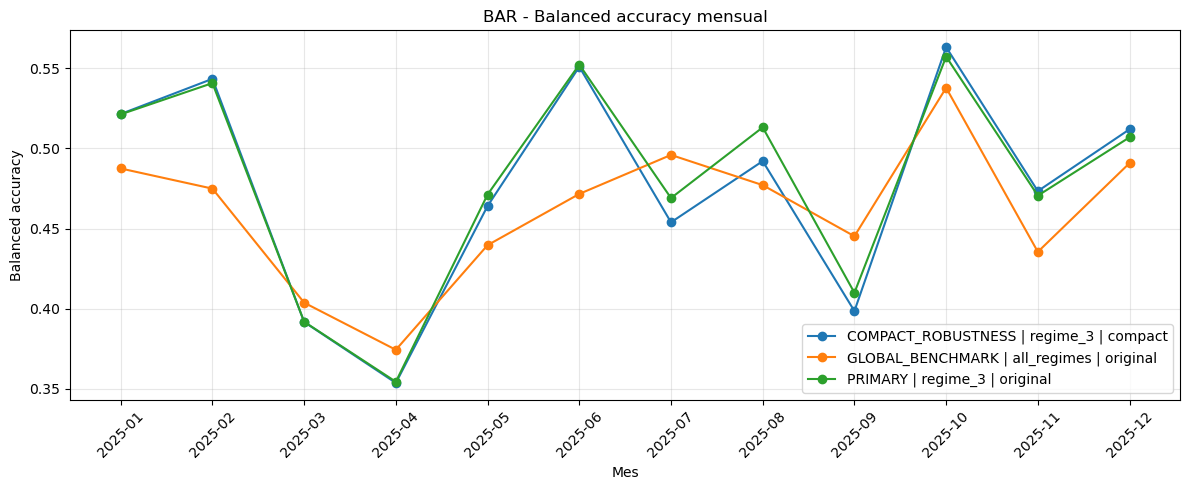

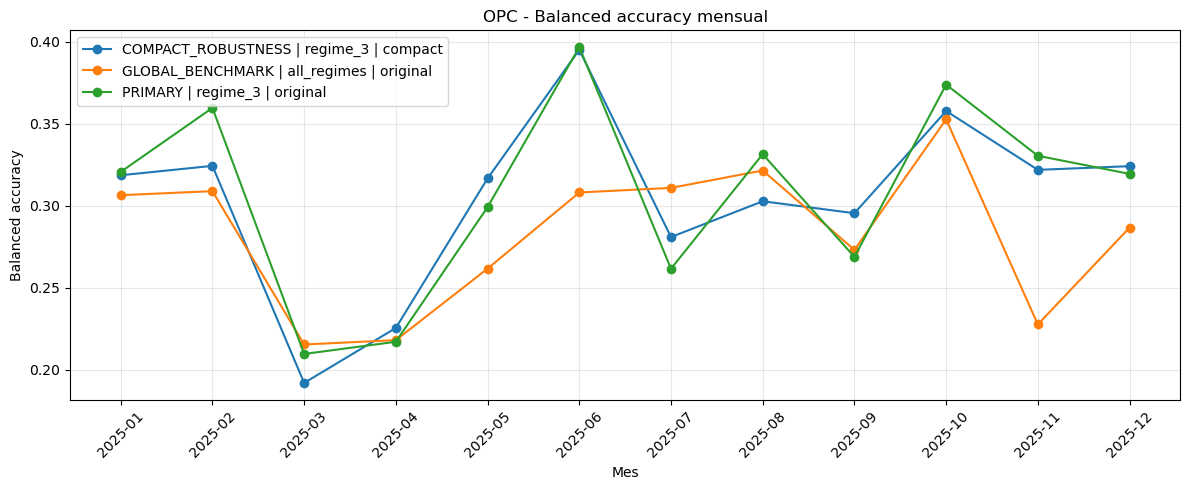

In [ ]:
# 7.8.6 Gráficos de estabilidad mensual
# =========================================================

import matplotlib.pyplot as plt


def plot_monthly_balanced_accuracy(
    target_type,
):
    """
    Muestra la balanced accuracy por mes.
    """

    data = oos_monthly_metrics.loc[
        oos_monthly_metrics[
            "target_type"
        ] == target_type
    ].copy()

    fig, ax = plt.subplots(
        figsize=(12, 5)
    )

    for (
        candidate_role,
        scope,
        feature_version,
    ), group in data.groupby(
        [
            "candidate_role",
            "scope",
            "feature_version",
        ],
        observed=True,
    ):

        label = (
            f"{candidate_role} | "
            f"{scope} | "
            f"{feature_version}"
        )

        ax.plot(
            group["period"],
            group["balanced_accuracy"],
            marker="o",
            label=label,
        )

    ax.set_title(
        f"{target_type} - Balanced accuracy mensual"
    )

    ax.set_xlabel("Mes")
    ax.set_ylabel("Balanced accuracy")

    ax.tick_params(
        axis="x",
        rotation=45,
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_monthly_balanced_accuracy("BAR")
plot_monthly_balanced_accuracy("OPC")

### Celda 7.8.7 — Gráfico de distribución para una clase

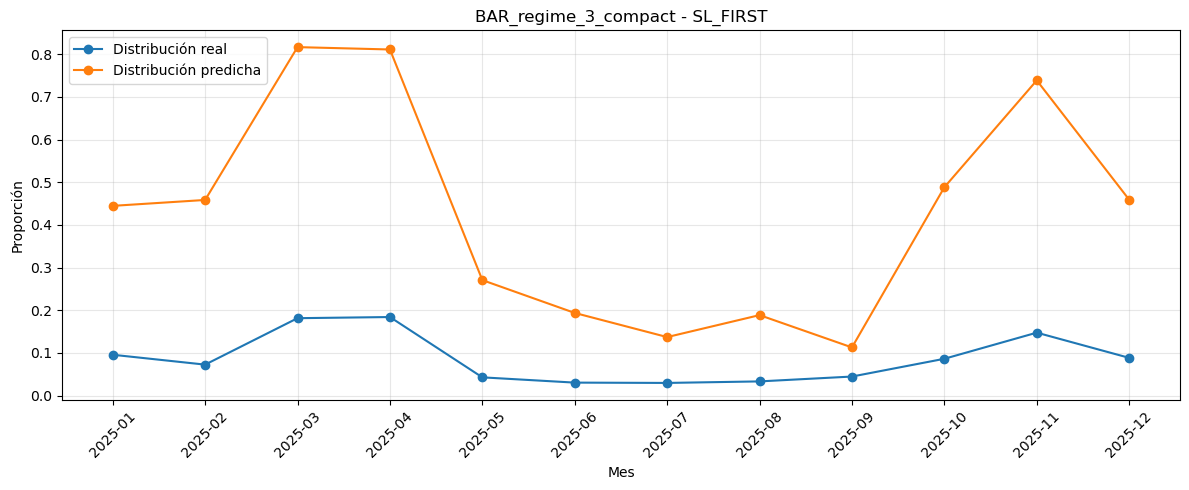

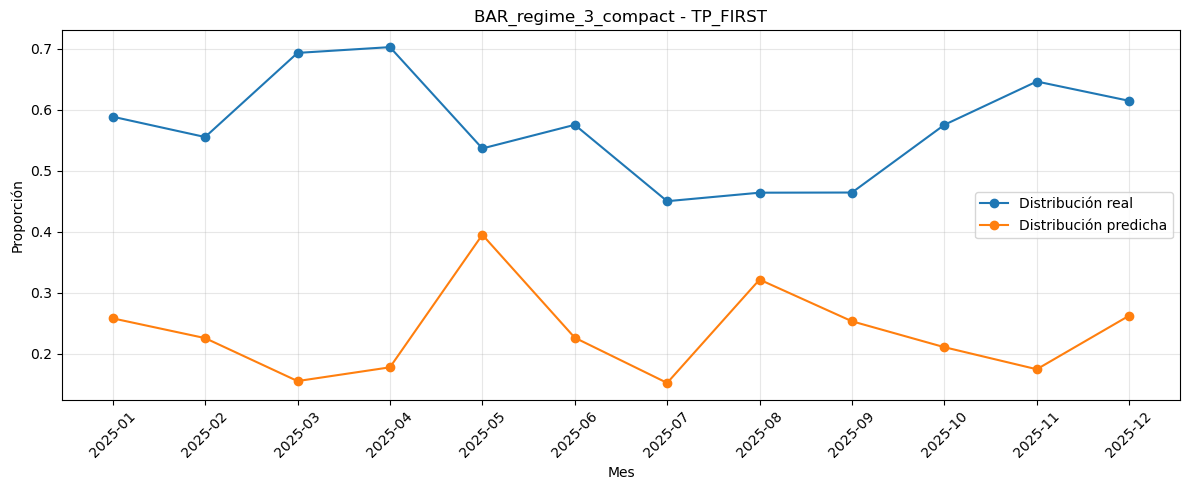

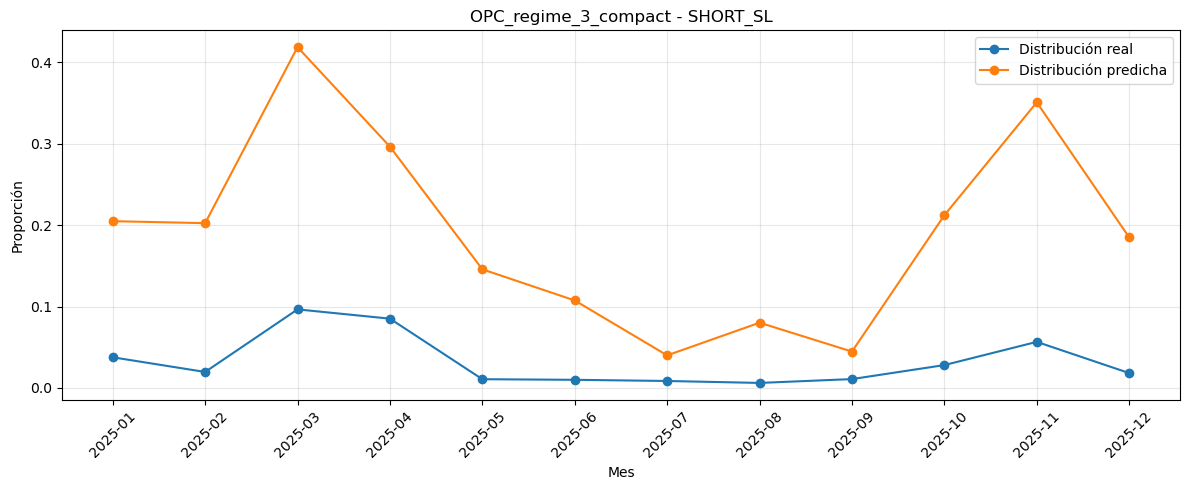

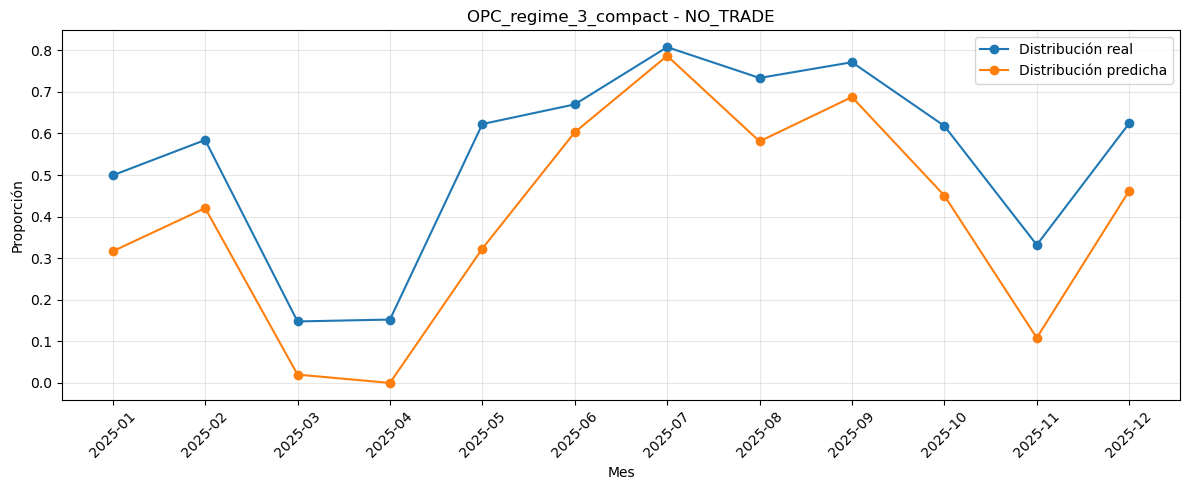

In [224]:
# 7.8.7 Evolución mensual de una clase
# =========================================================

def plot_monthly_class_distribution(
    experiment_id,
    class_name,
):
    """
    Compara distribución real y predicha
    para una clase concreta.
    """

    data = (
        oos_temporal_class_distributions.loc[
            (
                oos_temporal_class_distributions[
                    "experiment_id"
                ] == experiment_id
            )
            & (
                oos_temporal_class_distributions[
                    "period_type"
                ] == "month"
            )
            & (
                oos_temporal_class_distributions[
                    "class_name"
                ] == class_name
            )
        ]
        .sort_values("period")
    )

    if data.empty:
        raise ValueError(
            "No se encontraron datos para "
            f"{experiment_id} | {class_name}"
        )

    fig, ax = plt.subplots(
        figsize=(12, 5)
    )

    ax.plot(
        data["period"],
        data["real_ratio"],
        marker="o",
        label="Distribución real",
    )

    ax.plot(
        data["period"],
        data["predicted_ratio"],
        marker="o",
        label="Distribución predicha",
    )

    ax.set_title(
        f"{experiment_id} - {class_name}"
    )

    ax.set_xlabel("Mes")
    ax.set_ylabel("Proporción")

    ax.tick_params(
        axis="x",
        rotation=45,
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


# Clases que mostraron mayores problemas en 7.5
plot_monthly_class_distribution(
    "BAR_regime_3_compact",
    "SL_FIRST",
)

plot_monthly_class_distribution(
    "BAR_regime_3_compact",
    "TP_FIRST",
)

plot_monthly_class_distribution(
    "OPC_regime_3_compact",
    "SHORT_SL",
)

plot_monthly_class_distribution(
    "OPC_regime_3_compact",
    "NO_TRADE",
)

### Celda 7.8.8 — Validaciones

In [225]:
# 7.8.8 Validaciones
# =========================================================

assert len(
    oos_monthly_metrics
) == EXPECTED_OOS_CANDIDATES * 12

assert len(
    oos_quarterly_metrics
) == EXPECTED_OOS_CANDIDATES * 4

assert len(
    oos_temporal_stability_summary
) == EXPECTED_OOS_CANDIDATES


monthly_period_count = (
    oos_monthly_metrics
    .groupby("experiment_id")
    ["period"]
    .nunique()
)

quarterly_period_count = (
    oos_quarterly_metrics
    .groupby("experiment_id")
    ["period"]
    .nunique()
)

assert monthly_period_count.eq(12).all()
assert quarterly_period_count.eq(4).all()


monthly_rows = (
    oos_monthly_metrics
    .groupby("experiment_id")
    ["n_rows"]
    .sum()
)

annual_rows = (
    oos_model_metrics
    .set_index("experiment_id")
    ["n_oos"]
)

assert monthly_rows.equals(
    annual_rows.loc[
        monthly_rows.index
    ]
)


distribution_ratio_sums = (
    oos_temporal_class_distributions
    .groupby(
        [
            "experiment_id",
            "period_type",
            "period",
        ],
        observed=True,
    )
    [
        [
            "real_ratio",
            "predicted_ratio",
        ]
    ]
    .sum()
)

assert np.allclose(
    distribution_ratio_sums[
        "real_ratio"
    ],
    1.0,
    atol=1e-8,
)

assert np.allclose(
    distribution_ratio_sums[
        "predicted_ratio"
    ],
    1.0,
    atol=1e-8,
)


missing_class_periods = (
    oos_temporal_metrics.loc[
        ~oos_temporal_metrics[
            "all_classes_present"
        ]
    ]
)


print(
    "Validaciones temporales: APROBADAS."
)

print(
    "Filas mensuales:",
    len(oos_monthly_metrics),
)

print(
    "Filas trimestrales:",
    len(oos_quarterly_metrics),
)

print(
    "Periodos sin todas las clases:",
    len(missing_class_periods),
)

Validaciones temporales: APROBADAS.
Filas mensuales: 72
Filas trimestrales: 24
Periodos sin todas las clases: 0


### Observaciones de estabilidad temporal en 2025

* Los modelos **no son estables durante todo 2025**. El promedio anual esconde meses muy malos.
* El deterioro principal ocurre entre **marzo y abril**:

  * BAR: peor mes abril;
  * OPC: peor mes marzo.
* Después de mayo, los modelos se recuperan. No parece un deterioro continuo, sino un cambio fuerte y temporal del mercado. 

**BAR**

* En marzo y abril el modelo predice demasiados `SL_FIRST`.
* En marzo, por ejemplo:

  * `SL_FIRST` real: aproximadamente `18%`;
  * `SL_FIRST` predicho: aproximadamente `82%`.
* Al mismo tiempo, `TP_FIRST` era la clase real dominante, pero el modelo casi no la predijo.
* Esto explica la caída fuerte de `balanced_accuracy`. 

**OPC**

* Marzo y abril también muestran un cambio enorme en las clases.
* `NO_TRADE` cae a aproximadamente `15%`, cuando normalmente es mucho mayor.
* El modelo sigue esperando una distribución parecida a la histórica y sobrepredice las clases `LONG_SL` y `SHORT_SL`.
* En abril, el modelo compacto prácticamente no predice `NO_TRADE`, aunque esa clase sigue existiendo. 

**Original frente a compact**

* Original y compact siguen curvas muy parecidas.
* Por lo tanto, el problema **no parece causado por eliminar features**.
* El problema principal es que la distribución del mercado cambió.

**Conclusión**

* Las métricas anuales por sí solas son engañosas.
* Los modelos funcionan razonablemente en algunos meses, pero fallan fuerte cuando cambia la distribución de clases.
* Marzo y abril de 2025 deben quedar marcados como periodos de deterioro.
* Esto confirma que será necesario monitorear mensualmente:

  * métricas;
  * distribución de clases;
  * confianza del modelo.


**En el presente stage_06 estamos evaluando en profundidad el baseline de Logistic Regression**.

Y también evaluamos:

* Dummy;
* Decision Tree;
* HistGradientBoosting.

Pero para la evaluación OOS de 2025 seleccionamos Logistic Regression porque fue el modelo más estable y con menor riesgo de sobreajuste.

**¿Para qué sirve este baseline?**

No buscamos que sea el modelo final. Sirve para saber:

* cuánto rendimiento obtenemos con un modelo sencillo;
* qué clases son difíciles;
* dónde aparece sobrepredicción;
* cómo afecta el cambio del mercado;
* qué nivel mínimo debe superar un modelo más complejo.

Ya descubrimos problemas importantes:

* sobrepredicción de clases SL;
* probabilidades mal calibradas;
* fuerte deterioro en marzo y abril;
* cambios grandes en la distribución de clases.

Esto es valioso porque ahora los modelos complejos tendrán que demostrar que **realmente mejoran estos problemas**, no solo que consiguen una métrica anual un poco mayor.


## 7.9. Confianza y calidad de probabilidades



Se analizará si una predicción con mayor confianza realmente tiene más posibilidades de ser correcta.

Se evaluarán:

- desempeño por nivel de confianza;
- cantidad de predicciones de alta confianza;
- log loss y Brier score;
- calibración básica;
- relación entre confianza y acierto.

Este análisis sigue siendo predictivo. No se aplicarán filtros de trading.

Objetos principales:

- `oos_confidence_bin_metrics`: desempeño por rango de confianza;
- `oos_high_confidence_metrics`: cobertura y desempeño por umbral;
- `oos_probability_quality_summary`: resumen global de calibración y probabilidades.

### Celda 7.9.1 — Configuración y funciones

In [226]:
# 7.9.1 Configuración y funciones de probabilidad
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    log_loss,
)


CONFIDENCE_BIN_EDGES = [
    0.00,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.000001,
]

CONFIDENCE_BIN_LABELS = [
    "<0.40",
    "0.40-0.50",
    "0.50-0.60",
    "0.60-0.70",
    "0.70-0.80",
    "0.80-0.90",
    ">=0.90",
]

CONFIDENCE_THRESHOLDS = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
]

HIGH_CONFIDENCE_THRESHOLD = 0.70


def calculate_multiclass_brier_score(
    y_true,
    y_proba,
    classes,
):
    """
    Brier score multiclase.

    Menor valor significa mejores probabilidades.
    """

    class_positions = pd.Categorical(
        y_true,
        categories=classes,
    ).codes

    if (class_positions < 0).any():
        raise ValueError(
            "Existen clases reales no conocidas "
            "por el modelo."
        )

    y_one_hot = np.eye(
        len(classes)
    )[class_positions]

    return np.mean(
        np.sum(
            (y_proba - y_one_hot) ** 2,
            axis=1,
        )
    )


def calculate_subset_metrics(
    predictions,
    classes,
):
    """
    Métricas para un subconjunto de predicciones.
    """

    y_true = predictions[
        "target_real"
    ].to_numpy()

    y_pred = predictions[
        "predicted_class"
    ].to_numpy()

    y_proba = get_probability_matrix(
        predictions=predictions,
        classes=classes,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=classes,
    )

    support = matrix.sum(axis=1)

    recall = np.divide(
        np.diag(matrix),
        support,
        out=np.full(
            len(classes),
            np.nan,
            dtype=float,
        ),
        where=support > 0,
    )

    return {
        "accuracy": np.mean(
            y_true == y_pred
        ),
        "balanced_accuracy": (
            np.nanmean(recall)
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            labels=classes,
            average="macro",
            zero_division=0,
        ),
        "log_loss": log_loss(
            y_true,
            y_proba,
            labels=classes,
        ),
        "brier_multiclass": (
            calculate_multiclass_brier_score(
                y_true=y_true,
                y_proba=y_proba,
                classes=classes,
            )
        ),
    }


def calculate_rank_correlation(
    confidence,
    correct_prediction,
):
    """
    Correlación de Spearman sin depender de scipy.
    """

    confidence_rank = pd.Series(
        confidence
    ).rank()

    correct_rank = pd.Series(
        correct_prediction
    ).rank()

    return confidence_rank.corr(
        correct_rank
    )


print("Configuración de confianza: DEFINIDA.")

Configuración de confianza: DEFINIDA.


### Celda 7.9.2 — Desempeño por nivel de confianza

Un `calibration_gap` positivo significa que el modelo está más seguro de lo que debería.

In [227]:
# 7.9.2 Desempeño por niveles de confianza
# =========================================================

confidence_bin_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    predictions = (
        oos_predictions[
            experiment_id
        ].copy()
    )

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    predictions["correct_prediction"] = (
        predictions["target_real"]
        == predictions["predicted_class"]
    ).astype(int)

    predictions["confidence_bin"] = pd.cut(
        predictions["confidence_max"],
        bins=CONFIDENCE_BIN_EDGES,
        labels=CONFIDENCE_BIN_LABELS,
        include_lowest=True,
        right=False,
    )

    total_rows = len(predictions)

    for confidence_bin in (
        CONFIDENCE_BIN_LABELS
    ):

        subset = predictions.loc[
            predictions["confidence_bin"]
            == confidence_bin
        ]

        if subset.empty:
            continue

        metrics = calculate_subset_metrics(
            predictions=subset,
            classes=model_classes,
        )

        mean_confidence = subset[
            "confidence_max"
        ].mean()

        accuracy = metrics["accuracy"]

        confidence_bin_records.append(
            {
                "experiment_id": (
                    experiment_id
                ),
                "target_type": candidate[
                    "target_type"
                ],
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "scope": candidate["scope"],
                "feature_version": candidate[
                    "feature_version"
                ],
                "confidence_bin": (
                    confidence_bin
                ),
                "n_predictions": len(
                    subset
                ),
                "prediction_ratio": (
                    len(subset)
                    / total_rows
                ),
                "mean_confidence": (
                    mean_confidence
                ),
                **metrics,
                "calibration_gap": (
                    mean_confidence
                    - accuracy
                ),
                "absolute_calibration_gap": abs(
                    mean_confidence
                    - accuracy
                ),
            }
        )


oos_confidence_bin_metrics = (
    pd.DataFrame(
        confidence_bin_records
    )
)


print(
    "Desempeño por nivel de confianza:"
)

print(
    oos_confidence_bin_metrics[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "confidence_bin",
            "n_predictions",
            "prediction_ratio",
            "mean_confidence",
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
            "log_loss",
            "calibration_gap",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Desempeño por nivel de confianza:
target_type     candidate_role       scope feature_version confidence_bin  n_predictions  prediction_ratio  mean_confidence  accuracy  balanced_accuracy  f1_macro  log_loss  calibration_gap
        BAR            PRIMARY    regime_3        original          <0.40           4214          0.106463         0.391409  0.527765           0.353181  0.310809  1.041427        -0.136356
        BAR            PRIMARY    regime_3        original      0.40-0.50          13611          0.343868         0.434118  0.422893           0.439991  0.367800  1.038858         0.011225
        BAR            PRIMARY    regime_3        original      0.50-0.60           7808          0.197261         0.549310  0.386142           0.580245  0.302499  0.989451         0.163167
        BAR            PRIMARY    regime_3        original      0.60-0.70           5562          0.140518         0.645900  0.376303           0.582012  0.327324  1.060136         0.269596
        BAR     

### Celda 7.9.3 — Predicciones de alta confianza

`coverage` indica qué proporción de filas supera el umbral.

In [228]:
# 7.9.3 Desempeño según umbral de confianza
# =========================================================

high_confidence_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    predictions = oos_predictions[
        experiment_id
    ]

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    global_accuracy = (
        predictions["target_real"]
        == predictions["predicted_class"]
    ).mean()

    for threshold in (
        CONFIDENCE_THRESHOLDS
    ):

        subset = predictions.loc[
            predictions[
                "confidence_max"
            ] >= threshold
        ]

        if subset.empty:

            metrics = {
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                "f1_macro": np.nan,
                "log_loss": np.nan,
                "brier_multiclass": np.nan,
            }

        else:

            metrics = (
                calculate_subset_metrics(
                    predictions=subset,
                    classes=model_classes,
                )
            )

        high_confidence_records.append(
            {
                "experiment_id": (
                    experiment_id
                ),
                "target_type": candidate[
                    "target_type"
                ],
                "candidate_role": candidate[
                    "candidate_role"
                ],
                "scope": candidate["scope"],
                "feature_version": candidate[
                    "feature_version"
                ],
                "confidence_threshold": (
                    threshold
                ),
                "n_predictions": len(
                    subset
                ),
                "coverage": (
                    len(subset)
                    / len(predictions)
                ),
                "global_accuracy": (
                    global_accuracy
                ),
                **metrics,
                "accuracy_gain_vs_global": (
                    metrics["accuracy"]
                    - global_accuracy
                    if not np.isnan(
                        metrics["accuracy"]
                    )
                    else np.nan
                ),
            }
        )


oos_high_confidence_metrics = (
    pd.DataFrame(
        high_confidence_records
    )
)


print(
    "Desempeño según umbral de confianza:"
)

print(
    oos_high_confidence_metrics[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "confidence_threshold",
            "n_predictions",
            "coverage",
            "accuracy",
            "balanced_accuracy",
            "f1_macro",
            "accuracy_gain_vs_global",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Desempeño según umbral de confianza:
target_type     candidate_role       scope feature_version  confidence_threshold  n_predictions  coverage  accuracy  balanced_accuracy  f1_macro  accuracy_gain_vs_global
        BAR            PRIMARY    regime_3        original              0.500000          21757  0.549669  0.331480           0.579455  0.333805                -0.052331
        BAR            PRIMARY    regime_3        original              0.600000          13949  0.352408  0.300882           0.562752  0.340309                -0.082929
        BAR            PRIMARY    regime_3        original              0.700000           8387  0.211889  0.250864           0.445839  0.279849                -0.132946
        BAR            PRIMARY    regime_3        original              0.800000           5211  0.131651  0.258492           0.333333  0.136932                -0.125319
        BAR            PRIMARY    regime_3        original              0.900000           2667  0.067379  0.3112

### Celda 7.9.4 — Calidad global y calibración básica

Interpretación sencilla:

- ` confidence_minus_accuracy > 0`: el modelo confía demasiado.
- correlación positiva`: más confianza suele significar más aciertos.
- `ECE` cercano a cero: mejor calibración.
- `Brier score` menor: mejores probabilidades.

In [229]:
# 7.9.4 Calidad global de las probabilidades
# =========================================================

probability_quality_records = []


for _, candidate in (
    selected_candidates_ordered.iterrows()
):

    experiment_id = candidate[
        "experiment_id"
    ]

    predictions = oos_predictions[
        experiment_id
    ]

    model_classes = (
        oos_fitted_models[
            experiment_id
        ]
        .named_steps["model"]
        .classes_
    )

    y_true = predictions[
        "target_real"
    ].to_numpy()

    y_pred = predictions[
        "predicted_class"
    ].to_numpy()

    y_proba = get_probability_matrix(
        predictions=predictions,
        classes=model_classes,
    )

    confidence = predictions[
        "confidence_max"
    ].to_numpy()

    correct = (
        y_true == y_pred
    ).astype(int)

    bin_metrics = (
        oos_confidence_bin_metrics.loc[
            oos_confidence_bin_metrics[
                "experiment_id"
            ] == experiment_id
        ]
    )

    expected_calibration_error = (
        (
            bin_metrics[
                "prediction_ratio"
            ]
            * bin_metrics[
                "absolute_calibration_gap"
            ]
        )
        .sum()
    )

    maximum_calibration_error = (
        bin_metrics[
            "absolute_calibration_gap"
        ].max()
    )

    high_confidence_row = (
        oos_high_confidence_metrics.loc[
            (
                oos_high_confidence_metrics[
                    "experiment_id"
                ] == experiment_id
            )
            & (
                oos_high_confidence_metrics[
                    "confidence_threshold"
                ] == HIGH_CONFIDENCE_THRESHOLD
            )
        ]
        .iloc[0]
    )

    probability_quality_records.append(
        {
            "experiment_id": experiment_id,
            "target_type": candidate[
                "target_type"
            ],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "scope": candidate["scope"],
            "feature_version": candidate[
                "feature_version"
            ],
            "n_oos": len(predictions),
            "accuracy": correct.mean(),
            "mean_confidence": (
                confidence.mean()
            ),
            "confidence_minus_accuracy": (
                confidence.mean()
                - correct.mean()
            ),
            "confidence_accuracy_correlation": (
                calculate_rank_correlation(
                    confidence=confidence,
                    correct_prediction=correct,
                )
            ),
            "log_loss": log_loss(
                y_true,
                y_proba,
                labels=model_classes,
            ),
            "brier_multiclass": (
                calculate_multiclass_brier_score(
                    y_true=y_true,
                    y_proba=y_proba,
                    classes=model_classes,
                )
            ),
            "expected_calibration_error": (
                expected_calibration_error
            ),
            "maximum_calibration_error": (
                maximum_calibration_error
            ),
            "high_confidence_threshold": (
                HIGH_CONFIDENCE_THRESHOLD
            ),
            "high_confidence_coverage": (
                high_confidence_row[
                    "coverage"
                ]
            ),
            "high_confidence_accuracy": (
                high_confidence_row[
                    "accuracy"
                ]
            ),
            "high_confidence_accuracy_gain": (
                high_confidence_row[
                    "accuracy_gain_vs_global"
                ]
            ),
        }
    )


oos_probability_quality_summary = (
    pd.DataFrame(
        probability_quality_records
    )
)


prior_log_loss_reference = (
    oos_metrics_comparison_corrected[
        [
            "experiment_id",
            "log_loss_dummy_prior",
            "log_loss_improvement_vs_prior",
        ]
    ]
)


oos_probability_quality_summary = (
    oos_probability_quality_summary
    .merge(
        prior_log_loss_reference,
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
)


print(
    "Resumen de confianza y probabilidades:"
)

print(
    oos_probability_quality_summary[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "accuracy",
            "mean_confidence",
            "confidence_minus_accuracy",
            "confidence_accuracy_correlation",
            "high_confidence_coverage",
            "high_confidence_accuracy",
            "high_confidence_accuracy_gain",
            "log_loss",
            "log_loss_dummy_prior",
            "log_loss_improvement_vs_prior",
            "brier_multiclass",
            "expected_calibration_error",
            "maximum_calibration_error",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Resumen de confianza y probabilidades:
target_type     candidate_role       scope feature_version  accuracy  mean_confidence  confidence_minus_accuracy  confidence_accuracy_correlation  high_confidence_coverage  high_confidence_accuracy  high_confidence_accuracy_gain  log_loss  log_loss_dummy_prior  log_loss_improvement_vs_prior  brier_multiclass  expected_calibration_error  maximum_calibration_error
        BAR            PRIMARY    regime_3        original  0.383811         0.568998                   0.185187                        -0.165649                  0.211889                  0.250864                      -0.132946  1.236734              0.962389                      -0.274345          0.741615                    0.214221                   0.648339
        BAR COMPACT_ROBUSTNESS    regime_3         compact  0.383533         0.567249                   0.183716                        -0.165488                  0.209110                  0.249124                      -0.134409  1

### Celda 7.9.5 — Gráficos de calibración

La línea diagonal representa una calibración ideal.

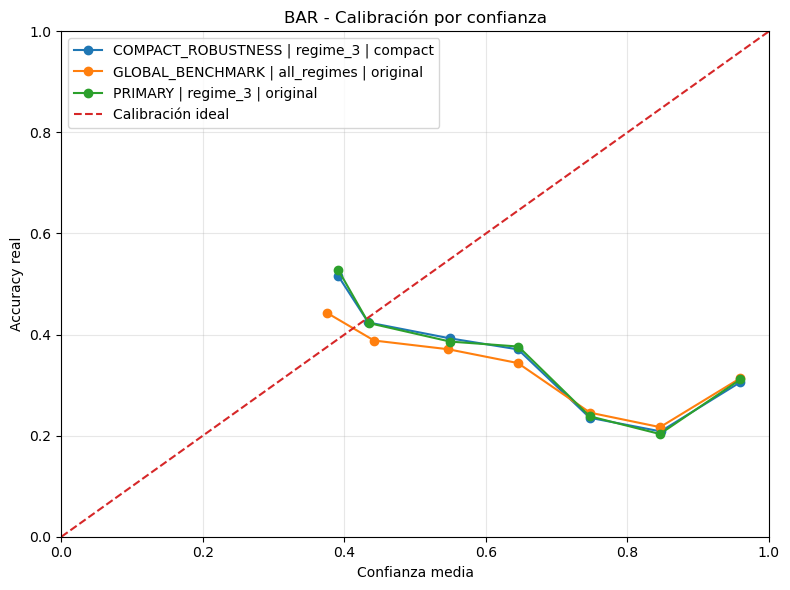

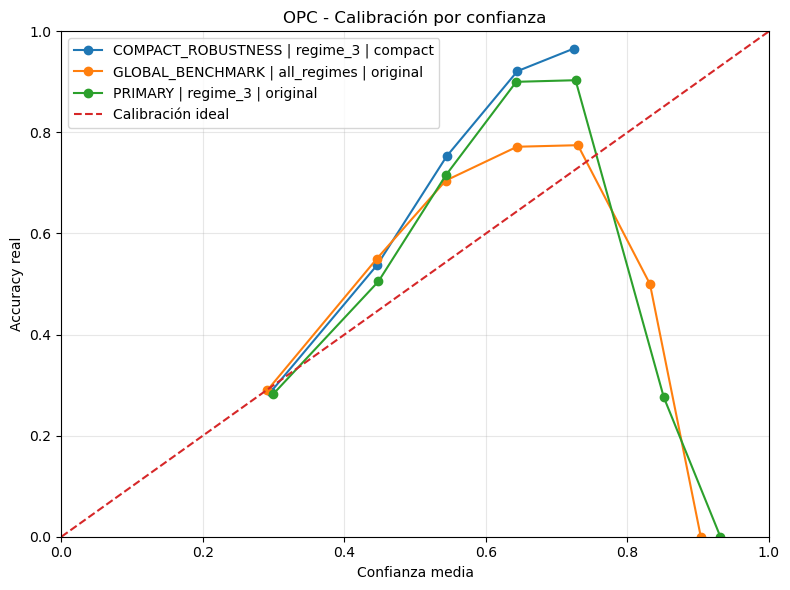

In [230]:
# 7.9.5 Gráficos de calibración básica
# =========================================================

import matplotlib.pyplot as plt


def plot_confidence_calibration(
    target_type,
):
    """
    Compara confianza media con accuracy real.
    """

    data = (
        oos_confidence_bin_metrics.loc[
            oos_confidence_bin_metrics[
                "target_type"
            ] == target_type
        ]
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    for (
        candidate_role,
        scope,
        feature_version,
    ), group in data.groupby(
        [
            "candidate_role",
            "scope",
            "feature_version",
        ],
        observed=True,
    ):

        group = group.sort_values(
            "mean_confidence"
        )

        label = (
            f"{candidate_role} | "
            f"{scope} | "
            f"{feature_version}"
        )

        ax.plot(
            group["mean_confidence"],
            group["accuracy"],
            marker="o",
            label=label,
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Calibración ideal",
    )

    ax.set_title(
        f"{target_type} - Calibración por confianza"
    )

    ax.set_xlabel(
        "Confianza media"
    )

    ax.set_ylabel(
        "Accuracy real"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_confidence_calibration("BAR")
plot_confidence_calibration("OPC")

### Celda 7.9.6 — Cobertura frente a accuracy

Este gráfico muestra si conservar solo predicciones más seguras aumenta realmente los aciertos.

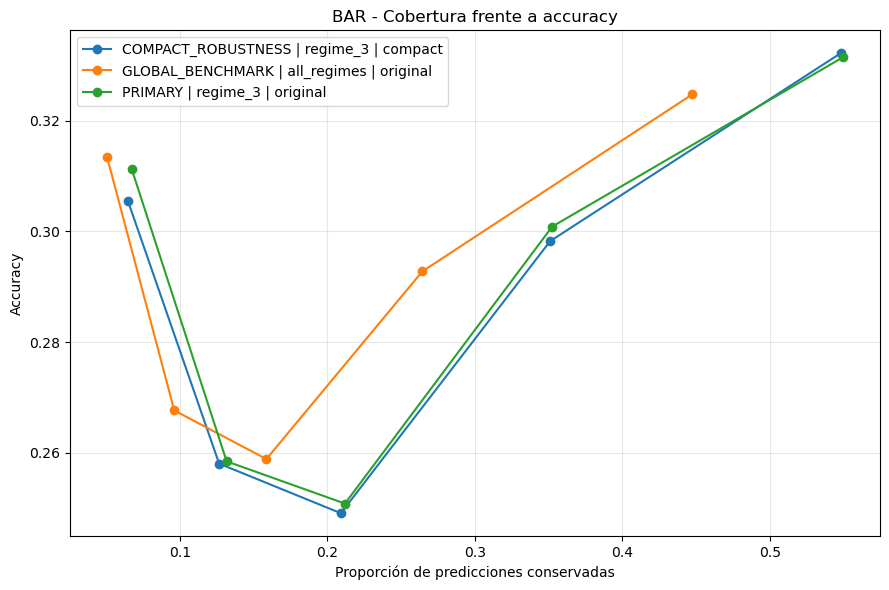

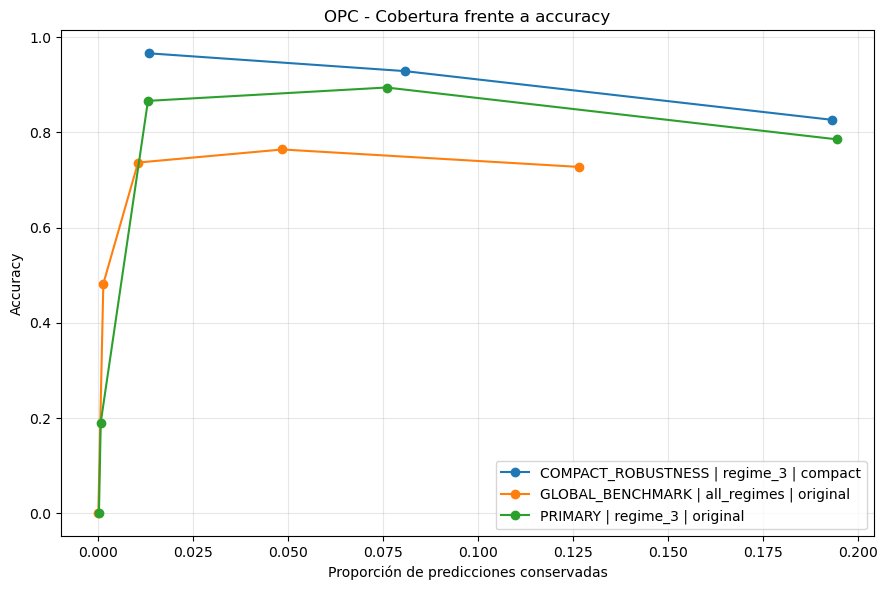

In [231]:
# 7.9.6 Cobertura y accuracy por umbral
# =========================================================

def plot_confidence_threshold_accuracy(
    target_type,
):
    """
    Muestra qué ocurre al exigir más confianza.
    """

    data = (
        oos_high_confidence_metrics.loc[
            oos_high_confidence_metrics[
                "target_type"
            ] == target_type
        ]
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    for (
        candidate_role,
        scope,
        feature_version,
    ), group in data.groupby(
        [
            "candidate_role",
            "scope",
            "feature_version",
        ],
        observed=True,
    ):

        group = group.sort_values(
            "confidence_threshold"
        )

        label = (
            f"{candidate_role} | "
            f"{scope} | "
            f"{feature_version}"
        )

        ax.plot(
            group["coverage"],
            group["accuracy"],
            marker="o",
            label=label,
        )

    ax.set_title(
        f"{target_type} - Cobertura frente a accuracy"
    )

    ax.set_xlabel(
        "Proporción de predicciones conservadas"
    )

    ax.set_ylabel(
        "Accuracy"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_confidence_threshold_accuracy("BAR")
plot_confidence_threshold_accuracy("OPC")

### Celda 7.9.7 — Validaciones

In [232]:
# 7.9.7 Validaciones
# =========================================================

assert len(
    oos_probability_quality_summary
) == EXPECTED_OOS_CANDIDATES

assert len(
    oos_high_confidence_metrics
) == (
    EXPECTED_OOS_CANDIDATES
    * len(CONFIDENCE_THRESHOLDS)
)


bin_ratio_sums = (
    oos_confidence_bin_metrics
    .groupby("experiment_id")
    ["prediction_ratio"]
    .sum()
)

assert np.allclose(
    bin_ratio_sums,
    1.0,
    atol=1e-8,
)


assert oos_probability_quality_summary[
    "mean_confidence"
].between(0.0, 1.0).all()

assert oos_probability_quality_summary[
    "expected_calibration_error"
].between(0.0, 1.0).all()

assert oos_probability_quality_summary[
    "maximum_calibration_error"
].between(0.0, 1.0).all()

assert oos_probability_quality_summary[
    "high_confidence_coverage"
].between(0.0, 1.0).all()


for experiment_id, group in (
    oos_high_confidence_metrics.groupby(
        "experiment_id"
    )
):

    ordered = group.sort_values(
        "confidence_threshold"
    )

    coverage_differences = (
        ordered["coverage"].diff().dropna()
    )

    assert (
        coverage_differences <= 1e-12
    ).all()


stored_log_loss = (
    oos_model_metrics
    .set_index("experiment_id")
    ["log_loss"]
)

calculated_log_loss = (
    oos_probability_quality_summary
    .set_index("experiment_id")
    ["log_loss"]
)

assert np.allclose(
    stored_log_loss.loc[
        calculated_log_loss.index
    ],
    calculated_log_loss,
    atol=1e-10,
)


print(
    "Validaciones de confianza y "
    "probabilidades: APROBADAS."
)

print(
    "Modelos evaluados:",
    len(
        oos_probability_quality_summary
    ),
)

print(
    "Umbrales evaluados:",
    len(CONFIDENCE_THRESHOLDS),
)

Validaciones de confianza y probabilidades: APROBADAS.
Modelos evaluados: 6
Umbrales evaluados: 5


### Observaciones de confianza y calidad

1. BAR

    En BAR, la confianza del modelo no funciona como debería.

    Cuando el modelo muestra una confianza alta, no aumenta la cantidad de aciertos. Ocurre lo contrario:

    - la correlación entre confianza y acierto es negativa, cercana a `-0.16`;
    - la accuracy global es aproximadamente `38%`;
    - al conservar solo predicciones con confianza `≥ 0.70`, la accuracy baja hasta aproximadamente `25%`.

    Además, las predicciones con mayor confianza presentan errores de calibración elevados y un `log_loss` peor que el Dummy `prior`.

    Explicación sencilla:

    El modelo es como una persona que habla con mucha seguridad, pero se equivoca más cuando está más convencida.

    Por lo tanto, en BAR no podemos asumir que una predicción con `80%` o `90%` de confianza sea más confiable que una predicción con menor confianza.

    Conclusión BAR:

    La confianza no debe utilizarse como filtro predictivo. Una confianza alta no representa actualmente una mayor probabilidad de acierto.


2. OPC

    En OPC, la confianza presenta un comportamiento más razonable.

    Cuando aumenta la confianza, también aumenta la accuracy:

    - con confianza `≥ 0.50`, se conserva aproximadamente entre `13%` y `19%` de las predicciones, con una accuracy entre `73%` y `83%`;
    - con confianza `≥ 0.60`, se conserva solamente entre `5%` y `8%`, pero la accuracy aumenta hasta valores cercanos a `76%–93%`.

    Sin embargo, esta mejora debe interpretarse con cuidado:

    - la `balanced_accuracy` continúa cerca de `0.40`;
    - el `f1_macro` sigue siendo bajo;
    - las predicciones de alta confianza probablemente se concentran en una o pocas clases fáciles, principalmente `NO_TRADE`;
    - con confianza `≥ 0.70`, la cobertura es cercana al `1%`;
    - por encima de `0.80`, existen muy pocos casos o ninguno.

    Explicación sencilla:

    El modelo OPC reconoce algunos casos fáciles.

    Es como un alumno que responde correctamente cuando recibe preguntas simples, pero todavía falla cuando debe distinguir entre todas las respuestas posibles.

    Por eso puede tener una accuracy alta en un grupo pequeño, aunque todavía no reconozca correctamente todas las clases.

    Conclusión OPC:

    La confianza aporta cierta información, pero solo para una pequeña parte de las observaciones y no garantiza un buen desempeño equilibrado entre clases.


3. Calidad de las probabilidades

    Ninguno de los modelos supera al Dummy `prior` en `log_loss`.

    Esto significa que las probabilidades generadas por Logistic Regression todavía son peores que utilizar solamente la frecuencia histórica de cada clase.

    La versión `OPC regime_3 compact` presenta la mejor calidad relativa dentro de los modelos evaluados:

    - mayor accuracy;
    - mejor relación entre confianza y acierto;
    - menor `log_loss`;
    - menor Brier score que OPC original.

    Aun así, sus probabilidades no pueden considerarse correctamente calibradas.

    Explicación sencilla:

    El modelo puede acertar la clase, pero el porcentaje que informa no es necesariamente verdadero.

    Por ejemplo, cuando indica una confianza de `70%`, eso no significa todavía que vaya a acertar aproximadamente 7 de cada 10 veces.


4. Decisión del punto 7.9

    - En BAR, la confianza no es utilizable.
    - En OPC, la confianza es parcialmente informativa, pero solo en un subconjunto pequeño y sesgado.
    - No deben definirse todavía reglas como seleccionar observaciones únicamente cuando la confianza sea superior a `0.70`.
    - La calibración deberá revisarse más adelante con métodos específicos y sin utilizar 2025 para ajustar el modelo.
    - Este análisis sigue siendo predictivo y no representa todavía una estrategia de trading.

## 7.10. Comparación final y decisión


Los modelos se clasificarán como:

- ADVANCE_TO_2026: modelo principal que pasa a la prueba final;
- SECONDARY: modelo útil como referencia o respaldo;
- REJECT_OOS: modelo que no continúa por menor rendimiento o redundancia.

La decisión utiliza únicamente los resultados walk-forward y OOS de 2025.

Los datos de 2026 permanecen sin utilizar.

### Celda 7.10.1 — Consolidar resultados

In [233]:
# 7.10.1 Consolidación de resultados finales
# =========================================================

import numpy as np
import pandas as pd


CHANCE_BALANCED_ACCURACY = {
    "BAR": 1 / 3,
    "OPC": 1 / 5,
}


candidate_base_columns = [
    "experiment_id",
    "target_type",
    "candidate_role",
    "scope",
    "feature_version",
    "n_features",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "f1_macro_mean",
    "generalization_gap_mean",
    "walk_forward_status",
]


missing_candidate_columns = [
    column
    for column in candidate_base_columns
    if column not in selected_model_candidates.columns
]

if missing_candidate_columns:
    raise KeyError(
        "Columnas faltantes en selected_model_candidates: "
        f"{missing_candidate_columns}"
    )


final_candidate_comparison = (
    selected_model_candidates[
        candidate_base_columns
    ]
    .merge(
        oos_model_metrics[
            [
                "experiment_id",
                "n_oos",
                "accuracy",
                "balanced_accuracy",
                "f1_macro",
                "f1_weighted",
                "log_loss",
            ]
        ],
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        oos_metrics_comparison[
            [
                "experiment_id",
                "balanced_accuracy_dummy_stratified",
                "balanced_accuracy_uplift_vs_stratified",
                "f1_macro_uplift_vs_stratified",
                "beats_dummy_balanced_accuracy",
            ]
        ],
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        oos_temporal_stability_summary[
            [
                "experiment_id",
                "monthly_ba_std",
                "worst_month",
                "worst_month_ba",
                "worst_month_drop_vs_annual",
                "worst_quarter",
                "worst_quarter_ba",
                "worst_quarter_drop_vs_annual",
            ]
        ],
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        oos_probability_quality_summary[
            [
                "experiment_id",
                "mean_confidence",
                "confidence_accuracy_correlation",
                "log_loss_dummy_prior",
                "log_loss_improvement_vs_prior",
                "expected_calibration_error",
            ]
        ],
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
)


final_candidate_comparison[
    "chance_balanced_accuracy"
] = (
    final_candidate_comparison[
        "target_type"
    ].map(
        CHANCE_BALANCED_ACCURACY
    )
)


final_candidate_comparison[
    "balanced_accuracy_uplift_vs_chance"
] = (
    final_candidate_comparison[
        "balanced_accuracy"
    ]
    - final_candidate_comparison[
        "chance_balanced_accuracy"
    ]
)


final_candidate_comparison[
    "worst_quarter_uplift_vs_chance"
] = (
    final_candidate_comparison[
        "worst_quarter_ba"
    ]
    - final_candidate_comparison[
        "chance_balanced_accuracy"
    ]
)


final_candidate_comparison[
    "probability_status"
] = np.where(
    final_candidate_comparison[
        "log_loss_improvement_vs_prior"
    ] > 0,
    "BETTER_THAN_PRIOR",
    "UNCALIBRATED",
)


print("Comparación final de candidatos:")

print(
    final_candidate_comparison[
        [
            "target_type",
            "candidate_role",
            "scope",
            "feature_version",
            "n_features",
            "balanced_accuracy",
            "f1_macro",
            "balanced_accuracy_uplift_vs_stratified",
            "monthly_ba_std",
            "worst_month",
            "worst_month_ba",
            "worst_quarter_ba",
            "confidence_accuracy_correlation",
            "probability_status",
        ]
    ].sort_values(
        [
            "target_type",
            "balanced_accuracy",
        ],
        ascending=[
            True,
            False,
        ],
    ).to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Comparación final de candidatos:
target_type     candidate_role       scope feature_version  n_features  balanced_accuracy  f1_macro  balanced_accuracy_uplift_vs_stratified  monthly_ba_std worst_month  worst_month_ba  worst_quarter_ba  confidence_accuracy_correlation probability_status
        BAR            PRIMARY    regime_3        original           9           0.535645  0.387168                                0.204729        0.065424     2025-04        0.354466          0.466628                        -0.165649       UNCALIBRATED
        BAR COMPACT_ROBUSTNESS    regime_3         compact           7           0.534242  0.386658                                0.203326        0.067424     2025-04        0.353739          0.450381                        -0.165488       UNCALIBRATED
        BAR   GLOBAL_BENCHMARK all_regimes        original          10           0.515178  0.370368                                0.181819        0.044095     2025-04        0.374393          0.467755    

### Celda 7.10.2 — Decisión explícita

In [234]:
# 7.10.2 Clasificación final de modelos
# =========================================================

FINAL_OOS_DECISIONS = {
    "BAR_all_regimes_original": {
        "final_decision": "ADVANCE_TO_2026",
        "decision_priority": 1,
        "decision_reason": (
            "Mejor BAR sobre las mismas filas de "
            "regime_3 y menor variabilidad mensual."
        ),
    },

    "BAR_regime_3_compact": {
        "final_decision": "SECONDARY",
        "decision_priority": 2,
        "decision_reason": (
            "Mantiene el desempeño con menos features, "
            "pero no supera al modelo global."
        ),
    },

    "BAR_regime_3_original": {
        "final_decision": "REJECT_OOS",
        "decision_priority": 3,
        "decision_reason": (
            "Es redundante: la versión compacta obtiene "
            "resultados prácticamente iguales."
        ),
    },

    "OPC_regime_3_compact": {
        "final_decision": "ADVANCE_TO_2026",
        "decision_priority": 1,
        "decision_reason": (
            "Mejor equilibrio entre desempeño, estabilidad, "
            "simplicidad y calidad relativa."
        ),
    },

    "OPC_all_regimes_original": {
        "final_decision": "SECONDARY",
        "decision_priority": 2,
        "decision_reason": (
            "Se conserva como referencia global, aunque "
            "queda por debajo del modelo específico."
        ),
    },

    "OPC_regime_3_original": {
        "final_decision": "REJECT_OOS",
        "decision_priority": 3,
        "decision_reason": (
            "La versión compacta es más simple y obtiene "
            "resultados iguales o mejores."
        ),
    },
}


decision_records = []


for experiment_id, decision_data in (
    FINAL_OOS_DECISIONS.items()
):

    candidate_rows = (
        final_candidate_comparison.loc[
            final_candidate_comparison[
                "experiment_id"
            ] == experiment_id
        ]
    )

    if len(candidate_rows) != 1:
        raise ValueError(
            f"{experiment_id}: se esperaba "
            "un único candidato."
        )

    candidate = candidate_rows.iloc[0]

    decision_records.append(
        {
            "experiment_id": experiment_id,
            "target_type": candidate[
                "target_type"
            ],
            "candidate_role": candidate[
                "candidate_role"
            ],
            "scope": candidate[
                "scope"
            ],
            "feature_version": candidate[
                "feature_version"
            ],
            "n_features": candidate[
                "n_features"
            ],
            "balanced_accuracy": candidate[
                "balanced_accuracy"
            ],
            "f1_macro": candidate[
                "f1_macro"
            ],
            "monthly_ba_std": candidate[
                "monthly_ba_std"
            ],
            "worst_month_ba": candidate[
                "worst_month_ba"
            ],
            "worst_quarter_ba": candidate[
                "worst_quarter_ba"
            ],
            "probability_status": candidate[
                "probability_status"
            ],
            **decision_data,
        }
    )


final_oos_model_decisions = (
    pd.DataFrame(
        decision_records
    )
    .sort_values(
        [
            "target_type",
            "decision_priority",
        ]
    )
    .reset_index(drop=True)
)


print("Decisión final OOS:")

print(
    final_oos_model_decisions[
        [
            "target_type",
            "experiment_id",
            "scope",
            "feature_version",
            "n_features",
            "balanced_accuracy",
            "f1_macro",
            "monthly_ba_std",
            "final_decision",
            "decision_reason",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Decisión final OOS:
target_type            experiment_id       scope feature_version  n_features  balanced_accuracy  f1_macro  monthly_ba_std  final_decision                                                                    decision_reason
        BAR BAR_all_regimes_original all_regimes        original          10           0.515178  0.370368        0.044095 ADVANCE_TO_2026         Mejor BAR sobre las mismas filas de regime_3 y menor variabilidad mensual.
        BAR     BAR_regime_3_compact    regime_3         compact           7           0.534242  0.386658        0.067424       SECONDARY         Mantiene el desempeño con menos features, pero no supera al modelo global.
        BAR    BAR_regime_3_original    regime_3        original           9           0.535645  0.387168        0.065424      REJECT_OOS       Es redundante: la versión compacta obtiene resultados prácticamente iguales.
        OPC     OPC_regime_3_compact    regime_3         compact           5           0.351463 

### Celda 7.10.3 — Modelos que avanzan

In [235]:
# 7.10.3 Selección para robustez final 2026
# =========================================================

advance_to_2026_candidates = (
    final_oos_model_decisions.loc[
        final_oos_model_decisions[
            "final_decision"
        ] == "ADVANCE_TO_2026"
    ]
    .copy()
)


secondary_candidates = (
    final_oos_model_decisions.loc[
        final_oos_model_decisions[
            "final_decision"
        ] == "SECONDARY"
    ]
    .copy()
)


rejected_oos_candidates = (
    final_oos_model_decisions.loc[
        final_oos_model_decisions[
            "final_decision"
        ] == "REJECT_OOS"
    ]
    .copy()
)


advance_to_2026_experiment_ids = (
    advance_to_2026_candidates[
        "experiment_id"
    ].tolist()
)


advance_to_2026_specifications = (
    selected_model_candidates.loc[
        selected_model_candidates[
            "experiment_id"
        ].isin(
            advance_to_2026_experiment_ids
        )
    ]
    .copy()
)


print("Modelos que avanzan a 2026:")

print(
    advance_to_2026_candidates[
        [
            "target_type",
            "experiment_id",
            "scope",
            "feature_version",
            "n_features",
            "balanced_accuracy",
            "f1_macro",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)


print()
print("Modelos secundarios:")

print(
    secondary_candidates[
        [
            "target_type",
            "experiment_id",
            "scope",
            "feature_version",
        ]
    ].to_string(
        index=False,
    )
)


print()
print("Modelos rechazados:")

print(
    rejected_oos_candidates[
        [
            "target_type",
            "experiment_id",
            "decision_reason",
        ]
    ].to_string(
        index=False,
    )
)

Modelos que avanzan a 2026:
target_type            experiment_id       scope feature_version  n_features  balanced_accuracy  f1_macro
        BAR BAR_all_regimes_original all_regimes        original          10           0.515178  0.370368
        OPC     OPC_regime_3_compact    regime_3         compact           5           0.351463  0.268011

Modelos secundarios:
target_type            experiment_id       scope feature_version
        BAR     BAR_regime_3_compact    regime_3         compact
        OPC OPC_all_regimes_original all_regimes        original

Modelos rechazados:
target_type         experiment_id                                                              decision_reason
        BAR BAR_regime_3_original Es redundante: la versión compacta obtiene resultados prácticamente iguales.
        OPC OPC_regime_3_original    La versión compacta es más simple y obtiene resultados iguales o mejores.


### Celda 7.10.4 — Validaciones

In [236]:
# 7.10.4 Validaciones de decisión final
# =========================================================

VALID_FINAL_DECISIONS = {
    "ADVANCE_TO_2026",
    "SECONDARY",
    "REJECT_OOS",
}


assert len(
    final_oos_model_decisions
) == EXPECTED_OOS_CANDIDATES


assert final_oos_model_decisions[
    "experiment_id"
].is_unique


assert set(
    final_oos_model_decisions[
        "final_decision"
    ].unique()
).issubset(
    VALID_FINAL_DECISIONS
)


assert len(
    advance_to_2026_candidates
) == 2


assert len(
    secondary_candidates
) == 2


assert len(
    rejected_oos_candidates
) == 2


advance_counts_by_target = (
    advance_to_2026_candidates
    .groupby("target_type")
    .size()
)


assert advance_counts_by_target.to_dict() == {
    "BAR": 1,
    "OPC": 1,
}


assert (
    advance_to_2026_candidates[
        "balanced_accuracy"
    ]
    > advance_to_2026_candidates[
        "target_type"
    ].map(
        CHANCE_BALANCED_ACCURACY
    )
).all()


assert (
    advance_to_2026_candidates[
        "worst_quarter_ba"
    ]
    > advance_to_2026_candidates[
        "target_type"
    ].map(
        CHANCE_BALANCED_ACCURACY
    )
).all()


assert set(
    advance_to_2026_experiment_ids
) == {
    "BAR_all_regimes_original",
    "OPC_regime_3_compact",
}


print(
    "Validaciones de decisión final: "
    "APROBADAS."
)

print(
    "Candidatos que avanzan:",
    len(advance_to_2026_candidates),
)

print(
    "2026 permanece sin utilizar."
)

Validaciones de decisión final: APROBADAS.
Candidatos que avanzan: 2
2026 permanece sin utilizar.


### Observaciones

1. Selección BAR

* Avanza `BAR_all_regimes_original`.
* Aunque su resultado anual global es menor, en la comparación justa sobre las mismas filas de `regime_3` superó ligeramente a los modelos específicos.
* También tuvo menor variabilidad mensual.
* `BAR_regime_3_compact` queda como respaldo porque obtiene resultados similares usando menos variables.
* `BAR_regime_3_original` se descarta por redundancia, no porque sea un mal modelo.

2. Selección OPC

* Avanza `OPC_regime_3_compact`.
* Reduce las variables de 8 a 5.
* Mantiene prácticamente la misma `balanced_accuracy`.
* Mejora `f1_macro`, estabilidad y calidad relativa de las probabilidades.
* `OPC_all_regimes_original` queda como referencia global.
* `OPC_regime_3_original` se descarta porque la versión compacta ofrece un mejor equilibrio.

3. Probabilidades

* Los seis candidatos siguen apareciendo como `UNCALIBRATED`.
* Esto no impide evaluar sus clases en 2026.
* Sí impide interpretar la confianza como una probabilidad real o usarla como filtro confiable.

4. Resultado final

Los dos modelos que avanzan son:

* BAR: `BAR_all_regimes_original`.
* OPC: `OPC_regime_3_compact`.

Explicación sencilla:

Para BAR elegimos al modelo que aprendió con más datos y funcionó mejor cuando lo comparamos de forma justa.

Para OPC elegimos al modelo pequeño porque hace casi lo mismo o mejor usando menos variables.

5. Siguiente paso

La decisión es coherente y las validaciones fueron aprobadas. Ahora corresponde probar estos dos modelos sobre 2026, sin cambiar features, hiperparámetros ni criterios de selección. 2026 debe utilizarse únicamente como comprobación final de robustez.


## 7.11. Guardado de resultados


Se guardarán los resultados completos de la evaluación OOS de 2025:

- métricas globales;
- métricas por clase;
- matrices de confusión;
- estabilidad temporal;
- calidad de probabilidades;
- predicciones y probabilidades;
- ranking final;
- decisión de candidatos;
- pipelines congelados.

La secuencia guardada será:

preparación → entrenamiento congelado → predicción 2025 → métricas → análisis por clase → estabilidad temporal → selección para 2026

### Celda 7.11.1 — Carpetas de resultados

In [242]:
# 7.11.1 Carpetas de resultados del Stage_06
# =========================================================

from pathlib import Path


# Usar una ruta existente del proyecto cuando esté disponible
if "DATA_PATH" in globals():

    DATA_ROOT = Path(DATA_PATH)

elif "PROJECT_ROOT" in globals():

    DATA_ROOT = (
        Path(PROJECT_ROOT)
        / "data"
    )

else:

    DATA_ROOT = Path("data")


STAGE_06_RESULTS_PATH = (
    DATA_ROOT
    / "06_predictive_analysis"
)

OOS_2025_RESULTS_PATH = (
    STAGE_06_RESULTS_PATH
    / "07_oos_2025"
)


GLOBAL_METRICS_PATH = (
    OOS_2025_RESULTS_PATH
    / "01_global_metrics"
)

CLASS_ANALYSIS_PATH = (
    OOS_2025_RESULTS_PATH
    / "02_class_analysis"
)

CONFUSION_MATRICES_PATH = (
    OOS_2025_RESULTS_PATH
    / "03_confusion_matrices"
)

TEMPORAL_ANALYSIS_PATH = (
    OOS_2025_RESULTS_PATH
    / "04_temporal_stability"
)

PROBABILITY_ANALYSIS_PATH = (
    OOS_2025_RESULTS_PATH
    / "05_probability_quality"
)

PREDICTIONS_2025_PATH = (
    OOS_2025_RESULTS_PATH
    / "06_predictions"
)

FINAL_SELECTION_PATH = (
    OOS_2025_RESULTS_PATH
    / "07_final_selection"
)

FROZEN_MODELS_PATH = (
    OOS_2025_RESULTS_PATH
    / "08_frozen_models"
)

METADATA_PATH = (
    OOS_2025_RESULTS_PATH
    / "09_metadata"
)


RESULT_DIRECTORIES = [
    GLOBAL_METRICS_PATH,
    CLASS_ANALYSIS_PATH,
    CONFUSION_MATRICES_PATH,
    TEMPORAL_ANALYSIS_PATH,
    PROBABILITY_ANALYSIS_PATH,
    PREDICTIONS_2025_PATH,
    FINAL_SELECTION_PATH,
    FROZEN_MODELS_PATH,
    METADATA_PATH,
]


for directory in RESULT_DIRECTORIES:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "Carpeta Stage_06:",
    STAGE_06_RESULTS_PATH.resolve(),
)

print(
    "Resultados OOS 2025:",
    OOS_2025_RESULTS_PATH.resolve(),
)

Carpeta Stage_06: C:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\06_predictive_analysis
Resultados OOS 2025: C:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\06_predictive_analysis\07_oos_2025


### Celda 7.11.2 — Funciones de guardado

In [243]:
# 7.11.2 Funciones de guardado
# =========================================================

import json
import numpy as np
import pandas as pd


saved_artifacts = []


def register_saved_artifact(
    path,
    category,
    object_name,
    rows=None,
):
    """
    Registra cada archivo guardado.
    """

    saved_artifacts.append(
        {
            "category": category,
            "object_name": object_name,
            "path": str(
                Path(path).resolve()
            ),
            "rows": rows,
        }
    )


def save_dataframe_pair(
    dataframe,
    output_stem,
    category,
    object_name,
    index=False,
):
    """
    Guarda una tabla en Parquet y CSV.
    """

    output_stem = Path(output_stem)

    parquet_path = (
        output_stem.with_suffix(
            ".parquet"
        )
    )

    csv_path = (
        output_stem.with_suffix(
            ".csv"
        )
    )

    dataframe.to_parquet(
        parquet_path,
        index=index,
        compression="snappy",
    )

    dataframe.to_csv(
        csv_path,
        index=index,
    )

    register_saved_artifact(
        path=parquet_path,
        category=category,
        object_name=object_name,
        rows=len(dataframe),
    )

    register_saved_artifact(
        path=csv_path,
        category=category,
        object_name=object_name,
        rows=len(dataframe),
    )


def json_serializer(value):
    """
    Convierte objetos especiales a JSON.
    """

    if isinstance(
        value,
        (np.integer, np.floating),
    ):
        return value.item()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(
        value,
        (pd.Timestamp, pd.Timedelta),
    ):
        return str(value)

    if isinstance(value, Path):
        return str(value)

    if isinstance(
        value,
        (set, tuple),
    ):
        return list(value)

    raise TypeError(
        f"Tipo no serializable: "
        f"{type(value)}"
    )


print(
    "Funciones de guardado: DEFINIDAS."
)

Funciones de guardado: DEFINIDAS.


### Celda 7.11.3 — Guardar tablas principales

In [244]:
# 7.11.3 Guardado de tablas de resultados
# =========================================================

TABLES_TO_SAVE = [
    # Métricas globales
    (
        "oos_model_metrics",
        GLOBAL_METRICS_PATH,
    ),
    (
        "oos_dummy_metrics",
        GLOBAL_METRICS_PATH,
    ),
    (
        "oos_prior_dummy_metrics",
        GLOBAL_METRICS_PATH,
    ),
    (
        "oos_metrics_comparison",
        GLOBAL_METRICS_PATH,
    ),
    (
        "oos_metrics_comparison_corrected",
        GLOBAL_METRICS_PATH,
    ),
    (
        "fair_scope_validation_summary",
        GLOBAL_METRICS_PATH,
    ),
    (
        "fair_scope_metrics",
        GLOBAL_METRICS_PATH,
    ),
    (
        "fair_scope_comparison",
        GLOBAL_METRICS_PATH,
    ),
    (
        "oos_original_compact_global",
        GLOBAL_METRICS_PATH,
    ),
    (
        "compact_assessment",
        GLOBAL_METRICS_PATH,
    ),

    # Análisis por clase
    (
        "oos_class_metrics",
        CLASS_ANALYSIS_PATH,
    ),
    (
        "oos_class_distributions",
        CLASS_ANALYSIS_PATH,
    ),
    (
        "oos_minority_class_summary",
        CLASS_ANALYSIS_PATH,
    ),
    (
        "oos_original_compact_class",
        CLASS_ANALYSIS_PATH,
    ),
    (
        "oos_original_compact_class_summary",
        CLASS_ANALYSIS_PATH,
    ),

    # Estabilidad temporal
    (
        "oos_monthly_metrics",
        TEMPORAL_ANALYSIS_PATH,
    ),
    (
        "oos_quarterly_metrics",
        TEMPORAL_ANALYSIS_PATH,
    ),
    (
        "oos_temporal_stability_summary",
        TEMPORAL_ANALYSIS_PATH,
    ),
    (
        "oos_temporal_class_distributions",
        TEMPORAL_ANALYSIS_PATH,
    ),
    (
        "worst_distribution_month",
        TEMPORAL_ANALYSIS_PATH,
    ),

    # Confianza y probabilidades
    (
        "oos_confidence_bin_metrics",
        PROBABILITY_ANALYSIS_PATH,
    ),
    (
        "oos_high_confidence_metrics",
        PROBABILITY_ANALYSIS_PATH,
    ),
    (
        "oos_probability_quality_summary",
        PROBABILITY_ANALYSIS_PATH,
    ),

    # Selección final
    (
        "final_candidate_comparison",
        FINAL_SELECTION_PATH,
    ),
    (
        "final_oos_model_decisions",
        FINAL_SELECTION_PATH,
    ),
    (
        "advance_to_2026_candidates",
        FINAL_SELECTION_PATH,
    ),
    (
        "secondary_candidates",
        FINAL_SELECTION_PATH,
    ),
    (
        "rejected_oos_candidates",
        FINAL_SELECTION_PATH,
    ),
]


for object_name, output_directory in (
    TABLES_TO_SAVE
):

    dataframe = globals().get(
        object_name
    )

    if dataframe is None:

        raise NameError(
            f"No existe el objeto: "
            f"{object_name}"
        )

    save_dataframe_pair(
        dataframe=dataframe,
        output_stem=(
            output_directory
            / object_name
        ),
        category=(
            output_directory.name
        ),
        object_name=object_name,
        index=False,
    )


print(
    "Tablas guardadas:",
    len(TABLES_TO_SAVE),
)

Tablas guardadas: 28


### Celda 7.11.4 — Guardar matrices de confusión

In [245]:
# 7.11.4 Guardado de matrices de confusión
# =========================================================

confusion_long_records = []


for experiment_id, matrix_data in (
    oos_confusion_matrices.items()
):

    for matrix_type in [
        "counts",
        "normalized",
    ]:

        matrix_df = (
            matrix_data[
                matrix_type
            ]
        )

        output_stem = (
            CONFUSION_MATRICES_PATH
            / (
                f"{experiment_id}"
                f"__{matrix_type}"
            )
        )

        save_dataframe_pair(
            dataframe=matrix_df,
            output_stem=output_stem,
            category=(
                "03_confusion_matrices"
            ),
            object_name=(
                f"{experiment_id}"
                f"__{matrix_type}"
            ),
            index=True,
        )

        matrix_long = (
            matrix_df
            .rename_axis(
                "real_class"
            )
            .reset_index()
            .melt(
                id_vars="real_class",
                var_name=(
                    "predicted_class"
                ),
                value_name="value",
            )
        )

        matrix_long[
            "experiment_id"
        ] = experiment_id

        matrix_long[
            "matrix_type"
        ] = matrix_type

        confusion_long_records.append(
            matrix_long
        )


oos_confusion_matrices_long = (
    pd.concat(
        confusion_long_records,
        ignore_index=True,
    )
)


save_dataframe_pair(
    dataframe=(
        oos_confusion_matrices_long
    ),
    output_stem=(
        CONFUSION_MATRICES_PATH
        / "oos_confusion_matrices_long"
    ),
    category=(
        "03_confusion_matrices"
    ),
    object_name=(
        "oos_confusion_matrices_long"
    ),
    index=False,
)


print(
    "Matrices de confusión guardadas:",
    len(oos_confusion_matrices),
)

Matrices de confusión guardadas: 6


### Celda 7.11.5 — Guardar predicciones de 2025

In [246]:
# 7.11.5 Guardado de predicciones y probabilidades
# =========================================================

prediction_registry_records = []


for experiment_id, predictions in (
    oos_predictions.items()
):

    output_path = (
        PREDICTIONS_2025_PATH
        / f"{experiment_id}.parquet"
    )

    predictions_to_save = (
        predictions.copy()
    )

    predictions_to_save.index.name = (
        "datetime"
    )

    predictions_to_save.to_parquet(
        output_path,
        index=True,
        compression="snappy",
    )

    register_saved_artifact(
        path=output_path,
        category="06_predictions",
        object_name=experiment_id,
        rows=len(
            predictions_to_save
        ),
    )

    probability_columns = [
        column
        for column in (
            predictions_to_save.columns
        )
        if column.startswith(
            "prob_class_"
        )
    ]

    prediction_registry_records.append(
        {
            "experiment_id": (
                experiment_id
            ),
            "n_rows": len(
                predictions_to_save
            ),
            "start": (
                predictions_to_save
                .index.min()
            ),
            "end": (
                predictions_to_save
                .index.max()
            ),
            "n_probability_columns": (
                len(
                    probability_columns
                )
            ),
            "probability_columns": (
                json.dumps(
                    probability_columns,
                    ensure_ascii=False,
                )
            ),
            "file_path": str(
                output_path.resolve()
            ),
        }
    )


prediction_registry = pd.DataFrame(
    prediction_registry_records
)


save_dataframe_pair(
    dataframe=prediction_registry,
    output_stem=(
        METADATA_PATH
        / "prediction_registry"
    ),
    category="09_metadata",
    object_name=(
        "prediction_registry"
    ),
    index=False,
)


print(
    "Archivos de predicciones guardados:",
    len(prediction_registry),
)

Archivos de predicciones guardados: 6


### Celda 7.11.6 — Guardar pipelines congelados

Esto es importante. Así, en 2026 usamos exactamente los modelos ya entrenados y no los volvemos a modificar.

In [247]:
# 7.11.6 Guardado de pipelines congelados
# =========================================================

import joblib


model_registry_records = []


decision_lookup = (
    final_oos_model_decisions
    .set_index("experiment_id")
)


for experiment_id, fitted_pipeline in (
    oos_fitted_models.items()
):

    output_path = (
        FROZEN_MODELS_PATH
        / f"{experiment_id}.joblib"
    )

    joblib.dump(
        fitted_pipeline,
        output_path,
        compress=3,
    )

    register_saved_artifact(
        path=output_path,
        category="08_frozen_models",
        object_name=experiment_id,
        rows=None,
    )

    feature_names = (
        oos_candidate_datasets[
            experiment_id
        ]["X_train"]
        .columns
        .tolist()
    )

    model_classes = (
        fitted_pipeline
        .named_steps["model"]
        .classes_
        .tolist()
    )

    decision_data = (
        decision_lookup.loc[
            experiment_id
        ]
    )

    model_registry_records.append(
        {
            "experiment_id": (
                experiment_id
            ),
            "target_type": (
                decision_data[
                    "target_type"
                ]
            ),
            "scope": (
                decision_data["scope"]
            ),
            "feature_version": (
                decision_data[
                    "feature_version"
                ]
            ),
            "final_decision": (
                decision_data[
                    "final_decision"
                ]
            ),
            "n_features": len(
                feature_names
            ),
            "features": json.dumps(
                feature_names,
                ensure_ascii=False,
            ),
            "classes": json.dumps(
                model_classes,
                ensure_ascii=False,
            ),
            "train_years": json.dumps(
                OOS_TRAIN_YEARS
            ),
            "evaluation_year": (
                OOS_EVALUATION_YEAR
            ),
            "model_path": str(
                output_path.resolve()
            ),
        }
    )


frozen_model_registry = pd.DataFrame(
    model_registry_records
)


save_dataframe_pair(
    dataframe=frozen_model_registry,
    output_stem=(
        METADATA_PATH
        / "frozen_model_registry"
    ),
    category="09_metadata",
    object_name=(
        "frozen_model_registry"
    ),
    index=False,
)


print(
    "Pipelines congelados guardados:",
    len(frozen_model_registry),
)

Pipelines congelados guardados: 6


### Celda 7.11.7 — Ranking final

In [248]:
# 7.11.7 Ranking final de candidatos
# =========================================================

DECISION_ORDER = {
    "ADVANCE_TO_2026": 1,
    "SECONDARY": 2,
    "REJECT_OOS": 3,
}


final_model_ranking = (
    final_candidate_comparison
    .merge(
        final_oos_model_decisions[
            [
                "experiment_id",
                "final_decision",
                "decision_priority",
                "decision_reason",
            ]
        ],
        on="experiment_id",
        how="left",
        validate="one_to_one",
    )
)


final_model_ranking[
    "decision_order"
] = (
    final_model_ranking[
        "final_decision"
    ].map(
        DECISION_ORDER
    )
)


final_model_ranking = (
    final_model_ranking
    .sort_values(
        [
            "target_type",
            "decision_order",
            "decision_priority",
        ]
    )
    .reset_index(drop=True)
)


final_model_ranking[
    "rank_within_target"
] = (
    final_model_ranking
    .groupby("target_type")
    .cumcount()
    + 1
)


save_dataframe_pair(
    dataframe=final_model_ranking,
    output_stem=(
        FINAL_SELECTION_PATH
        / "final_model_ranking"
    ),
    category="07_final_selection",
    object_name=(
        "final_model_ranking"
    ),
    index=False,
)


print("Ranking final:")

print(
    final_model_ranking[
        [
            "target_type",
            "rank_within_target",
            "experiment_id",
            "balanced_accuracy",
            "f1_macro",
            "final_decision",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Ranking final:
target_type  rank_within_target            experiment_id  balanced_accuracy  f1_macro  final_decision
        BAR                   1 BAR_all_regimes_original           0.515178  0.370368 ADVANCE_TO_2026
        BAR                   2     BAR_regime_3_compact           0.534242  0.386658       SECONDARY
        BAR                   3    BAR_regime_3_original           0.535645  0.387168      REJECT_OOS
        OPC                   1     OPC_regime_3_compact           0.351463  0.268011 ADVANCE_TO_2026
        OPC                   2 OPC_all_regimes_original           0.316454  0.242966       SECONDARY
        OPC                   3    OPC_regime_3_original           0.353297  0.263872      REJECT_OOS


### Celda 7.11.8 — Manifest e inventario

In [249]:
# 7.11.8 Manifest e inventario de archivos
# =========================================================

import platform
import sys
import sklearn


stage_06_manifest = {
    "stage": "Stage_06",
    "section": "7.11",
    "description": (
        "Evaluación predictiva OOS 2025 "
        "y selección para robustez 2026."
    ),
    "created_at_utc": (
        pd.Timestamp.now(
            tz="UTC"
        ).isoformat()
    ),
    "train_years": (
        OOS_TRAIN_YEARS
    ),
    "evaluation_year": (
        OOS_EVALUATION_YEAR
    ),
    "robustness_year": (
        FINAL_ROBUSTNESS_YEAR
    ),
    "sequence": [
        "preparación",
        "entrenamiento congelado",
        "predicción 2025",
        "métricas",
        "análisis por clase",
        "estabilidad temporal",
        "selección para 2026",
    ],
    "targets": (
        globals().get(
            "BASELINE_TARGETS",
            {},
        )
    ),
    "candidate_experiments": (
        final_oos_model_decisions[
            "experiment_id"
        ].tolist()
    ),
    "advance_to_2026": (
        advance_to_2026_candidates[
            "experiment_id"
        ].tolist()
    ),
    "secondary_candidates": (
        secondary_candidates[
            "experiment_id"
        ].tolist()
    ),
    "rejected_candidates": (
        rejected_oos_candidates[
            "experiment_id"
        ].tolist()
    ),
    "models_are_frozen": True,
    "probabilities_are_calibrated": False,
    "python_version": (
        sys.version
    ),
    "platform": (
        platform.platform()
    ),
    "pandas_version": (
        pd.__version__
    ),
    "numpy_version": (
        np.__version__
    ),
    "sklearn_version": (
        sklearn.__version__
    ),
    "results_path": str(
        OOS_2025_RESULTS_PATH.resolve()
    ),
}


manifest_path = (
    METADATA_PATH
    / "stage_06_oos_2025_manifest.json"
)


with manifest_path.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        stage_06_manifest,
        file,
        indent=2,
        ensure_ascii=False,
        default=json_serializer,
    )


register_saved_artifact(
    path=manifest_path,
    category="09_metadata",
    object_name=(
        "stage_06_oos_2025_manifest"
    ),
    rows=None,
)


inventory_parquet_path = (
    METADATA_PATH
    / "saved_artifacts_inventory.parquet"
)

inventory_csv_path = (
    METADATA_PATH
    / "saved_artifacts_inventory.csv"
)


register_saved_artifact(
    path=inventory_parquet_path,
    category="09_metadata",
    object_name=(
        "saved_artifacts_inventory"
    ),
    rows=None,
)

register_saved_artifact(
    path=inventory_csv_path,
    category="09_metadata",
    object_name=(
        "saved_artifacts_inventory"
    ),
    rows=None,
)


saved_artifacts_inventory = (
    pd.DataFrame(
        saved_artifacts
    )
)


saved_artifacts_inventory.to_parquet(
    inventory_parquet_path,
    index=False,
    compression="snappy",
)

saved_artifacts_inventory.to_csv(
    inventory_csv_path,
    index=False,
)


print(
    "Manifest guardado:",
    manifest_path.resolve(),
)

print(
    "Total de archivos registrados:",
    len(saved_artifacts_inventory),
)

Manifest guardado: C:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\06_predictive_analysis\07_oos_2025\09_metadata\stage_06_oos_2025_manifest.json
Total de archivos registrados: 103


### Celda 7.11.9 — Validaciones finales

In [250]:
# 7.11.9 Validaciones finales del guardado
# =========================================================

assert (
    OOS_2025_RESULTS_PATH.exists()
)

assert len(
    prediction_registry
) == EXPECTED_OOS_CANDIDATES

assert len(
    frozen_model_registry
) == EXPECTED_OOS_CANDIDATES

assert len(
    final_model_ranking
) == EXPECTED_OOS_CANDIDATES

assert len(
    advance_to_2026_candidates
) == 2


for experiment_id, predictions in (
    oos_predictions.items()
):

    assert set(
        predictions.index.year
    ) == {
        OOS_EVALUATION_YEAR
    }

    assert (
        predictions.index.tz
        is not None
    )


missing_files = []


for file_path in (
    saved_artifacts_inventory[
        "path"
    ]
):

    path = Path(file_path)

    if (
        not path.exists()
        or path.stat().st_size == 0
    ):
        missing_files.append(
            file_path
        )


assert not missing_files, (
    f"Archivos faltantes o vacíos: "
    f"{missing_files}"
)


assert set(
    advance_to_2026_candidates[
        "experiment_id"
    ]
) == {
    "BAR_all_regimes_original",
    "OPC_regime_3_compact",
}


print(
    "Validaciones de guardado: APROBADAS."
)

print(
    "Predicciones 2025 guardadas:",
    len(prediction_registry),
)

print(
    "Modelos congelados guardados:",
    len(frozen_model_registry),
)

print(
    "Modelos que avanzan a 2026:",
    len(advance_to_2026_candidates),
)

print(
    "2026 permanece sin utilizar."
)

print(
    "Ruta final:",
    OOS_2025_RESULTS_PATH.resolve(),
)

Validaciones de guardado: APROBADAS.
Predicciones 2025 guardadas: 6
Modelos congelados guardados: 6
Modelos que avanzan a 2026: 2
2026 permanece sin utilizar.
Ruta final: C:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\06_predictive_analysis\07_oos_2025


# **8. Conclusiones y selección**

**8. Conclusiones y selección**

El Stage_06 debe terminar definiendo:

* qué target es más predecible;
* qué dataset generaliza mejor;
* qué features conservar;
* qué features eliminar;
* qué modelos avanzan al siguiente stage;
* qué configuraciones no justifican continuar.

La lógica general sería:

```text
Auditoría → señal univariada → modelos baseline → estabilidad temporal → selección
```

Esto mantiene el proceso alineado con ML4T: primero validar generalización predictiva y luego transformar las predicciones en una estrategia y realizar el backtesting.  


### Celda 8.1 — Resumen de predictibilidad por target

In [253]:
# 8.1 Comparación final de predictibilidad por target
# =========================================================

CHANCE_BALANCED_ACCURACY = {
    "BAR": 1 / 3,
    "OPC": 1 / 5,
}


target_predictability_summary = (
    oos_model_metrics
    .groupby(
        "target_type",
        observed=True,
    )
    .agg(
        best_balanced_accuracy=(
            "balanced_accuracy",
            "max",
        ),
        mean_balanced_accuracy=(
            "balanced_accuracy",
            "mean",
        ),
        best_f1_macro=(
            "f1_macro",
            "max",
        ),
        mean_f1_macro=(
            "f1_macro",
            "mean",
        ),
        best_accuracy=(
            "accuracy",
            "max",
        ),
    )
    .reset_index()
)


target_predictability_summary[
    "chance_balanced_accuracy"
] = (
    target_predictability_summary[
        "target_type"
    ].map(
        CHANCE_BALANCED_ACCURACY
    )
)


target_predictability_summary[
    "best_ba_uplift_vs_chance"
] = (
    target_predictability_summary[
        "best_balanced_accuracy"
    ]
    - target_predictability_summary[
        "chance_balanced_accuracy"
    ]
)


target_predictability_summary[
    "predictability_rank"
] = (
    target_predictability_summary[
        "best_ba_uplift_vs_chance"
    ]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)


target_predictability_summary = (
    target_predictability_summary
    .sort_values(
        "predictability_rank"
    )
    .reset_index(drop=True)
)


print("Predictibilidad final por target:")

print(
    target_predictability_summary.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

Predictibilidad final por target:
target_type  best_balanced_accuracy  mean_balanced_accuracy  best_f1_macro  mean_f1_macro  best_accuracy  chance_balanced_accuracy  best_ba_uplift_vs_chance  predictability_rank
        BAR                0.535645                0.528355       0.387168       0.381398       0.383811                  0.333333                  0.202312                    1
        OPC                0.353297                0.340405       0.268011       0.258283       0.435311                  0.200000                  0.153297                    2


### Celda 8.2 — Datasets y features seleccionados

In [254]:
# 8.2 Datasets y features seleccionados
# =========================================================

final_feature_records = []


for _, decision in (
    final_oos_model_decisions.iterrows()
):

    experiment_id = decision[
        "experiment_id"
    ]

    feature_names = (
        oos_candidate_datasets[
            experiment_id
        ]["X_train"]
        .columns
        .tolist()
    )

    final_feature_records.append(
        {
            "target_type": decision[
                "target_type"
            ],
            "experiment_id": experiment_id,
            "scope": decision["scope"],
            "feature_version": decision[
                "feature_version"
            ],
            "final_decision": decision[
                "final_decision"
            ],
            "n_features": len(
                feature_names
            ),
            "features": feature_names,
        }
    )


final_feature_selection = (
    pd.DataFrame(
        final_feature_records
    )
    .sort_values(
        [
            "target_type",
            "final_decision",
        ]
    )
    .reset_index(drop=True)
)


print("Features de los modelos seleccionados:")

for _, row in (
    final_feature_selection.iterrows()
):

    print()
    print(
        row["target_type"],
        "|",
        row["experiment_id"],
        "|",
        row["final_decision"],
    )

    print(
        "Número de features:",
        row["n_features"],
    )

    for feature in row["features"]:

        print(
            f"  - {feature}"
        )

Features de los modelos seleccionados:

BAR | BAR_all_regimes_original | ADVANCE_TO_2026
Número de features: 10
  - bar_range_mean_10m
  - bar_range_mean_30m
  - bar_range_std_30m
  - minute_of_day
  - regime_id
  - rolling_range_pct_30m
  - rolling_range_pct_60m
  - rolling_range_pts_15m
  - rolling_range_pts_30m
  - vol_ret_1m_30m

BAR | BAR_regime_3_original | REJECT_OOS
Número de features: 9
  - bar_range_mean_10m
  - bar_range_mean_30m
  - bar_range_std_30m
  - minute_of_day
  - rolling_range_pct_30m
  - rolling_range_pct_60m
  - rolling_range_pts_15m
  - rolling_range_pts_30m
  - vol_ret_1m_30m

BAR | BAR_regime_3_compact | SECONDARY
Número de features: 7
  - minute_of_day
  - rolling_range_pct_60m
  - rolling_range_pct_30m
  - bar_range_mean_30m
  - bar_range_std_30m
  - vol_ret_1m_30m
  - rolling_range_pts_15m

OPC | OPC_regime_3_compact | ADVANCE_TO_2026
Número de features: 5
  - minute_of_day
  - rolling_range_pct_90m
  - rolling_range_pts_60m
  - bar_range_mean_30m
  - vol_r

### Celda 8.3 — Decisiones por familia de modelos

In [255]:
# 8.3 Decisión final por familia de modelos
# =========================================================

stage_06_model_family_decisions = (
    pd.DataFrame(
        [
            {
                "model_family": (
                    "DummyClassifier"
                ),
                "stage_06_decision": (
                    "REFERENCE_ONLY"
                ),
                "reason": (
                    "Se utiliza únicamente como "
                    "nivel mínimo de comparación."
                ),
            },
            {
                "model_family": (
                    "LogisticRegression"
                ),
                "stage_06_decision": (
                    "BASELINE_SELECTED"
                ),
                "reason": (
                    "Fue el modelo más estable y "
                    "con menor riesgo de sobreajuste."
                ),
            },
            {
                "model_family": (
                    "DecisionTreeClassifier"
                ),
                "stage_06_decision": (
                    "SECONDARY_REFERENCE"
                ),
                "reason": (
                    "No mejoró de forma consistente "
                    "al baseline logístico."
                ),
            },
            {
                "model_family": (
                    "HistGradientBoostingClassifier"
                ),
                "stage_06_decision": (
                    "REJECT_STAGE_06"
                ),
                "reason": (
                    "Presentó diferencias elevadas "
                    "entre entrenamiento y validación."
                ),
            },
        ]
    )
)


print("Decisión por familia de modelos:")

print(
    stage_06_model_family_decisions.to_string(
        index=False,
    )
)

Decisión por familia de modelos:
                  model_family   stage_06_decision                                                          reason
               DummyClassifier      REFERENCE_ONLY         Se utiliza únicamente como nivel mínimo de comparación.
            LogisticRegression   BASELINE_SELECTED    Fue el modelo más estable y con menor riesgo de sobreajuste.
        DecisionTreeClassifier SECONDARY_REFERENCE           No mejoró de forma consistente al baseline logístico.
HistGradientBoostingClassifier     REJECT_STAGE_06 Presentó diferencias elevadas entre entrenamiento y validación.


### Celda 8.4 — Configuraciones que pasan al siguiente stage

In [ ]:
# 8.4 Configuraciones para el siguiente stage
# =========================================================

next_stage_candidates = (
    final_oos_model_decisions.loc[
        final_oos_model_decisions[
            "final_decision"
        ].isin(
            [
                "ADVANCE_TO_2026",
                "SECONDARY",
            ]
        )
    ]
    .copy()
)


next_stage_candidates[
    "next_stage_role"
] = np.where(
    next_stage_candidates[
        "final_decision"
    ] == "ADVANCE_TO_2026",
    "PRIMARY_BASELINE",
    "SECONDARY_BASELINE",
)


next_stage_candidates = (
    next_stage_candidates
    .sort_values(
        [
            "target_type",
            "decision_priority",
        ]
    )
    .reset_index(drop=True)
)


print("Configuraciones que pasan al siguiente stage:")

print(
    next_stage_candidates[
        [
            "target_type",
            "experiment_id",
            "scope",
            "feature_version",
            "n_features",
            "next_stage_role",
        ]
    ].to_string(
        index=False,
    )
)

Configuraciones que pasan al siguiente stage:
target_type            experiment_id       scope feature_version  n_features    next_stage_role
        BAR BAR_all_regimes_original all_regimes        original          10   PRIMARY_BASELINE
        BAR     BAR_regime_3_compact    regime_3         compact           7 SECONDARY_BASELINE
        OPC     OPC_regime_3_compact    regime_3         compact           5   PRIMARY_BASELINE
        OPC OPC_all_regimes_original all_regimes        original           9 SECONDARY_BASELINE


### 8.5 Observaciones y conclusiones finales

1. Secuencia aplicada

    El Stage_06 siguió esta secuencia:
    ```text
        Auditoría → señal univariada → modelos baseline → estabilidad temporal → selección
    ```    
    Primero se revisaron los datasets y las features. Después se evaluó si existía señal predictiva. Finalmente se entrenaron modelos sencillos y se comprobó su comportamiento fuera de muestra.

2. Target más predecible

    - BAR resultó más predecible que OPC.
    - Los mejores modelos BAR alcanzaron una `balanced_accuracy` cercana a `0.54`, frente a un nivel aleatorio de aproximadamente `0.33`.
    - Los mejores modelos OPC alcanzaron una `balanced_accuracy` cercana a `0.35`, frente a un nivel aleatorio de `0.20`.
    - BAR también obtuvo mejores valores de `f1_macro` y una separación más clara entre clases.
    - Explicación sencilla:

        El modelo entiende mejor el problema BAR. OPC es más difícil porque debe distinguir cinco resultados diferentes.

3. Dataset BAR seleccionado

    La configuración principal para BAR es:    `BAR_all_regimes_original`

    Características:

    - target `bar_p50_h60_tp15_sl10`;
    - dataset `BAR_reduced`;
    - entrenamiento con todos los regímenes;
    - 10 features;
    - Logistic Regression balanceado como baseline.

    Aunque los modelos específicos de `regime_3` obtuvieron una métrica anual ligeramente mayor, el modelo global funcionó mejor cuando todos fueron comparados sobre exactamente las mismas filas de `regime_3`.

    También presentó menor variación mensual.

4. Dataset OPC seleccionado

    La configuración principal para OPC es:     `OPC_regime_3_compact`

    Características:

    - target `opc_p50_h60_tp15_sl10`;
    - dataset `OPC_reduced_no_level`;
    - entrenamiento específico para `regime_3`;
    - 5 features;
    - Logistic Regression balanceado como baseline.

    La versión compacta mantuvo casi todo el desempeño, mejoró el `f1_macro`, redujo el `log_loss` relativo y fue más estable que la versión original.

5. Features que se conservan

    Las familias de features más útiles fueron:

    - momento del día;
    - régimen, cuando se utiliza el dataset global;
    - rango reciente expresado en puntos;
    - rango reciente expresado en porcentaje;
    - media y desviación del rango de las barras;
    - volatilidad reciente de los retornos.

    Para OPC compact se conservan:

    - `minute_of_day`;
    - `rolling_range_pct_90m`;
    - `rolling_range_pts_60m`;
    - `bar_range_mean_30m`;
    - `vol_ret_1m_90m`.

    La lista exacta de features de cada modelo queda registrada en `final_feature_selection`.

6. Features que no se conservan

    No se reincorporarán:

    - niveles absolutos de precio en OPC;
    - máximos y mínimos móviles altamente correlacionados;
    - features redundantes que representan casi la misma información;
    - variables con señal univariada muy baja que no fueron seleccionadas;
    - `year`;
    - `contract`;
    - `contract_code`;
    - `contract_target`;
    - `regime_name`;
    - cualquier columna construida con información futura.

    Explicación sencilla:

    No necesitamos varias columnas que cuentan casi la misma historia. Se conservan las que aportan información sin repetir demasiado.

7. Modelos que avanzan

    Los modelos principales que pasan al siguiente stage son:

    - `BAR_all_regimes_original`;
    - `OPC_regime_3_compact`.

    Los modelos secundarios son:

    - `BAR_regime_3_compact`;
    - `OPC_all_regimes_original`.

    Estos modelos actuarán como baseline para comparar modelos más avanzados.

8. Configuraciones que no justifican continuar

    Se descartan:

    - `BAR_regime_3_original`, porque la versión compacta hace prácticamente lo mismo con menos features;
    - `OPC_regime_3_original`, porque la versión compacta ofrece un mejor equilibrio;
    - Decision Tree como candidato principal, porque no mejoró de forma consistente a Logistic Regression;
    - HistGradientBoosting de esta primera prueba, porque mostró demasiado sobreajuste;
    - datasets OPC con niveles absolutos de precio, por redundancia y riesgo de dependencia del nivel del mercado;
    - filtros basados en alta confianza para BAR, porque una mayor confianza produjo menos aciertos.

9. Limitaciones detectadas

    Los modelos todavía presentan problemas:

    - sobrepredicción de clases SL;
    - baja precisión en varias clases minoritarias;
    - deterioro fuerte en marzo y abril de 2025;
    - probabilidades sin calibrar;
    - confianza poco útil en BAR;
    - baja cobertura de las predicciones OPC de alta confianza.

    Por lo tanto, estos modelos todavía no representan una estrategia de trading.

10. Próximo stage

    El siguiente stage deberá entrenar modelos predictivos más avanzados utilizando:

    - los mismos targets;
    - los mismos datasets seleccionados;
    - las mismas divisiones temporales;
    - las mismas métricas;
    - Logistic Regression como baseline mínimo.

    Se evaluarán modelos no lineales y diferentes tratamientos del desbalance de clases.

    2025 podrá utilizarse para comparar contra el baseline ya establecido.

    2026 debe permanecer intacto hasta seleccionar los modelos avanzados finales.

11. Cierre del Stage_06

    El Stage_06 confirma que existe señal predictiva, especialmente en BAR, pero también demuestra que la métrica anual no es suficiente.

    Antes de construir una estrategia será necesario mejorar:

    - separación entre clases;
    - estabilidad temporal;
    - precisión de clases minoritarias;
    - calidad de las probabilidades.

    El proceso continúa alineado con ML4T:
    ```text
        primero se valida la generalización predictiva; después se transforman las predicciones en reglas operativas y finalmente se realiza el backtesting.
    ```

# **Cierre del Stage_06 y procedimiento para el Stage_07**

1. Resultado principal del Stage_06

    El Stage_06 confirmó que existe señal predictiva en los targets BAR y OPC.

    BAR fue el target más fácil de predecir y obtuvo mejores valores de `balanced_accuracy` y `f1_macro`.

    Sin embargo, BAR no indica si la operación debe ser LONG o SHORT.

    Por lo tanto, BAR no puede utilizarse por sí solo para construir una decisión operativa.

    Explicación sencilla:

    BAR puede decir qué tipo de evento parece más probable, pero no dice hacia qué lado operar.

2. Target prioritario del proyecto

    OPC será el target principal del proyecto porque contiene:

    - dirección LONG o SHORT;
    - resultado TP o SL;
    - posibilidad de NO_TRADE.

    Aunque OPC sea más difícil de predecir, responde directamente al problema operativo que queremos resolver.

    La conclusión correcta es:

    - target más predecible: BAR;
    - target con mayor utilidad operativa: OPC;
    - target prioritario para el modelado avanzado: OPC.

3. Función futura de BAR

    BAR no continuará como objetivo principal independiente en el Stage_07.

    No se justifica invertir tiempo en optimizar modelos complejos para BAR si luego no puede determinarse la dirección de la operación.

    BAR se conservará únicamente como:

    - referencia predictiva;
    - diagnóstico de señal;
    - posible componente auxiliar;
    - posible parte de una arquitectura combinada con DIR.

    BAR solo volverá a modelarse si se prueba explícitamente una estructura del tipo:

    `predicción DIR + predicción BAR → predicción OPC reconstruida`

4. Baseline operativo seleccionado

    El baseline principal para OPC es:

    `OPC_regime_3_compact`

    Target:

    `opc_p50_h60_tp15_sl10`

    Configuración:

    - horizonte de 60 minutos;
    - percentil 50;
    - TP de (1.5*threshold) puntos;
    - SL de (1.0*threshold) puntos;
    - régimen 3;
    - 5 features;
    - Logistic Regression con balanceo de clases.

    Este modelo no es el modelo final.

    Su función es establecer el nivel mínimo que deben superar los modelos avanzados.

5. Limitaciones del baseline

    El baseline OPC presenta señal predictiva, pero todavía tiene problemas:

    - baja precisión en clases minoritarias;
    - confusión entre clases TP y SL;
    - sobrepredicción de algunas clases SL;
    - deterioro temporal en marzo y abril de 2025;
    - probabilidades sin calibrar;
    - alta confianza concentrada en pocos casos;
    - desempeño mensual irregular.

    Por lo tanto, todavía no debe transformarse en una estrategia de trading.

6. Configuraciones que no justifican continuar

    No se priorizarán en el Stage_07:

    - modelos avanzados para BAR como objetivo independiente;
    - `BAR_regime_3_original`, por redundancia;
    - `OPC_regime_3_original`, porque la versión compacta ofrece un resultado similar con menos features;
    - Decision Tree como modelo principal;
    - la configuración inicial de HistGradientBoosting, por sobreajuste;
    - datasets OPC con niveles absolutos de precio;
    - filtros operativos basados directamente en la confianza del baseline.

7. Prioridad del Stage_07

    El Stage_07 se centrará principalmente en mejorar la predicción directa de OPC.

    La prioridad será:

    `features → modelo avanzado → OPC`

    El primer target será:

    `opc_p50_h60_tp15_sl10`

    Se mantendrá fijo al comienzo para comprobar si la mejora proviene realmente del modelo y no de cambiar simultáneamente el target.

8. Modelos avanzados a evaluar

    Se podrán comparar familias como:

    - Random Forest;
    - Extra Trees;
    - HistGradientBoosting ajustado;
    - XGBoost;
    - LightGBM;
    - CatBoost.

    Un modelo más complejo solo será aceptado si mejora al baseline sin aumentar demasiado el sobreajuste.

9. Tratamiento del desbalance

    Para cada familia de modelos se evaluarán distintas alternativas:

    - sin balanceo;
    - pesos balanceados automáticamente;
    - pesos personalizados.

    Los pesos deberán calcularse solamente con el conjunto de entrenamiento de cada fold.

    El uso de remuestreo artificial no será la primera opción, porque los datos forman una serie temporal y podrían generarse observaciones poco realistas.

10. Procedimiento inicial del Stage_07

    La primera etapa utilizará:

    - target fijo `opc_p50_h60_tp15_sl10`;
    - dataset `OPC_reduced_no_level`;
    - versión compacta y versión original como referencia;
    - alcance `regime_3`;
    - Logistic Regression como baseline;
    - walk-forward sobre 2020–2024;
    - evaluación OOS sobre 2025.

    Las métricas principales serán:

    - `balanced_accuracy`;
    - `f1_macro`;
    - métricas por clase;
    - diferencia entre train y validation;
    - estabilidad temporal;
    - distribución de clases;
    - calidad de probabilidades.

11. Comparación de otros targets OPC

    Después de seleccionar las mejores familias de modelos, se compararán los targets OPC preseleccionados:

    - `opc_p40_h60_tp15_sl10`;
    - `opc_p50_h60_tp15_sl10`;
    - `opc_p50_h90_tp15_sl10`.

    La secuencia será:

    `mismo target + distintos modelos → seleccionar mejores familias`

    Luego:

    `mejores familias + distintos targets OPC → seleccionar mejor combinación`

    Esto permitirá identificar si la mejora proviene del modelo, del target o de ambos.

12. Línea experimental DIR + BAR

    De manera secundaria podrá evaluarse:

    `modelo DIR + modelo BAR → OPC reconstruido`

    Esta línea no será asumida como superior.

    Deberá compararse contra la predicción directa de OPC, porque los errores de DIR y BAR pueden acumularse.

    La predicción directa de OPC seguirá siendo la línea principal.

13. Uso de 2025 y 2026

    2025 servirá para comparar los nuevos modelos contra el baseline establecido.

    Como ya fue analizado, 2025 no debe considerarse completamente ciego para decisiones posteriores.

    2026 debe permanecer sin utilizar hasta que se seleccionen los mejores modelos avanzados.

    La prueba sobre 2026 será la comprobación final de robustez.

14. Cierre final

    El Stage_06 cumplió su objetivo:

    `Auditoría → señal univariada → modelos baseline → estabilidad temporal → selección`

    BAR demostró mayor predictibilidad estadística, pero no posee utilidad operativa independiente.

    OPC será el objetivo principal del Stage_07 porque integra dirección, resultado y ausencia de operación.

    El Stage_07 deberá mejorar el baseline OPC mediante modelos avanzados, tratamientos controlados del desbalance y comparación posterior de distintas configuraciones OPC.

    Solo después de seleccionar y validar el modelo predictivo final se transformarán sus predicciones en reglas operativas y se realizará el backtesting.